### Agentic Framework Development

#### Step 1: Common data models, enums, experiment specification, configuration routing

In [3]:
# To setup common data models, enums, experiment specification, configuration routing and decision resolution policies
from __future__ import annotations

import hashlib
import json
import platform
import random
import sys

from dataclasses import (asdict, dataclass, field, )

from enum import Enum
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

# Defined enumerations
# Define unique identifiers for all agents.
class AgentID(str,Enum):
    MARKET_ANALYSIS = "MA"
    SENTIMENT = "SM"
    RISK_MANAGEMENT = "RM"
    EXECUTION = "EX"
    REFLECTION = "RF"

# Define agent configurations: MA, SM, RM and MA+SM+RM -> EX -> RF
class ConfigurationID(str,Enum):
    CONFIGURATION_1 = "CONFIG_1_MA_EX_RF"
    CONFIGURATION_2 = "CONFIG_2_SM_EX_RF"
    CONFIGURATION_3 = "CONFIG_3_RM_EX_RF"
    CONFIGURATION_4 = "CONFIG_4_MA_SM_RM_EX_RF"

# Define decision mode
class DecisionMode(str,Enum):
    REPLICATION = "REPLICATION"
    CONSENSUS = "CONSENSUS"

# Define how EX converts analytical-agent decisions into one final trading instruction
class DecisionResolutionMode(str,Enum):
    DIRECT = "DIRECT" # One active analytical agent directly supplies BUY / NO_TRADE.
    MAJORITY_VOTE = "MAJORITY_VOTE" # Multiple independent analytical agents vote and a strict majority determines BUY / NO_TRADE.

# Define portfolio directions
class PositionDirection(str,Enum):
    LONG = "LONG"
    CASH = "CASH"

# Defind stanardized specification
@dataclass(frozen=True)
class ExecutionSpecification: # Common execution assumptions used by every configuration
    initial_capital: float = (100_000.0)
    transaction_cost_bps_per_side: float = (2.5)
    slippage_bps_per_side: float = (2.5)
    trading_days_per_year: int = (252)
    annual_risk_free_rate: float = (0.0)
    allow_short_selling: bool = (False)
    allow_overnight_positions: bool = (False)
    use_dynamic_position_sizing: bool = (False)
    entry_price_field: str = ("Open")
    exit_price_field: str = ("Close")
    fixed_position_fraction: float = (1.0)

    @property
    def transaction_cost_rate_per_side(self) -> float:
        return (self.transaction_cost_bps_per_side / 10_000.0)

    @property
    def slippage_rate_per_side(self) -> float:
        return (self.slippage_bps_per_side / 10_000.0)

    @property
    def approximate_round_trip_cost_rate(self) -> float:
        return (2.0 * ( self.transaction_cost_rate_per_side + self.slippage_rate_per_side ))

@dataclass(frozen=True)
class SplitSpecification: # Chronological train-validation-test split
    train_fraction: float = (0.60)
    validation_fraction: float = (0.20)
    test_fraction: float = (0.20)

    def validate(self) -> None:
        total = (self.train_fraction + self.validation_fraction + self.test_fraction)

        if not np.isclose(total, 1.0, ):
            raise ValueError("Train, validation and test fractions " "must sum to 1.0.")

        for (name, value, ) in [
            ("train_fraction", self.train_fraction, ),
            ("validation_fraction", self.validation_fraction, ),
            ("test_fraction", self.test_fraction, ),
        ]:
            if not (0.0 < value < 1.0):
                raise ValueError(f"{name} must be strictly " "between 0 and 1.")

@dataclass(frozen=True)
class ReproducibilitySpecification: # Reproducibility controls
    random_seed: int = (42)
    feature_version: str = ("STEP1_FEATURES_V1")
    target_version: str = ("NET_OPEN_TO_CLOSE_BINARY_V1")
    experiment_version: str = ("AGENTIC_FRAMEWORK_CONFIG4_CONSENSUS_V2")

@dataclass(frozen=True)
class ExperimentalSpecification: # Complete frozen specification
    decision_mode: DecisionMode = (DecisionMode.REPLICATION)
    significance_level: float = (0.05)
    execution: ExecutionSpecification = field(default_factory=( ExecutionSpecification ))
    split: SplitSpecification = field(default_factory=( SplitSpecification ))
    reproducibility: (ReproducibilitySpecification) = field(default_factory=( ReproducibilitySpecification ))

    def validate(self) -> None:
        self.split.validate()

        if not (0.0 < self.significance_level < 1.0):
            raise ValueError("significance_level must be " "between 0 and 1.")

        if (self.execution.initial_capital <= 0):
            raise ValueError("initial_capital must be positive.")

        if not (0.0 < self.execution.fixed_position_fraction <= 1.0):
            raise ValueError("fixed_position_fraction must " "be in (0, 1].")

# Decision policy configuration
@dataclass(frozen=True)
class ConfigurationDecisionPolicy: # decision-resolution policy per configuration, control how EX resolves decisions
    configuration_id: (ConfigurationID)
    analytical_agents: tuple[
        AgentID,
        ...
    ]
    resolution_mode: (DecisionResolutionMode)
    required_buy_votes: int
    execution_agent: AgentID = (AgentID.EXECUTION)
    reflection_agent: AgentID = (AgentID.REFLECTION)

    def validate(self) -> None:
        # At least one analytical agent is required.
        if not (self.analytical_agents):
            raise ValueError(f"{self.configuration_id.value}: " "at least one analytical agent " "is required.")

        # Only MA, SM and RM are analytical agents.
        permitted_analytical_agents = {
            AgentID.MARKET_ANALYSIS,
            AgentID.SENTIMENT,
            AgentID.RISK_MANAGEMENT,
        }

        invalid_agents = [
            agent
            for agent
            in self.analytical_agents

            if agent
            not in permitted_analytical_agents
        ]

        if invalid_agents:
            raise ValueError(
                f"{self.configuration_id.value}: "
                "invalid analytical agents: "
                f"{[
                    agent.value
                    for agent
                    in invalid_agents
                ]}"
            )

        # Analytical agents must be unique.
        if (len( self.analytical_agents ) != len( set( self.analytical_agents ) )):
            raise ValueError(f"{self.configuration_id.value}: " "analytical agents must be unique.")

        number_of_agents = len(self.analytical_agents)

        # Vote count must be valid.
        if not (1 <= self.required_buy_votes <= number_of_agents):
            raise ValueError(
                f"{self.configuration_id.value}: "
                "required_buy_votes must be between "
                f"1 and {number_of_agents}."
            )

        # DIRECT = exactly one analytical agent / one vote.
        if (self.resolution_mode == DecisionResolutionMode.DIRECT):
            if (number_of_agents != 1):
                raise ValueError(
                    f"{self.configuration_id.value}: "
                    "DIRECT mode requires exactly "
                    "one analytical agent."
                )

            if (self.required_buy_votes != 1):
                raise ValueError(f"{self.configuration_id.value}: " "DIRECT mode requires " "required_buy_votes=1.")

        # MAJORITY_VOTE = strict compliance to majority votes.
        elif (self.resolution_mode == DecisionResolutionMode.MAJORITY_VOTE):
            strict_majority = (number_of_agents // 2 + 1)

            if (self.required_buy_votes != strict_majority):
                raise ValueError(
                    f"{self.configuration_id.value}: "
                    "MAJORITY_VOTE requires a strict "
                    "majority. Expected "
                    f"{strict_majority} BUY votes."
                )
        else:
            raise ValueError("Unsupported decision-resolution mode: " f"{self.resolution_mode}")


# Define raw data source requirements
RAW_REQUIRED_COLUMNS = [
    "Date",

    "Open",
    "High",
    "Low",
    "Close",

    "volume",
    "vix",

    "cpi",
    "gdp",
    "unemployment",

    "sentiment_mean",
    "sentiment_std",
    "news_count",
]


# Data source/decision-time permissions for each specific agent (MA, SM and RM) 
AGENT_INPUT_COLUMNS = {
    # Market analysis agent (MA): Price perspective
    AgentID.MARKET_ANALYSIS: [
        "Open",

        "previous_open",
        "previous_high",
        "previous_low",
        "previous_close",

        "previous_day_return",
        "opening_gap",
    ],

    # Sentiment agent (SM): Independent price + sentiment perspective
    AgentID.SENTIMENT: [
        "Open",

        "previous_open",
        "previous_high",
        "previous_low",
        "previous_close",

        "previous_day_return",
        "opening_gap",

        "previous_sentiment_mean",
        "previous_sentiment_std",
        "previous_news_count",
    ],


    # Risk management agent (RM): Independent price + risk/macro perspective
    AgentID.RISK_MANAGEMENT: [
        "Open",

        "previous_open",
        "previous_high",
        "previous_low",
        "previous_close",

        "previous_day_return",
        "opening_gap",

        "previous_volume",
        "previous_volume_change",
        "previous_vix",
        "previous_cpi",
        "previous_gdp",
        "previous_unemployment",
    ],

    # Execution agent (EX): execute decision inputs (open or close) from analytical agents
    AgentID.EXECUTION: [
        "Open",
        "Close",

        "gross_open_to_close_return",
        "net_open_to_close_return",
    ],

    # Reflection agent (RF): records and uses realised evidence after execution.
    AgentID.REFLECTION: [
        "Open",
        "High",
        "Low",
        "Close",

        "gross_open_to_close_return",
        "net_open_to_close_return",
        "target_profitable",
    ],
}

# Define configuration routing (a total of 4 route configuration) with all agents remain independent
CONFIGURATION_AGENTS = {
    ConfigurationID.CONFIGURATION_1: [
        AgentID.MARKET_ANALYSIS,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],

    ConfigurationID.CONFIGURATION_2: [
        AgentID.SENTIMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],

    ConfigurationID.CONFIGURATION_3: [
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],

    ConfigurationID.CONFIGURATION_4: [
        AgentID.MARKET_ANALYSIS,
        AgentID.SENTIMENT,
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],
}

# Configuration of decision resolution polices
CONFIGURATION_DECISION_POLICIES = {
    # Configuration 1: MA -> EX -> RF
    ConfigurationID.CONFIGURATION_1: (
        ConfigurationDecisionPolicy(
            configuration_id=(ConfigurationID.CONFIGURATION_1),
            analytical_agents=(AgentID.MARKET_ANALYSIS, ),
            resolution_mode=(DecisionResolutionMode.DIRECT),
            required_buy_votes=1,
        )
    ),

    # Configuration 2: SM -> EX -> RF
    ConfigurationID.CONFIGURATION_2: (
        ConfigurationDecisionPolicy(
            configuration_id=(ConfigurationID.CONFIGURATION_2),
            analytical_agents=(AgentID.SENTIMENT, ),
            resolution_mode=(DecisionResolutionMode.DIRECT),
            required_buy_votes=1,
        )
    ),

    # Configuration 3: RM -> EX -> RF
    ConfigurationID.CONFIGURATION_3: (
        ConfigurationDecisionPolicy(
            configuration_id=(ConfigurationID.CONFIGURATION_3),
            analytical_agents=(AgentID.RISK_MANAGEMENT, ),
            resolution_mode=(DecisionResolutionMode.DIRECT),
            required_buy_votes=1,
        )
    ),

    # Configuration 4: MA + SM + RM -> EX -> RF
    ConfigurationID.CONFIGURATION_4: (
        ConfigurationDecisionPolicy(
            configuration_id=(ConfigurationID.CONFIGURATION_4),
            analytical_agents=(AgentID.MARKET_ANALYSIS, AgentID.SENTIMENT, AgentID.RISK_MANAGEMENT, ),
            resolution_mode=(DecisionResolutionMode.MAJORITY_VOTE),
            required_buy_votes=2,
        )
    ),
}

# Configuration routing utility/helper functions
def get_configuration_decision_policy(configuration_id: ConfigurationID) -> ConfigurationDecisionPolicy:
    if (configuration_id not in CONFIGURATION_DECISION_POLICIES):
        raise ValueError("No decision policy exists for " f"{configuration_id}.")
    return (CONFIGURATION_DECISION_POLICIES[configuration_id])

def get_configuration_analytical_agents(configuration_id: ConfigurationID) -> list[AgentID]:
    policy = (get_configuration_decision_policy( configuration_id )) 
    return list(policy.analytical_agents) # EX and RF are excluded

def get_required_buy_votes(configuration_id: ConfigurationID) -> int:
    policy = (get_configuration_decision_policy( configuration_id ))
    return int(policy.required_buy_votes)

def configuration_uses_consensus(configuration_id: ConfigurationID) -> bool:
    policy = (get_configuration_decision_policy( configuration_id ))
    return bool(policy.resolution_mode == DecisionResolutionMode.MAJORITY_VOTE)

def get_configuration_execution_route(configuration_id: ConfigurationID) -> list[AgentID]:
    if (configuration_id not in CONFIGURATION_AGENTS):
        raise ValueError(f"Unknown configuration: " f"{configuration_id}")

    return list(CONFIGURATION_AGENTS[configuration_id]) # complete packet-processing route
    
print("Step 1 common models and " "configuration policies loaded.")

Step 1 common models and configuration policies loaded.


In [4]:
# Source data, leakage-safe alignment, agent dataset views and chronlogical splits

# Reproducibility utility/helper functions
def set_global_random_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

def calculate_file_sha256(file_path: str | Path) -> str: # Calculate SHA-256 for reproducibility/audit.
    file_path = Path(file_path)
    sha256 = (hashlib.sha256())

    with file_path.open("rb") as file:
        for block in iter(lambda: file.read( 1024 * 1024 ), b"", ):
            sha256.update(block)

    return (sha256.hexdigest())

def convert_to_serializable(value: Any) -> Any: # convert common framework objects to JSON-compatible structures
    if isinstance(value, Enum, ):
        return (value.value)

    if isinstance(value, Path, ):
        return str(value)

    if isinstance(value, np.generic, ):
        return (value.item())

    if isinstance(value, dict, ):
        return {
            str(key):
            convert_to_serializable(item)
            for (key, item, )
            in value.items()
        }

    if isinstance(value, (list, tuple), ):
        return [
            convert_to_serializable(item)
            for item
            in value
        ]

    return value

# Source data loading and validation
def load_and_validate_master_data(file_path: str | Path) -> pd.DataFrame:
    file_path = Path(file_path)

    if not (file_path.exists()):
        raise FileNotFoundError(f"Dataset was not found: " f"{file_path}")

    data = pd.read_csv(file_path)

    missing_columns = [
        column

        for column
        in RAW_REQUIRED_COLUMNS

        if column
        not in data.columns
    ]

    if missing_columns:
        raise ValueError("Missing required columns: " f"{missing_columns}")

    data = data[RAW_REQUIRED_COLUMNS].copy()

    # Date handling
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce", )

    # Numeric conversion
    numeric_columns = [
        column

        for column
        in RAW_REQUIRED_COLUMNS

        if column != "Date"
    ]

    for column in (numeric_columns):
        data[column] = pd.to_numeric(data[column], errors="coerce", )

    # Check to ensure essential market-data fields cannot be missing.
    data = (data.dropna( subset=["Date", "Open", "High", "Low", "Close", "volume",] ))
    data = (data.sort_values( "Date" ))
    data = (data.drop_duplicates( subset="Date", keep="last", ))

    # Validate OHLC structure.
    valid_market_rows = (
        (data["Open"] > 0)
        &
        (data["High"] > 0)
        &
        (data["Low"] > 0)
        &
        (data["Close"] > 0)
        &
        (data["volume"] >= 0)
        &
        (data["High"] >= data["Low"])
        &
        (data["High"] >= data["Open"])
        &
        (data["High"] >= data["Close"])
        &
        (data["Low"] <= data["Open"])
        &
        (data["Low"] <= data["Close"])
    )

    invalid_count = int(( ~valid_market_rows ).sum())

    if (invalid_count > 0):
        print(f"Removed {invalid_count} " "invalid market-data rows.")

    data = (data.loc[valid_market_rows].copy())

    # Persistent risk / macro fields remain valid until a new observation becomes available.
    persistent_columns = [
        "vix",
        "cpi",
        "gdp",
        "unemployment",
    ]

    data[persistent_columns] = (data[persistent_columns].ffill())

    # Handle missing news record = no-news observation.
    no_news_mask = (data["news_count"].isna())
    data.loc[no_news_mask,"news_count"] = 0.0
    data.loc[no_news_mask,"sentiment_mean"] = 0.0
    data.loc[no_news_mask,"sentiment_std"] = 0.0
    data["news_count"] = (data["news_count"].clip( lower=0.0 ))

    # Date becomes permanent dataframe index.
    data = (data.set_index( "Date" ))

    if not (data.index.is_monotonic_increasing):
        raise ValueError("Master data must be sorted " "chronologically.")

    if (data.index.has_duplicates):
        raise ValueError("Duplicate dates remain after validation.")

    if (len( data ) < 20):
        raise ValueError("The master dataset is too small " "for the experiment.")

    return data

# Leakage safe feature and target preparation
def create_common_aligned_dataset(master_data: pd.DataFrame,specification: ExperimentalSpecification) -> pd.DataFrame:
    data = (master_data.copy().sort_index())

    # Previous day OHLC
    data["previous_open"] = (data["Open"].shift(1))
    data["previous_high"] = (data["High"].shift(1))
    data["previous_low"] = (data["Low"].shift(1))
    data["previous_close"] = (data["Close"].shift(1))
    data["previous_day_return"] = (data["previous_close"] / data["previous_open"] - 1.0)

    # Current Open is available when the decision is made.
    data["opening_gap"] = (data["Open"] / data["previous_close"] - 1.0)

    # Previous day market/risk context
    data["previous_volume"] = (data["volume"].shift(1))
    data["second_previous_volume"] = (data["volume"].shift(2))
    data["previous_volume_change"] = (data["previous_volume"] / data["second_previous_volume"] - 1.0)
    data["previous_vix"] = (data["vix"].shift(1))

    # Previous day macro information
    data["previous_cpi"] = (data["cpi"].shift(1))
    data["previous_gdp"] = (data["gdp"].shift(1))
    data["previous_unemployment"] = (data["unemployment"].shift(1))

    # Previous day sentiment information
    data["previous_sentiment_mean"] = (data["sentiment_mean"].shift(1))
    data["previous_sentiment_std"] = (data["sentiment_std"].shift(1))
    data["previous_news_count"] = (data["news_count"].shift(1))

    # Realised outcomes
    data["gross_open_to_close_return"] = (data["Close"] / data["Open"] - 1.0)
    
    transaction_rate = specification.execution.transaction_cost_rate_per_side
    slippage_rate = specification.execution.slippage_rate_per_side

    data["simulated_entry_price"] = (data["Open"] * ( 1.0 + slippage_rate ))
    data["simulated_exit_price"] = (data["Close"] * ( 1.0 - slippage_rate ))
    data["return_after_slippage"] = (data["simulated_exit_price"] / data["simulated_entry_price"] - 1.0)
    data["round_trip_transaction_cost"] = (2.0 * transaction_rate)
    data["net_open_to_close_return"] = (data["return_after_slippage"] - data["round_trip_transaction_cost"])

    # Common profitability target.
    data["target_profitable"] = (data["net_open_to_close_return"] > 0.0).astype(int)

    # Common complementary downside target. RM agent may later define additionalspecialised downside targets.
    data["target_loss"] = (data["net_open_to_close_return"] <= 0.0).astype(int)
    data = (data.replace( [np.inf, -np.inf,], np.nan, ))

    # All configurations operate on exactly the same dates.
    common_required_columns = [
        "Open",
        "High",
        "Low",
        "Close",

        "previous_open",
        "previous_high",
        "previous_low",
        "previous_close",

        "previous_day_return",
        "opening_gap",
        "previous_volume",
        "second_previous_volume",
        "previous_volume_change",
        "previous_vix",
        "previous_cpi",
        "previous_gdp",
        "previous_unemployment",

        "previous_sentiment_mean",
        "previous_sentiment_std",
        "previous_news_count",

        "gross_open_to_close_return",
        "net_open_to_close_return",
        "target_profitable",
        "target_loss",
    ]

    aligned_data = (data.dropna( subset=( common_required_columns ) ).copy())

    if (aligned_data.empty):
        raise ValueError("No observations remain after " "common-sample alignment.")

    if not (aligned_data.index.is_monotonic_increasing):
        raise ValueError("Aligned data are not sorted " "chronologically.")

    return aligned_data

# Agent specific dataset views=
def get_agent_dataset(aligned_data: pd.DataFrame, agent_id: AgentID, include_targets: bool = True) -> pd.DataFrame:
    if (agent_id not in AGENT_INPUT_COLUMNS):
        raise ValueError("No permitted feature set defined " f"for agent {agent_id}.")
    selected_columns = list(AGENT_INPUT_COLUMNS[agent_id])

    if (include_targets):
        for target_column in [
            "target_profitable",
            "target_loss",
            "net_open_to_close_return",
        ]:
            if (target_column not in selected_columns):
                selected_columns.append(target_column)

    missing_columns = [
        column

        for column
        in selected_columns

        if column
        not in aligned_data.columns
    ]

    if missing_columns:
        raise ValueError("Agent dataset is missing columns: " f"{missing_columns}")

    return (aligned_data[selected_columns].copy())

# Configuration dataset view
def get_configuration_dataset(aligned_data: pd.DataFrame, configuration_id: ConfigurationID) -> pd.DataFrame:
    if (configuration_id not in CONFIGURATION_AGENTS):
        raise ValueError(f"Unknown configuration: " f"{configuration_id}")

    columns: list[str] = []

    for agent_id in (CONFIGURATION_AGENTS[configuration_id]):
        for column in (AGENT_INPUT_COLUMNS[agent_id]):
            if (column not in columns):
                columns.append(column)

    for target_column in [
        "target_profitable",
        "target_loss",
        "gross_open_to_close_return",
        "net_open_to_close_return",
    ]:
        if (target_column not in columns):
            columns.append(target_column)

    return (aligned_data[columns].copy()) # permitted source columns for the configuration


# Chronological train / validation / test split
@dataclass
class DatasetSplits:
    train: pd.DataFrame
    validation: pd.DataFrame
    test: pd.DataFrame
    split_summary: pd.DataFrame

def create_chronological_splits(aligned_data: pd.DataFrame, split_specification: SplitSpecification) -> DatasetSplits:
    # Split the common aligned sample chronologically with no random shuffling is performed.
    split_specification.validate()
    number_of_rows = len(aligned_data)

    train_end = int(number_of_rows * split_specification.train_fraction)
    validation_end = (train_end + int( number_of_rows * split_specification.validation_fraction ))

    train = (aligned_data.iloc[:train_end].copy())
    validation = (aligned_data.iloc[train_end: validation_end].copy())
    test = (aligned_data.iloc[validation_end:].copy())

    if (train.empty or validation.empty or test.empty):
        raise ValueError("One or more chronological " "partitions are empty.")

    if (train.index.max() >= validation.index.min()):
        raise ValueError("Training and validation periods overlap.")

    if (validation.index.max() >= test.index.min()):
        raise ValueError("Validation and test periods overlap.")

    split_summary = pd.DataFrame(
        [
            {
                "Partition":"Train",
                "Start Date":train.index.min(),
                "End Date":train.index.max(),
                "Observations":len(train),
                "Positive Targets":int(train["target_profitable"].sum()),
                "Positive Target Rate":float(train["target_profitable"].mean()),
            },
            {
                "Partition":"Validation",
                "Start Date":validation.index.min(),
                "End Date":validation.index.max(),
                "Observations":len(validation),
                "Positive Targets":int(validation["target_profitable"].sum()),
                "Positive Target Rate":float(validation["target_profitable"].mean()),
            },
            {
                "Partition":"Test",
                "Start Date":test.index.min(),
                "End Date":test.index.max(),
                "Observations":len(test),
                "Positive Targets":int(test["target_profitable"].sum()),
                "Positive Target Rate":float(test["target_profitable"].mean()),
            },
        ]
    )

    return DatasetSplits(train=( train ), validation=( validation ), test=( test ), split_summary=( split_summary ), )

print("Step 1 data preparation functions loaded.")

Step 1 data preparation functions loaded.


In [5]:
# Architecture, leakage and configuration validation

# Timing validation
def validate_information_timing(aligned_data: pd.DataFrame) -> None:
    validation_frame = (aligned_data.copy())

    checks = {
        "previous_open":validation_frame["Open"].shift(1),
        "previous_high":validation_frame["High"].shift(1),
        "previous_low":validation_frame["Low"].shift(1),
        "previous_close":validation_frame["Close"].shift(1),
    }

    for (column, expected, ) in checks.items():
        comparison = pd.concat([validation_frame[column], expected,], axis=1, ).dropna()

        if (comparison.empty):
            continue

        actual_values = (comparison.iloc[1:, 0].to_numpy())
        expected_values = (comparison.iloc[1:, 1].to_numpy())

        if not np.allclose(actual_values, expected_values, equal_nan=True, ):
            print(
                f"Timing note: {column} cannot be "
                "validated solely against the already "
                "aligned sample because some source rows "
                "may have been removed during alignment."
            )

# Target consistency: target labels agree with the realised net-return
def validate_target_consistency(aligned_data: pd.DataFrame) -> None:
    expected_profitable = (aligned_data["net_open_to_close_return"] > 0.0).astype(int)
    expected_loss = (aligned_data["net_open_to_close_return"] <= 0.0).astype(int)

    if not (expected_profitable.equals( aligned_data["target_profitable"] )):
        raise ValueError("target_profitable is inconsistent " "with net returns.")

    if not (expected_loss.equals( aligned_data["target_loss"] )):
        raise ValueError("target_loss is inconsistent " "with net returns.")

    if not np.all(aligned_data["target_profitable"] + aligned_data["target_loss"] == 1):
        raise ValueError("Profit and loss targets are " "not complementary.")


# Ensure agent independence
def validate_analytical_agent_independence() -> None:
    analytical_agents = [
        AgentID.MARKET_ANALYSIS,
        AgentID.SENTIMENT,
        AgentID.RISK_MANAGEMENT,
    ]

    forbidden_output_names = {
        "market_analysis_output",
        "sentiment_output",
        "risk_management_output",
        "ma_signal",
        "sm_signal",
        "rm_signal",
        "ma_prediction",
        "sm_prediction",
        "rm_prediction",
        "ma_confidence",
        "sm_confidence",
        "rm_confidence",
    }

    for agent_id in (analytical_agents):
        permitted_columns = set(AGENT_INPUT_COLUMNS[agent_id])
        forbidden_found = (permitted_columns & forbidden_output_names)

        if (forbidden_found):
            raise ValueError(
                f"{agent_id.value}: "
                "cross-agent ML-output leakage "
                "detected: "
                f"{sorted(forbidden_found)}"
            )

    print("Analytical-agent independence " "validation passed.")

# Configuration and decision policy validation
def validate_configuration_permissions() -> None:
    expected_routes = {
        ConfigurationID.CONFIGURATION_1: [
            AgentID.MARKET_ANALYSIS,
            AgentID.EXECUTION,
            AgentID.REFLECTION,
        ],
        
        ConfigurationID.CONFIGURATION_2: [
            AgentID.SENTIMENT,
            AgentID.EXECUTION,
            AgentID.REFLECTION,
        ],

        ConfigurationID.CONFIGURATION_3: [
            AgentID.RISK_MANAGEMENT,
            AgentID.EXECUTION,
            AgentID.REFLECTION,
        ],

        ConfigurationID.CONFIGURATION_4: [
            AgentID.MARKET_ANALYSIS,
            AgentID.SENTIMENT,
            AgentID.RISK_MANAGEMENT,
            AgentID.EXECUTION,
            AgentID.REFLECTION,
        ],
    }

    # Route dictionary must contain exactly Configurations 1-4.
    if (set( CONFIGURATION_AGENTS ) != set( expected_routes )):
        raise ValueError("CONFIGURATION_AGENTS must contain " "exactly Configurations 1-4.")

    # Policy dictionary must also contain exactly 1-4.
    if (set( CONFIGURATION_DECISION_POLICIES ) != set( expected_routes )):
        raise ValueError("CONFIGURATION_DECISION_POLICIES must " "contain exactly Configurations 1-4.")

    for (configuration_id, expected_agents, ) in expected_routes.items():
        actual_agents = (CONFIGURATION_AGENTS[configuration_id])

        if (actual_agents != expected_agents):
            raise ValueError(
                f"{configuration_id.value}: invalid route. "
                f"Expected "
                f"{[
                    agent.value
                    for agent
                    in expected_agents
                ]}, "
                f"received "
                f"{[
                    agent.value
                    for agent
                    in actual_agents
                ]}."
            )

        # Every configuration requires EX and RF.
        if (AgentID.EXECUTION not in actual_agents):
            raise ValueError(f"{configuration_id.value}: " "EX is missing.")

        if (AgentID.REFLECTION not in actual_agents):
            raise ValueError(f"{configuration_id.value}: " "RF is missing.")

        # Validate corresponding policy.
        policy = (CONFIGURATION_DECISION_POLICIES[configuration_id])
        policy.validate()

        if (policy.configuration_id != configuration_id):
            raise ValueError(f"{configuration_id.value}: " "policy configuration ID mismatch.")

        route_analytical_agents = tuple(
            agent

            for agent
            in actual_agents

            if agent
            in {
                AgentID.MARKET_ANALYSIS,
                AgentID.SENTIMENT,
                AgentID.RISK_MANAGEMENT,
            }
        )

        if (route_analytical_agents != policy.analytical_agents):
            raise ValueError(
                f"{configuration_id.value}: "
                "route analytical agents do not "
                "match the decision policy."
            )

    # Configuration 1-3: DIRECT
    direct_configurations = [
        ConfigurationID.CONFIGURATION_1,
        ConfigurationID.CONFIGURATION_2,
        ConfigurationID.CONFIGURATION_3,
    ]

    for configuration_id in (direct_configurations):
        policy = (CONFIGURATION_DECISION_POLICIES[configuration_id])

        if (policy.resolution_mode != DecisionResolutionMode.DIRECT):
            raise ValueError(f"{configuration_id.value}: " "must use DIRECT resolution.")

        if (policy.required_buy_votes != 1):
            raise ValueError(f"{configuration_id.value}: " "must require one BUY vote.")

    # Configuration 4: MA + SM + RM, strict 2-OF-3 majority votes
    config4_policy = (CONFIGURATION_DECISION_POLICIES[ConfigurationID.CONFIGURATION_4])
    expected_config4_agents = (AgentID.MARKET_ANALYSIS, AgentID.SENTIMENT, AgentID.RISK_MANAGEMENT, )

    if (config4_policy.analytical_agents != expected_config4_agents):
        raise ValueError("Configuration 4 must contain " "MA, SM and RM as independent " "analytical agents.")

    if (config4_policy.resolution_mode != DecisionResolutionMode.MAJORITY_VOTE):
        raise ValueError("Configuration 4 must use " "MAJORITY_VOTE.")

    if (config4_policy.required_buy_votes != 2):
        raise ValueError("Configuration 4 must require " "2-of-3 BUY votes.")

    print("Configuration routing and " "decision-policy validation passed.")

# Run all Step 1 validation
def validate_step1_outputs(
    aligned_data: pd.DataFrame,
    splits: DatasetSplits,
    specification: ExperimentalSpecification,
) -> None:
    
    specification.validate()
    validate_configuration_permissions()
    validate_analytical_agent_independence()
    validate_target_consistency(aligned_data)
    validate_information_timing(aligned_data)
    expected_total = (len( splits.train ) + len( splits.validation ) + len( splits.test ))

    if (expected_total != len( aligned_data )):
        raise ValueError("Split row counts do not equal " "the aligned dataset size.")

    if (aligned_data.index.has_duplicates):
        raise ValueError("Aligned dataset contains " "duplicate dates.")

    if (aligned_data.isna().any().any()):
        missing_columns = (aligned_data.columns[aligned_data.isna().any()].tolist())
        raise ValueError("Aligned dataset contains " "missing values in: " f"{missing_columns}")

    print("Step 1 validation passed.")

In [6]:
# Create complete reproducibility and architecture metadata
def create_experiment_metadata(
    source_file_path: str | Path,
    master_data: pd.DataFrame,
    aligned_data: pd.DataFrame,
    splits: DatasetSplits,
    specification: ExperimentalSpecification,
) -> dict[str,Any]:
  
    source_file_path = Path(source_file_path)

    metadata = {
        "experiment_version": (specification.reproducibility.experiment_version),
        "feature_version": (specification.reproducibility.feature_version),
        "target_version": (specification.reproducibility.target_version),
        "decision_mode": (specification.decision_mode.value),
        "significance_level": (specification.significance_level),
        "source_file": str(source_file_path),
        "source_file_sha256": (calculate_file_sha256( source_file_path )),
        "master_observations": len(master_data),
        "aligned_observations": len(aligned_data),
        "aligned_start_date": str(aligned_data.index.min().date()),
        "aligned_end_date": str(aligned_data.index.max().date()),
        "train_start_date": str(splits.train.index.min().date()),
        "train_end_date": str(splits.train.index.max().date()),
        "validation_start_date": str(splits.validation.index.min().date()),
        "validation_end_date": str(splits.validation.index.max().date()),
        "test_start_date": str(splits.test.index.min().date()),
        "test_end_date": str(splits.test.index.max().date()),
        "random_seed": (specification.reproducibility.random_seed),
        "execution_specification": (asdict( specification.execution )),
        "split_specification": (asdict( specification.split )),

        # Orchestration routes
        "configuration_agents": {
            configuration.value: [
                agent.value
                for agent
                in agents
            ]
            for (configuration, agents, )
            in CONFIGURATION_AGENTS.items()
        },

        # Decision-resolution architecture
        "configuration_decision_policies": {
            configuration_id.value: {
                "analytical_agents": [
                    agent.value
                    for agent
                    in policy
                    .analytical_agents
                ],
                "resolution_mode": (policy.resolution_mode.value),
                "required_buy_votes": (policy.required_buy_votes),
                "execution_agent": (policy.execution_agent.value),
                "reflection_agent": (policy.reflection_agent.value),
            }

            for (configuration_id, policy, )
            in (CONFIGURATION_DECISION_POLICIES.items())
        },

        # Agent source-feature permissions
        "agent_input_columns": {
            agent.value:
                columns
            for (agent, columns, )
            in AGENT_INPUT_COLUMNS.items()
        },

        "python_version":
            sys.version,

        "platform":
            platform.platform(),

        "pandas_version":
            pd.__version__,

        "numpy_version":
            np.__version__,
    }

    return (convert_to_serializable( metadata ))

# Save Step 1 outputs
def save_step1_outputs(
    output_directory: str | Path,
    master_data: pd.DataFrame,
    aligned_data: pd.DataFrame,
    splits: DatasetSplits,
    specification: ExperimentalSpecification,
    metadata: dict[str,Any],
) -> None:

    output_directory = Path(output_directory)
    output_directory.mkdir(parents=True, exist_ok=True, )
    master_data.to_csv(output_directory / "step1_master_validated_data.csv")
    aligned_data.to_csv(output_directory / "step1_common_aligned_dataset.csv")
    splits.train.to_csv(output_directory / "step1_train_dataset.csv")
    splits.validation.to_csv(output_directory / "step1_validation_dataset.csv")
    splits.test.to_csv(output_directory / "step1_test_dataset.csv")
    splits.split_summary.to_csv(output_directory / "step1_split_summary.csv", index=False, )

    # Experimental specification
    specification_dictionary = (convert_to_serializable( asdict( specification ) ))
    with (output_directory / "step1_experimental_specification.json").open("w", encoding="utf-8", ) as file:
        json.dump(specification_dictionary, file, indent=4, )

    # Full experiment / architecture metadata
    with (output_directory / "step1_experiment_metadata.json").open("w", encoding="utf-8", ) as file:
        json.dump(metadata, file, indent=4, )

# Run the complete Step 1 setup
def run_step1_experimental_setup(
    file_path: str | Path,
    output_directory: str | Path,
    specification: (ExperimentalSpecification | None) = None,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    DatasetSplits,
    dict[str,Any],
]:
    if (specification is None):
        specification = (ExperimentalSpecification())

    specification.validate()
    set_global_random_seed(specification.reproducibility.random_seed)

    # Source data
    master_data = (load_and_validate_master_data( file_path ))

    # Common leakage-safe sample
    aligned_data = (create_common_aligned_dataset( master_data=( master_data ), specification=( specification ), ))

    # Chronological split
    splits = (create_chronological_splits(aligned_data=( aligned_data ), split_specification=( specification.split ), ))

    # Architecture / data validation
    validate_step1_outputs(aligned_data=( aligned_data ), splits=( splits ), specification=( specification ), )

    # Metadata
    metadata = (
        create_experiment_metadata(
            source_file_path=(file_path),
            master_data=(master_data),
            aligned_data=(aligned_data),
            splits=(splits),
            specification=(specification),
        )
    )

    # Save outputs
    save_step1_outputs(
        output_directory=(output_directory),
        master_data=(master_data),
        aligned_data=(aligned_data),
        splits=(splits),
        specification=(specification),
        metadata=(metadata),
    )

    # Summary
    print()
    print("STEP 1 EXPERIMENTAL SETUP")
    print("=" * 80)
    print("Decision mode:", specification.decision_mode.value, )
    print("Master observations:", f"{len(master_data):,}", )
    print("Common aligned observations:", f"{len(aligned_data):,}", )
    print("Common sample period:", ( aligned_data.index.min().date() ), "to", ( aligned_data.index.max().date() ), )
    print("Approximate round-trip friction:", ( f"{specification.execution.approximate_round_trip_cost_rate:.4%}" ), )
    print("Positive target rate:", ( f"{aligned_data['target_profitable'].mean():.2%}" ), )   
    print()
    print("Chronological splits:")
    print(splits.split_summary.to_string( index=False ))

    # Configuration routing summary
    print()
    print("Active configurations:")

    for (configuration_id, agents, ) in (CONFIGURATION_AGENTS.items()):
        agent_path = (" -> ".join( agent.value for agent in agents ))
        print(f"{configuration_id.value}: " f"{agent_path}")

    # Decision policy summary
    print()
    print("Configuration decision policies:")

    for (configuration_id, policy, ) in (CONFIGURATION_DECISION_POLICIES.items()):
        analytical_path = (" + ".join( agent.value for agent in policy.analytical_agents ))
        print(
            f"{configuration_id.value}: "
            f"agents={analytical_path}; "
            f"resolution="
            f"{policy.resolution_mode.value}; "
            f"required BUY votes="
            f"{policy.required_buy_votes}"
        )

    print()
    print("Outputs saved to:")
    print(Path( output_directory ).resolve())
    print("=" * 80)
    return (master_data, aligned_data, splits, metadata, )


In [7]:
# Executre Step 1 specification
specification = (
    ExperimentalSpecification(
        decision_mode=(DecisionMode.REPLICATION),
        significance_level=(0.05),
        execution=(
            ExecutionSpecification(
                initial_capital=(100_000.0),
                transaction_cost_bps_per_side=(2.5),
                slippage_bps_per_side=(2.5),
                trading_days_per_year=(252),
                annual_risk_free_rate=(0.0),
                allow_short_selling=(False),
                allow_overnight_positions=(False),
                use_dynamic_position_sizing=(False),
                entry_price_field=("Open"),
                exit_price_field=("Close"),
                fixed_position_fraction=(1.0),
            )
        ),

        split=(SplitSpecification( train_fraction=( 0.60 ), validation_fraction=( 0.20 ), test_fraction=( 0.20 ), )),

        reproducibility=(
            ReproducibilitySpecification(
                random_seed=(42),
                feature_version=("STEP1_FEATURES_V1"),
                target_version=("NET_OPEN_TO_CLOSE_BINARY_V1"),
                experiment_version=("AGENTIC_FRAMEWORK_CONFIG4_CONSENSUS_V2"),
            )
        ),
    )
)

(master_data, aligned_data, dataset_splits, experiment_metadata, ) = (
    run_step1_experimental_setup(
        file_path=("data/cleaned_market_data.csv"),
        output_directory=("data/model2/step1_data_model_setup"),
        specification=(specification),
    )
)

Configuration routing and decision-policy validation passed.
Analytical-agent independence validation passed.
Step 1 validation passed.

STEP 1 EXPERIMENTAL SETUP
Decision mode: REPLICATION
Master observations: 1,505
Common aligned observations: 1,503
Common sample period: 2020-08-05 to 2026-07-30
Approximate round-trip friction: 0.1000%
Positive target rate: 46.97%

Chronological splits:
 Partition Start Date   End Date  Observations  Positive Targets  Positive Target Rate
     Train 2020-08-05 2024-03-05           901               424              0.470588
Validation 2024-03-06 2025-05-15           300               140              0.466667
      Test 2025-05-16 2026-07-30           302               142              0.470199

Active configurations:
CONFIG_1_MA_EX_RF: MA -> EX -> RF
CONFIG_2_SM_EX_RF: SM -> EX -> RF
CONFIG_3_RM_EX_RF: RM -> EX -> RF
CONFIG_4_MA_SM_RM_EX_RF: MA -> SM -> RM -> EX -> RF

Configuration decision policies:
CONFIG_1_MA_EX_RF: agents=MA; resolution=DIRECT;

In [8]:
# Common partitions
train_data = dataset_splits.train
validation_data = dataset_splits.validation
test_data = dataset_splits.test
print("Training shape:", train_data.shape, )
print("Validation shape:", validation_data.shape, )
print("Test shape:", test_data.shape, )

# Market analysis agent datasets
ma_train_data = (get_agent_dataset( aligned_data=( train_data ), agent_id=( AgentID.MARKET_ANALYSIS ), ))
ma_validation_data = (get_agent_dataset( aligned_data=( validation_data ), agent_id=( AgentID.MARKET_ANALYSIS ), ))
ma_test_data = (get_agent_dataset( aligned_data=( test_data ), agent_id=( AgentID.MARKET_ANALYSIS ), ))

# Sentiment agent datasets
sm_train_data = (get_agent_dataset( aligned_data=( train_data ), agent_id=( AgentID.SENTIMENT ), ))
sm_validation_data = (get_agent_dataset( aligned_data=( validation_data ), agent_id=( AgentID.SENTIMENT ), ))
sm_test_data = (get_agent_dataset( aligned_data=( test_data ), agent_id=( AgentID.SENTIMENT ), ))

# Risk management agent datasets
rm_train_data = (get_agent_dataset( aligned_data=( train_data ), agent_id=( AgentID.RISK_MANAGEMENT ), ))
rm_validation_data = (get_agent_dataset( aligned_data=( validation_data ), agent_id=( AgentID.RISK_MANAGEMENT ), ))
rm_test_data = (get_agent_dataset( aligned_data=( test_data ), agent_id=( AgentID.RISK_MANAGEMENT ), ))

# Dataset shape summary
agent_dataset_summary = pd.DataFrame(
    [
        {
            "Agent":"MA",
            "Train Rows":len(ma_train_data),
            "Validation Rows":len(ma_validation_data),
            "Test Rows":len(ma_test_data),
            "Available Columns":len(ma_train_data.columns),
        },

        {
            "Agent":"SM",
            "Train Rows":len(sm_train_data),
            "Validation Rows":len(sm_validation_data),
            "Test Rows":len(sm_test_data),
            "Available Columns":len(sm_train_data.columns),
        },

        {
            "Agent":"RM",
            "Train Rows":len(rm_train_data),
            "Validation Rows":len(rm_validation_data),
            "Test Rows":len(rm_test_data),
            "Available Columns":len(rm_train_data.columns),
        },
    ]
)

display(agent_dataset_summary)

Training shape: (901, 36)
Validation shape: (300, 36)
Test shape: (302, 36)


,Agent,Train Rows,Validation Rows,Test Rows,Available Columns
0,MA,901,300,302,10
1,SM,901,300,302,13
2,RM,901,300,302,16


In [9]:
# Configuration specific orchestration datasets
configuration1_data = (
    get_configuration_dataset(aligned_data=( aligned_data ), configuration_id=( ConfigurationID.CONFIGURATION_1 ), )
)

configuration2_data = (
    get_configuration_dataset(aligned_data=( aligned_data ), configuration_id=( ConfigurationID.CONFIGURATION_2 ), )
)

configuration3_data = (
    get_configuration_dataset(aligned_data=( aligned_data ), configuration_id=( ConfigurationID.CONFIGURATION_3 ), )
)

configuration4_data = (
    get_configuration_dataset(aligned_data=( aligned_data ), configuration_id=( ConfigurationID.CONFIGURATION_4 ), )
)

# Architecture summary
configuration_architecture_records = []

for (configuration_id, policy, ) in (CONFIGURATION_DECISION_POLICIES.items()):
    route = (CONFIGURATION_AGENTS[configuration_id])

    configuration_architecture_records.append(
        {
            "Configuration":configuration_id.value,
            "Route":" -> ".join(agent.value for agent in route),
            "Analytical Agents":", ".join(agent.value for agent in policy.analytical_agents),
            "Resolution Mode":policy.resolution_mode.value,
            "Required BUY Votes":policy.required_buy_votes,
            "Consensus":configuration_uses_consensus(configuration_id),
        }
    )

configuration_architecture_summary = (pd.DataFrame( configuration_architecture_records ))
print("Configuration Architecture:")
display(configuration_architecture_summary)

# Explicit configuration 1 assertions
assert (
    get_configuration_execution_route(ConfigurationID.CONFIGURATION_1)
    ==
    [
        AgentID.MARKET_ANALYSIS,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ]
)

assert (get_configuration_analytical_agents( ConfigurationID.CONFIGURATION_1 ) == [AgentID.MARKET_ANALYSIS])
assert (get_required_buy_votes( ConfigurationID.CONFIGURATION_1 ) == 1)
assert (configuration_uses_consensus( ConfigurationID.CONFIGURATION_1 ) is False)

# Explicit configuration 2 assertions
assert (
    get_configuration_execution_route(ConfigurationID.CONFIGURATION_2)
    ==
    [
        AgentID.SENTIMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ]
)

assert (get_configuration_analytical_agents( ConfigurationID.CONFIGURATION_2 ) == [AgentID.SENTIMENT])
assert (get_required_buy_votes( ConfigurationID.CONFIGURATION_2 ) == 1)
assert (configuration_uses_consensus( ConfigurationID.CONFIGURATION_2 ) is False)

# Explicit configuration 3 assertions
assert (
    get_configuration_execution_route(ConfigurationID.CONFIGURATION_3)
    ==
    [
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ]
)

assert (get_configuration_analytical_agents( ConfigurationID.CONFIGURATION_3 ) == [AgentID.RISK_MANAGEMENT])
assert (get_required_buy_votes( ConfigurationID.CONFIGURATION_3 ) == 1)
assert (configuration_uses_consensus( ConfigurationID.CONFIGURATION_3 ) is False)

# Explicit configuration 4 assertions
assert (
    get_configuration_execution_route(ConfigurationID.CONFIGURATION_4)
    ==
    [
        AgentID.MARKET_ANALYSIS,
        AgentID.SENTIMENT,
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ]
)

assert (
    get_configuration_analytical_agents(ConfigurationID.CONFIGURATION_4)
    ==
    [
        AgentID.MARKET_ANALYSIS,
        AgentID.SENTIMENT,
        AgentID.RISK_MANAGEMENT,
    ]
)

assert (get_required_buy_votes( ConfigurationID.CONFIGURATION_4 ) == 2)
assert (configuration_uses_consensus( ConfigurationID.CONFIGURATION_4 ) is True)

# Agent independence assertions
# SM is allowed its own price/sentiment information, but never MA model output.
assert ("market_analysis_output" not in AGENT_INPUT_COLUMNS[AgentID.SENTIMENT])

# RM may use its own price/risk/macro information,but never MA or SM model outputs.
assert ("market_analysis_output" not in AGENT_INPUT_COLUMNS[AgentID.RISK_MANAGEMENT])
assert ("sentiment_output" not in AGENT_INPUT_COLUMNS[AgentID.RISK_MANAGEMENT])

# Common data alignment
assert (configuration1_data.index.equals( aligned_data.index ))
assert (configuration2_data.index.equals( aligned_data.index ))
assert (configuration3_data.index.equals( aligned_data.index ))
assert (configuration4_data.index.equals( aligned_data.index ))

# Display configuration 4 input universe.
# This is the shared ORCHESTRATION universe only. Individual agents must still select their own features.

print()
print("Configuration 4 orchestration columns:")
print(configuration4_data.columns.tolist())

print()
print("=" * 80)
print("STEP 1 CONFIGURATION-4 ARCHITECTURE " "VALIDATION PASSED")
print("=" * 80)

print("Config 1: MA -> EX -> RF | DIRECT 1-of-1")
print("Config 2: SM -> EX -> RF | DIRECT 1-of-1")
print("Config 3: RM -> EX -> RF | DIRECT 1-of-1")
print("Config 4: MA + SM + RM -> EX -> RF | " "MAJORITY 2-of-3")

print()
print("MA, SM and RM remain analytically independent.")
print("No analytical agent receives another " "analytical agent's ML output as a Step-1 feature.")
print("=" * 80)

Configuration Architecture:


,Configuration,Route,Analytical Agents,Resolution Mode,Required BUY Votes,Consensus
0,CONFIG_1_MA_EX_RF,MA -> EX -> RF,MA,DIRECT,1,False
1,CONFIG_2_SM_EX_RF,SM -> EX -> RF,SM,DIRECT,1,False
2,CONFIG_3_RM_EX_RF,RM -> EX -> RF,RM,DIRECT,1,False
3,CONFIG_4_MA_SM_RM_EX_RF,MA -> SM -> RM -> EX -> RF,"MA, SM, RM",MAJORITY_VOTE,2,True



Configuration 4 orchestration columns:
['Open', 'previous_open', 'previous_high', 'previous_low', 'previous_close', 'previous_day_return', 'opening_gap', 'previous_sentiment_mean', 'previous_sentiment_std', 'previous_news_count', 'previous_volume', 'previous_volume_change', 'previous_vix', 'previous_cpi', 'previous_gdp', 'previous_unemployment', 'Close', 'gross_open_to_close_return', 'net_open_to_close_return', 'High', 'Low', 'target_profitable', 'target_loss']

STEP 1 CONFIGURATION-4 ARCHITECTURE VALIDATION PASSED
Config 1: MA -> EX -> RF | DIRECT 1-of-1
Config 2: SM -> EX -> RF | DIRECT 1-of-1
Config 3: RM -> EX -> RF | DIRECT 1-of-1
Config 4: MA + SM + RM -> EX -> RF | MAJORITY 2-of-3

MA, SM and RM remain analytically independent.
No analytical agent receives another analytical agent's ML output as a Step-1 feature.


#### Step 2: Shared decision-packet schema, base agent interface, communication protocol

In [11]:
from __future__ import annotations

import json
import time
import uuid

from abc import (ABC, abstractmethod, )
from dataclasses import (asdict, dataclass, field, )
from datetime import (datetime, timezone, )
from enum import Enum
from pathlib import Path
from typing import (Any, Mapping, Sequence, )

import numpy as np
import pandas as pd

# Packet lifecycle
class PacketStatus(str,Enum):
    CREATED = "CREATED"
    IN_PROGRESS = "IN_PROGRESS"
    READY_FOR_EXECUTION = "READY_FOR_EXECUTION"
    EXECUTED = "EXECUTED"
    REJECTED = "REJECTED"
    REFLECTED = "REFLECTED"
    FAILED = "FAILED"

# Agent run status
class AgentRunStatus(str,Enum):
    NOT_STARTED = "NOT_STARTED"
    RUNNING = "RUNNING"
    COMPLETED = "COMPLETED"
    SKIPPED = "SKIPPED"
    FAILED = "FAILED"

# Market analysis output
class MarketSignal(str,Enum):
    BUY_CANDIDATE = "BUY_CANDIDATE"
    NO_TRADE = "NO_TRADE"

# Sentiment output
class SentimentRecommendation(str,Enum):
    SUPPORT = "SUPPORT"
    NEUTRAL = "NEUTRAL"
    REJECT = "REJECT"

# Risk management output
class RiskRecommendation(str,Enum):
    APPROVE = "APPROVE"
    REVIEW = "REVIEW"
    REJECT = "REJECT"

class RiskLevel(str,Enum):
    LOW = "LOW"
    MODERATE = "MODERATE"
    HIGH = "HIGH"

# Normalized analytical vote with
# MA:
#   BUY_CANDIDATE -> BUY
#   NO_TRADE      -> NO_TRADE
# SM:
#   SUPPORT       -> BUY
#   NEUTRAL       -> NO_TRADE
#   REJECT        -> NO_TRADE
# RM:
#   APPROVE       -> BUY
#   REVIEW        -> NO_TRADE
#   REJECT        -> NO_TRADE
class AnalyticalVote(str,Enum):
    BUY = "BUY"
    NO_TRADE = "NO_TRADE"

# Execution action
class ExecutionAction(str,Enum):
    BUY_OPEN = "BUY_OPEN"
    SELL_CLOSE = "SELL_CLOSE"
    NO_TRADE = "NO_TRADE"
    EXECUTION_REJECTED = "EXECUTION_REJECTED"

# Decision source
class DecisionSource(str,Enum):
    MA_DIRECT = "MA_DIRECT"
    SM_DIRECT = "SM_DIRECT"
    RM_DIRECT = "RM_DIRECT"
    MAJORITY_CONSENSUS = "MAJORITY_CONSENSUS"

# Consensus category
class ConsensusCategory(str,Enum):
    SINGLE_AGENT_BUY = "SINGLE_AGENT_BUY"
    SINGLE_AGENT_NO_TRADE = "SINGLE_AGENT_NO_TRADE"
    UNANIMOUS_BUY = "UNANIMOUS_BUY"
    MA_SM_BUY = "MA_SM_BUY"
    MA_RM_BUY = "MA_RM_BUY"
    SM_RM_BUY = "SM_RM_BUY"
    SINGLE_BUY = "SINGLE_BUY"
    UNANIMOUS_NO_TRADE = "UNANIMOUS_NO_TRADE"

# Reflection categories
class ReflectionCategory(str,Enum):
    CONSISTENT_SUCCESS = "CONSISTENT_SUCCESS"
    CONSISTENT_FAILURE = "CONSISTENT_FAILURE"
    OVERCONFIDENT_FAILURE = "OVERCONFIDENT_FAILURE"
    UNDERCONFIDENT_SUCCESS = "UNDERCONFIDENT_SUCCESS"
    AGENT_DISAGREEMENT = "AGENT_DISAGREEMENT"
    INSUFFICIENT_EVIDENCE = "INSUFFICIENT_EVIDENCE"
    DATA_QUALITY_WARNING = "DATA_QUALITY_WARNING"
    NO_TRADE_REVIEW = "NO_TRADE_REVIEW"

# Audit events
class AuditEventType(str,Enum):
    PACKET_CREATED = "PACKET_CREATED"
    AGENT_STARTED = "AGENT_STARTED"
    AGENT_COMPLETED = "AGENT_COMPLETED"
    AGENT_SKIPPED = "AGENT_SKIPPED"
    AGENT_FAILED = "AGENT_FAILED"
    PACKET_UPDATED = "PACKET_UPDATED"
    FUSION_RECORDED = "FUSION_RECORDED"
    EXECUTION_COMPLETED = "EXECUTION_COMPLETED"
    REFLECTION_COMPLETED = "REFLECTION_COMPLETED"
    VALIDATION_WARNING = "VALIDATION_WARNING"

print("Step 2 controlled vocabularies loaded.")

Step 2 controlled vocabularies loaded.


In [12]:
# Step 2 utility/helper functions
def utc_now_iso() -> str:
    return (datetime.now( timezone.utc ).isoformat()) # Return current UTC timestamp in ISO-8601 format

def create_unique_id(prefix: str) -> str:
    return (f"{prefix}_" f"{uuid.uuid4().hex}") # Create readable globally unique identifier

def validate_probability(value: float | None, field_name: str) -> None: # Validate probability/bounded score in [0,1].
    if (value is None):
        return

    if not np.isfinite(value):
        raise ValueError(f"{field_name} must be finite.")

    if not (0.0 <= value <= 1.0):
        raise ValueError(f"{field_name} must be between 0 and 1.")

def make_json_serializable(value: Any) -> Any: # Convert framework objects to JSON-compatible values
    if isinstance(value, Enum, ):
        return (value.value)

    if isinstance(value, Path, ):
        return str(value)

    if isinstance(value, datetime, ):
        return (value.isoformat())

    if isinstance(value, pd.Timestamp, ):
        return (value.isoformat())

    if isinstance(value, np.generic, ):
        return (value.item())

    if isinstance(value, Mapping, ):
        return {
            str(key):
            make_json_serializable(item)
            for (key, item, )
            in value.items()
        }

    if isinstance(value, ( list, tuple, set, ), ):
        return [
            make_json_serializable(item)
            for item
            in value
        ]

    if hasattr(value, "__dataclass_fields__", ):
        return (make_json_serializable( asdict( value ) ))

    return value

In [13]:
# Ensure immutable decision metadata for daily decision cycle
@dataclass(frozen=True)
class DecisionMetadata:
    decision_id: str
    symbol: str
    decision_date: str
    configuration_id: (ConfigurationID)
    decision_mode: (DecisionMode)
    experiment_version: str
    feature_version: str
    dataset_version: str
    created_at_utc: str
    random_seed: int

    @classmethod
    def create(
        cls,
        symbol: str,
        decision_date: (str | pd.Timestamp),
        configuration_id: (ConfigurationID),
        decision_mode: (DecisionMode),
        experiment_version: str,
        feature_version: str,
        dataset_version: str,
        random_seed: int,
    ) -> "DecisionMetadata":

        return cls(
            decision_id=(create_unique_id( "decision" )),
            symbol=(symbol),
            decision_date=str(pd.Timestamp( decision_date ).date()),
            configuration_id=(configuration_id),
            decision_mode=(decision_mode),
            experiment_version=(experiment_version),
            feature_version=(feature_version),
            dataset_version=(dataset_version),
            created_at_utc=(utc_now_iso()),
            random_seed=(random_seed),
        )

# Evidence item: feature or observation supporting an agent output
@dataclass
class EvidenceItem:
    feature_name: str
    feature_value: Any
    description: (str | None) = None
    importance: (float | None) = None
    source_date: (str | None) = None

    def validate(self) -> None:
        if not (self.feature_name):
            raise ValueError("Evidence feature_name cannot be empty.")

        if (self.importance is not None):
            validate_probability(self.importance, "EvidenceItem.importance", )

# Agent warning produced during an agent lifecycle
@dataclass
class AgentWarning:
    warning_code: str
    message: str
    severity: str = ("WARNING")

    def validate(self) -> None:
        if not (self.warning_code):
            raise ValueError("warning_code cannot be empty.")

        if not (self.message):
            raise ValueError("warning message cannot be empty.")

# Base agent output: fields common to all agent outputs
@dataclass
class BaseAgentOutput:
    agent_id: AgentID
    agent_run_id: str
    model_name: str
    model_version: str
    status: AgentRunStatus
    started_at_utc: str
    completed_at_utc: (str | None)
    processing_time_ms: (float | None)
    confidence_score: (float | None)
    input_feature_names: (list[str]) = field(default_factory=list)
    evidence: (list[EvidenceItem]) = field(default_factory=list)
    warnings: (list[AgentWarning]) = field(default_factory=list)
    error_message: (str | None) = None

    def validate_base(self) -> None:
        validate_probability(self.confidence_score, "confidence_score", )

        if not (self.agent_run_id):
            raise ValueError("agent_run_id cannot be empty.")

        if not (self.model_name):
            raise ValueError("model_name cannot be empty.")

        if not (self.model_version):
            raise ValueError("model_version cannot be empty.")

        for item in (self.evidence):
            item.validate()

        for warning in (self.warnings):
            warning.validate()

        if (self.status == AgentRunStatus.FAILED and not self.error_message):
            raise ValueError("Failed outputs must contain " "error_message.")

In [14]:
# Agent output schemas
# Market analysis output
@dataclass
class MarketAnalysisOutput(BaseAgentOutput):
    signal: MarketSignal = (MarketSignal.NO_TRADE)
    predicted_profit_probability: (float | None) = None
    expected_net_return: (float | None) = None
    decision_threshold: (float | None) = None

    def validate(self) -> None:
        self.validate_base()
        validate_probability(self.predicted_profit_probability, "predicted_profit_probability", )
        validate_probability(self.decision_threshold, "decision_threshold", )

        if (self.status == AgentRunStatus.COMPLETED and self.predicted_profit_probability is None):
            raise ValueError("Completed MA output requires " "predicted_profit_probability.")

# Sentiment output: SUPPORT -> BUY; NEUTRAL or REJECT -> NO_TRADE
@dataclass
class SentimentOutput(BaseAgentOutput):
    recommendation: (SentimentRecommendation) = (SentimentRecommendation.NEUTRAL)
    sentiment_score: (float | None) = None
    predicted_profit_probability: (float | None) = None
    support_threshold: (float | None) = None
    reject_threshold: (float | None) = None

    def validate(self) -> None:
        self.validate_base()
        validate_probability(self.sentiment_score, "sentiment_score", )
        validate_probability(self.predicted_profit_probability, "predicted_profit_probability", )
        validate_probability(self.support_threshold, "support_threshold", )
        validate_probability(self.reject_threshold, "reject_threshold", )

# Risk management output: APPROVE -> BUY; REVIEW or REJECT -> NO_TRADE
@dataclass
class RiskManagementOutput(BaseAgentOutput):
    recommendation: (RiskRecommendation) = (RiskRecommendation.REVIEW)
    risk_score: (float | None) = None
    risk_level: (RiskLevel | None) = None
    predicted_loss_probability: (float | None) = None
    maximum_acceptable_risk: (float | None) = None

    def validate(self) -> None:
        self.validate_base()
        validate_probability(self.risk_score, "risk_score", )
        validate_probability(self.predicted_loss_probability, "predicted_loss_probability", )
        validate_probability(self.maximum_acceptable_risk, "maximum_acceptable_risk", )

        if (self.status == AgentRunStatus.COMPLETED and self.risk_score is None):
            raise ValueError("Completed RM output requires risk_score.")

        if (self.status == AgentRunStatus.COMPLETED and self.risk_level is None):
            raise ValueError("Completed RM output requires risk_level.")

In [15]:
# Decision fusion record converted into EX decision
@dataclass
class DecisionFusionRecord:
    configuration_id: (ConfigurationID)
    resolution_mode: (DecisionResolutionMode)
    participating_agents: (list[AgentID]) = field(default_factory=list)

    agent_votes: dict[
        str,
        AnalyticalVote,
    ] = field(default_factory=dict)

    buy_vote_count: int = 0
    required_buy_votes: int = 1
    final_vote: (AnalyticalVote) = (AnalyticalVote.NO_TRADE)
    decision_source: (DecisionSource | None) = None
    supporting_agents: (list[AgentID]) = field(default_factory=list)
    dissenting_agents: (list[AgentID]) = field(default_factory=list)
    consensus_category: (ConsensusCategory | None) = None
    created_at_utc: str = field(default_factory=( utc_now_iso ))

    def validate(self) -> None:
        # Configuration policy must exist.
        policy = (get_configuration_decision_policy( self.configuration_id ))
        expected_agents = list(policy.analytical_agents)

        if (self.participating_agents != expected_agents):
            raise ValueError("Fusion participating_agents do not match " f"{self.configuration_id.value} policy.")

        if (self.resolution_mode != policy.resolution_mode):
            raise ValueError("Fusion resolution_mode does not match " "Step 1 configuration policy.")

        if (self.required_buy_votes != policy.required_buy_votes):
            raise ValueError("Fusion required_buy_votes does not match " "Step 1 configuration policy.")

        # Every active analytical agent must have one vote.
        expected_vote_keys = {
            agent.value
            for agent
            in expected_agents
        }

        actual_vote_keys = set(self.agent_votes.keys())

        if (actual_vote_keys != expected_vote_keys):
            raise ValueError("Fusion agent_votes do not exactly match " "participating analytical agents.")

        # Vote values must be analytical vote.
        for (agent_name, vote, ) in (self.agent_votes.items()):
            if not isinstance(vote, AnalyticalVote, ):
                raise TypeError(f"Vote for {agent_name} must be " "AnalyticalVote.")

        calculated_buy_count = sum(1 for vote in self.agent_votes.values() if ( vote == AnalyticalVote.BUY ))

        if (self.buy_vote_count != calculated_buy_count):
            raise ValueError("buy_vote_count is inconsistent " "with agent_votes.")

        expected_final_vote = (
            AnalyticalVote.BUY
            if (calculated_buy_count >= self.required_buy_votes)
            else
            AnalyticalVote.NO_TRADE
        )

        if (self.final_vote != expected_final_vote):
            raise ValueError("Fusion final_vote is inconsistent " "with vote count.")

        expected_supporting_agents = [
            agent

            for agent
            in expected_agents

            if (self.agent_votes[agent.value] == AnalyticalVote.BUY)
        ]

        expected_dissenting_agents = [
            agent

            for agent
            in expected_agents

            if (self.agent_votes[agent.value] == AnalyticalVote.NO_TRADE)
        ]

        if (self.supporting_agents != expected_supporting_agents):
            raise ValueError("supporting_agents are inconsistent " "with agent_votes.")

        if (self.dissenting_agents != expected_dissenting_agents):
            raise ValueError("dissenting_agents are inconsistent " "with agent_votes.")

# Execution output
@dataclass
class ExecutionOutput(BaseAgentOutput):
    final_action: (ExecutionAction) = (ExecutionAction.NO_TRADE)
    opening_action: (ExecutionAction) = (ExecutionAction.NO_TRADE)
    closing_action: (ExecutionAction) = (ExecutionAction.NO_TRADE)
    approval: bool = False
    approval_reason: str = ""
    entry_price: (float | None) = None
    exit_price: (float | None) = None
    fixed_position_fraction: float = (1.0)
    gross_return: float = (0.0)
    transaction_cost_return: float = (0.0)
    slippage_return: float = (0.0)
    net_return: float = (0.0)
    capital_before: (float | None) = None
    capital_after: (float | None) = None
    trade_executed: bool = False

    # New configuration-aware decision metadata
    decision_source: (DecisionSource | None) = None
    buy_vote_count: int = 0
    required_buy_votes: int = 1
    consensus_category: (ConsensusCategory | None) = None
    participating_agents: (list[AgentID]) = field(default_factory=list)
    supporting_agents: (list[AgentID]) = field(default_factory=list)
    dissenting_agents: (list[AgentID]) = field(default_factory=list)

    def validate(self) -> None:
        self.validate_base()
        validate_probability(self.fixed_position_fraction, "fixed_position_fraction", )

        if (self.fixed_position_fraction <= 0):
            raise ValueError("fixed_position_fraction must be positive.")

        if (self.required_buy_votes < 1):
            raise ValueError("required_buy_votes must be positive.")

        if (self.buy_vote_count < 0):
            raise ValueError("buy_vote_count cannot be negative.")

        if (self.buy_vote_count > len( self.participating_agents )):
            raise ValueError("buy_vote_count cannot exceed " "participating-agent count.")

        # Executed trade validation
        if (self.trade_executed):
            if (self.entry_price is None):
                raise ValueError("Executed trade requires entry_price.")

            if (self.exit_price is None):
                raise ValueError("Executed trade requires exit_price.")

            if (self.entry_price <= 0):
                raise ValueError("entry_price must be positive.")

            if (self.exit_price <= 0):
                raise ValueError("exit_price must be positive.")

            if not (self.approval):
                raise ValueError("Executed trade must have approval=True.")

            if (self.opening_action != ExecutionAction.BUY_OPEN):
                raise ValueError("Executed trade must open " "with BUY_OPEN.")

            if (self.closing_action != ExecutionAction.SELL_CLOSE):
                raise ValueError("Executed trade must close " "with SELL_CLOSE.")

        # Non-executed validation
        else:
            if (self.opening_action == ExecutionAction.BUY_OPEN):
                raise ValueError("Non-executed output cannot " "contain BUY_OPEN.")

In [16]:
# Reflection output: structured post-decision explanation and diagnosis
@dataclass
class ReflectionOutput(BaseAgentOutput):
    category: (ReflectionCategory) = (ReflectionCategory.NO_TRADE_REVIEW)
    evidence_summary: str = ""
    decision_summary: str = ""
    outcome_summary: str = ""
    identified_strengths: (list[str]) = field(default_factory=list)
    identified_weaknesses: (list[str]) = field(default_factory=list)
    inconsistencies: (list[str]) = field(default_factory=list)
    diagnostic_labels: (list[str]) = field(default_factory=list)
    expected_outcome: (str | None) = None
    actual_outcome: (str | None) = None
    agent_agreement_score: (float | None) = None
    evidence_completeness_score: (float | None) = None
    traceability_score: (float | None) = None
    confidence_consistency_score: (float | None) = None
    execution_completeness_score: (float | None) = None
    explainability_score: (float | None) = None

    def validate(self) -> None:
        self.validate_base()

        bounded_fields = {
            "agent_agreement_score":self.agent_agreement_score,
            "evidence_completeness_score":self.evidence_completeness_score,
            "traceability_score":self.traceability_score,
            "confidence_consistency_score":self.confidence_consistency_score,
            "execution_completeness_score":self.execution_completeness_score,
            "explainability_score":self.explainability_score,
        }

        for (field_name, value, ) in (bounded_fields.items()):
            validate_probability(value, field_name, )

# Audit event schema: immutable-style event in the packet audit trail
@dataclass
class AuditEvent:
    audit_event_id: str
    event_type: AuditEventType
    decision_id: str
    timestamp_utc: str
    message: str
    agent_id: (AgentID | None) = None
    details: dict[str,Any] = field(default_factory=dict)

    @classmethod
    def create(
        cls,
        event_type: AuditEventType,
        decision_id: str,
        message: str,
        agent_id: (AgentID | None) = None,
        details: (dict[str, Any] | None) = None,
    ) -> "AuditEvent":

        return cls(
            audit_event_id=(create_unique_id( "audit" )),
            event_type=(event_type),
            decision_id=(decision_id),
            timestamp_utc=(utc_now_iso()),
            message=(message),
            agent_id=(agent_id),
            details=(details.copy() if details else {}),
        )

In [17]:
# Shared decision packet: communication object passed between agents
@dataclass
class DecisionPacket:
    metadata: (DecisionMetadata)
    packet_status: (PacketStatus) = (PacketStatus.CREATED)

    # source input domains
    market_data: dict[str,Any] = field(default_factory=dict)
    sentiment_data: dict[str,Any] = field(default_factory=dict)
    macroeconomic_data: dict[str,Any] = field(default_factory=dict)
    execution_data: dict[str,Any] = field(default_factory=dict)
    realised_outcome_data: dict[str,Any] = field(default_factory=dict)

    # Specialist output slots
    market_analysis_output: (MarketAnalysisOutput | None) = None
    sentiment_output: (SentimentOutput | None) = None
    risk_management_output: (RiskManagementOutput | None) = None

    # Decision fusion: populdated by EX agent
    decision_fusion: (DecisionFusionRecord | None) = None

    # Downstream outputs
    execution_output: (ExecutionOutput | None) = None
    reflection_output: (ReflectionOutput | None) = None

    # Audit
    audit_events: (list[AuditEvent]) = field(default_factory=list)
    packet_warnings: (list[AgentWarning]) = field(default_factory=list)

    # Audit utility/helper functions
    def add_audit_event(
        self,
        event_type: (AuditEventType),
        message: str,
        agent_id: (AgentID | None) = None,
        details: (dict[str, Any] | None) = None,
    ) -> None:

        self.audit_events.append(
            AuditEvent.create(
                event_type=(event_type),
                decision_id=(self.metadata.decision_id),
                message=(message),
                agent_id=(agent_id),
                details=(details),
            )
        )

    def add_packet_warning(self, warning_code: str, message: str, severity: str = ( "WARNING" )) -> None:
        warning = AgentWarning(warning_code=( warning_code ), message=( message ), severity=( severity ), )
        warning.validate()

        self.packet_warnings.append(warning)
        self.add_audit_event(
            event_type=(AuditEventType.VALIDATION_WARNING),
            message=(message),
            details={
                "warning_code":warning_code,
                "severity":severity,
            },
        )

    # Output setters
    def set_market_analysis_output(self, output: MarketAnalysisOutput) -> None:
        output.validate()

        if (output.agent_id != AgentID.MARKET_ANALYSIS):
            raise ValueError("Market analysis output must " "use agent_id=MA.")

        self.market_analysis_output = (output)
        self.packet_status = (PacketStatus.IN_PROGRESS)
        self.add_audit_event(
            event_type=(AuditEventType.PACKET_UPDATED),
            agent_id=(AgentID.MARKET_ANALYSIS),
            message=("Market Analysis output added."),
        )

    def set_sentiment_output(self, output: SentimentOutput) -> None:
        output.validate()

        if (output.agent_id != AgentID.SENTIMENT):
            raise ValueError("Sentiment output must " "use agent_id=SM.")

        self.sentiment_output = (output)
        self.packet_status = (PacketStatus.IN_PROGRESS)
        self.add_audit_event(
            event_type=(AuditEventType.PACKET_UPDATED),
            agent_id=(AgentID.SENTIMENT),
            message=("Sentiment output added."),
        )

    def set_risk_management_output(self, output: RiskManagementOutput) -> None:
        output.validate()

        if (output.agent_id != AgentID.RISK_MANAGEMENT):
            raise ValueError("Risk output must " "use agent_id=RM.")

        self.risk_management_output = (output)
        self.packet_status = (PacketStatus.IN_PROGRESS)
        self.add_audit_event(
            event_type=(AuditEventType.PACKET_UPDATED),
            agent_id=(AgentID.RISK_MANAGEMENT),
            message=("Risk Management output added."),
        )

    # Fusion setter: attach EX decision-resolution record
    def set_decision_fusion(self, fusion: DecisionFusionRecord) -> None:
        fusion.validate()

        if (fusion.configuration_id != self.metadata.configuration_id):
            raise ValueError("Fusion configuration_id does not match " "DecisionPacket metadata.")

        self.decision_fusion = (fusion)
        self.packet_status = (PacketStatus.READY_FOR_EXECUTION)
        self.add_audit_event(
            event_type=(AuditEventType.FUSION_RECORDED),
            agent_id=(AgentID.EXECUTION),
            message=("Decision-fusion record added."),
            details={
                "resolution_mode":fusion.resolution_mode.value,
                "buy_vote_count":fusion.buy_vote_count,
                "required_buy_votes":fusion.required_buy_votes,
                "final_vote":fusion.final_vote.value,
                "consensus_category": (fusion.consensus_category.value if fusion.consensus_category else None),
            },
        )

    # Execution setter
    def set_execution_output(self, output: ExecutionOutput) -> None:
        output.validate()

        if (output.agent_id != AgentID.EXECUTION):
            raise ValueError("Execution output must use " "agent_id=EX.")

        self.execution_output = (output)

        if (output.trade_executed):
            self.packet_status = (PacketStatus.EXECUTED)
        elif (output.approval):
            self.packet_status = (PacketStatus.READY_FOR_EXECUTION)
        else:
            self.packet_status = (PacketStatus.REJECTED)

        self.add_audit_event(
            event_type=(AuditEventType.EXECUTION_COMPLETED),
            agent_id=(AgentID.EXECUTION),
            message=("Execution output added."),
            details={
                "final_action":output.final_action.value,
                "trade_executed":output.trade_executed,
                "net_return":output.net_return,
                "decision_source": (output.decision_source.value if output.decision_source else None),
                "buy_vote_count":output.buy_vote_count,
                "required_buy_votes":output.required_buy_votes,
            },
        )

    # Reflection setter
    def set_reflection_output(self, output: ReflectionOutput) -> None:
        output.validate()

        if (output.agent_id != AgentID.REFLECTION):
            raise ValueError("Reflection output must use " "agent_id=RF.")

        self.reflection_output = (output)
        self.packet_status = (PacketStatus.REFLECTED)
        self.add_audit_event(
            event_type=(AuditEventType.REFLECTION_COMPLETED),
            agent_id=(AgentID.REFLECTION),
            message=("Reflection output added."),
            details={
                "category":output.category.value,
                "explainability_score":output.explainability_score,
            },
        )

    # Configuration utility/helper functions
    def active_agents(self) -> list[AgentID]:
        return list(CONFIGURATION_AGENTS[self.metadata.configuration_id])

    def analytical_agents(self) -> list[AgentID]:
        return (get_configuration_analytical_agents( self.metadata.configuration_id ))

    def requires_agent(self, agent_id: AgentID) -> bool:
        return (agent_id in self.active_agents())

    def decision_policy(self) -> ConfigurationDecisionPolicy:
        return (get_configuration_decision_policy( self.metadata.configuration_id ))

    # Output lookup
    def get_agent_output(self, agent_id: AgentID) -> (BaseAgentOutput | None):
        output_map = {
            AgentID.MARKET_ANALYSIS:self.market_analysis_output,
            AgentID.SENTIMENT:self.sentiment_output,
            AgentID.RISK_MANAGEMENT:self.risk_management_output,
            AgentID.EXECUTION:self.execution_output,
            AgentID.REFLECTION:self.reflection_output,
        }

        if (agent_id not in output_map):
            raise ValueError(f"Unsupported agent: " f"{agent_id}")

        return (output_map[agent_id])

    # Pre-execution validation
    def validate_pre_execution(self) -> None:
        required_agents = (self.analytical_agents())

        missing_agents = [
            agent

            for agent
            in required_agents

            if (self.get_agent_output( agent ) is None)
        ]

        if (missing_agents):
            raise ValueError(
                "Missing required analytical outputs "
                "before EX: "
                f"{[
                    agent.value
                    for agent
                    in missing_agents
                ]}"
            )

    # Final configuration validation
    def validate_configuration_outputs(self) -> None:
        active = set(self.active_agents())

        output_map = {
            AgentID.MARKET_ANALYSIS:self.market_analysis_output,
            AgentID.SENTIMENT:self.sentiment_output,
            AgentID.RISK_MANAGEMENT:self.risk_management_output,
            AgentID.EXECUTION:self.execution_output,
            AgentID.REFLECTION:self.reflection_output,
        }

        for (agent_id, output, ) in (output_map.items()):
            if (agent_id in active and output is None):
                raise ValueError("Required output missing for " f"{agent_id.value}.")

            if (agent_id not in active and output is not None):
                raise ValueError(f"Inactive agent " f"{agent_id.value} " "produced an output.")
        # EX must create a fusion record for every config.
        if (AgentID.EXECUTION in active and self.execution_output is not None and self.decision_fusion is None):
            raise ValueError("Execution completed without a " "DecisionFusionRecord.")

        if (self.decision_fusion is not None):
            self.decision_fusion.validate()

    # Serialization
    def to_dictionary(self) -> dict[strAny,]:
        return (make_json_serializable( asdict( self ) ))

    def to_json(self, indent: int = 4) -> str:
        return (json.dumps( self.to_dictionary(), indent=( indent ), ))

    def save_json(self, file_path: ( str | Path )) -> None:
        file_path = Path(file_path)
        file_path.parent.mkdir(parents=True, exist_ok=True, )

        with file_path.open("w", encoding="utf-8", ) as file:
            json.dump(self.to_dictionary(), file, indent=4, )

In [18]:
# Decision packet factory:  Create one new DecisionPacket
def create_decision_packet(
    symbol: str,
    decision_date: (str | pd.Timestamp),
    configuration_id: (ConfigurationID),
    decision_mode: (DecisionMode),
    experiment_version: str,
    feature_version: str,
    dataset_version: str,
    random_seed: int,
    market_data: (dict[str, Any]),
    sentiment_data: (dict[str, Any] | None) = None,
    macroeconomic_data: (dict[str, Any] | None) = None,
    execution_data: (dict[str, Any] | None) = None,
) -> DecisionPacket:
    
    metadata = (
        DecisionMetadata.create(
            symbol=(symbol),
            decision_date=(decision_date),
            configuration_id=(configuration_id),
            decision_mode=(decision_mode),
            experiment_version=(experiment_version),
            feature_version=(feature_version),
            dataset_version=(dataset_version),
            random_seed=(random_seed),
        )
    )

    packet = DecisionPacket(
        metadata=(metadata),
        market_data=(market_data.copy() if market_data else {}),
        sentiment_data=(sentiment_data.copy() if sentiment_data else {}),
        macroeconomic_data=(macroeconomic_data.copy() if macroeconomic_data else {}),
        execution_data=(execution_data.copy() if execution_data else {}),
    )

    packet.add_audit_event(
        event_type=(AuditEventType.PACKET_CREATED),
        message=("Decision packet created."),
        details={
            "configuration_id":configuration_id.value,
            "resolution_mode":(get_configuration_decision_policy( configuration_id ).resolution_mode.value),
            "required_buy_votes":(get_required_buy_votes( configuration_id )),
        },
    )

    return packet

# Build packet aligned MA, SM, RM, EX into a shared packet.
# Important: No analytical agent receives another agent's output through these source data dictionaries
def create_packet_from_aligned_row(
    row: pd.Series,
    symbol: str,
    configuration_id: (ConfigurationID),
    specification: (ExperimentalSpecification),
    dataset_version: str,
) -> DecisionPacket:

    # MA agent data
    market_data = {
        "Open":float(row["Open"]),
        "previous_open":float(row["previous_open"]),
        "previous_high":float(row["previous_high"]),
        "previous_low":float(row["previous_low"]),
        "previous_close":float(row["previous_close"]),
        "previous_day_return":float(row["previous_day_return"]),
        "opening_gap":float(row["opening_gap"]),
    }

    # SM agent data, include its own independent price context plus sentiment inputs.
    sentiment_data = {
        "Open":float(row["Open"]),
        "previous_open":float(row["previous_open"]),
        "previous_high":float(row["previous_high"]),
        "previous_low":float(row["previous_low"]),
        "previous_close":float(row["previous_close"]),
        "previous_day_return":float(row["previous_day_return"]),
        "opening_gap":float(row["opening_gap"]),
        "previous_sentiment_mean":float(row["previous_sentiment_mean"]),
        "previous_sentiment_std":float(row["previous_sentiment_std"]),
        "previous_news_count":float(row["previous_news_count"]),
    }

    # RM agent data, independent price + Volume + VIX + macro perspective.
    macroeconomic_data = {
        "Open":float(row["Open"]),
        "previous_open":float(row["previous_open"]),
        "previous_high":float(row["previous_high"]),
        "previous_low":float(row["previous_low"]),
        "previous_close":float(row["previous_close"]),
        "previous_day_return":float(row["previous_day_return"]),
        "opening_gap":float(row["opening_gap"]),
        "previous_volume":float(row["previous_volume"]),
        "previous_volume_change":float(row["previous_volume_change"]),
        "previous_vix":float(row["previous_vix"]),
        "previous_cpi":float(row["previous_cpi"]),
        "previous_gdp":float(row["previous_gdp"]),
        "previous_unemployment":float(row["previous_unemployment"]),
    }

    # EX agent data
    execution_data = {
        "Open":float(row["Open"]),
        "High":float(row["High"]),
        "Low":float(row["Low"]),
        "Close":float(row["Close"]),
        "transaction_cost_bps_per_side":(specification.execution.transaction_cost_bps_per_side),
        "slippage_bps_per_side":(specification.execution.slippage_bps_per_side),
        "fixed_position_fraction":(specification.execution.fixed_position_fraction),
    }

    packet = (
        create_decision_packet(
            symbol=(symbol),
            decision_date=(row.name),
            configuration_id=(configuration_id),
            decision_mode=(specification.decision_mode),
            experiment_version=(specification.reproducibility.experiment_version),
            feature_version=(specification.reproducibility.feature_version),
            dataset_version=(dataset_version),
            random_seed=(specification.reproducibility.random_seed),
            market_data=(market_data),
            sentiment_data=(sentiment_data),
            macroeconomic_data=(macroeconomic_data),
            execution_data=(execution_data),
        )
    )

    # Post-decision realized outcome
    packet.realised_outcome_data = {
        "High":float(row["High"]),
        "Low":float(row["Low"]),
        "Close":float(row["Close"]),
        "gross_open_to_close_return":float(row["gross_open_to_close_return"]),
        "net_open_to_close_return":float(row["net_open_to_close_return"]),
        "target_profitable":int(row["target_profitable"]),
        "target_loss":int(row["target_loss"]),
    }

    return packet

In [19]:
# Agent exception
class AgentExecutionError(RuntimeError):
    """
    Raised when an agent cannot complete processing.
    """

# Abstract base agent: common lifecycle inherited by every agent
class BaseAgent(ABC):
    def __init__(
        self,
        agent_id: AgentID,
        model_name: str,
        model_version: str,
        required_input_fields: (Sequence[str]),
    ) -> None:

        self.agent_id = (agent_id)
        self.model_name = (model_name)
        self.model_version = (model_version)
        self.required_input_fields = list(required_input_fields)

    # Active configuration
    def is_active_for_packet(self, packet: DecisionPacket) -> bool:
        return (packet.requires_agent( self.agent_id ))

    # Input domain router: principal analytical-independence control
    def get_input_data(self, packet: DecisionPacket) -> dict[str,Any]:
        if (self.agent_id == AgentID.MARKET_ANALYSIS):
            return (packet.market_data)

        if (self.agent_id == AgentID.SENTIMENT):
            return (packet.sentiment_data)

        if (self.agent_id == AgentID.RISK_MANAGEMENT):
            return (packet.macroeconomic_data)

        if (self.agent_id == AgentID.EXECUTION):
            return (packet.execution_data)

        if (self.agent_id == AgentID.REFLECTION):
            return {
                "market_analysis_output":packet.market_analysis_output,
                "sentiment_output":packet.sentiment_output,
                "risk_management_output":packet.risk_management_output,
                "decision_fusion":packet.decision_fusion,
                "execution_output":packet.execution_output,
                "realised_outcome_data":packet.realised_outcome_data,
            }

        raise ValueError("Unsupported agent: " f"{self.agent_id}")

    # Dynamic required fields for the current packet
    def get_required_input_fields(self, packet: DecisionPacket) -> list[str]:
        return list(self.required_input_fields)

    def validate_required_fields(self, packet: DecisionPacket, input_data: ( Mapping[str, Any] )) -> None:
        required_fields = (self.get_required_input_fields( packet ))

        missing_fields = [
            field_name

            for field_name
            in required_fields

            if (field_name not in input_data or input_data[field_name] is None)
        ]

        if (missing_fields):
            raise ValueError(f"{self.agent_id.value} missing " "required inputs: " f"{missing_fields}")

    @abstractmethod
    def validate_inputs(self, packet: DecisionPacket, input_data: ( Mapping[str, Any] )) -> None:
        """
        Agent-specific input validation.
        """

    # Agent-specific processing
    def process(
        self,
        packet: DecisionPacket,
        input_data: (Mapping[str, Any]),
        agent_run_id: str,
        started_at_utc: str,
    ) -> BaseAgentOutput:
        """
        Agent-specific processing.
        """

    # Output routing
    def attach_output(self, packet: DecisionPacket, output: BaseAgentOutput) -> None:
        if (self.agent_id == AgentID.MARKET_ANALYSIS):
            if not isinstance(output, MarketAnalysisOutput, ):
                raise TypeError("MA must return " "MarketAnalysisOutput.")
            packet.set_market_analysis_output(output)

        elif (self.agent_id == AgentID.SENTIMENT):
            if not isinstance(output, SentimentOutput, ):
                raise TypeError("SM must return " "SentimentOutput.")
            packet.set_sentiment_output(output)

        elif (self.agent_id == AgentID.RISK_MANAGEMENT):
            if not isinstance(output, RiskManagementOutput, ):
                raise TypeError("RM must return " "RiskManagementOutput.")
            packet.set_risk_management_output(output)

        elif (self.agent_id == AgentID.EXECUTION):
            if not isinstance(output, ExecutionOutput, ):
                raise TypeError("EX must return " "ExecutionOutput.")
            packet.set_execution_output(output)

        elif (self.agent_id == AgentID.REFLECTION):
            if not isinstance(output, ReflectionOutput, ):
                raise TypeError("RF must return " "ReflectionOutput.")
            packet.set_reflection_output(output)

        else:
            raise ValueError("Unknown agent ID: " f"{self.agent_id}")

    # Standard agent lifecycle
    def run(self, packet: DecisionPacket) -> (BaseAgentOutput | None):
        # Skip inactive agent
        if not (self.is_active_for_packet( packet )):
            packet.add_audit_event(
                event_type=(AuditEventType.AGENT_SKIPPED),
                agent_id=(self.agent_id),
                message=(f"{self.agent_id.value} " "skipped because it is inactive " "for this configuration."),
            )

            return None

        agent_run_id = (create_unique_id( f"run_" f"{self.agent_id.value.lower()}" ))
        started_at_utc = (utc_now_iso())
        start_time = (time.perf_counter())
        packet.add_audit_event(
            event_type=(AuditEventType.AGENT_STARTED),
            agent_id=(self.agent_id),
            message=(f"{self.agent_id.value} started."),
            details={
                "agent_run_id":agent_run_id,
                "model_name":self.model_name,
                "model_version":self.model_version,
            },
        )

        try:
            input_data = (self.get_input_data( packet ))
            self.validate_required_fields(packet=( packet ), input_data=( input_data ), )
            self.validate_inputs(packet=( packet ), input_data=( input_data ), )
            output = (
                self.process(
                    packet=(packet),
                    input_data=(input_data),
                    agent_run_id=(agent_run_id),
                    started_at_utc=(started_at_utc),
                )
            )

            elapsed_ms = (( time.perf_counter() - start_time ) * 1000.0)

            output.processing_time_ms = (elapsed_ms)
            output.completed_at_utc = (utc_now_iso())
            output.status = (AgentRunStatus.COMPLETED)

            self.attach_output(packet=( packet ), output=( output ), )

            packet.add_audit_event(
                event_type=(AuditEventType.AGENT_COMPLETED),
                agent_id=(self.agent_id),
                message=(f"{self.agent_id.value} completed."),
                details={
                    "agent_run_id":agent_run_id,
                    "processing_time_ms":elapsed_ms,
                },
            )

            return output

        except Exception as exc:
            elapsed_ms = (( time.perf_counter() - start_time ) * 1000.0)
            packet.packet_status = (PacketStatus.FAILED)
            packet.add_audit_event(
                event_type=(AuditEventType.AGENT_FAILED),
                agent_id=(self.agent_id),
                message=(f"{self.agent_id.value} " f"failed: {exc}"),
                details={
                    "agent_run_id":agent_run_id,
                    "processing_time_ms":elapsed_ms,
                    "exception_type":type(exc).__name__,
                },
            )

            raise AgentExecutionError(
                f"{self.agent_id.value} failed "
                "for decision "
                f"{packet.metadata.decision_id}"
            ) from exc

# Specialist base classes
class MarketAnalysisAgentBase(BaseAgent,ABC):
    def __init__(self, model_name: str, model_version: str) -> None:
        super().__init__(
            agent_id=(AgentID.MARKET_ANALYSIS),
            model_name=(model_name),
            model_version=(model_version),
            required_input_fields=[
                "Open",
                "previous_open",
                "previous_high",
                "previous_low",
                "previous_close",
                "previous_day_return",
                "opening_gap",
            ],
        )

class SentimentAgentBase(BaseAgent,ABC):
    def __init__(self, model_name: str, model_version: str) -> None:
        super().__init__(
            agent_id=(AgentID.SENTIMENT),
            model_name=(model_name),
            model_version=(model_version),
            required_input_fields=[
                "previous_sentiment_mean",
                "previous_sentiment_std",
                "previous_news_count",
            ],
        )

class RiskManagementAgentBase(BaseAgent,ABC):
    def __init__(self, model_name: str, model_version: str) -> None:
        super().__init__(
            agent_id=(AgentID.RISK_MANAGEMENT),
            model_name=(model_name),
            model_version=(model_version),
            required_input_fields=[
                "previous_cpi",
                "previous_gdp",
                "previous_unemployment",
            ],
        )

class ExecutionAgentBase(BaseAgent,ABC):
    def __init__(
        self,
        model_name: str = ("DeterministicExecutionEngine"),
        model_version: str = ("EX_V2_CONFIG_AWARE"),
    ) -> None:
        super().__init__(
            agent_id=(AgentID.EXECUTION),
            model_name=(model_name),
            model_version=(model_version),
            required_input_fields=[
                "Open",
            ],
        )

class ReflectionAgentBase(BaseAgent,ABC):
    def __init__(
        self,
        model_name: str = ("StructuredReflectionEngine"),
        model_version: str = ("RF_V2_CONFIG_AWARE"),
    ) -> None:

        # Static list intentionally minimal. Actual upstream requirements are dynamic.
        super().__init__(
            agent_id=(AgentID.REFLECTION),
            model_name=(model_name),
            model_version=(model_version),
            required_input_fields=[
                "execution_output",
                "realised_outcome_data",
            ],
        )

    #  RF requires only outputs from agents active in the selected configuration
    def get_required_input_fields(self, packet: DecisionPacket) -> list[str]:
        required = [
            "decision_fusion",
            "execution_output",
            "realised_outcome_data",
        ]

        analytical_agents = (packet.analytical_agents())

        if (AgentID.MARKET_ANALYSIS in analytical_agents):
            required.append("market_analysis_output")

        if (AgentID.SENTIMENT in analytical_agents):
            required.append("sentiment_output")

        if (AgentID.RISK_MANAGEMENT in analytical_agents):
            required.append("risk_management_output")

        return required

In [20]:
# Input validators and placeholder for agents

# Numeric validators
def validate_finite_numeric_fields(input_data: ( Mapping[str, Any] ), field_names: ( Sequence[str] )) -> None:
    for field_name in (field_names):
        value = (input_data[field_name])

        if not isinstance(value, ( int, float, np.integer, np.floating, ), ):
            raise TypeError(f"{field_name} must be numeric.")

        if not np.isfinite(value):
            raise ValueError(f"{field_name} must be finite.")

def validate_positive_fields(input_data: ( Mapping[str, Any] ), field_names: ( Sequence[str] )) -> None:
    validate_finite_numeric_fields(input_data, field_names, )

    for field_name in (field_names):
        if (input_data[field_name] <= 0):
            raise ValueError(f"{field_name} must be positive.")

# MA placeholder
class PlaceholderMarketAnalysisAgent(MarketAnalysisAgentBase):
    def __init__(self) -> None:
        super().__init__(model_name=( "PlaceholderMA" ), model_version=( "PLACEHOLDER_V2" ), )

    def validate_inputs(self, packet: DecisionPacket, input_data: ( Mapping[str, Any] )) -> None:
        validate_positive_fields(
            input_data,
            [
                "Open",
                "previous_open",
                "previous_high",
                "previous_low",
                "previous_close",
            ],
        )

        validate_finite_numeric_fields(input_data, ["previous_day_return", "opening_gap",], )

    def process(
        self,
        packet: DecisionPacket,
        input_data: (Mapping[str, Any]),
        agent_run_id: str,
        started_at_utc: str,
    ) -> MarketAnalysisOutput:

        return MarketAnalysisOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=(0.50),
            input_feature_names=list(self.required_input_fields),
            evidence=[
                EvidenceItem(feature_name=("previous_day_return"), feature_value=(input_data["previous_day_return"]), ),
                EvidenceItem(feature_name=( "opening_gap" ), feature_value=( input_data["opening_gap"] ), ),
            ],
            signal=(MarketSignal.NO_TRADE),
            predicted_profit_probability=(0.50),
            expected_net_return=None,
            decision_threshold=(0.50),
        )

# SM placeholder
class PlaceholderSentimentAgent(SentimentAgentBase):
    def __init__(self) -> None:
        super().__init__(model_name=( "PlaceholderSM" ), model_version=( "PLACEHOLDER_V2" ), )

    def validate_inputs(self, packet: DecisionPacket, input_data: ( Mapping[str, Any] )) -> None:
        validate_finite_numeric_fields(
            input_data,
            [
                "previous_sentiment_mean",
                "previous_sentiment_std",
                "previous_news_count",
            ],
        )

        if (input_data["previous_sentiment_std"] < 0):
            raise ValueError("previous_sentiment_std " "cannot be negative.")

        if (input_data["previous_news_count"] < 0):
            raise ValueError("previous_news_count " "cannot be negative.")

    def process(
        self,
        packet: DecisionPacket,
        input_data: (Mapping[str, Any]),
        agent_run_id: str,
        started_at_utc: str,
    ) -> SentimentOutput:

        return SentimentOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=(0.50),
            input_feature_names=list(self.required_input_fields),
            
            evidence=[
                EvidenceItem(
                    feature_name=("previous_sentiment_mean"),
                    feature_value=(input_data["previous_sentiment_mean"]),
                ),
                EvidenceItem(
                    feature_name=("previous_sentiment_std"),
                    feature_value=(input_data["previous_sentiment_std"]),
                ),
                EvidenceItem(feature_name=("previous_news_count"), feature_value=(input_data["previous_news_count"]), ),
            ],

            recommendation=(SentimentRecommendation.NEUTRAL),
            sentiment_score=(0.50),
            predicted_profit_probability=(0.50),
            support_threshold=(0.60),
            reject_threshold=(0.40),
        )

# RM placeholder
class PlaceholderRiskManagementAgent(RiskManagementAgentBase):
    def __init__(self) -> None:
        super().__init__(model_name=( "PlaceholderRM" ), model_version=( "PLACEHOLDER_V2" ), )

    def validate_inputs(self, packet: DecisionPacket, input_data: ( Mapping[str, Any] )) -> None:
        validate_finite_numeric_fields(input_data, ["previous_cpi", "previous_gdp", "previous_unemployment",], )

        if (input_data["previous_cpi"] <= 0):
            raise ValueError("previous_cpi must be positive.")

        if (input_data["previous_gdp"] <= 0):
            raise ValueError("previous_gdp must be positive.")

        if (input_data["previous_unemployment"] < 0):
            raise ValueError("previous_unemployment " "cannot be negative.")

    def process(
        self,
        packet: DecisionPacket,
        input_data: (Mapping[str, Any]),
        agent_run_id: str,
        started_at_utc: str,
    ) -> RiskManagementOutput:

        return RiskManagementOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=(0.50),
            input_feature_names=list(self.required_input_fields),

            evidence=[
                EvidenceItem(feature_name=( "previous_cpi" ), feature_value=( input_data["previous_cpi"] ), ),
                EvidenceItem(feature_name=( "previous_gdp" ), feature_value=( input_data["previous_gdp"] ), ),
                EvidenceItem(
                    feature_name=("previous_unemployment"),
                    feature_value=(input_data["previous_unemployment"]),
                ),
            ],

            recommendation=(RiskRecommendation.REVIEW),
            risk_score=(0.50),
            risk_level=(RiskLevel.MODERATE),
            predicted_loss_probability=(0.50),
            maximum_acceptable_risk=(0.50),
        )

In [21]:
# Configuration of communication routing (mirrors the Step-1 routing contract)
@dataclass(frozen=True)
class ConfigurationRoute:
    configuration_id: (ConfigurationID)
    active_agents: tuple[
        AgentID,
        ...
    ]

    analytical_agents: tuple[
        AgentID,
        ...
    ]

    execution_sequence: tuple[
        AgentID,
        ...
    ]

    resolution_mode: (DecisionResolutionMode)
    required_buy_votes: int

# Build routes directly from Step 1, avoids maintaining a second independent source of configuration truth.
CONFIGURATION_ROUTES: dict[
    ConfigurationID,
    ConfigurationRoute,
] = {}

for (configuration_id, route_agents, ) in (CONFIGURATION_AGENTS.items()):
    policy = (get_configuration_decision_policy( configuration_id ))
    CONFIGURATION_ROUTES[
        configuration_id
    ] = ConfigurationRoute(
        configuration_id=(configuration_id),
        active_agents=tuple(route_agents),
        analytical_agents=(policy.analytical_agents),
        execution_sequence=tuple(route_agents),
        resolution_mode=(policy.resolution_mode),
        required_buy_votes=(policy.required_buy_votes),
    )

# Register agent
class AgentRegistry:
    def __init__(self) -> None:
        self._agents: dict[
            AgentID,
            BaseAgent,
        ] = {}

    def register(self, agent: BaseAgent) -> None:
        if (agent.agent_id in self._agents):
            raise ValueError(f"Agent " f"{agent.agent_id.value} " "is already registered.")

        self._agents[agent.agent_id] = (agent)

    def replace(self, agent: BaseAgent) -> None:
        self._agents[agent.agent_id] = (agent)

    def get(self, agent_id: AgentID) -> BaseAgent:
        if (agent_id not in self._agents):
            raise KeyError(f"Agent " f"{agent_id.value} " "is not registered.")
        return (self._agents[agent_id])

    def contains(self, agent_id: AgentID) -> bool:
        return (agent_id in self._agents)

    def registered_agents(self) -> list[AgentID]:
        return list(self._agents.keys())

In [22]:
# Communication validation, vote normalization, packet summary

# Convert specialist's output to BUY or NO_TRADE. This utility/helper does not aggregate votes and EX will call it.
def normalize_agent_vote(packet: DecisionPacket, agent_id: AgentID) -> AnalyticalVote:
    # MA
    if (agent_id == AgentID.MARKET_ANALYSIS):
        output = packet.market_analysis_output
        if (output is None):
            raise ValueError("Cannot normalize MA vote: " "MA output is missing.")
        return (AnalyticalVote.BUY if ( output.signal == MarketSignal.BUY_CANDIDATE ) else AnalyticalVote.NO_TRADE)

    # SM
    if (agent_id == AgentID.SENTIMENT):
        output = packet.sentiment_output
        if (output is None):
            raise ValueError("Cannot normalize SM vote: " "SM output is missing.")
        return (
            AnalyticalVote.BUY
            if (output.recommendation == SentimentRecommendation.SUPPORT)
            else
            AnalyticalVote.NO_TRADE
        )

    # RM
    if (agent_id == AgentID.RISK_MANAGEMENT):
        output = packet.risk_management_output
        if (output is None):
            raise ValueError("Cannot normalize RM vote: " "RM output is missing.")
        return (
            AnalyticalVote.BUY
            if (output.recommendation == RiskRecommendation.APPROVE)
            else
            AnalyticalVote.NO_TRADE
        )

    raise ValueError("Vote normalization is supported only " "for MA, SM and RM.")

# Communication platform validator: interfaces, routing, configuration policy, registered-agent inheritance
def validate_communication_platform(registry: ( AgentRegistry | None ) = None) -> None:
    expected_classes = {
        AgentID.MARKET_ANALYSIS:MarketAnalysisAgentBase,
        AgentID.SENTIMENT:SentimentAgentBase,
        AgentID.RISK_MANAGEMENT:RiskManagementAgentBase,
        AgentID.EXECUTION:ExecutionAgentBase,
        AgentID.REFLECTION:ReflectionAgentBase,
    }

    # Validate registered agents when a registry is supplied.
    if (registry is not None):
        for agent_id in (registry.registered_agents()):
            agent = (registry.get( agent_id ))
            expected_class = (expected_classes[agent_id])

            if not isinstance(agent, expected_class, ):
                raise TypeError(f"{agent_id.value} must inherit " f"from " f"{expected_class.__name__}.")

    # Routing validation
    for (configuration_id, route, ) in (CONFIGURATION_ROUTES.items()):
        step1_route = tuple(CONFIGURATION_AGENTS[configuration_id])

        if (route.execution_sequence != step1_route):
            raise ValueError(f"{configuration_id.value}: " "Step 2 route differs from Step 1.")

        policy = (get_configuration_decision_policy( configuration_id ))

        if (route.analytical_agents != policy.analytical_agents):
            raise ValueError(f"{configuration_id.value}: " "analytical-agent route mismatch.")

        if (route.resolution_mode != policy.resolution_mode):
            raise ValueError(f"{configuration_id.value}: " "resolution-mode mismatch.")

        if (route.required_buy_votes != policy.required_buy_votes):
            raise ValueError(f"{configuration_id.value}: " "required-vote mismatch.")

        if (route.execution_sequence[-1] != AgentID.REFLECTION):
            raise ValueError(f"{configuration_id.value} " "must end with RF.")

        if (AgentID.EXECUTION not in route.execution_sequence):
            raise ValueError(f"{configuration_id.value} " "must contain EX.")

    # Explicit route assertions
    assert (
        CONFIGURATION_ROUTES[ConfigurationID.CONFIGURATION_1].execution_sequence
        ==
        (AgentID.MARKET_ANALYSIS, AgentID.EXECUTION, AgentID.REFLECTION, )
    )

    assert (
        CONFIGURATION_ROUTES[ConfigurationID.CONFIGURATION_2].execution_sequence
        ==
        (AgentID.SENTIMENT, AgentID.EXECUTION, AgentID.REFLECTION, )
    )

    assert (
        CONFIGURATION_ROUTES[ConfigurationID.CONFIGURATION_3].execution_sequence
        ==
        (AgentID.RISK_MANAGEMENT, AgentID.EXECUTION, AgentID.REFLECTION, )
    )

    assert (
        CONFIGURATION_ROUTES[ConfigurationID.CONFIGURATION_4].execution_sequence
        ==
        (AgentID.MARKET_ANALYSIS, AgentID.SENTIMENT, AgentID.RISK_MANAGEMENT, AgentID.EXECUTION, AgentID.REFLECTION, )
    )

    assert (CONFIGURATION_ROUTES[ConfigurationID.CONFIGURATION_4].required_buy_votes == 2)

    print("Step 2 communication-platform " "validation passed.")

# Create compact packet summary for analysis/storage
def create_packet_summary(packet: DecisionPacket) -> dict[str,Any]:
    fusion = packet.decision_fusion
    return {
        "decision_id":packet.metadata.decision_id,
        "symbol":packet.metadata.symbol,
        "decision_date":packet.metadata.decision_date,
        "configuration_id":packet.metadata.configuration_id.value,
        "decision_mode":packet.metadata.decision_mode.value,
        "packet_status":packet.packet_status.value,

        # MA
        "ma_signal":(packet.market_analysis_output.signal.value if packet.market_analysis_output else None),
        "ma_probability":(packet.market_analysis_output.predicted_profit_probability if packet.market_analysis_output else None),
        "ma_confidence":(packet.market_analysis_output.confidence_score if packet.market_analysis_output else None),

        # SM
        "sm_recommendation":(packet.sentiment_output.recommendation.value if packet.sentiment_output else None),
        "sm_probability":(packet.sentiment_output.predicted_profit_probability if packet.sentiment_output else None),
        "sm_confidence":(packet.sentiment_output.confidence_score if packet.sentiment_output else None),

        # RM
        "rm_recommendation":(packet.risk_management_output.recommendation.value if packet.risk_management_output else None),
        "risk_score":(packet.risk_management_output.risk_score if packet.risk_management_output else None),
        "risk_level":(packet.risk_management_output.risk_level.value if (packet.risk_management_output and packet.risk_management_output.risk_level) else None),

        # Fusion
        "resolution_mode":(fusion.resolution_mode.value if fusion else (packet.decision_policy().resolution_mode.value)),
        "buy_vote_count":(fusion.buy_vote_count if fusion else None),
        "required_buy_votes":(fusion.required_buy_votes if fusion else (packet.decision_policy().required_buy_votes)),
        "final_vote":(fusion.final_vote.value if fusion else None),
        "decision_source":(fusion.decision_source.value if ( fusion and fusion.decision_source ) else None),
        "consensus_category":(fusion.consensus_category.value if ( fusion and fusion.consensus_category ) else None),
        "supporting_agents":(", ".join( agent.value for agent in fusion.supporting_agents ) if fusion else None),
        "dissenting_agents":(", ".join( agent.value for agent in fusion.dissenting_agents ) if fusion else None),

        # EX
        "execution_action":(packet.execution_output.final_action.value if packet.execution_output else None),
        "trade_executed":(packet.execution_output.trade_executed if packet.execution_output else False),
        "net_return":(packet.execution_output.net_return if packet.execution_output else None),

        # RF
        "reflection_category":(packet.reflection_output.category.value if packet.reflection_output else None),
        "explainability_score":(packet.reflection_output.explainability_score if packet.reflection_output else None),

        # Audit
        "audit_event_count":len(packet.audit_events),
        "packet_warning_count":len(packet.packet_warnings),
    }

# Validate communication
validate_communication_platform()
sample_row = (dataset_splits.test.iloc[0])

sample_packet = (
    create_packet_from_aligned_row(
        row=(sample_row),
        symbol="AMZN",
        configuration_id=(ConfigurationID.CONFIGURATION_4),
        specification=(specification),
        dataset_version=(experiment_metadata["source_file_sha256"]),
    )
)

step2_registry = (AgentRegistry())
step2_registry.register(PlaceholderMarketAnalysisAgent())
step2_registry.register(PlaceholderSentimentAgent())
step2_registry.register(PlaceholderRiskManagementAgent())

validate_communication_platform(step2_registry)

# Run only Config-4 analytical agents. EX and RF are implemented in Steps 3 and 4.
step2_registry.get(AgentID.MARKET_ANALYSIS).run(sample_packet)
step2_registry.get(AgentID.SENTIMENT).run(sample_packet)
step2_registry.get(AgentID.RISK_MANAGEMENT).run(sample_packet)

# Validate that all three required upstream outputs are ready.
sample_packet.validate_pre_execution()

# Verify agent independence
assert ("market_analysis_output" not in sample_packet.sentiment_data)
assert ("market_analysis_output" not in sample_packet.macroeconomic_data)
assert ("sentiment_output" not in sample_packet.macroeconomic_data)

# Verify configuration 4 policy
assert (sample_packet.analytical_agents() == [AgentID.MARKET_ANALYSIS, AgentID.SENTIMENT, AgentID.RISK_MANAGEMENT,])
assert (sample_packet.decision_policy().resolution_mode == DecisionResolutionMode.MAJORITY_VOTE)
assert (sample_packet.decision_policy().required_buy_votes == 2)

# Verify configuration 1-3 policy
for (configuration_id, expected_agent, ) in [
    (ConfigurationID.CONFIGURATION_1, AgentID.MARKET_ANALYSIS, ),
    (ConfigurationID.CONFIGURATION_2, AgentID.SENTIMENT, ),
    (ConfigurationID.CONFIGURATION_3, AgentID.RISK_MANAGEMENT, ),
]:
    policy = (get_configuration_decision_policy( configuration_id ))

    assert (policy.analytical_agents == ( expected_agent, ))
    assert (policy.resolution_mode == DecisionResolutionMode.DIRECT)
    assert (policy.required_buy_votes == 1)

# Display sample packet status
step2_architecture_summary = (
    pd.DataFrame(
        [
            {
                "Configuration":configuration_id.value,
                "Route":" -> ".join(agent.value for agent in route.execution_sequence),
                "Analytical Agents":", ".join(agent.value for agent in route.analytical_agents),
                "Resolution Mode":route.resolution_mode.value,
                "Required BUY Votes":route.required_buy_votes,
            }
            for (configuration_id, route, )
            in (CONFIGURATION_ROUTES.items())
        ]
    )
)

display(step2_architecture_summary)
sample_summary = (create_packet_summary( sample_packet ))

display(pd.DataFrame( [sample_summary] ))

print("=" * 80)
print("STEP 2 CONFIGURATION-4 COMMUNICATION " "ARCHITECTURE VALIDATION PASSED")
print("=" * 80)

print("Configuration 1: " "MA -> EX -> RF | DIRECT")
print("Configuration 2: " "SM -> EX -> RF | DIRECT")
print("Configuration 3: " "RM -> EX -> RF | DIRECT")
print("Configuration 4: " "MA + SM + RM -> EX -> RF | " "2-of-3 MAJORITY")
print()

print("MA, SM and RM source input domains remain independent.")
print("DecisionFusionRecord is defined but is intentionally " "not populated until Step 3 EX.")
print("=" * 80)

Step 2 communication-platform validation passed.
Step 2 communication-platform validation passed.


,Configuration,Route,Analytical Agents,Resolution Mode,Required BUY Votes
0,CONFIG_1_MA_EX_RF,MA -> EX -> RF,MA,DIRECT,1
1,CONFIG_2_SM_EX_RF,SM -> EX -> RF,SM,DIRECT,1
2,CONFIG_3_RM_EX_RF,RM -> EX -> RF,RM,DIRECT,1
3,CONFIG_4_MA_SM_RM_EX_RF,MA -> SM -> RM -> EX -> RF,"MA, SM, RM",MAJORITY_VOTE,2


,decision_id,symbol,decision_date,configuration_id,decision_mode,packet_status,ma_signal,ma_probability,ma_confidence,sm_recommendation,...,consensus_category,supporting_agents,dissenting_agents,execution_action,trade_executed,net_return,reflection_category,explainability_score,audit_event_count,packet_warning_count
0,decision_9c8446dee662408ba7c5e21f7e4100a8,AMZN,2025-05-16,CONFIG_4_MA_SM_RM_EX_RF,REPLICATION,IN_PROGRESS,NO_TRADE,0.5,0.5,NEUTRAL,...,None,None,None,None,False,None,None,None,10,0


STEP 2 CONFIGURATION-4 COMMUNICATION ARCHITECTURE VALIDATION PASSED
Configuration 1: MA -> EX -> RF | DIRECT
Configuration 2: SM -> EX -> RF | DIRECT
Configuration 3: RM -> EX -> RF | DIRECT
Configuration 4: MA + SM + RM -> EX -> RF | 2-of-3 MAJORITY

MA, SM and RM source input domains remain independent.
DecisionFusionRecord is defined but is intentionally not populated until Step 3 EX.


#### Step 3: Deterministic Execution Agent (EX)

In [24]:
from __future__ import annotations

from dataclasses import (dataclass, field, )
from typing import (Any, Mapping, )

import numpy as np
import pandas as pd

# Portfolio state: long/cash only, no overnight positions, deterministic execution
@dataclass
class PortfolioState:
    initial_capital: float
    current_capital: float
    peak_capital: (float | None) = None
    trade_count: int = 0
    winning_trades: int = 0
    losing_trades: int = 0
    breakeven_trades: int = 0
    cumulative_net_profit: float = (0.0)
    last_trade_return: float = (0.0)

    def __post_init__(self) -> None:
        self.validate()
        if (self.peak_capital is None):
            self.peak_capital = float(self.current_capital)

    def validate(self) -> None:
        if not np.isfinite(self.initial_capital):
            raise ValueError("initial_capital must be finite.")

        if not np.isfinite(self.current_capital):
            raise ValueError("current_capital must be finite.")

        if (self.initial_capital <= 0):
            raise ValueError("initial_capital must be positive.")

        if (self.current_capital <= 0):
            raise ValueError("current_capital must be positive.")

        if (self.peak_capital is not None):
            if not np.isfinite(self.peak_capital):
                raise ValueError("peak_capital must be finite.")

            if (self.peak_capital <= 0):
                raise ValueError("peak_capital must be positive.")

        for field_name in [
            "trade_count",
            "winning_trades",
            "losing_trades",
            "breakeven_trades",
        ]:
            if (getattr( self, field_name, ) < 0):
                raise ValueError(f"{field_name} cannot be negative.")

    # Reset portfolio to initial experimental capital
    def reset(self) -> None: 
        self.current_capital = float(self.initial_capital)
        self.peak_capital = float(self.initial_capital)
        self.trade_count = 0
        self.winning_trades = 0
        self.losing_trades = 0
        self.breakeven_trades = 0
        self.cumulative_net_profit = (0.0)
        self.last_trade_return = (0.0)

    # Update state after one completed intraday trade
    def update_after_trade(self, capital_after: float, trade_return: float) -> None:
        if not np.isfinite(capital_after):
            raise ValueError("capital_after must be finite.")

        if (capital_after <= 0):
            raise ValueError("capital_after must remain positive.")

        capital_before = float(self.current_capital)
        self.current_capital = float(capital_after)
        self.peak_capital = max(float( self.peak_capital ), float( self.current_capital ), )
        self.trade_count += 1

        if (trade_return > 0):
            self.winning_trades += 1
        elif (trade_return < 0):
            self.losing_trades += 1
        else:
            self.breakeven_trades += 1

        self.cumulative_net_profit += (self.current_capital - capital_before)
        self.last_trade_return = float(trade_return)

# Execution policy: deterministic execution policy shared across all four configurations
@dataclass(frozen=True)
class ExecutionPolicy:
    # Legacy compatibility fields
    ma_probability_threshold: float = (0.50)
    ma_confidence_threshold: float = (0.50)
    sm_support_probability_threshold: float = (0.50)
    sm_confidence_threshold: float = (0.50)
    rm_maximum_risk_score: float = (0.50)
    rm_confidence_threshold: float = (0.50)

    # Actual deterministic execution settings
    fixed_position_fraction: float = (1.0)
    transaction_cost_bps_per_side: float = (2.5)
    slippage_bps_per_side: float = (2.5)
    require_valid_close_for_execution: bool = (True)

    @property
    def transaction_cost_rate_per_side(self) -> float:
        return (self.transaction_cost_bps_per_side / 10_000.0)

    @property
    def slippage_rate_per_side(self) -> float:
        return (self.slippage_bps_per_side / 10_000.0)

    @property
    def approximate_round_trip_cost_rate(self) -> float:
        return (2.0 * ( self.transaction_cost_rate_per_side + self.slippage_rate_per_side ))

    def validate(self) -> None:
        if not (0.0 < self.fixed_position_fraction <= 1.0):
            raise ValueError("fixed_position_fraction must be " "in (0, 1].")

        if (self.transaction_cost_bps_per_side < 0):
            raise ValueError("transaction_cost_bps_per_side " "cannot be negative.")

        if (self.slippage_bps_per_side < 0):
            raise ValueError("slippage_bps_per_side " "cannot be negative.")

        # Legacy threshold validation only. These fields are not used by EX.
        for (field_name, value, ) in [
            ("ma_probability_threshold", self.ma_probability_threshold, ),
            ("ma_confidence_threshold", self.ma_confidence_threshold, ),
            ("sm_support_probability_threshold", self.sm_support_probability_threshold, ),
            ("sm_confidence_threshold", self.sm_confidence_threshold, ),
            ("rm_maximum_risk_score", self.rm_maximum_risk_score, ),
            ("rm_confidence_threshold", self.rm_confidence_threshold, ),
        ]:
            if not (0.0 <= value <= 1.0):
                raise ValueError(f"{field_name} must be " "between 0 and 1.")

print("Step 3 portfolio state and " "execution policy loaded.")

Step 3 portfolio state and execution policy loaded.


In [25]:
# Execution decision record and consensus utility/helper functions

# Backward compatible approval record
@dataclass
class ExecutionApprovalDecision:
    approved: bool
    reason: str
    ma_approved: (bool | None) = None
    sm_approved: (bool | None) = None
    rm_approved: (bool | None) = None

    approval_components: dict[str,Any] = field(default_factory=dict)
    buy_vote_count: int = 0
    required_buy_votes: int = 1
    decision_source: (DecisionSource | None) = None
    consensus_category: (ConsensusCategory | None) = None

# Decision source: map configuration to decision-source label
def determine_decision_source(configuration_id: ConfigurationID) -> DecisionSource:
    if (configuration_id == ConfigurationID.CONFIGURATION_1):
        return (DecisionSource.MA_DIRECT)

    if (configuration_id == ConfigurationID.CONFIGURATION_2):
        return (DecisionSource.SM_DIRECT)

    if (configuration_id == ConfigurationID.CONFIGURATION_3):
        return (DecisionSource.RM_DIRECT)

    if (configuration_id == ConfigurationID.CONFIGURATION_4):
        return (DecisionSource.MAJORITY_CONSENSUS)

    raise ValueError("Unsupported configuration: " f"{configuration_id}")

# Consensus category: determine an interpretable consensus category for configurations 1-3 and configuration 4
def determine_consensus_category(
    configuration_id: ConfigurationID,
    agent_votes: dict[str,AnalyticalVote],
) -> ConsensusCategory:
    buy_agents = {
        agent_name
        for (agent_name, vote, ) in (agent_votes.items())
        if (vote == AnalyticalVote.BUY)
    }

    # Standalone configurations
    if (configuration_id != ConfigurationID.CONFIGURATION_4):
        if (len( buy_agents ) == 1):
            return (ConsensusCategory.SINGLE_AGENT_BUY)
        return (ConsensusCategory.SINGLE_AGENT_NO_TRADE)

    # Configuration 4
    if (buy_agents == {AgentID.MARKET_ANALYSIS.value, AgentID.SENTIMENT.value, AgentID.RISK_MANAGEMENT.value,}):
        return (ConsensusCategory.UNANIMOUS_BUY)

    if (buy_agents == {AgentID.MARKET_ANALYSIS.value, AgentID.SENTIMENT.value,}):
        return (ConsensusCategory.MA_SM_BUY)

    if (buy_agents == {AgentID.MARKET_ANALYSIS.value, AgentID.RISK_MANAGEMENT.value,}):
        return (ConsensusCategory.MA_RM_BUY)

    if (buy_agents == {AgentID.SENTIMENT.value, AgentID.RISK_MANAGEMENT.value,}):
        return (ConsensusCategory.SM_RM_BUY)

    if (len( buy_agents ) == 1):
        return (ConsensusCategory.SINGLE_BUY)

    if (len( buy_agents ) == 0):
        return (ConsensusCategory.UNANIMOUS_NO_TRADE)

    raise ValueError("Unrecognized Configuration-4 " "voting pattern.")

print("Step 3 consensus helpers loaded.")

Step 3 consensus helpers loaded.


In [26]:
# Configuration-aware decision fusion: Configurations 1-3 = direct; Configuration 4 = majority vote
def build_decision_fusion_record(packet: DecisionPacket) -> DecisionFusionRecord:
    # Confirm all required upstream outputs exist.
    packet.validate_pre_execution()
    configuration_id = packet.metadata.configuration_id
    policy = (packet.decision_policy())
    participating_agents = list(policy.analytical_agents)

    # Normalize specialist outputs
    agent_votes: dict[str,AnalyticalVote] = {}

    for agent_id in (participating_agents):
        agent_votes[agent_id.value] = (normalize_agent_vote( packet=( packet ), agent_id=( agent_id ), ))

    # Count buy votes
    buy_vote_count = sum(1 for vote in agent_votes.values() if ( vote == AnalyticalVote.BUY ))
    required_buy_votes = int(policy.required_buy_votes)
    final_vote = (AnalyticalVote.BUY if ( buy_vote_count >= required_buy_votes ) else AnalyticalVote.NO_TRADE)

    # Support / disagreement
    supporting_agents = [
        agent_id

        for agent_id
        in participating_agents

        if (agent_votes[agent_id.value] == AnalyticalVote.BUY)
    ]

    dissenting_agents = [
        agent_id

        for agent_id
        in participating_agents

        if (agent_votes[agent_id.value] == AnalyticalVote.NO_TRADE)
    ]

    # Interpretable category
    consensus_category = (determine_consensus_category(configuration_id=(configuration_id), agent_votes=(agent_votes),))
    decision_source = (determine_decision_source(configuration_id))
    fusion = DecisionFusionRecord(
        configuration_id=(configuration_id),
        resolution_mode=(policy.resolution_mode),
        participating_agents=(participating_agents),
        agent_votes=(agent_votes),
        buy_vote_count=(buy_vote_count),
        required_buy_votes=(required_buy_votes),
        final_vote=(final_vote),
        decision_source=(decision_source),
        supporting_agents=(supporting_agents),
        dissenting_agents=(dissenting_agents),
        consensus_category=(consensus_category),
    )

    fusion.validate()

    return fusion

In [27]:
# Configuration-aware deterministic execution agent: EX resolves the configured vote rule and executes
class DeterministicExecutionAgent(ExecutionAgentBase):
    def __init__(
        self,
        portfolio_state: PortfolioState,
        policy: ExecutionPolicy,
        model_version: str = ("EX_CONFIG_AWARE_CONSENSUS_V2"),
    ) -> None:

        super().__init__(model_name=( "DeterministicExecutionEngine" ), model_version=( model_version ), )

        self.portfolio_state = (portfolio_state)
        self.policy = (policy)
        self.portfolio_state.validate()
        self.policy.validate()

    # Validate only genuine execution input requirements
    def validate_inputs(self, packet: DecisionPacket, input_data: Mapping[str, Any,]) -> None:
        # Required analytical agents must have completed.
        packet.validate_pre_execution()

        # Open is required by the execution contract.
        open_price = (input_data.get( "Open" ))

        if (open_price is None or not np.isfinite( open_price ) or open_price <= 0):
            raise ValueError("EX requires a valid positive Open price.")

        # Close is required for the intraday Open -> Close simulation when policy requires deterministic close.
        if (self.policy.require_valid_close_for_execution):
            close_price = (input_data.get( "Close" ))

            if (close_price is None or not np.isfinite( close_price ) or close_price <= 0):
                raise ValueError(
                    "EX requires a valid positive Close "
                    "price for deterministic Open-to-Close "
                    "execution."
                )

        # Portfolio state
        self.portfolio_state.validate()

        if (self.portfolio_state.current_capital <= 0):
            raise ValueError("Portfolio capital must be positive.")

        # Validate Step-1 decision policy.
        decision_policy = (packet.decision_policy())
        decision_policy.validate()

    # Resolve the packet according to Step-1 policy
    def determine_approval(self, packet: DecisionPacket) -> ExecutionApprovalDecision:
        fusion = (build_decision_fusion_record( packet ))
        approved = bool(fusion.final_vote == AnalyticalVote.BUY)

        # Human-readable reason
        if (fusion.resolution_mode == DecisionResolutionMode.DIRECT):
            source_agent = (fusion.participating_agents[0].value)
            reason = f"{source_agent} direct BUY signal." if approved else f"{source_agent} direct NO_TRADE signal."
        else:
            reason = (
                "Configuration 4 majority BUY consensus: "
                f"{fusion.buy_vote_count}/"
                f"{len(fusion.participating_agents)} "
                "agents voted BUY."

                if approved
                else
                "Configuration 4 majority not reached: "
                f"{fusion.buy_vote_count}/"
                f"{len(fusion.participating_agents)} "
                "agents voted BUY."
            )

        # Backward-compatible individual approval indicators
        ma_approved = (
            fusion.agent_votes.get(AgentID.MARKET_ANALYSIS.value)==AnalyticalVote.BUY
            if (AgentID.MARKET_ANALYSIS.value in fusion.agent_votes) else None
        )

        sm_approved = (fusion.agent_votes.get(AgentID.SENTIMENT.value)==AnalyticalVote.BUY
            if (AgentID.SENTIMENT.value in fusion.agent_votes) else None
        )

        rm_approved = (fusion.agent_votes.get(AgentID.RISK_MANAGEMENT.value)==AnalyticalVote.BUY
            if (AgentID.RISK_MANAGEMENT.value in fusion.agent_votes) else None
        )

        approval_components = {}

        for agent_id in (fusion.participating_agents):
            output = (packet.get_agent_output( agent_id ))
            approval_components[
                agent_id.value
            ] = {
                "active":True,
                "vote":fusion.agent_votes[agent_id.value].value,
                "confidence_score":(output.confidence_score if output else None),
            }

        return (
            ExecutionApprovalDecision(
                approved=(approved),
                reason=(reason),
                ma_approved=(ma_approved),
                sm_approved=(sm_approved),
                rm_approved=(rm_approved),
                approval_components=(approval_components),
                buy_vote_count=(fusion.buy_vote_count),
                required_buy_votes=(fusion.required_buy_votes),
                decision_source=(fusion.decision_source),
                consensus_category=(fusion.consensus_category),
            )
        )

    # Calculate deterministic long Open-to-Close trade
    def calculate_trade_execution(self, open_price: float, close_price: float) -> dict[str,float]:
        transaction_rate = self.policy.transaction_cost_rate_per_side
        slippage_rate = self.policy.slippage_rate_per_side

        simulated_entry_price = (float( open_price ) * ( 1.0 + slippage_rate ))
        simulated_exit_price = (float( close_price ) * ( 1.0 - slippage_rate ))
        
        gross_return = (float( close_price ) / float( open_price ) - 1.0)
        slippage_adjusted_return = (simulated_exit_price / simulated_entry_price - 1.0)
        slippage_return = (slippage_adjusted_return - gross_return)

        transaction_cost_return = (2.0 * transaction_rate)
        net_return = (slippage_adjusted_return - transaction_cost_return)

        return {
            "entry_price":float(simulated_entry_price),
            "exit_price":float(simulated_exit_price),
            "gross_return":float(gross_return),
            "slippage_adjusted_return":float(slippage_adjusted_return),
            "slippage_return":float(slippage_return),
            "transaction_cost_return":float(transaction_cost_return),
            "net_return":float(net_return),
        }

    # Resolve upstream decision(s), create fusion evidence, and execute when final decision is BUY
    def process(
        self,
        packet: DecisionPacket,
        input_data: Mapping[str,Any],
        agent_run_id: str,
        started_at_utc: str,
    ) -> ExecutionOutput:
        # Resolve decision
        approval = (self.determine_approval( packet ))

        # Rebuild fusion only once here from the same frozen upstream outputs.
        fusion = (build_decision_fusion_record( packet ))

        # Attach fusion before execution output.
        packet.set_decision_fusion(fusion)
        capital_before = float(self.portfolio_state.current_capital)

        # NO_TRADE path
        if not (approval.approved):
            return ExecutionOutput(
                agent_id=(self.agent_id),
                agent_run_id=(agent_run_id),
                model_name=(self.model_name),
                model_version=(self.model_version),
                status=(AgentRunStatus.RUNNING),
                started_at_utc=(started_at_utc),
                completed_at_utc=None,
                processing_time_ms=None,
                confidence_score=None,
                input_feature_names=["Open","Close"],

                evidence=[
                    EvidenceItem(
                        feature_name=("buy_vote_count"),
                        feature_value=(fusion.buy_vote_count),
                        description=("Number of active analytical " "agents voting BUY."),
                    ),
                    EvidenceItem(
                        feature_name=("required_buy_votes"),
                        feature_value=(fusion.required_buy_votes),
                        description=("BUY votes required by the " "configuration policy."),
                    ),
                ],

                final_action=(ExecutionAction.NO_TRADE),
                opening_action=(ExecutionAction.NO_TRADE),
                closing_action=(ExecutionAction.NO_TRADE),

                approval=False,
                approval_reason=(approval.reason),

                entry_price=None,
                exit_price=None,
                fixed_position_fraction=(self.policy.fixed_position_fraction),
                gross_return=(0.0),
                transaction_cost_return=(0.0),
                slippage_return=(0.0),
                net_return=(0.0),
                capital_before=(capital_before),
                capital_after=(capital_before),
                trade_executed=False,
                decision_source=(fusion.decision_source),
                buy_vote_count=(fusion.buy_vote_count),
                required_buy_votes=(fusion.required_buy_votes),
                consensus_category=(fusion.consensus_category),
                participating_agents=(fusion.participating_agents),
                supporting_agents=(fusion.supporting_agents),
                dissenting_agents=(fusion.dissenting_agents),
            )

        # BUY execution path
        open_price = float(input_data["Open"])
        close_price = float(input_data["Close"])
        execution = (self.calculate_trade_execution( open_price=( open_price ), close_price=( close_price ), ))

        # Position fraction. Uninvested capital remains unchanged.
        position_fraction = float(self.policy.fixed_position_fraction)
        portfolio_net_return = (position_fraction * execution["net_return"])
        capital_after = (capital_before * ( 1.0 + portfolio_net_return ))

        if not np.isfinite(capital_after):
            raise ValueError("Calculated capital_after " "is not finite.")

        if (capital_after <= 0):
            raise ValueError("Execution would produce " "non-positive portfolio capital.")

        # Update portfolio
        self.portfolio_state.update_after_trade(capital_after=(capital_after), trade_return=(portfolio_net_return), )

        # Return execution output
        return ExecutionOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=None,
            input_feature_names=["Open","Close"],

            evidence=[
                EvidenceItem(
                    feature_name=("buy_vote_count"),
                    feature_value=(fusion.buy_vote_count),
                    description=("Number of active agents " "voting BUY."),
                ),
                EvidenceItem(
                    feature_name=("required_buy_votes"),
                    feature_value=(fusion.required_buy_votes),
                    description=("BUY votes required for " "execution."),
                ),
                EvidenceItem(feature_name=("consensus_category"), feature_value=(fusion.consensus_category.value), ),
            ],

            final_action=(ExecutionAction.BUY_OPEN),
            opening_action=(ExecutionAction.BUY_OPEN),
            closing_action=(ExecutionAction.SELL_CLOSE),
            approval=True,
            approval_reason=(approval.reason),
            entry_price=(execution["entry_price"]),
            exit_price=(execution["exit_price"]),
            fixed_position_fraction=(position_fraction),
            gross_return=(execution["gross_return"]),
            transaction_cost_return=(execution["transaction_cost_return"]),
            slippage_return=(execution["slippage_return"]),
            net_return=(portfolio_net_return),
            capital_before=(capital_before),
            capital_after=(capital_after),
            trade_executed=True,
            decision_source=(fusion.decision_source),
            buy_vote_count=(fusion.buy_vote_count),
            required_buy_votes=(fusion.required_buy_votes),
            consensus_category=(fusion.consensus_category),
            participating_agents=(fusion.participating_agents),
            supporting_agents=(fusion.supporting_agents),
            dissenting_agents=(fusion.dissenting_agents),
        )

In [28]:
# Create EX policy directly from the common Step 1 specification
def create_execution_policy_from_specification(specification: ExperimentalSpecification) -> ExecutionPolicy:
    policy = ExecutionPolicy(
        # Legacy fields - unused by revised EX
        ma_probability_threshold=(0.50),
        ma_confidence_threshold=(0.50),
        sm_support_probability_threshold=(0.50),
        sm_confidence_threshold=(0.50),
        rm_maximum_risk_score=(0.50),
        rm_confidence_threshold=(0.50),

        # Actual execution mechanics
        fixed_position_fraction=(specification.execution.fixed_position_fraction),
        transaction_cost_bps_per_side=(specification.execution.transaction_cost_bps_per_side),
        slippage_bps_per_side=(specification.execution.slippage_bps_per_side),
        require_valid_close_for_execution=(True),
    )
    policy.validate()
    return policy

# Create a fresh EX with a fresh portfolio state
def create_execution_agent(
    specification: ExperimentalSpecification,
    model_version: str = ("EX_CONFIG_AWARE_CONSENSUS_V2"),
) -> DeterministicExecutionAgent:
    
    portfolio_state = PortfolioState(
        initial_capital=(specification.execution.initial_capital),
        current_capital=(specification.execution.initial_capital),
    )

    execution_policy = (create_execution_policy_from_specification( specification ))

    return DeterministicExecutionAgent(
        portfolio_state=(portfolio_state),
        policy=(execution_policy),
        model_version=(model_version),
    )

print("Common EX factory loaded.")

Common EX factory loaded.


In [29]:
# Execution architecture utility/helper functions: create deterministic simulated specialist outputs to verify EX routing
def create_test_ma_output(buy: bool) -> MarketAnalysisOutput:
    return MarketAnalysisOutput(
        agent_id=(AgentID.MARKET_ANALYSIS),
        agent_run_id=(create_unique_id( "test_ma" )),
        model_name=("Step3ArchitectureTestMA"),
        model_version=("TEST_ONLY"),
        status=(AgentRunStatus.COMPLETED),
        started_at_utc=(utc_now_iso()),
        completed_at_utc=(utc_now_iso()),
        processing_time_ms=(0.0),
        confidence_score=(0.50),
        signal=(MarketSignal.BUY_CANDIDATE if buy else MarketSignal.NO_TRADE),
        predicted_profit_probability=(0.60 if buy else 0.40),
        decision_threshold=(0.50),
    )

def create_test_sm_output(buy: bool) -> SentimentOutput:
    return SentimentOutput(
        agent_id=(AgentID.SENTIMENT),
        agent_run_id=(create_unique_id( "test_sm" )),
        model_name=("Step3ArchitectureTestSM"),
        model_version=("TEST_ONLY"),
        status=(AgentRunStatus.COMPLETED),
        started_at_utc=(utc_now_iso()),
        completed_at_utc=(utc_now_iso()),
        processing_time_ms=(0.0),
        confidence_score=(0.50),
        recommendation=(SentimentRecommendation.SUPPORT if buy else SentimentRecommendation.NEUTRAL),
        sentiment_score=(0.50),
        predicted_profit_probability=(0.60 if buy else 0.40),
        support_threshold=(0.50),
        reject_threshold=(0.50),
    )

def create_test_rm_output(buy: bool) -> RiskManagementOutput:
    return RiskManagementOutput(
        agent_id=(AgentID.RISK_MANAGEMENT),
        agent_run_id=(create_unique_id( "test_rm" )),
        model_name=("Step3ArchitectureTestRM"),
        model_version=("TEST_ONLY"),
        status=(AgentRunStatus.COMPLETED),
        started_at_utc=(utc_now_iso()),
        completed_at_utc=(utc_now_iso()),
        processing_time_ms=(0.0),
        confidence_score=(0.50),
        recommendation=(RiskRecommendation.APPROVE if buy else RiskRecommendation.REJECT),
        risk_score=(0.30 if buy else 0.70),
        risk_level=(RiskLevel.LOW if buy else RiskLevel.HIGH),
        predicted_loss_probability=(0.30 if buy else 0.70),
        maximum_acceptable_risk=(0.50),
    )

# Build one valid packet from first available Step 1 test row
def create_step3_test_packet(configuration_id: ConfigurationID) -> DecisionPacket:
    row = (dataset_splits.test.iloc[0])

    return (
        create_packet_from_aligned_row(
            row=(row),
            symbol="AMZN",
            configuration_id=(configuration_id),
            specification=(specification),
            dataset_version=(experiment_metadata["source_file_sha256"]),
        )
    )

In [30]:
# Regression tests for configuration 1-3

# Configuration 1
config1_buy_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_1 ))
config1_buy_packet.set_market_analysis_output(create_test_ma_output( buy=True ))
config1_ex = (create_execution_agent( specification=( specification ), model_version=( "EX_CONFIG1_TEST" ), ))
config1_ex.run(config1_buy_packet)

assert (config1_buy_packet.decision_fusion.buy_vote_count == 1)
assert (config1_buy_packet.decision_fusion.required_buy_votes == 1)
assert (config1_buy_packet.execution_output.trade_executed is True)
assert (config1_buy_packet.execution_output.decision_source == DecisionSource.MA_DIRECT)

# MA NO_TRADE
config1_no_trade_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_1 ))
config1_no_trade_packet.set_market_analysis_output(create_test_ma_output( buy=False ))
config1_ex_no_trade = (create_execution_agent( specification ))
config1_ex_no_trade.run(config1_no_trade_packet)
assert (config1_no_trade_packet.execution_output.trade_executed is False)

# Configuration 2
config2_buy_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_2 ))
config2_buy_packet.set_sentiment_output(create_test_sm_output( buy=True ))
config2_ex = (create_execution_agent( specification=( specification ), model_version=( "EX_CONFIG2_TEST" ), ))
config2_ex.run(config2_buy_packet)

assert (config2_buy_packet.execution_output.trade_executed is True)
assert (config2_buy_packet.execution_output.decision_source == DecisionSource.SM_DIRECT)

# SM NO_TRADE
config2_no_trade_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_2 ))
config2_no_trade_packet.set_sentiment_output(create_test_sm_output( buy=False ))
config2_ex_no_trade = (create_execution_agent( specification ))
config2_ex_no_trade.run(config2_no_trade_packet)
assert (config2_no_trade_packet.execution_output.trade_executed is False)

# Configuration 3
config3_buy_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_3 ))
config3_buy_packet.set_risk_management_output(create_test_rm_output( buy=True ))
config3_ex = (create_execution_agent( specification=( specification ), model_version=( "EX_CONFIG3_TEST" ), ))
config3_ex.run(config3_buy_packet)

assert (config3_buy_packet.execution_output.trade_executed is True)
assert (config3_buy_packet.execution_output.decision_source == DecisionSource.RM_DIRECT)

# RM NO_TRADE
config3_no_trade_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_3 ))
config3_no_trade_packet.set_risk_management_output(create_test_rm_output( buy=False ))
config3_ex_no_trade = (create_execution_agent( specification ))
config3_ex_no_trade.run(config3_no_trade_packet)
assert (config3_no_trade_packet.execution_output.trade_executed is False)

print("=" * 80)
print("CONFIGURATIONS 1-3 EXECUTION REGRESSION TESTS PASSED")
print("=" * 80)

print("Config 1: MA BUY -> executed; " "MA NO_TRADE -> not executed.")
print("Config 2: SM BUY -> executed; " "SM NO_TRADE -> not executed.")
print("Config 3: RM BUY -> executed; " "RM NO_TRADE -> not executed.")

print("=" * 80)

CONFIGURATIONS 1-3 EXECUTION REGRESSION TESTS PASSED
Config 1: MA BUY -> executed; MA NO_TRADE -> not executed.
Config 2: SM BUY -> executed; SM NO_TRADE -> not executed.
Config 3: RM BUY -> executed; RM NO_TRADE -> not executed.


In [31]:
# Exhaustive configuration 4 majority-vote validation
config4_test_cases = [
    # MA     SM     RM     Expected
    (False, False, False, False, "UNANIMOUS_NO_TRADE", ),
    (True,  False, False, False, "SINGLE_BUY", ),
    (False, True,  False, False, "SINGLE_BUY", ),
    (False, False, True,  False, "SINGLE_BUY", ),
    (True,  True,  False, True, "MA_SM_BUY", ),
    (True,  False, True,  True, "MA_RM_BUY", ),
    (False, True,  True,  True, "SM_RM_BUY", ),
    (True,  True,  True,  True, "UNANIMOUS_BUY", ),
]
config4_validation_records = []

for (ma_buy, sm_buy, rm_buy, expected_execution, expected_category, ) in (config4_test_cases):
    packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_4 ))
    packet.set_market_analysis_output(create_test_ma_output( buy=( ma_buy ) ))
    packet.set_sentiment_output(create_test_sm_output( buy=( sm_buy ) ))
    packet.set_risk_management_output(create_test_rm_output( buy=( rm_buy ) ))

    ex = (create_execution_agent( specification=( specification ), model_version=( "EX_CONFIG4_TEST" ), ))
    ex.run(packet)

    fusion = packet.decision_fusion
    execution = packet.execution_output
    expected_buy_votes = (int( ma_buy ) + int( sm_buy ) + int( rm_buy ))

    # Core voting invariants
    assert (fusion.buy_vote_count == expected_buy_votes)
    assert (fusion.required_buy_votes == 2)
    assert (execution.trade_executed == expected_execution)
    assert (fusion.consensus_category.value == expected_category)
    assert (execution.decision_source == DecisionSource.MAJORITY_CONSENSUS)
    assert (execution.buy_vote_count == expected_buy_votes)
    assert (execution.required_buy_votes == 2)

    config4_validation_records.append(
        {
            "MA":("BUY" if ma_buy else "NO_TRADE"),
            "SM":("BUY" if sm_buy else "NO_TRADE"),
            "RM":("BUY" if rm_buy else "NO_TRADE"),
            "BUY Votes":expected_buy_votes,
            "Required Votes":2,
            "Consensus Category":(fusion.consensus_category.value),
            "Final Decision":(fusion.final_vote.value),
            "Trade Executed":(execution.trade_executed),
            "Expected Execution":(expected_execution),
            "Passed":(execution.trade_executed == expected_execution),
        }
    )

config4_execution_validation = (pd.DataFrame( config4_validation_records ))
display(config4_execution_validation)

if not (config4_execution_validation["Passed"].all()):
    raise RuntimeError("Configuration 4 majority-vote " "validation failed.")

print()
print("=" * 80)
print("STEP 3 CONFIGURATION-4 EXECUTION VALIDATION PASSED")
print("=" * 80)

print("0 BUY votes -> NO_TRADE")
print("1 BUY vote -> NO_TRADE")
print("2 BUY votes -> EXECUTE")
print("3 BUY votes -> EXECUTE")
print()

print("Configurations 1-3 remain DIRECT 1-of-1.")
print("Configuration 4 uses deterministic " "2-of-3 majority consensus.")
print()

print("EX applies no secondary probability, " "confidence, sentiment, or risk-score gate.")
print("=" * 80)

,MA,SM,RM,BUY Votes,Required Votes,Consensus Category,Final Decision,Trade Executed,Expected Execution,Passed
0,NO_TRADE,NO_TRADE,NO_TRADE,0,2,UNANIMOUS_NO_TRADE,NO_TRADE,False,False,True
1,BUY,NO_TRADE,NO_TRADE,1,2,SINGLE_BUY,NO_TRADE,False,False,True
2,NO_TRADE,BUY,NO_TRADE,1,2,SINGLE_BUY,NO_TRADE,False,False,True
3,NO_TRADE,NO_TRADE,BUY,1,2,SINGLE_BUY,NO_TRADE,False,False,True
4,BUY,BUY,NO_TRADE,2,2,MA_SM_BUY,BUY,True,True,True
5,BUY,NO_TRADE,BUY,2,2,MA_RM_BUY,BUY,True,True,True
6,NO_TRADE,BUY,BUY,2,2,SM_RM_BUY,BUY,True,True,True
7,BUY,BUY,BUY,3,2,UNANIMOUS_BUY,BUY,True,True,True



STEP 3 CONFIGURATION-4 EXECUTION VALIDATION PASSED
0 BUY votes -> NO_TRADE
1 BUY vote -> NO_TRADE
2 BUY votes -> EXECUTE
3 BUY votes -> EXECUTE

Configurations 1-3 remain DIRECT 1-of-1.
Configuration 4 uses deterministic 2-of-3 majority consensus.

EX applies no secondary probability, confidence, sentiment, or risk-score gate.


#### Step 4: Structured Reflection Agent (RF) with explainability and audit trail

In [33]:
from __future__ import annotations

from dataclasses import (dataclass, field, )
from typing import (Any, Mapping, )

import numpy as np
import pandas as pd

# Deterministic policy used by reflection agent. RF is diagnostic only
@dataclass(frozen=True)
class ReflectionPolicy:
    # Confidence interpretation
    high_confidence_threshold: float = (0.70)
    low_confidence_threshold: float = (0.40)

    # Outcome interpretation
    meaningful_profit_threshold: float = (0.002)
    meaningful_loss_threshold: float = (-0.002)
    material_loss_threshold: float = (-0.01)

    # Minimum evidence requirements
    minimum_ma_evidence_items: int = (2)
    minimum_sm_evidence_items: int = (3)
    minimum_rm_evidence_items: int = (3)
    minimum_ex_evidence_items: int = (2)

    # Explainability component weights; sum = 1.00
    evidence_weight: float = (0.25)
    agreement_weight: float = (0.20)
    traceability_weight: float = (0.25)
    confidence_consistency_weight: float = (0.15)
    execution_completeness_weight: float = (0.15)

    def validate(self) -> None:
        probability_fields = {
            "high_confidence_threshold":self.high_confidence_threshold,
            "low_confidence_threshold":self.low_confidence_threshold,
            "evidence_weight":self.evidence_weight,
            "agreement_weight":self.agreement_weight,
            "traceability_weight":self.traceability_weight,
            "confidence_consistency_weight":self.confidence_consistency_weight,
            "execution_completeness_weight":self.execution_completeness_weight,
        }

        for (field_name, value, ) in (probability_fields.items()):
            if not (0.0 <= value <= 1.0):
                raise ValueError(f"{field_name} must be " "between 0 and 1.")

        if (self.low_confidence_threshold > self.high_confidence_threshold):
            raise ValueError("low_confidence_threshold cannot " "exceed high_confidence_threshold.")

        total_weight = (
            self.evidence_weight
            +
            self.agreement_weight
            +
            self.traceability_weight
            +
            self.confidence_consistency_weight
            +
            self.execution_completeness_weight
        )

        if not np.isclose(total_weight, 1.0, ):
            raise ValueError("Reflection component weights " "must sum to 1.0.")

        count_fields = {
            "minimum_ma_evidence_items":self.minimum_ma_evidence_items,
            "minimum_sm_evidence_items":self.minimum_sm_evidence_items,
            "minimum_rm_evidence_items":self.minimum_rm_evidence_items,
            "minimum_ex_evidence_items":self.minimum_ex_evidence_items,
        }

        for (field_name, value, ) in (count_fields.items()):
            if (value < 0):
                raise ValueError(f"{field_name} cannot " "be negative.")

reflection_policy = (ReflectionPolicy())
reflection_policy.validate()
print("Step 4 Reflection Policy loaded.")


Step 4 Reflection Policy loaded.


In [34]:
# Internal structured diagnosis produced by RF before it is converted into ReflectionOutput
@dataclass
class ReflectionDiagnosis:
    category: ReflectionCategory
    expected_outcome: str
    actual_outcome: str

    # Narrative explanations
    evidence_summary: str
    decision_summary: str
    outcome_summary: str
    consensus_summary: str

    # Diagnostic interpretation
    identified_strengths: list[str]
    identified_weaknesses: list[str]
    inconsistencies: list[str]
    diagnostic_labels: list[str]

    # Component scores
    agent_agreement_score: float
    evidence_completeness_score: float
    traceability_score: float
    confidence_consistency_score: float
    execution_completeness_score: float
    explainability_score: float

    # Configuration 4 consensus information
    buy_vote_count: int
    required_buy_votes: int
    participating_agent_count: int
    consensus_category: str | None
    decision_source: str | None
    supporting_agents: list[str]
    dissenting_agents: list[str]

    # Detailed diagnostic data
    supporting_metrics: dict[str,Any]

In [35]:
# Reflection utility/helper functions

# Restrict a numerical score to [0, 1]
def bound_score(value: float) -> float:
    if not np.isfinite(value):
        return 0.0

    return float(min( 1.0, max( 0.0, value, ), ))

# Classify realised EX outcome
def classify_realised_outcome(execution_output: ExecutionOutput, policy: ReflectionPolicy) -> str:
    if not (execution_output.trade_executed):
        return "NO_TRADE"
    net_return = float(execution_output.net_return)

    if (net_return >= policy.meaningful_profit_threshold):
        return "PROFIT"

    if (net_return <= policy.meaningful_loss_threshold):
        return "LOSS"

    return "BREAKEVEN"

# Classify the expectation implied by the resolved trade decision
def classify_expected_outcome(packet: DecisionPacket) -> str:
    execution = packet.execution_output
    if (execution is None):
        return "UNKNOWN"

    if (execution.trade_executed):
        return ("PROFIT_EXPECTED")

    return ("NO_TRADE_EXPECTED")

# Obtain the market Open-to-Close return that would have occurred even where no trade was executed
def get_counterfactual_return(packet: DecisionPacket) -> float | None:
    value = (packet.realised_outcome_data.get( "net_open_to_close_return" ))

    if (value is None):
        return None

    if not np.isfinite(value):
        return None

    return float(value)

In [36]:
# Agent agreement and decision-fusion diagnostics

# Read the specialist vote from DecisionFusionRecord
def get_agent_vote_from_fusion(packet: DecisionPacket, agent_id: AgentID) -> AnalyticalVote | None:
    fusion = packet.decision_fusion
    if (fusion is None):
        return None

    return (fusion.agent_votes.get( agent_id.value ))

# Calculate agreement among the active analytical agents
def calculate_agent_agreement(packet: DecisionPacket) -> tuple[
    float,
    list[str],
    dict[str, Any],
]:

    fusion = packet.decision_fusion
    if (fusion is None):
        return (
            0.0,
            [
                "DecisionFusionRecord was unavailable."
            ],
            {
                "positions": {},
                "pair_count": 0,
                "agreement_pairs": 0,
            },
        )

    participating_agents = list(fusion.participating_agents)
    positions = {
        agent_id.value:fusion.agent_votes.get(agent_id.value)

        for agent_id
        in participating_agents
    }

    inconsistencies: list[str] = []

    # Standalone 1-of-1 configurations: Configuration 1-3
    if (len( participating_agents ) == 1):
        return (
            1.0,
            [],
            {
                "positions":
                    {
                        key:(value.value if value else None)
                        for (key, value, )
                        in positions.items()
                    },
                "pair_count":0,
                "agreement_pairs":0,
                "single_agent_configuration":True,
                "buy_vote_count":fusion.buy_vote_count,
                "required_buy_votes":fusion.required_buy_votes,
            },
        )

    # Multi-agent comparison
    position_items = list(positions.items())
    pair_count = 0
    agreement_pairs = 0
    pairwise_results = {}

    for first_index in range(len( position_items )):
        for second_index in range(first_index + 1, len( position_items ), ):
            (first_agent, first_vote, ) = position_items[first_index]
            (second_agent, second_vote, ) = position_items[second_index]

            pair_count += 1
            pair_name = f"{first_agent}_vs_" f"{second_agent}"
            agree = (first_vote == second_vote)
            pairwise_results[pair_name] = bool(agree)

            if (agree):
                agreement_pairs += 1
            else:
                inconsistencies.append(f"{first_agent} and " f"{second_agent} issued " "different analytical votes.")

    agreement_score = (agreement_pairs / pair_count if ( pair_count > 0 ) else 1.0)

    details = {
        "positions": {
            key: (value.value if value else None)
            for (key, value, ) in (positions.items())
        },
        "pair_count":pair_count,
        "agreement_pairs":agreement_pairs,
        "pairwise_results":pairwise_results,
        "buy_vote_count":fusion.buy_vote_count,
        "required_buy_votes":fusion.required_buy_votes,
        "final_vote":fusion.final_vote.value,
        "consensus_category":fusion.consensus_category.value,
        "decision_source":fusion.decision_source.value,
    }

    return (bound_score( agreement_score ), inconsistencies, details, )

# Extract decision-fusion evidence for RF
def extract_consensus_details(packet: DecisionPacket) -> dict[str, Any]:
    fusion = packet.decision_fusion
    if (fusion is None):
        return {
            "buy_vote_count": 0,
            "required_buy_votes": 0,
            "participating_agent_count": 0,
            "consensus_category": None,
            "decision_source": None,
            "supporting_agents": [],
            "dissenting_agents": [],
            "final_vote": None,
        }

    return {
        "buy_vote_count":int(fusion.buy_vote_count),
        "required_buy_votes":int(fusion.required_buy_votes),
        "participating_agent_count":len(fusion.participating_agents),
        "consensus_category":(fusion.consensus_category.value),
        "decision_source":(fusion.decision_source.value),
        "supporting_agents":
            [
                agent.value
                for agent
                in fusion.supporting_agents
            ],
        "dissenting_agents":
            [
                agent.value
                for agent
                in fusion.dissenting_agents
            ],
        "final_vote":fusion.final_vote.value,
    }

In [37]:
# Evidence completeness and decision traceability

# Measure the amount of structured evidence supplied by one agent
def calculate_output_evidence_score(output: BaseAgentOutput | None, minimum_required: int) -> float:
    if (output is None):
        return 0.0

    if (minimum_required == 0):
        return 1.0

    valid_items = 0

    for evidence_item in (output.evidence):
        if (evidence_item.feature_name and evidence_item.feature_value is not None):
            valid_items += 1

    return bound_score(valid_items / minimum_required)

# Calculate evidence completeness for only the agents active in the current configuration
def calculate_evidence_completeness(packet: DecisionPacket, policy: ReflectionPolicy) -> tuple[
    float,
    dict[str, float],
    list[str],
]:
    scores: dict[str,float] = {}
    weaknesses: list[str] = []

    if packet.requires_agent(AgentID.MARKET_ANALYSIS):
        scores[
            AgentID
            .MARKET_ANALYSIS
            .value
        ] = (calculate_output_evidence_score( packet.market_analysis_output, policy.minimum_ma_evidence_items, ))

    if packet.requires_agent(AgentID.SENTIMENT):
        scores[
            AgentID
            .SENTIMENT
            .value
        ] = (calculate_output_evidence_score( packet.sentiment_output, policy.minimum_sm_evidence_items, ))

    if packet.requires_agent(AgentID.RISK_MANAGEMENT):
        scores[
            AgentID
            .RISK_MANAGEMENT
            .value
        ] = (calculate_output_evidence_score( packet.risk_management_output, policy.minimum_rm_evidence_items, ))

    # EX is active in every configuration.
    scores[
        AgentID.EXECUTION.value
    ] = (calculate_output_evidence_score( packet.execution_output, policy.minimum_ex_evidence_items, ))

    for (agent_name, score, ) in (scores.items()):
        if (score < 1.0):
            weaknesses.append(f"{agent_name} evidence " "was incomplete " f"({score:.2f}).")

    overall_score = (float( np.mean( list( scores.values() ) ) ) if scores else 0.0)

    return (bound_score( overall_score ), scores, weaknesses, )

# Assess whether the complete active decision pathway can be reconstructed for traceability
def calculate_traceability_score(packet: DecisionPacket) -> tuple[
    float,
    list[str],
    dict[str, bool],
]:
    required_components = {
        "decision_metadata":(packet.metadata is not None),
        "execution_input":bool(packet.execution_data),
        "execution_output":(packet.execution_output is not None),
        "realised_outcome":bool(packet.realised_outcome_data),
        "audit_events":(len(packet.audit_events) > 0),
        "decision_fusion":(packet.decision_fusion is not None),
    }

    # Common market input
    required_components["market_input"] = bool(packet.market_data)

    # MA
    if packet.requires_agent(AgentID.MARKET_ANALYSIS):
        required_components["market_analysis_output"] = (packet.market_analysis_output is not None)

    # SM
    if packet.requires_agent(AgentID.SENTIMENT):
        required_components["sentiment_input"] = bool(packet.sentiment_data)
        required_components["sentiment_output"] = (packet.sentiment_output is not None)

    # RM
    if packet.requires_agent(AgentID.RISK_MANAGEMENT):
        required_components["macroeconomic_input"] = bool(packet.macroeconomic_data)
        required_components["risk_management_output"] = (packet.risk_management_output is not None)

    # Configuration-4-specific fusion integrity
    if (packet.metadata.configuration_id == ConfigurationID.CONFIGURATION_4):
        fusion = packet.decision_fusion
        required_components["three_agent_fusion"] = (fusion is not None and len( fusion.participating_agents ) == 3)
        required_components["majority_threshold"] = (fusion is not None and fusion.required_buy_votes == 2)
        required_components["complete_agent_votes"] = (fusion is not None and len( fusion.agent_votes ) == 3)

    missing_components = [
        component_name
        for (component_name, present, ) in (required_components.items())
        if not present
    ]

    weaknesses = [
        ("Traceability component " f"missing or invalid: " f"{component}.")
        for component
        in missing_components
    ]

    score = (sum( bool(value) for value in required_components.values() ) / len( required_components ))

    return (bound_score( score ), weaknesses, required_components, )

In [38]:
# Configence consistency and execution completeness

# Calculate mean confidence across only the active specialist agents. Confidence is diagnostic evidence, does NOT change trade decision.
def calculate_combined_upstream_confidence(packet: DecisionPacket) -> tuple[
    float | None,
    dict[str, float],
]:
    confidence_values: dict[str,float] = {}

    if (
        packet.requires_agent(AgentID.MARKET_ANALYSIS)
        and
        packet.market_analysis_output is not None
        and
        packet.market_analysis_output.confidence_score is not None
    ):
        confidence_values[
            AgentID.MARKET_ANALYSIS.value] = float(packet.market_analysis_output.confidence_score)

    if (
        packet.requires_agent(AgentID.SENTIMENT)
        and
        packet.sentiment_output is not None
        and
        packet.sentiment_output.confidence_score is not None
    ):
        confidence_values[AgentID.SENTIMENT.value] = float(packet.sentiment_output.confidence_score)

    if (
        packet.requires_agent(AgentID.RISK_MANAGEMENT)
        and
        packet.risk_management_output is not None
        and
        packet.risk_management_output.confidence_score is not None
    ):
        confidence_values[AgentID.RISK_MANAGEMENT.value] = float(packet.risk_management_output.confidence_score)

    if not (confidence_values):
        return (None, {}, )

    return (float(np.mean(list(confidence_values.values()))), confidence_values,)

# Compare upstream analytical confidence with ex-post outcome. This diagnostic does not feedback to EX
def calculate_confidence_consistency(packet: DecisionPacket, actual_outcome: str, policy: ReflectionPolicy) -> tuple[
    float,
    list[str],
    list[str],
    dict[str, Any],
]:
    (combined_confidence, confidence_values, ) = (calculate_combined_upstream_confidence( packet ))

    strengths: list[str] = []
    weaknesses: list[str] = []

    execution = packet.execution_output
    if (combined_confidence is None):
        return (
            0.0,
            strengths,
            [
                "No upstream confidence values were available."
            ],
            {
                "combined_confidence":None,
                "confidence_values":confidence_values,
            },
        )

    combined_confidence = (bound_score( combined_confidence ))

    if (execution is None):
        return (
            0.0,
            strengths,
            [
                "Execution output was unavailable."
            ],
            {
                "combined_confidence":combined_confidence,
                "confidence_values":confidence_values,
            },
        )

    # Executed trade
    if (execution.trade_executed):
        if (actual_outcome == "PROFIT"):
            score = combined_confidence
            if (combined_confidence >= policy.high_confidence_threshold):
                strengths.append("High analytical confidence " "was followed by a profitable " "executed trade.")

        elif (actual_outcome == "LOSS"):
            score = (1.0 - combined_confidence)

            if (combined_confidence >= policy.high_confidence_threshold):
                weaknesses.append("High analytical confidence " "was followed by a losing " "executed trade.")

        else:
            score = 0.50
            weaknesses.append("The executed trade produced " "an economically small or " "breakeven result.")

    # NO-TRADE decision
    else:
        counterfactual_return = (get_counterfactual_return( packet ))

        if (counterfactual_return is None):
            score = 0.50

        elif (counterfactual_return <= 0):
            score = combined_confidence
            strengths.append("The NO_TRADE decision avoided " "a non-profitable market outcome.")

        else:
            score = (1.0 - combined_confidence)
            weaknesses.append("The NO_TRADE decision missed " "a profitable market outcome.")

    return (
        bound_score(score),
        strengths,
        weaknesses,
        {
            "combined_confidence":combined_confidence,
            "confidence_values":confidence_values,
        },
    )

# Verify internal completeness of the EX record
def calculate_execution_completeness(execution: ExecutionOutput | None) -> tuple[
    float,
    list[str],
    dict[str, bool],
]:
    if (execution is None):
        return (0.0, ["Execution output " "was unavailable."], {}, )

    if (execution.trade_executed):
        checks = {
            "approval":(execution.approval is True),
            "entry_price":(execution.entry_price is not None),
            "exit_price":(execution.exit_price is not None),
            "capital_before":(execution.capital_before is not None),
            "capital_after":(execution.capital_after is not None),
            "approval_reason":bool(execution.approval_reason),
            "opening_action":(execution.opening_action == ExecutionAction.BUY_OPEN),
            "closing_action":(execution.closing_action == ExecutionAction.SELL_CLOSE),
            "decision_source":(execution.decision_source is not None),
            "valid_vote_count":(execution.buy_vote_count >= execution.required_buy_votes),
        }

    else:
        checks = {
            "approval_false":(execution.approval is False),
            "approval_reason":bool(execution.approval_reason),
            "no_entry_price":(execution.entry_price is None),
            "no_exit_price":(execution.exit_price is None),
            "zero_net_return":np.isclose(execution.net_return, 0.0, ),
            "no_open_action":(execution.opening_action == ExecutionAction.NO_TRADE),
            "no_close_action":(execution.closing_action == ExecutionAction.NO_TRADE),
            "decision_source":(execution.decision_source is not None),
            "vote_below_threshold":(execution.buy_vote_count < execution.required_buy_votes),
        }

    failed_checks = [
        check_name
        for (check_name, passed, ) in checks.items()
        if not passed
    ]

    weaknesses = [
        ("Execution completeness " f"check failed: {check}.")
        for check
        in failed_checks
    ]

    score = (sum(bool(value) for value in checks.values()) / len(checks) if checks else 0.0)

    return (bound_score(score), weaknesses, checks,)

In [39]:
# Reflection category, summaries and diagnostic labels

# Assign a structured diagnostic category
def determine_reflection_category(
    packet: DecisionPacket,
    actual_outcome: str,
    agreement_score: float,
    evidence_score: float,
    combined_confidence: float | None,
    policy: ReflectionPolicy,
) -> ReflectionCategory:
    execution = packet.execution_output
    fusion = packet.decision_fusion

    if (execution is None):
        return (ReflectionCategory.INSUFFICIENT_EVIDENCE)

    if (fusion is None):
        return (ReflectionCategory.INSUFFICIENT_EVIDENCE)

    if (evidence_score < 0.60):
        return (ReflectionCategory.INSUFFICIENT_EVIDENCE)

    # Standalone configurations should have agreement = 1.0.
    if (packet.metadata.configuration_id != ConfigurationID.CONFIGURATION_4 and agreement_score < 1.0):
        return (ReflectionCategory.AGENT_DISAGREEMENT)

    # Configuration 4: verify that consensus was resolved.
    if (packet.metadata.configuration_id == ConfigurationID.CONFIGURATION_4):
        if (len( fusion.participating_agents ) != 3):
            return (ReflectionCategory.AGENT_DISAGREEMENT)

        if (fusion.required_buy_votes != 2):
            return (ReflectionCategory.AGENT_DISAGREEMENT)

    # No-trade decision
    if not (execution.trade_executed):
        return (ReflectionCategory.NO_TRADE_REVIEW)

    # Profitable trade
    if (actual_outcome == "PROFIT"):
        if (combined_confidence is not None and combined_confidence < policy.low_confidence_threshold):
            return (ReflectionCategory.UNDERCONFIDENT_SUCCESS)
        return (ReflectionCategory.CONSISTENT_SUCCESS)

    # Losing trade
    if (actual_outcome == "LOSS"):
        if (combined_confidence is not None and combined_confidence >= policy.high_confidence_threshold):
            return (ReflectionCategory.OVERCONFIDENT_FAILURE)
        return (ReflectionCategory.CONSISTENT_FAILURE)

    return (ReflectionCategory.CONSISTENT_FAILURE)

# Agent evidence summary
def create_agent_evidence_summary(packet: DecisionPacket) -> str:
    summary_parts: list[str] = []
    ma = packet.market_analysis_output
    if (ma is not None):
        summary_parts.append(
            "MA: signal="
            f"signal={ma.signal.value}, "
            "profit_probability="
            f"{ma.predicted_profit_probability}, "
            f"confidence={ma.confidence_score}"
        )

    sm = packet.sentiment_output
    if (sm is not None):
        summary_parts.append(
            "SM: recommendation="
            f"{sm.recommendation.value}, "
            "profit_probability="
            f"{sm.predicted_profit_probability}, "
            f"confidence={sm.confidence_score}"
        )

    rm = packet.risk_management_output
    if (rm is not None):
        summary_parts.append(
            "RM: recommendation="
            f"{rm.recommendation.value}, "
            f"risk_score={rm.risk_score}, "
            "risk_level="
            f"{rm.risk_level.value if rm.risk_level else None}, "
            f"confidence={rm.confidence_score}"
        )

    if not (summary_parts):
        return ("No upstream analytical " "evidence was available.")

    return (" | ".join( summary_parts ))

# Consensus summary
def create_consensus_summary(packet: DecisionPacket) -> str:
    fusion = packet.decision_fusion
    if (fusion is None):
        return ("Decision-fusion evidence " "was unavailable.")

    vote_text = ", ".join((f"{agent_name}=" f"{vote.value}") for (agent_name, vote, ) in (fusion.agent_votes.items()))

    supporting = (
        ", ".join(agent.value for agent in fusion.supporting_agents)
        if (fusion.supporting_agents)
        else "None"
    )

    dissenting = (
        ", ".join(agent.value for agent in fusion.dissenting_agents)
        if (fusion.dissenting_agents)
        else "None"
    )

    return (
        f"Votes: {vote_text}. "
        f"BUY votes={fusion.buy_vote_count}; "
        "required BUY votes="
        f"{fusion.required_buy_votes}. "
        "Final vote="
        f"{fusion.final_vote.value}. "
        "Consensus category="
        f"{fusion.consensus_category.value}. "
        f"Supporting agents={supporting}. "
        f"Dissenting agents={dissenting}."
    )

# Decision summary
def create_decision_summary(packet: DecisionPacket) -> str:
    execution = packet.execution_output
    fusion = packet.decision_fusion
    
    if (execution is None):
        return ("No execution decision " "was recorded.")

    if (fusion is None):
        return ("Execution was recorded but " "decision-fusion evidence " "was unavailable.")

    if (execution.trade_executed):
        return (
            f"EX executed an Open-to-Close trade "
            f"under "
            f"{packet.metadata.configuration_id.value}. "
            f"The resolved analytical decision was "
            f"{fusion.final_vote.value} using "
            f"{fusion.decision_source.value}. "
            f"{fusion.buy_vote_count} of "
            f"{len(fusion.participating_agents)} "
            "active analytical agents voted BUY; "
            f"{fusion.required_buy_votes} BUY vote(s) "
            "were required. "
            f"Consensus category was "
            f"{fusion.consensus_category.value}. "
            f"Execution rationale: "
            f"{execution.approval_reason}"
        )

    return (
        f"EX did not execute a trade under "
        f"{packet.metadata.configuration_id.value}. "
        f"The resolved analytical decision was "
        f"{fusion.final_vote.value} using "
        f"{fusion.decision_source.value}. "
        f"{fusion.buy_vote_count} of "
        f"{len(fusion.participating_agents)} "
        "active analytical agents voted BUY; "
        f"{fusion.required_buy_votes} BUY vote(s) "
        "were required. "
        f"Consensus category was "
        f"{fusion.consensus_category.value}. "
        f"Reason: "
        f"{execution.approval_reason}"
    )

# Trade outcome summary
def create_outcome_summary(packet: DecisionPacket, actual_outcome: str) -> str:
    execution = packet.execution_output
    if (execution is None):
        return ("No execution outcome " "was available.")

    if (execution.trade_executed):
        return (
            f"The executed trade outcome was "
            f"{actual_outcome}. "
            "Portfolio net return was "
            f"{execution.net_return:.6%}; "
            "capital changed from "
            f"${execution.capital_before:,.2f} "
            "to "
            f"${execution.capital_after:,.2f}."
        )

    counterfactual_return = (get_counterfactual_return( packet ))

    if (counterfactual_return is None):
        return ("No trade was executed and the " "counterfactual Open-to-Close " "return was unavailable.")

    return (
        "No trade was executed. "
        "The counterfactual net "
        "Open-to-Close return was "
        f"{counterfactual_return:.6%}."
    )

# Diagnostic labels
def create_diagnostic_labels(
    packet: DecisionPacket,
    actual_outcome: str,
    agreement_score: float,
    evidence_score: float,
    confidence_score: float,
    policy: ReflectionPolicy,
) -> list[str]:

    labels: list[str] = []

    execution = packet.execution_output
    fusion = packet.decision_fusion

    if (execution is None):
        return ["MISSING_EXECUTION_OUTPUT"]

    if (fusion is None):
        labels.append("MISSING_DECISION_FUSION")
        return labels

    # Configuration
    labels.append(packet.metadata.configuration_id.value)

    # Execution
    if (execution.trade_executed):
        labels.append("TRADE_EXECUTED")
    else:
        labels.append("NO_TRADE")

    # Realised outcome
    if (actual_outcome == "PROFIT"):
        labels.append("PROFITABLE_OUTCOME")
    elif (actual_outcome == "LOSS"):
        labels.append("LOSING_OUTCOME")
    elif (actual_outcome == "BREAKEVEN"):
        labels.append("BREAKEVEN_OUTCOME")

    # Consensus
    if (len( fusion.participating_agents ) == 1):
        labels.append("SINGLE_AGENT_DECISION")
    elif (agreement_score >= 1.0):
        labels.append("FULL_AGENT_AGREEMENT")
    else:
        labels.append("PARTIAL_AGENT_AGREEMENT")

    if (fusion.buy_vote_count == len( fusion.participating_agents )):
        labels.append("UNANIMOUS_BUY")
    elif (fusion.buy_vote_count == 0):
        labels.append("UNANIMOUS_NO_TRADE")
    elif (fusion.final_vote == AnalyticalVote.BUY):
        labels.append("MAJORITY_BUY")
    else:
        labels.append("MAJORITY_NO_TRADE")

    # Consensus pair
    labels.append("CONSENSUS_" + fusion.consensus_category.value)

    # Evidence
    if (evidence_score < 0.60):
        labels.append("LOW_EVIDENCE_COMPLETENESS")

    # Confidence
    if (confidence_score >= policy.high_confidence_threshold):
        labels.append("HIGH_CONFIDENCE")
    elif (confidence_score <= policy.low_confidence_threshold):
        labels.append("LOW_CONFIDENCE")

    # Large loss
    if (execution.trade_executed and execution.net_return <= policy.material_loss_threshold):
        labels.append("MATERIAL_TRADE_LOSS")

    # Counterfactual no-trade assessment
    if not (execution.trade_executed):
        counterfactual_return = (get_counterfactual_return( packet ))

        if (counterfactual_return is not None and counterfactual_return > 0):
            labels.append("MISSED_PROFITABLE_OPPORTUNITY")
        elif (counterfactual_return is not None and counterfactual_return <= 0):
            labels.append("CORRECT_TRADE_REJECTION")

    return list(dict.fromkeys( labels ))

In [40]:
# Configuration-aware structured reflection agent. RF is post-decision and diagnostic 
class StructuredDiagnosticReflectionAgent(ReflectionAgentBase):
    def __init__(
        self,
        policy: ReflectionPolicy | None = None,
        model_version: str = ("RF_CONFIG_AWARE_FUSION_V3"),
    ) -> None:

        super().__init__(model_name=( "StructuredDiagnosticReflectionEngine" ), model_version=( model_version ), )
        self.policy = (policy if ( policy is not None ) else ( ReflectionPolicy() ))
        self.policy.validate()
        self.required_input_fields = [
            "execution_output",
            "realised_outcome_data",
        ]

    # Input validation
    def validate_inputs(self, packet: DecisionPacket, input_data: Mapping[str, Any,]) -> None:
        configuration_id = packet.metadata.configuration_id

        # Active analytical agents
        active_agents = [
            agent_id
            for agent_id
            in (AgentID.MARKET_ANALYSIS, AgentID.SENTIMENT, AgentID.RISK_MANAGEMENT, )
            if packet.requires_agent(agent_id)
        ]

        if not (active_agents):
            raise ValueError("RF requires at least one " "active analytical agent.")

        # Validate specialist outputs
        for agent_id in (active_agents):
            output = (packet.get_agent_output( agent_id ))
            if (output is None):
                raise ValueError(f"RF requires " f"{agent_id.value} output " "for this configuration.")

        # EX
        if (packet.execution_output is None):
            raise ValueError("RF requires EX output.")

        # Decision fusion
        if (packet.decision_fusion is None):
            raise ValueError("RF requires DecisionFusionRecord " "from Step 3.")

        # Realised outcome
        if not (packet.realised_outcome_data):
            raise ValueError("RF requires realised outcome data.")

        # Validate fusion consistency
        fusion = packet.decision_fusion
        fusion.validate()

        expected_policy = (packet.decision_policy())

        if (fusion.required_buy_votes != expected_policy.required_buy_votes):
            raise ValueError("RF detected inconsistency between DecisionFusionRecord and the configuration decision policy.")

        expected_agents = set(expected_policy.analytical_agents)
        actual_agents = set(fusion.participating_agents)

        if (actual_agents != expected_agents):
            raise ValueError("DecisionFusionRecord participating " "agents do not match the " "configuration policy.")

        # Configupration 4 verification
        if (configuration_id == ConfigurationID.CONFIGURATION_4):
            expected_config4_agents = {
                AgentID.MARKET_ANALYSIS,
                AgentID.SENTIMENT,
                AgentID.RISK_MANAGEMENT,
            }

            if (actual_agents != expected_config4_agents):
                raise ValueError("Configuration 4 RF requires " "MA, SM and RM fusion evidence.")

            if (fusion.required_buy_votes != 2):
                raise ValueError("Configuration 4 must use " "2-of-3 majority consensus.")

        # Executed-trade completeness
        execution = packet.execution_output
        if (execution.trade_executed):
            for field_name in [
                "capital_before",
                "capital_after",
                "entry_price",
                "exit_price",
            ]:

                if (getattr( execution, field_name, ) is None):
                    raise ValueError("Executed trade requires " f"{field_name}.")

    # Diagnosis
    def diagnose(self, packet: DecisionPacket) -> ReflectionDiagnosis:
        execution = packet.execution_output
        if (execution is None):
            raise ValueError("Execution output unavailable.")

        # Outcome
        actual_outcome = (classify_realised_outcome( execution_output=( execution ), policy=( self.policy ), ))
        expected_outcome = (classify_expected_outcome( packet ))

        # Consensus details
        consensus_details = (extract_consensus_details( packet ))

        # Agent agreement
        (agreement_score, agreement_inconsistencies, agreement_details, ) = (calculate_agent_agreement( packet ))
        agreement_score = (bound_score( agreement_score ))

        # Evidence completeness
        (evidence_score, evidence_agent_scores, evidence_weaknesses, ) = (calculate_evidence_completeness( packet=( packet ), policy=( self.policy ), ))
        evidence_score = (bound_score( evidence_score ))

        # Traceability
        (traceability_score, traceability_weaknesses, traceability_components, ) = (calculate_traceability_score( packet ))
        traceability_score = (bound_score( traceability_score ))

        # Confidence consistency
        (confidence_consistency_score, confidence_strengths, confidence_weaknesses, confidence_details, ) = (
            calculate_confidence_consistency(packet=(packet), actual_outcome=(actual_outcome), policy=(self.policy),))
        confidence_consistency_score = (bound_score( confidence_consistency_score ))

        # Execution completeness
        (execution_completeness_score, execution_weaknesses, execution_checks, ) = (calculate_execution_completeness( execution ))
        execution_completeness_score = (bound_score( execution_completeness_score ))

        # Combined confidence
        combined_confidence = (confidence_details.get( "combined_confidence" ))

        if (combined_confidence is None):
            combined_confidence = 0.0
        combined_confidence = (bound_score( float( combined_confidence ) ))

        # Explainability score
        explainability_score = (self.policy.evidence_weight * evidence_score + self.policy.agreement_weight * agreement_score + self.policy.traceability_weight * traceability_score + self.policy.confidence_consistency_weight * confidence_consistency_score + self.policy.execution_completeness_weight * execution_completeness_score)
        explainability_score = (bound_score( explainability_score ))

        # Reflection category
        category = (
            determine_reflection_category(
                packet=(packet),
                actual_outcome=(actual_outcome),
                agreement_score=(agreement_score),
                evidence_score=(evidence_score),
                combined_confidence=(combined_confidence),
                policy=(self.policy),
            )
        )

        # Strengths/Weakness/Inconsistencies
        identified_strengths: list[str] = []
        identified_weaknesses: list[str] = []
        inconsistencies: list[str] = []
        identified_strengths.extend(confidence_strengths)
        identified_weaknesses.extend(evidence_weaknesses)
        identified_weaknesses.extend(traceability_weaknesses)
        identified_weaknesses.extend(confidence_weaknesses)
        identified_weaknesses.extend(execution_weaknesses)
        inconsistencies.extend(agreement_inconsistencies)
        fusion = packet.decision_fusion

        # Consensus-strength interpretation
        if (fusion is not None):
            if (len( fusion.participating_agents ) == 3):
                if (fusion.buy_vote_count in ( 0, 3, )):
                    identified_strengths.append(
                        "All three analytical agents reached the same directional decision."
                    )
                elif (fusion.buy_vote_count in ( 1, 2, )):
                    identified_strengths.append(
                        "The configured majority-vote rule resolved differing "
                        "analytical perspectives deterministically."
                    )
                    if (fusion.dissenting_agents):
                        dissent_names = (", ".join( agent.value for agent in fusion.dissenting_agents ))
                        inconsistencies.append(
                            "Configuration 4 contained analytical disagreement; dissenting agent(s): "
                            f"{dissent_names}."
                        )

        # Executed outcome
        if (execution.trade_executed and actual_outcome == "PROFIT"):
            identified_strengths.append("The resolved BUY decision " "produced a positive net " "Open-to-Close return.")
        elif (execution.trade_executed and actual_outcome == "LOSS"):
            identified_weaknesses.append(
                "The resolved BUY decision produced a negative net Open-to-Close return."
            )

        # No-trade counterfactual
        elif not (execution.trade_executed):
            counterfactual_return = (get_counterfactual_return( packet ))
            if (counterfactual_return is not None and counterfactual_return <= 0):
                identified_strengths.append(
                    "The resolved NO_TRADE decision avoided a "
                    "non-profitable Open-to-Close outcome."
                )
            elif (counterfactual_return is not None and counterfactual_return > 0):
                identified_weaknesses.append(
                    "The resolved NO_TRADE decision missed a "
                    "profitable Open-to-Close opportunity."
                )

        # De-duplicate statements
        identified_strengths = list(dict.fromkeys( identified_strengths ))
        identified_weaknesses = list(dict.fromkeys( identified_weaknesses ))
        inconsistencies = list(dict.fromkeys( inconsistencies ))

        # Diagnostic labels
        diagnostic_labels = (
            create_diagnostic_labels(
                packet=(packet),
                actual_outcome=(actual_outcome),
                agreement_score=(agreement_score),
                evidence_score=(evidence_score),
                confidence_score=(combined_confidence),
                policy=(self.policy),
            )
        )

        # Supporting metrics
        supporting_metrics = {
            "configuration_id":packet.metadata.configuration_id.value,
            "agreement_details":agreement_details,
            "consensus_details":consensus_details,
            "agent_evidence_scores":evidence_agent_scores,
            "traceability_components":traceability_components,
            "confidence_details":confidence_details,
            "execution_checks":execution_checks,
            "component_scores": {
                "agent_agreement_score":agreement_score,
                "evidence_completeness_score":evidence_score,
                "traceability_score":traceability_score,
                "confidence_consistency_score":confidence_consistency_score,
                "execution_completeness_score":execution_completeness_score,
                "explainability_score":explainability_score,
            },
        }

        # Build diagnosis
        return ReflectionDiagnosis(
            category=(category),
            expected_outcome=(expected_outcome),
            actual_outcome=(actual_outcome),
            evidence_summary=(create_agent_evidence_summary( packet )),
            decision_summary=(create_decision_summary( packet )),
            outcome_summary=(create_outcome_summary( packet=( packet ), actual_outcome=( actual_outcome ), )),
            consensus_summary=(create_consensus_summary( packet )),
            identified_strengths=(identified_strengths),
            identified_weaknesses=(identified_weaknesses),
            inconsistencies=(inconsistencies),
            diagnostic_labels=(diagnostic_labels),
            agent_agreement_score=(agreement_score),
            evidence_completeness_score=(evidence_score),
            traceability_score=(traceability_score),
            confidence_consistency_score=(confidence_consistency_score),
            execution_completeness_score=(execution_completeness_score),
            explainability_score=(explainability_score),
            buy_vote_count=(consensus_details["buy_vote_count"]),
            required_buy_votes=(consensus_details["required_buy_votes"]),
            participating_agent_count=(consensus_details["participating_agent_count"]),
            consensus_category=(consensus_details["consensus_category"]),
            decision_source=(consensus_details["decision_source"]),
            supporting_agents=(consensus_details["supporting_agents"]),
            dissenting_agents=(consensus_details["dissenting_agents"]),
            supporting_metrics=(supporting_metrics),
        )

    # Run the reflection agent
    def process(
        self,
        packet: DecisionPacket,
        input_data: Mapping[str,Any],
        agent_run_id: str,
        started_at_utc: str,
    ) -> ReflectionOutput:

        diagnosis = (self.diagnose( packet ))

        # Evidence
        evidence = [
            EvidenceItem(
                feature_name=("agent_agreement_score"),
                feature_value=(diagnosis.agent_agreement_score),
                description=("Agreement among active " "analytical agents."),
            ),
            EvidenceItem(
                feature_name=("buy_vote_count"),
                feature_value=(diagnosis.buy_vote_count),
                description=("Number of active analytical " "agents voting BUY."),
            ),
            EvidenceItem(
                feature_name=("required_buy_votes"),
                feature_value=(diagnosis.required_buy_votes),
                description=("BUY votes required by the " "configuration decision policy."),
            ),
            EvidenceItem(
                feature_name=("consensus_category"),
                feature_value=(diagnosis.consensus_category),
                description=("Observed consensus pattern."),
            ),
            EvidenceItem(
                feature_name=("supporting_agents"),
                feature_value=(diagnosis.supporting_agents),
                description=("Agents that voted BUY."),
            ),
            EvidenceItem(
                feature_name=("dissenting_agents"),
                feature_value=(diagnosis.dissenting_agents),
                description=("Agents that voted NO_TRADE."),
            ),
            EvidenceItem(
                feature_name=("evidence_completeness_score"),
                feature_value=(diagnosis.evidence_completeness_score),
            ),
            EvidenceItem(feature_name=( "traceability_score" ), feature_value=( diagnosis.traceability_score ), ),
            EvidenceItem(
                feature_name=("confidence_consistency_score"),
                feature_value=(diagnosis.confidence_consistency_score),
            ),
            EvidenceItem(
                feature_name=("execution_completeness_score"),
                feature_value=(diagnosis.execution_completeness_score),
            ),
            EvidenceItem(feature_name=( "explainability_score" ), feature_value=( diagnosis.explainability_score ), ),
            EvidenceItem(feature_name=( "consensus_summary" ), feature_value=( diagnosis.consensus_summary ), ),
            EvidenceItem(feature_name=( "supporting_metrics" ), feature_value=( diagnosis.supporting_metrics ), ),
        ]

        # Warnings
        warnings: list[AgentWarning] = []

        for (index, weakness, ) in enumerate(diagnosis.identified_weaknesses, start=1, ):
            warnings.append(
                AgentWarning(warning_code=("RF_WEAKNESS_" f"{index:03d}"), message=(weakness), severity=("WARNING"), )
            )

        for (index, inconsistency, ) in enumerate(diagnosis.inconsistencies, start=1, ):
            warnings.append(
                AgentWarning(
                    warning_code=("RF_INCONSISTENCY_" f"{index:03d}"),
                    message=(inconsistency),
                    severity=("WARNING"),
                )
            )

        # Input trace
        input_feature_names = []

        if packet.requires_agent(AgentID.MARKET_ANALYSIS):
            input_feature_names.append("market_analysis_output")

        if packet.requires_agent(AgentID.SENTIMENT):
            input_feature_names.append("sentiment_output")

        if packet.requires_agent(AgentID.RISK_MANAGEMENT):
            input_feature_names.append("risk_management_output")

        input_feature_names.extend(["decision_fusion", "execution_output", "realised_outcome_data", "audit_events",])

        # Reflection output
        reflection_output = (
            ReflectionOutput(
                agent_id=(self.agent_id),
                agent_run_id=(agent_run_id),
                model_name=(self.model_name),
                model_version=(self.model_version),
                status=(AgentRunStatus.RUNNING),
                started_at_utc=(started_at_utc),
                completed_at_utc=None,
                processing_time_ms=None,
                confidence_score=(diagnosis.explainability_score),
                input_feature_names=(input_feature_names),
                evidence=(evidence),
                warnings=(warnings),
                error_message=None,
                category=(diagnosis.category),
                evidence_summary=(diagnosis.evidence_summary),
                decision_summary=(diagnosis.decision_summary),
                outcome_summary=(diagnosis.outcome_summary),
                identified_strengths=(diagnosis.identified_strengths),
                identified_weaknesses=(diagnosis.identified_weaknesses),
                inconsistencies=(diagnosis.inconsistencies),
                diagnostic_labels=(diagnosis.diagnostic_labels),
                agent_agreement_score=(diagnosis.agent_agreement_score),
                evidence_completeness_score=(diagnosis.evidence_completeness_score),
                traceability_score=(diagnosis.traceability_score),
                confidence_consistency_score=(diagnosis.confidence_consistency_score),
                execution_completeness_score=(diagnosis.execution_completeness_score),
                explainability_score=(diagnosis.explainability_score),
                expected_outcome=(diagnosis.expected_outcome),
                actual_outcome=(diagnosis.actual_outcome),
            )
        )
        reflection_output.validate()

        return (reflection_output)

print("Configuration-aware Reflection Agent loaded.")

Configuration-aware Reflection Agent loaded.


In [41]:
# Register configuration-aware reflection agent
reflection_agent = (
    StructuredDiagnosticReflectionAgent(policy=( reflection_policy ), model_version=( "RF_CONFIG_AWARE_FUSION_V3" ), )
)

# Update the common registry if it already exists.
if ("registry" in globals()):
    if (registry.contains( AgentID.REFLECTION )):
        registry.replace(reflection_agent)
    else:
        registry.register(reflection_agent)

print("Updated RF created:")
print("Agent ID:", reflection_agent.agent_id.value, )
print("Model:", reflection_agent.model_name, )
print("Version:", reflection_agent.model_version, )

Updated RF created:
Agent ID: RF
Model: StructuredDiagnosticReflectionEngine
Version: RF_CONFIG_AWARE_FUSION_V3


In [42]:
# Architecture validation
expected_configuration_routes = {
    ConfigurationID.CONFIGURATION_1: [
        AgentID.MARKET_ANALYSIS,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],
    ConfigurationID.CONFIGURATION_2: [
        AgentID.SENTIMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],
    ConfigurationID.CONFIGURATION_3: [
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],
    ConfigurationID.CONFIGURATION_4: [
        AgentID.MARKET_ANALYSIS,
        AgentID.SENTIMENT,
        AgentID.RISK_MANAGEMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ],
}

for (configuration_id, expected_route, ) in (expected_configuration_routes.items()):
    actual_route = (CONFIGURATION_AGENTS[configuration_id])

    if (actual_route != expected_route):
        raise ValueError(
            f"{configuration_id.value} "
            "architecture mismatch. Expected "
            f"{[a.value for a in expected_route]}, "
            "received "
            f"{[a.value for a in actual_route]}."
        )

    print(configuration_id.value, ":", " -> ".join( agent.value for agent in actual_route ), )

print()
print("All four Step 4 architecture " "routes validated.")

CONFIG_1_MA_EX_RF : MA -> EX -> RF
CONFIG_2_SM_EX_RF : SM -> EX -> RF
CONFIG_3_RM_EX_RF : RM -> EX -> RF
CONFIG_4_MA_SM_RM_EX_RF : MA -> SM -> RM -> EX -> RF

All four Step 4 architecture routes validated.


In [43]:
# Reflection agent unit test for configuration 4 with the scenario below
# MA = BUY, SM = NO_TRADE, RM = BUY => 2/3 BUY => EX executes => RF must identify MA + RM support and SM disagree
rf_test_packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_4 ))
rf_test_packet.set_market_analysis_output(create_test_ma_output( buy=True ))
rf_test_packet.set_sentiment_output(create_test_sm_output( buy=False ))
rf_test_packet.set_risk_management_output(create_test_rm_output( buy=True ))
rf_test_ex = (create_execution_agent( specification=( specification ), model_version=( "EX_RF_CONFIG4_TEST" ), ))
rf_test_ex.run(rf_test_packet)

# EX must have created fusion before RF.
assert (rf_test_packet.decision_fusion is not None)
assert (rf_test_packet.decision_fusion.buy_vote_count == 2)
assert (rf_test_packet.decision_fusion.required_buy_votes == 2)
assert (rf_test_packet.execution_output.trade_executed is True)

# Create a new RF agent
rf_test_agent = (
    StructuredDiagnosticReflectionAgent(policy=( reflection_policy ), model_version=( "RF_CONFIG4_TEST" ), )
)
rf_test_agent.run(rf_test_packet)
rf_output = rf_test_packet.reflection_output
if (rf_output is None):
    raise RuntimeError("RF did not create ReflectionOutput.")

# Inspect consensus evidence from RF
rf_consensus_evidence = {
    item.feature_name:
        item.feature_value
    for item
    in rf_output.evidence
}

assert (rf_consensus_evidence["buy_vote_count"] == 2)
assert (rf_consensus_evidence["required_buy_votes"] == 2)
assert (AgentID.MARKET_ANALYSIS.value in rf_consensus_evidence["supporting_agents"])
assert (AgentID.RISK_MANAGEMENT.value in rf_consensus_evidence["supporting_agents"])
assert (AgentID.SENTIMENT.value in rf_consensus_evidence["dissenting_agents"])

print("=" * 80)
print("CONFIGURATION 4 RF TEST PASSED")
print("=" * 80)

print("Configuration:", rf_test_packet.metadata.configuration_id.value, )
print("Consensus:", rf_test_packet.decision_fusion.consensus_category.value, )
print("BUY votes:", rf_test_packet.decision_fusion.buy_vote_count, )
print("Required BUY votes:", rf_test_packet.decision_fusion.required_buy_votes, )
print("Trade executed:", rf_test_packet.execution_output.trade_executed, )
print("RF category:", rf_output.category.value, )
print("Agreement score:", f"{rf_output.agent_agreement_score:.4f}", )
print("Explainability score:", f"{rf_output.explainability_score:.4f}", )

print()
print("Decision summary:")
print(rf_output.decision_summary)

print()
print("Inconsistencies:")
print(rf_output.inconsistencies)

print()
print("Diagnostic labels:")
print(rf_output.diagnostic_labels)

print("=" * 80)

CONFIGURATION 4 RF TEST PASSED
Configuration: CONFIG_4_MA_SM_RM_EX_RF
Consensus: MA_RM_BUY
BUY votes: 2
Required BUY votes: 2
Trade executed: True
RF category: INSUFFICIENT_EVIDENCE
Agreement score: 0.3333
Explainability score: 0.6042

Decision summary:
EX executed an Open-to-Close trade under CONFIG_4_MA_SM_RM_EX_RF. The resolved analytical decision was BUY using MAJORITY_CONSENSUS. 2 of 3 active analytical agents voted BUY; 2 BUY vote(s) were required. Consensus category was MA_RM_BUY. Execution rationale: Configuration 4 majority BUY consensus: 2/3 agents voted BUY.

Inconsistencies:
['MA and SM issued different analytical votes.', 'SM and RM issued different analytical votes.', 'Configuration 4 contained analytical disagreement; dissenting agent(s): SM.']

Diagnostic labels:
['CONFIG_4_MA_SM_RM_EX_RF', 'TRADE_EXECUTED', 'LOSING_OUTCOME', 'PARTIAL_AGENT_AGREEMENT', 'MAJORITY_BUY', 'CONSENSUS_MA_RM_BUY', 'LOW_EVIDENCE_COMPLETENESS']


In [44]:
# Exhaustive configuration 4 for RF consensus test
rf_consensus_test_cases = [
    (False, False, False, "UNANIMOUS_NO_TRADE", False, ),
    (True, False, False, "SINGLE_BUY", False, ),
    (False, True, False, "SINGLE_BUY", False, ),
    (False, False, True, "SINGLE_BUY", False, ),
    (True, True, False, "MA_SM_BUY", True, ),
    (True, False, True, "MA_RM_BUY", True, ),
    (False, True, True, "SM_RM_BUY", True, ),
    (True, True, True, "UNANIMOUS_BUY", True, ),
]

rf_validation_records = []

for (ma_buy, sm_buy, rm_buy, expected_consensus, expected_execution, ) in (rf_consensus_test_cases):
    packet = (create_step3_test_packet( ConfigurationID.CONFIGURATION_4 ))
    packet.set_market_analysis_output(create_test_ma_output( buy=( ma_buy ) ))
    packet.set_sentiment_output(create_test_sm_output( buy=( sm_buy ) ))
    packet.set_risk_management_output(create_test_rm_output( buy=( rm_buy ) ))

    ex = (create_execution_agent( specification ))
    ex.run(packet)

    rf = (StructuredDiagnosticReflectionAgent( policy=reflection_policy ))
    rf.run(packet)

    fusion = packet.decision_fusion
    reflection = packet.reflection_output
    if (reflection is None):
        raise RuntimeError("RF output missing.")

    evidence_map = {
        item.feature_name:
            item.feature_value
        for item
        in reflection.evidence
    }

    actual_consensus = fusion.consensus_category.value
    passed = (
        actual_consensus==expected_consensus
        and
        packet.execution_output.trade_executed==expected_execution
        and
        evidence_map["buy_vote_count"]==(int(ma_buy) + int(sm_buy) + int(rm_buy))
        and
        evidence_map["required_buy_votes"]==2
    )

    rf_validation_records.append(
        {
            "MA":("BUY" if ma_buy else "NO_TRADE"),
            "SM":("BUY" if sm_buy else "NO_TRADE"),
            "RM":("BUY" if rm_buy else "NO_TRADE"),
            "BUY Votes":fusion.buy_vote_count,
            "Required":fusion.required_buy_votes,
            "Consensus":actual_consensus,
            "Executed":packet.execution_output.trade_executed,
            "Agreement Score":reflection.agent_agreement_score,
            "Explainability Score":reflection.explainability_score,
            "RF Category":reflection.category.value,
            "Passed":passed,
        }
    )

rf_config4_validation = (pd.DataFrame( rf_validation_records ))

display(rf_config4_validation)

if not (rf_config4_validation["Passed"].all()):
    raise RuntimeError("Configuration 4 RF validation failed.")

print()
print("=" * 80)
print("STEP 4 CONFIGURATION-4 VALIDATION PASSED")
print("=" * 80)

print("RF correctly interprets all " "eight MA/SM/RM vote combinations.")
print("2-of-3 majority decisions remain valid " "despite partial analytical disagreement.")
print("RF is diagnostic only and does not " "change EX decisions.")

print("=" * 80)

,MA,SM,RM,BUY Votes,Required,Consensus,Executed,Agreement Score,Explainability Score,RF Category,Passed
0,NO_TRADE,NO_TRADE,NO_TRADE,0,2,UNANIMOUS_NO_TRADE,False,1.000000,0.737500,INSUFFICIENT_EVIDENCE,True
1,BUY,NO_TRADE,NO_TRADE,1,2,SINGLE_BUY,False,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
2,NO_TRADE,BUY,NO_TRADE,1,2,SINGLE_BUY,False,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
3,NO_TRADE,NO_TRADE,BUY,1,2,SINGLE_BUY,False,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
4,BUY,BUY,NO_TRADE,2,2,MA_SM_BUY,True,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
5,BUY,NO_TRADE,BUY,2,2,MA_RM_BUY,True,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
6,NO_TRADE,BUY,BUY,2,2,SM_RM_BUY,True,0.333333,0.604167,INSUFFICIENT_EVIDENCE,True
7,BUY,BUY,BUY,3,2,UNANIMOUS_BUY,True,1.000000,0.737500,INSUFFICIENT_EVIDENCE,True



STEP 4 CONFIGURATION-4 VALIDATION PASSED
RF correctly interprets all eight MA/SM/RM vote combinations.
2-of-3 majority decisions remain valid despite partial analytical disagreement.
RF is diagnostic only and does not change EX decisions.


In [45]:
# ============================================================
# STEP 4 - CELL 13
# CONFIGURATION-AWARE PACKET SUMMARY
# ============================================================
# Flatten one completed decision packet into a single row for 
# decision logs, consensus analysis, trading-performance evaluation;, feflection agent analysis
def create_packet_summary(packet: DecisionPacket) -> dict[str, Any]:
    ma = packet.market_analysis_output
    sm = packet.sentiment_output
    rm = packet.risk_management_output
    fusion = packet.decision_fusion
    execution = packet.execution_output
    reflection = packet.reflection_output
    return {
        # metadata
        "decision_id":packet.metadata.decision_id,
        "symbol":packet.metadata.symbol,
        "decision_date":packet.metadata.decision_date,
        "configuration_id":packet.metadata.configuration_id.value,
        "decision_mode":packet.metadata.decision_mode.value,
        "packet_status":packet.packet_status.value,

        # MA
        "ma_signal":(ma.signal.value if ma else None),
        "ma_probability":(ma.predicted_profit_probability if ma else None),
        "ma_confidence":(ma.confidence_score if ma else None),

        # SM
        "sm_recommendation":(sm.recommendation.value if sm else None),
        "sm_probability":(sm.predicted_profit_probability if sm else None),
        "sm_confidence":(sm.confidence_score if sm else None),

        # RM
        "rm_recommendation":(rm.recommendation.value if rm else None),
        "rm_risk_score":(rm.risk_score if rm else None),
        "rm_risk_level":(rm.risk_level.value if ( rm and rm.risk_level ) else None),
        "rm_confidence":(rm.confidence_score if rm else None),

        # Fusion
        "buy_vote_count":(fusion.buy_vote_count if fusion else None),
        "required_buy_votes":(fusion.required_buy_votes if fusion else None),
        "final_vote":(fusion.final_vote.value if fusion else None),
        "decision_source":(fusion.decision_source.value if fusion else None),
        "consensus_category":(fusion.consensus_category.value if fusion else None),
        "supporting_agents":("|".join( agent.value for agent in fusion.supporting_agents ) if fusion else None),
        "dissenting_agents":("|".join( agent.value for agent in fusion.dissenting_agents ) if fusion else None),

        # Execution
        "execution_action":(execution.final_action.value if execution else None),
        "trade_executed":(execution.trade_executed if execution else False),
        "entry_price":(execution.entry_price if execution else None),
        "exit_price":(execution.exit_price if execution else None),
        "net_return":(execution.net_return if execution else None),
        "capital_before":(execution.capital_before if execution else None),
        "capital_after":(execution.capital_after if execution else None),

        # RF
        "reflection_category":(reflection.category.value if reflection else None),
        "agent_agreement_score":(reflection.agent_agreement_score if reflection else None),
        "evidence_completeness_score":(reflection.evidence_completeness_score if reflection else None),
        "traceability_score":(reflection.traceability_score if reflection else None),
        "confidence_consistency_score":(reflection.confidence_consistency_score if reflection else None),
        "execution_completeness_score":(reflection.execution_completeness_score if reflection else None),
        "explainability_score":(reflection.explainability_score if reflection else None),
        "expected_outcome":(reflection.expected_outcome if reflection else None),
        "actual_outcome":(reflection.actual_outcome if reflection else None),
        "decision_summary":(reflection.decision_summary if reflection else None),
        "outcome_summary":(reflection.outcome_summary if reflection else None),
        "diagnostic_labels":("|".join( reflection.diagnostic_labels ) if reflection else None),
    }

print("Configuration-aware packet summary loaded.")

Configuration-aware packet summary loaded.


#### Step 5: Market Analysis Agent (Uses Machine Learning)

In [47]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

# Reproducibility
MA_RANDOM_SEED = 42

# Model identity
MA_MODEL_NAME = "ProfitAwareDualModelMarketAnalysisAgent"
MA_MODEL_VERSION = "MA_DUAL_OHLC_V2"

# Minimum classification requirements
# These constraints prevent the optimizer from obtaining high trading returns simply by making very few BUY predictions.
MA_MIN_PRECISION = 0.50
MA_MIN_RECALL = 0.25
MA_MIN_F1 = 0.33
MA_MIN_VALIDATION_TRADES = 15

# Threshold-search quantiles and are optimized using the INTERNAL validation period only.
# Using quantiles rather than fixed thresholds makes the selected rule more stable when the winning models are
# refitted on the complete 80% development dataset.
MA_PROBABILITY_QUANTILES = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]
MA_RETURN_QUANTILES = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
]

print("Profit-aware Step 5 configuration loaded.")

Profit-aware Step 5 configuration loaded.


In [48]:
# Verify the required objects that are created in Step 1-4
required_ma_objects = [
    "train_data",
    "validation_data",
    "test_data",
    "specification",

    "MarketAnalysisAgentBase",
    "MarketAnalysisOutput",
    "MarketSignal",
    "DecisionPacket",
    "AgentRunStatus",
    "AgentID",
    "ConfigurationID",
    "EvidenceItem",

    "PortfolioState",
    "ExecutionPolicy",
    "ExecutionAgentBase",
    "DeterministicExecutionAgent",

    "ReflectionAgentBase",
    "StructuredDiagnosticReflectionAgent",

    "AgentRegistry",
    "create_packet_from_aligned_row",
]

missing_objects = [
    object_name
    for object_name in required_ma_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError("Run Steps 1-4 first. " "The following required objects are missing:\n" f"{missing_objects}")

print("Step 1-4 dependency check passed.")
print("\nAvailable Step 5 datasets:")
print(f"train_data : {train_data.shape}")
print(f"validation_data : {validation_data.shape}")
print(f"test_data : {test_data.shape}")

Step 1-4 dependency check passed.

Available Step 5 datasets:
train_data : (901, 36)
validation_data : (300, 36)
test_data : (302, 36)


In [49]:
# Perform 80/20 training-test split with leakage-safe OHLC feature engineering

# Reconstruct chronological master Step 5 dataset
ma_all_data = pd.concat([train_data, validation_data, test_data,], axis=0, ).sort_index()

if ma_all_data.index.duplicated().any():
    raise ValueError("Duplicate dates detected in Step 5 data.")

# Ensure leakage-safe feature engineering, using ONLY information available at or before today's market Open
def create_ma_ohlc_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()
    epsilon = 1e-12

    # Previous-day prices
    previous_open = (result["Open"].shift(1))
    previous_high = (result["High"].shift(1))
    previous_low = (result["Low"].shift(1))
    previous_close = (result["Close"].shift(1))
    previous_range = (previous_high - previous_low).clip(lower=epsilon)

    # Previous intraday return
    result["ma_previous_day_return"] = (previous_close / previous_open - 1.0)

    # Today's opening gap [Today's Open is known before the decision]
    result["ma_opening_gap"] = (result["Open"] / previous_close - 1.0)

    # Previous-day candle range
    result["ma_previous_range_ratio"] = (( previous_high - previous_low ) / previous_open)

    # Previous-day candle body
    result["ma_previous_body_ratio"] = (( previous_close - previous_open ) / previous_open)

    # Previous body relative to candle range
    result["ma_previous_body_to_range"] = (( previous_close - previous_open ) / previous_range)

    # Previous close location inside candle
    # Near 1 = close near previous high
    # Near 0 = close near previous low
    result["ma_previous_close_location"] = (( previous_close - previous_low ) / previous_range)

    # Previous upper shadow
    result["ma_previous_upper_shadow"] = (( previous_high - np.maximum( previous_open, previous_close, ) ) / previous_open)

    # Previous lower shadow
    result["ma_previous_lower_shadow"] = (( np.minimum( previous_open, previous_close, ) - previous_low ) / previous_open)

    # Current Open relative to previous Open
    result["ma_open_vs_previous_open"] = (result["Open"] / previous_open - 1.0)

    # Historical close return: close_return[t-1] is fully known at today's Open.
    close_return = (result["Close"].pct_change())
    for lag in [
        1,
        2,
        3,
        5,
    ]:
        result[f"ma_close_return_lag_{lag}"] = (close_return.shift(lag))

    # Historical momentum
    for window in [
        3,
        5,
        10,
        20,
    ]:
        result[f"ma_momentum_{window}"] = (previous_close / result["Close"].shift( window + 1 ) - 1.0)

    # Historical average returns
    for window in [
        3,
        5,
        10,
    ]:
        result[f"ma_mean_return_{window}"] = (close_return.shift(1).rolling( window ).mean())

    # Historical volatility
    for window in [
        5,
        10,
        20,
    ]:
        result[f"ma_volatility_{window}"] = (close_return.shift(1).rolling( window ).std())

    # Historical intraday-range statistics
    historical_range_ratio = (( result["High"] - result["Low"] ) / result["Open"])
    for window in [
        3,
        5,
        10,
    ]:
        result[f"ma_mean_range_{window}"] = (historical_range_ratio.shift(1).rolling( window ).mean())

    # Interaction features
    result["ma_gap_x_previous_return"] = (result["ma_opening_gap"] * result["ma_previous_day_return"])
    result["ma_absolute_opening_gap"] = (result["ma_opening_gap"].abs())
    result["ma_absolute_previous_return"] = (result["ma_previous_day_return"].abs())

    # Benchmark-pattern feature. Derived only from OHLC information.
    result["ma_reversal_candidate"] = (( result["ma_previous_day_return"] <= -0.02 ) & ( result["ma_opening_gap"] < 0.0 )).astype(int)

    # Remove infinities
    result = result.replace([np.inf, -np.inf,], np.nan, )

    return result

ma_all_data = (create_ma_ohlc_features( ma_all_data ))

# Complete MA feature list
MA_MODEL_FEATURES = [

    "ma_previous_day_return",
    "ma_opening_gap",

    "ma_previous_range_ratio",
    "ma_previous_body_ratio",
    "ma_previous_body_to_range",

    "ma_previous_close_location",
    "ma_previous_upper_shadow",
    "ma_previous_lower_shadow",

    "ma_open_vs_previous_open",

    "ma_close_return_lag_1",
    "ma_close_return_lag_2",
    "ma_close_return_lag_3",
    "ma_close_return_lag_5",

    "ma_momentum_3",
    "ma_momentum_5",
    "ma_momentum_10",
    "ma_momentum_20",

    "ma_mean_return_3",
    "ma_mean_return_5",
    "ma_mean_return_10",

    "ma_volatility_5",
    "ma_volatility_10",
    "ma_volatility_20",

    "ma_mean_range_3",
    "ma_mean_range_5",
    "ma_mean_range_10",

    "ma_gap_x_previous_return",
    "ma_absolute_opening_gap",
    "ma_absolute_previous_return",

    "ma_reversal_candidate",
]

# Recover exact original partition dates
development_index = (train_data.index.union( validation_data.index ))

test_index = test_data.index
ma_train_data = (ma_all_data.loc[development_index].copy())
ma_test_data = (ma_all_data.loc[test_index].copy())

# Drop only rows where long lookback features are unavailable.
# This normally affects only the beginning of the training dataset, NOT the test dataset.
ma_train_data = (ma_train_data.dropna( subset=MA_MODEL_FEATURES ))
ma_test_data = (ma_test_data.dropna( subset=MA_MODEL_FEATURES ))

print("Profit-aware OHLC feature engineering completed.")
print("\nNumber of MA features:", len( MA_MODEL_FEATURES ), )
print("\nDevelopment observations:", len( ma_train_data ), )
print("Test observations:", len( ma_test_data ), )
print("\nDevelopment period:", ma_train_data.index.min(), "to", ma_train_data.index.max(), )
print("\nTest period:", ma_test_data.index.min(), "to", ma_test_data.index.max(), )

Profit-aware OHLC feature engineering completed.

Number of MA features: 30

Development observations: 1180
Test observations: 302

Development period: 2020-09-03 00:00:00 to 2025-05-15 00:00:00

Test period: 2025-05-16 00:00:00 to 2026-07-30 00:00:00


In [50]:
# Validate required data columns
required_columns = [
    "Open",
    "High",
    "Low",
    "Close",

    "previous_open",
    "previous_high",
    "previous_low",
    "previous_close",

    "previous_day_return",
    "opening_gap",

    "gross_open_to_close_return",
    "net_open_to_close_return",

    "target_profitable",
    "target_loss",
]

missing_train_columns = [
    column
    for column in required_columns
    if column not in ma_train_data.columns
]

missing_test_columns = [
    column
    for column in required_columns
    if column not in ma_test_data.columns
]

if missing_train_columns:
    raise ValueError("Step 5 training data is missing:\n" f"{missing_train_columns}")

if missing_test_columns:
    raise ValueError("Step 5 test data is missing:\n" f"{missing_test_columns}")

print("Step 5 required-column validation passed.")


Step 5 required-column validation passed.


In [51]:
# Display train/test class distributions
ma_class_distribution = pd.DataFrame(
    [
        {
            "Partition": "Train",
            "Observations": len(ma_train_data),
            "NO_TRADE": int(( ma_train_data["target_profitable"] == 0 ).sum()),
            "BUY": int(( ma_train_data["target_profitable"] == 1 ).sum()),
            "BUY Percentage": (ma_train_data["target_profitable"].mean()),
        },
        {
            "Partition": "Test",
            "Observations": len(ma_test_data),
            "NO_TRADE": int(( ma_test_data["target_profitable"] == 0 ).sum()),
            "BUY": int(( ma_test_data["target_profitable"] == 1 ).sum()),
            "BUY Percentage": (ma_test_data["target_profitable"].mean()),
        },
    ]
)

display(ma_class_distribution)

,Partition,Observations,NO_TRADE,BUY,BUY Percentage
0,Train,1180,626,554,0.469492
1,Test,302,160,142,0.470199


In [52]:
# Complete 80% training dataset
X_ma_development = (ma_train_data[MA_MODEL_FEATURES].astype(float).copy())
y_ma_development_class = (ma_train_data["target_profitable"].astype(int).copy())
y_ma_development_return = (ma_train_data["net_open_to_close_return"].astype(float).copy())

# Final untouched 20% test dataset
X_ma_test = (ma_test_data[MA_MODEL_FEATURES].astype(float).copy())
y_ma_test = (ma_test_data["target_profitable"].astype(int).copy())
y_ma_test_return = (ma_test_data["net_open_to_close_return"].astype(float).copy())

# Internal chronological fitting/validation split
# Within the 80% training dataset: 
#    first 75% of training = 60% overall (training); 
#    final 25% of training = 20% overall (validation)
# Final 20% test remains untouched.
internal_split_index = int(len( X_ma_development ) * 0.75)
X_ma_fit = (X_ma_development.iloc[:internal_split_index].copy())
X_ma_validation = (X_ma_development.iloc[internal_split_index:].copy())
y_ma_fit_class = (y_ma_development_class.loc[X_ma_fit.index])
y_ma_validation_class = (y_ma_development_class.loc[X_ma_validation.index])
y_ma_fit_return = (y_ma_development_return.loc[X_ma_fit.index])
y_ma_validation_return = (y_ma_development_return.loc[X_ma_validation.index])

print("Dual-model matrices prepared.")
print("\nInternal fitting:", X_ma_fit.shape, )
print("Internal validation:", X_ma_validation.shape, )
print("Complete development:", X_ma_development.shape, )
print("Final test:", X_ma_test.shape, )

Dual-model matrices prepared.

Internal fitting: (885, 30)
Internal validation: (295, 30)
Complete development: (1180, 30)
Final test: (302, 30)


In [53]:
# Feature leakage validation
def validate_ma_feature_set(feature_names, X_development, X_test):
    # Current-day outcome variables are prohibited.
    prohibited_exact_names = {
        "High",
        "Low",
        "Close",

        "gross_open_to_close_return",
        "net_open_to_close_return",

        "target_profitable",
        "target_loss",

        "sentiment_mean",
        "sentiment_std",
        "news_count",

        "cpi",
        "gdp",
        "unemployment",
        "vix",
        "volume",
    }

    illegal_features = (set( feature_names ) & prohibited_exact_names)

    if illegal_features:
        raise ValueError("Prohibited MA features detected: " f"{sorted(illegal_features)}")

    # No sentiment/macro/risk feature names may enter MA.
    illegal_keywords = [
        "sentiment",
        "news",
        "cpi",
        "gdp",
        "unemployment",
        "vix",
        "volume",
    ]

    for feature_name in feature_names:
        lower_name = (feature_name.lower())

        for keyword in illegal_keywords:
            if keyword in lower_name:
                raise ValueError("Non-OHLC MA feature detected: " f"{feature_name}")

    # Matrix consistency
    if list(X_development.columns) != list(X_test.columns):
        raise ValueError("Development/test MA features differ.")

    if X_development.isna().any().any():
        raise ValueError("Development MA features contain NaN.")

    if X_test.isna().any().any():
        raise ValueError("Test MA features contain NaN.")

    if not np.isfinite(X_development.to_numpy()).all():
        raise ValueError("Development features contain " "non-finite values.")

    if not np.isfinite(X_test.to_numpy()).all():
        raise ValueError("Test features contain " "non-finite values.")

    print("MA leakage validation passed.")
    print("Only OHLC-derived features are used.")

validate_ma_feature_set(feature_names=( MA_MODEL_FEATURES ), X_development=( X_ma_development ), X_test=( X_ma_test ), )

MA leakage validation passed.
Only OHLC-derived features are used.


In [54]:
# Objective_score weight optimization (used in MA). Final 20% test data are not used to optimize these weights

import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution

# Objective metrics
OBJECTIVE_METRICS = [
    "total_return",
    "sharpe_ratio",
    "f1",
    "balanced_accuracy",
    "recall",
    "precision",
    "win_rate",
    "excess_return",
    "excess_sharpe",
    "drawdown_score",
]

# Initial weight coefficients
INITIAL_OBJECTIVE_WEIGHTS = {
    "total_return":        6.00,
    "sharpe_ratio":        0.20,
    "f1":                  0.35,
    "balanced_accuracy":   0.15,
    "recall":              0.10,
    "precision":           0.10,
    "win_rate":            0.05,
    "excess_return":       0.50,
    "excess_sharpe":       0.03,
    "drawdown_score":      0.10,
}

# Normalize initial weights to sum to 1
_initial_sum = sum(INITIAL_OBJECTIVE_WEIGHTS.values())

INITIAL_OBJECTIVE_WEIGHTS_NORMALIZED = {
    metric: weight / _initial_sum
    for metric, weight
    in INITIAL_OBJECTIVE_WEIGHTS.items()
}

# Prepare and normalize candidate validation metrics
def prepare_objective_metrics(results_df):
    df = results_df.copy()

    # Create drawdown_score if only maximum_drawdown exists.
    if (
        "drawdown_score" not in df.columns
        and
        "maximum_drawdown" in df.columns
    ):
        df["drawdown_score"] = (df["maximum_drawdown"].astype(float))

    # Validate required metrics
    missing_columns = [
        metric
        for metric in OBJECTIVE_METRICS
        if metric not in df.columns
    ]

    if missing_columns:
        raise ValueError("Missing objective metrics: "+ ", ".join(missing_columns))

    # Remove invalid rows
    df = df.replace([np.inf, -np.inf],np.nan,)
    clean_results = (df.dropna(subset=OBJECTIVE_METRICS).copy())

    if len(clean_results) < 2:
        raise ValueError("At least two valid validation candidates are required for coefficient optimization.")

    # Use min-max to normalize each objective metric
    normalized_metrics = pd.DataFrame(index=clean_results.index)

    for metric in OBJECTIVE_METRICS:
        values = (clean_results[metric].astype(float))
        minimum = float(values.min())
        maximum = float(values.max())

        if np.isclose(maximum,minimum,):
            # No discriminatory information from this metric
            normalized_metrics[metric] = 0.0
        else:
            normalized_metrics[metric] = ((values - minimum) / (maximum - minimum))

    return (clean_results,normalized_metrics,)

# Calculate weighted objective score using normalized metrics
def calculate_normalized_objective_scores(normalized_metrics,weights,):
    metric_matrix = (normalized_metrics[OBJECTIVE_METRICS].to_numpy(dtype=float))
    weights = np.asarray(weights,dtype=float,)

    return metric_matrix @ weights

# Optimize loss and maximize objective score
def objective_weight_loss(
    raw_weights,
    normalized_metrics,
    regularization_strength=0.05,
):
    raw_weights = np.maximum(np.asarray(raw_weights, dtype=float),1e-12,)

    # Force coefficients to sum to 1
    weights = (raw_weights/raw_weights.sum())
    scores = (calculate_normalized_objective_scores(normalized_metrics,weights,))
    best_score = float(np.max(scores))

    # Weight-concentration penalty
    concentration_penalty = float(np.sum(weights ** 2))
    optimized_value = (best_score-regularization_strength*concentration_penalty)

    return -optimized_value

# Obtain optimum objective-score coefficients
def optimize_objective_coefficients(
    validation_results,
    agent_name="MA",
    regularization_strength=0.05,
    random_state=42,
):

    clean_results, normalized_metrics = prepare_objective_metrics(validation_results)

    # Differential Evolution bounds
    bounds = [(0.001, 1.0)
        for _ in OBJECTIVE_METRICS
    ]

    optimization_result = (
        differential_evolution(
            objective_weight_loss,
            bounds=bounds,
            args=(normalized_metrics,regularization_strength,),
            seed=random_state,
            maxiter=2000,
            popsize=20,
            tol=1e-9,
            polish=True,
            workers=1,
        )
    )

    # Normalize optimized coefficients to sum to 1
    optimized_array = (optimization_result.x/optimization_result.x.sum())
    optimized_weights = dict(zip(OBJECTIVE_METRICS,optimized_array,))

    # Calculate optimized objective scores
    clean_results["optimized_objective_score"] = (
        calculate_normalized_objective_scores(
            normalized_metrics,
            optimized_array,
        )
    )

    # Calculate score using normalized original coefficients for comparison
    initial_array = np.array(
        [
            INITIAL_OBJECTIVE_WEIGHTS_NORMALIZED[metric]
            for metric in OBJECTIVE_METRICS
        ],
        dtype=float,
    )

    clean_results["initial_objective_score"] = (
        calculate_normalized_objective_scores(
            normalized_metrics,
            initial_array,
        )
    )

    # Coefficient comparison table
    coefficient_table = pd.DataFrame(
        {
            "metric": OBJECTIVE_METRICS,
            "original_coefficient": [INITIAL_OBJECTIVE_WEIGHTS[metric]
                for metric in OBJECTIVE_METRICS
            ],
            "original_normalized_weight": [INITIAL_OBJECTIVE_WEIGHTS_NORMALIZED[metric]
                for metric in OBJECTIVE_METRICS
            ],
            "optimized_weight": [optimized_weights[metric]
                for metric in OBJECTIVE_METRICS
            ],
        }
    )

    coefficient_table["optimized_percentage"] = (coefficient_table["optimized_weight"]*100.0)
    coefficient_table["weight_change"] = (coefficient_table["optimized_weight"]-coefficient_table["original_normalized_weight"])

    # Rank candidates
    ranked_results = (clean_results.sort_values("optimized_objective_score",ascending=False,).copy())

    # Output
    print()
    print("=" * 80)
    print(f"{agent_name} OBJECTIVE-SCORE COEFFICIENT OPTIMIZATION")
    print("=" * 80)

    print(f"Number of validation candidates: {len(clean_results)}")
    print(f"Regularization strength: {regularization_strength:.4f}")
    print(f"Optimization success: {optimization_result.success}")
    print(f"Optimization message: {optimization_result.message}")

    print()
    print("OPTIMIZED COEFFICIENTS")
    print("-" * 80)
    display(coefficient_table.round(6))

    print("Sum of optimized weights:",round(sum(optimized_weights.values()),10,),)
    
    return {
        "agent_name":agent_name,
        "weights":optimized_weights,
        "coefficient_table":coefficient_table,
        "ranked_results":ranked_results,
        "optimization_result":optimization_result,
    }

# Calculate objective score from supplied coefficients
def calculate_optimized_objective_score(
    total_return,
    sharpe_ratio,
    f1,
    balanced_accuracy,
    recall,
    precision,
    win_rate,
    excess_return,
    excess_sharpe,
    drawdown_score,
    weights,
):
    
    return float(
        weights["total_return"] * total_return
        + weights["sharpe_ratio"] * sharpe_ratio
        + weights["f1"] * f1
        + weights["balanced_accuracy"] * balanced_accuracy
        + weights["recall"] * recall
        + weights["precision"] * precision
        + weights["win_rate"] * win_rate
        + weights["excess_return"] * excess_return
        + weights["excess_sharpe"] * excess_sharpe
        + weights["drawdown_score"] * drawdown_score
    )

# Store the optimized weight for agent
OBJECTIVE_OPTIMIZATION_RESULTS = {}
MA_OBJECTIVE_WEIGHTS = None
SM_OBJECTIVE_WEIGHTS = None

print("=" * 80)
print("SHARED MA / SM OBJECTIVE OPTIMIZATION FRAMEWORK LOADED")
print("=" * 80)

print("\nThe optimizer will be called AFTER each agent has generated its validation candidate table.")
print("\nFinal 20% test data must NOT be supplied to this optimizer.")

print("=" * 80)

SHARED MA / SM OBJECTIVE OPTIMIZATION FRAMEWORK LOADED

The optimizer will be called AFTER each agent has generated its validation candidate table.

Final 20% test data must NOT be supplied to this optimizer.


In [55]:
# Train the Market Analysis ML model with 2 criterion:
#   Final TEST trading performance must outperform baseline.
#   Final TEST classifier must meaningfully distinguish BUY / NO_TRADE.

# Validation trading metric utility/helper functions
# Calculate trading metrics for model selection
def calculate_selection_metrics(signal, realised_returns, trading_days=252):
    signal = np.asarray(signal, dtype=bool, )
    realised_returns = np.asarray(realised_returns, dtype=float, )
    strategy_returns = np.where(signal, realised_returns, 0.0, )

    # Total return
    total_return = float(np.prod( 1.0 + strategy_returns ) - 1.0)

    # Sharpe ratio
    std_return = float(np.std( strategy_returns, ddof=1, ))
    if std_return > 0:
        sharpe_ratio = float(np.mean( strategy_returns ) / std_return * np.sqrt( trading_days ))
    else:
        sharpe_ratio = np.nan

    # Trade statistics
    trade_returns = (realised_returns[signal])
    number_of_trades = int(len( trade_returns ))

    if number_of_trades > 0:
        win_rate = float(np.mean( trade_returns > 0 ))
        average_trade_return = float(np.mean( trade_returns ))
    else:
        win_rate = np.nan
        average_trade_return = np.nan

    # Maximum drawdown
    equity = np.cumprod(1.0 + strategy_returns)

    if len(equity) > 0:
        running_peak = (np.maximum.accumulate( equity ))
        drawdown = (equity / running_peak - 1.0)
        maximum_drawdown = float(np.min( drawdown ))
    else:
        maximum_drawdown = np.nan

    return {
        "total_return":total_return,
        "sharpe_ratio":sharpe_ratio,
        "number_of_trades":number_of_trades,
        "win_rate":win_rate,
        "average_trade_return":average_trade_return,
        "maximum_drawdown":maximum_drawdown,
    }

# Load baseine for internal validation comparison
# Note: baseline_strategy.csv is only used for benchmark comparison. The market dataset is NOT reloaded.
baseline_candidates = [
    Path("baseline_strategy.csv"),
    Path("data/baseline_strategy.csv"),
    Path("/mnt/data/baseline_strategy.csv"),
]

ma_baseline_path = None

for candidate in baseline_candidates:
    if candidate.exists():
        ma_baseline_path = candidate
        break

if ma_baseline_path is None:
    raise FileNotFoundError("baseline_strategy.csv was not found.")

ma_baseline_for_selection = pd.read_csv(ma_baseline_path)
ma_baseline_for_selection["Date"] = pd.to_datetime(ma_baseline_for_selection["Date"])
ma_baseline_for_selection = (ma_baseline_for_selection.set_index( "Date" ).sort_index())

baseline_validation_returns = (
    ma_baseline_for_selection["net_strategy_return"]
    .reindex(X_ma_validation.index)
    .fillna(0.0)
)

baseline_validation_metrics = (
    calculate_selection_metrics(
        signal=(baseline_validation_returns.to_numpy() != 0),
        realised_returns=(baseline_validation_returns.to_numpy()),
    )
)

print("INTERNAL VALIDATION BASELINE")
print("=" * 70)
print(f"Total Return : " f"{baseline_validation_metrics['total_return']:.4%}")
print(f"Sharpe Ratio : " f"{baseline_validation_metrics['sharpe_ratio']:.4f}")
print(f"Trades : " f"{baseline_validation_metrics['number_of_trades']}")
print("=" * 70)

# List of candidate classifiers
classifier_candidates = {
    # Extra Trees
    "ExtraTreesClassifier":
        ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            class_weight="balanced",
            max_features="sqrt",
            random_state=(MA_RANDOM_SEED),
            n_jobs=-1,
        ),

    # Random Forest
    "RandomForestClassifier":
        RandomForestClassifier(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            class_weight="balanced",
            max_features="sqrt",
            random_state=(MA_RANDOM_SEED),
            n_jobs=-1,
        ),

    # Histogram Gradient Boosting
    "HistGradientBoostingClassifier":
        HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=350,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=8.0,
            random_state=(MA_RANDOM_SEED),
        ),
}

# List of candidate expected-return regressors
regressor_candidates = {
    # Extra Trees
    "ExtraTreesRegressor":
        ExtraTreesRegressor(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            max_features=0.80,
            random_state=(MA_RANDOM_SEED),
            n_jobs=-1,
        ),

    # Random Forest
    "RandomForestRegressor":
        RandomForestRegressor(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            max_features=0.80,
            random_state=(MA_RANDOM_SEED),
            n_jobs=-1,
        ),

    # Histogram Gradient Boosting
    "HistGradientBoostingRegressor":
        HistGradientBoostingRegressor(
            learning_rate=0.03,
            max_iter=350,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=10.0,
            loss="squared_error",
            random_state=(MA_RANDOM_SEED),
        ),
}

# Fit all candidate ML model ONLY with training/validation fitting data.
fitted_classifiers = {}
for (classifier_name, classifier_model, ) in classifier_candidates.items():
    fitted_model = clone(classifier_model)
    fitted_model.fit(X_ma_fit, y_ma_fit_class, )
    fitted_classifiers[classifier_name] = fitted_model

fitted_regressors = {}
for (regressor_name, regressor_model, ) in regressor_candidates.items():
    fitted_model = clone(regressor_model)
    fitted_model.fit(X_ma_fit, y_ma_fit_return, )
    fitted_regressors[regressor_name] = fitted_model

print("Candidate classifier/regressor " "models fitted.")

# Hyperparameter tuning through threshold search
probability_quantiles = np.arange(0.15, 0.81, 0.05, )
return_quantiles = np.arange(0.00, 0.81, 0.05, )
selection_records = []

for (classifier_name, classifier_model, ) in fitted_classifiers.items():
    validation_probability = (classifier_model.predict_proba( X_ma_validation )[:, 1])

    try:
        validation_auc = (roc_auc_score( y_ma_validation_class, validation_probability, ))
    except ValueError:
        validation_auc = np.nan

    for (regressor_name, regressor_model, ) in fitted_regressors.items():
        validation_expected_return = (regressor_model.predict( X_ma_validation ))

        # Probability threshold
        for probability_quantile in (probability_quantiles):
            probability_threshold = float(np.quantile( validation_probability, probability_quantile, ))

            # Expected-return threshold
            for return_quantile in (return_quantiles):
                return_threshold = float(np.quantile( validation_expected_return, return_quantile, ))

                # BUY requires BOTH heads to agree
                prediction = (
                    (validation_probability >= probability_threshold)
                    &
                    (validation_expected_return >= return_threshold)
                ).astype(int)

                # Skip degenerate single-class predictions
                if (np.unique( prediction ).size < 2):
                    continue

                # Classification metrics
                precision = precision_score(y_ma_validation_class, prediction, zero_division=0, )
                recall = recall_score(y_ma_validation_class, prediction, zero_division=0, )
                f1 = f1_score(y_ma_validation_class, prediction, zero_division=0, )
                balanced_accuracy = (balanced_accuracy_score( y_ma_validation_class, prediction, ))

                # Trading metrics
                trading_metrics = (
                    calculate_selection_metrics(
                        signal=(prediction == 1),
                        realised_returns=(y_ma_validation_return.to_numpy()),
                    )
                )
                total_return = (trading_metrics["total_return"])
                sharpe_ratio = (trading_metrics["sharpe_ratio"])
                number_of_trades = (trading_metrics["number_of_trades"])
                win_rate = (trading_metrics["win_rate"])
                average_trade_return = (trading_metrics["average_trade_return"])
                maximum_drawdown = (trading_metrics["maximum_drawdown"])

                # Classification quality
                classification_pass = (precision >= 0.48 and recall >= 0.20 and f1 >= 0.28 and number_of_trades >= 10)

                # Economic quality: not lose money, have positive Sharpe and positive average trade return
                economic_pass = (
                    total_return > 0.0
                    and
                    np.isfinite(sharpe_ratio)
                    and
                    sharpe_ratio > 0.0
                    and
                    average_trade_return > 0.0
                )

                # Baseline-relative scores
                excess_return = (total_return - baseline_validation_metrics["total_return"])

                if (np.isfinite( baseline_validation_metrics["sharpe_ratio"] ) and np.isfinite( sharpe_ratio )):
                    excess_sharpe = (sharpe_ratio - baseline_validation_metrics["sharpe_ratio"])
                else:
                    excess_sharpe = 0.0

                # Draw-dwon quality: more positive is better because drawdown values are negative.
                drawdown_score = float(maximum_drawdown)

                # # Objective score definition (using objective optimization)
                # objective_score = (
                #     6.00*total_return
                #     + 0.20*sharpe_ratio
                #     + 0.35*f1
                #     + 0.15*balanced_accuracy
                #     + 0.10*recall
                #     + 0.10*precision
                #     + 0.05*win_rate
                #     + 0.50*excess_return
                #     + 0.03*excess_sharpe
                #     + 0.10*drawdown_score
                # )

                # Objective score will be calculated AFTER all candidate configurations have been generated.
                objective_score = np.nan
                
                selection_records.append(
                    {
                        "classifier":classifier_name,
                        "regressor":regressor_name,
                        "probability_quantile":probability_quantile,
                        "return_quantile":return_quantile,
                        "probability_threshold":probability_threshold,
                        "return_threshold":return_threshold,
                        "precision":precision,
                        "recall":recall,
                        "f1":f1,
                        "balanced_accuracy":balanced_accuracy,
                        "roc_auc":validation_auc,
                        "total_return":total_return,
                        "sharpe_ratio":sharpe_ratio,
                        "win_rate":win_rate,
                        "average_trade_return":average_trade_return,
                        "maximum_drawdown":maximum_drawdown,
                        "number_of_trades":number_of_trades,
                        "excess_return":excess_return,
                        "excess_sharpe":excess_sharpe,
                        "classification_pass":classification_pass,
                        "economic_pass":economic_pass,
                        "objective_score":objective_score,
                    }
                )

# Create model selection table with optimized objective_score
ma_model_selection_results = pd.DataFrame(selection_records)

if ma_model_selection_results.empty:
    raise RuntimeError("No valid MA threshold combinations were generated.")

# Data-driven MA objective weight optimization
if "drawdown_score" not in ma_model_selection_results.columns:
    ma_model_selection_results["drawdown_score"] = (ma_model_selection_results["maximum_drawdown"])

MA_OBJECTIVE_OPTIMIZATION = (
    optimize_objective_coefficients(
        validation_results=ma_model_selection_results,
        agent_name="MA",
        regularization_strength=0.05,
        random_state=MA_RANDOM_SEED,
    )
)

MA_OBJECTIVE_WEIGHTS = (MA_OBJECTIVE_OPTIMIZATION["weights"])
OBJECTIVE_OPTIMIZATION_RESULTS["MA"] = (MA_OBJECTIVE_OPTIMIZATION)

# Replace NaN objective scores with the computed optimized scores
ma_optimized_results = (MA_OBJECTIVE_OPTIMIZATION["ranked_results"])
ma_model_selection_results.loc[ma_optimized_results.index,"objective_score"] = (
    ma_optimized_results["optimized_objective_score"])

print("\nFinal optimized MA weights:")
for metric, weight in MA_OBJECTIVE_WEIGHTS.items():
    print(
        f"{metric:<22}: "
        f"{weight:.6f}"
    )

# Hierarchical model selection: avoids the previous hard failure while keeping selection economically disciplined.
# Tier 1: Classification constraints + positive economic performance + beats baseline total return + beats baseline Sharpe
tier_1 = (
    ma_model_selection_results[
        (ma_model_selection_results["classification_pass"])
        &
        (ma_model_selection_results["economic_pass"])
        &
        (ma_model_selection_results["excess_return"] > 0)
        &
        (ma_model_selection_results["excess_sharpe"] > 0)
    ]
    .copy()
)

# Tier 2: Classification constraints + positive economic performance + beats baseline on either return OR Sharpe 
tier_2 = (
    ma_model_selection_results[
        (ma_model_selection_results["classification_pass"])
        &
        (ma_model_selection_results["economic_pass"])
        &
        (( ma_model_selection_results["excess_return"] > 0 ) | ( ma_model_selection_results["excess_sharpe"] > 0 ))
    ]
    .copy()
)

# Tier 3: Classification constraints + positive economic performance
tier_3 = (
    ma_model_selection_results[
        (ma_model_selection_results["classification_pass"])
        &
        (ma_model_selection_results["economic_pass"])
    ]
    .copy()
)

# Choose the highest available tier
if not tier_1.empty:
    eligible_models = tier_1
    MA_SELECTION_TIER = "Tier 1 - " "beats validation baseline on " "Return AND Sharpe"
elif not tier_2.empty:
    eligible_models = tier_2
    MA_SELECTION_TIER = "Tier 2 - " "beats validation baseline on " "Return OR Sharpe"
elif not tier_3.empty:
    eligible_models = tier_3
    MA_SELECTION_TIER = "Tier 3 - " "positive validation trading " "+ classification quality"
else:
    # Do NOT use a losing model. Select only models with positive total return and Sharpe, then maximize composite quality.
    diagnostic_fallback = (
        ma_model_selection_results[
            (ma_model_selection_results["total_return"] > 0)
            &
            (ma_model_selection_results["sharpe_ratio"] > 0)
            &
            (ma_model_selection_results["f1"] > 0)
        ]
        .copy()
    )

    if diagnostic_fallback.empty:
        print("\nTop available model configurations:")
        display(ma_model_selection_results.sort_values( "objective_score", ascending=False, ).head(20))

        raise RuntimeError(
            "No economically positive Market Analysis model was found on the development period. "
            "The OHLC feature/model specification should be redesigned before using the test set."
        )

    eligible_models = diagnostic_fallback
    MA_SELECTION_TIER = "Diagnostic positive-performance tier"

# Select best configuration
best_configuration = (
    eligible_models
    .sort_values(
        [
            "objective_score",
            "total_return",
            "sharpe_ratio",
            "f1",
            "recall",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
        ],
    )
    .iloc[0]
)

MA_SELECTED_CLASSIFIER = (best_configuration["classifier"])
MA_SELECTED_REGRESSOR = (best_configuration["regressor"])
MA_SELECTED_PROBABILITY_QUANTILE = float(best_configuration["probability_quantile"])
MA_SELECTED_RETURN_QUANTILE = float(best_configuration["return_quantile"])

# Displya the best configuration
print("\nSELECTED PROFIT-AWARE MARKET ANALYSIS MODEL")
print("=" * 80)

print("Selection tier:", MA_SELECTION_TIER, )
print("\nClassifier:", MA_SELECTED_CLASSIFIER, )
print("Regressor:", MA_SELECTED_REGRESSOR, )
print("\nProbability quantile:", f"{MA_SELECTED_PROBABILITY_QUANTILE:.2f}", )
print("Return quantile:", f"{MA_SELECTED_RETURN_QUANTILE:.2f}", )

print("\nVALIDATION CLASSIFICATION")
print(f"Precision : " f"{best_configuration['precision']:.4f}")
print(f"Recall : " f"{best_configuration['recall']:.4f}")
print(f"F1 : " f"{best_configuration['f1']:.4f}")
print(f"Balanced Accuracy : " f"{best_configuration['balanced_accuracy']:.4f}")
print(f"ROC-AUC : " f"{best_configuration['roc_auc']:.4f}")

print("\nVALIDATION TRADING PERFORMANCE")
print(f"MA Total Return : " f"{best_configuration['total_return']:.4%}")
print(f"Baseline Return : " f"{baseline_validation_metrics['total_return']:.4%}")
print(f"MA Sharpe : " f"{best_configuration['sharpe_ratio']:.4f}")
print(f"Baseline Sharpe : " f"{baseline_validation_metrics['sharpe_ratio']:.4f}")
print(f"MA Trades : " f"{int(best_configuration['number_of_trades'])}")
print(f"MA Win Rate : " f"{best_configuration['win_rate']:.2%}")
print("=" * 80)

# Display top eligible configurations
display_columns = [
    "classifier",
    "regressor",

    "probability_quantile",
    "return_quantile",

    "precision",
    "recall",
    "f1",
    "balanced_accuracy",

    "total_return",
    "sharpe_ratio",

    "win_rate",
    "number_of_trades",

    "excess_return",
    "excess_sharpe",

    "objective_score",
]

print("\nTop Market Analysis Agent Configurations")
display_columns=['classifier','regressor','probability_quantile','return_quantile','precision','recall','f1','balanced_accuracy','objective_score']
display(eligible_models.sort_values( "objective_score", ascending=False, )[display_columns].head(10))

# Refit the best model on complete 80% training dataset
ma_classifier = clone(classifier_candidates[MA_SELECTED_CLASSIFIER])
ma_regressor = clone(regressor_candidates[MA_SELECTED_REGRESSOR])
ma_classifier.fit(X_ma_development, y_ma_development_class, )
ma_regressor.fit(X_ma_development, y_ma_development_return, )

print("\nWinning models refitted " "on complete 80% development data.")

# Calibrate final thresholds using selected quantiles.
# IMPORTANT: Still uses training data only.
development_probability = (ma_classifier.predict_proba( X_ma_development )[:, 1])
development_expected_return = (ma_regressor.predict( X_ma_development ))
MA_BUY_PROBABILITY_THRESHOLD = float(np.quantile( development_probability, MA_SELECTED_PROBABILITY_QUANTILE, ))
MA_EXPECTED_RETURN_THRESHOLD = float(np.quantile( development_expected_return, MA_SELECTED_RETURN_QUANTILE, ))

print("\nFINAL DEVELOPMENT-CALIBRATED THRESHOLDS")
print("=" * 70)
print(f"BUY probability threshold : " f"{MA_BUY_PROBABILITY_THRESHOLD:.6f}")
print(f"Expected return threshold : " f"{MA_EXPECTED_RETURN_THRESHOLD:.6f}")
print("=" * 70)
print("\nFinal 20% test data have NOT " "been used in model selection.")

INTERNAL VALIDATION BASELINE
Total Return : 9.6248%
Sharpe Ratio : 1.8469
Trades : 13
Candidate classifier/regressor models fitted.

MA OBJECTIVE-SCORE COEFFICIENT OPTIMIZATION
Number of validation candidates: 2142
Regularization strength: 0.0500
Optimization success: True
Optimization message: Optimization terminated successfully.

OPTIMIZED COEFFICIENTS
--------------------------------------------------------------------------------


,metric,original_coefficient,original_normalized_weight,optimized_weight,optimized_percentage,weight_change
0,total_return,6.00,0.791557,0.229131,22.913050,-0.562426
1,sharpe_ratio,0.20,0.026385,0.229131,22.913063,0.202745
2,f1,0.35,0.046174,0.000229,0.022913,-0.045945
3,balanced_accuracy,0.15,0.019789,0.000229,0.022913,-0.019560
4,recall,0.10,0.013193,0.000229,0.022913,-0.012963
5,precision,0.10,0.013193,0.041276,4.127603,0.028083
6,win_rate,0.05,0.006596,0.041285,4.128451,0.034688
7,excess_return,0.50,0.065963,0.229131,22.913094,0.163168
8,excess_sharpe,0.03,0.003958,0.229131,22.913085,0.225173
9,drawdown_score,0.10,0.013193,0.000229,0.022913,-0.012963


Sum of optimized weights: 1.0

Final optimized MA weights:
total_return          : 0.229131
sharpe_ratio          : 0.229131
f1                    : 0.000229
balanced_accuracy     : 0.000229
recall                : 0.000229
precision             : 0.041276
win_rate              : 0.041285
excess_return         : 0.229131
excess_sharpe         : 0.229131
drawdown_score        : 0.000229

SELECTED PROFIT-AWARE MARKET ANALYSIS MODEL
Selection tier: Tier 3 - positive validation trading + classification quality

Classifier: HistGradientBoostingClassifier
Regressor: ExtraTreesRegressor

Probability quantile: 0.80
Return quantile: 0.40

VALIDATION CLASSIFICATION
Precision : 0.5714
Recall : 0.2029
F1 : 0.2995
Balanced Accuracy : 0.5346
ROC-AUC : 0.5042

VALIDATION TRADING PERFORMANCE
MA Total Return : 9.5327%
Baseline Return : 9.6248%
MA Sharpe : 0.9523
Baseline Sharpe : 1.8469
MA Trades : 49
MA Win Rate : 57.14%

Top Market Analysis Agent Configurations


,classifier,regressor,probability_quantile,return_quantile,precision,recall,f1,balanced_accuracy,objective_score
1657,HistGradientBoostingClassifier,ExtraTreesRegressor,0.80,0.40,0.571429,0.202899,0.299465,0.534570,0.998038
1640,HistGradientBoostingClassifier,ExtraTreesRegressor,0.75,0.40,0.525424,0.224638,0.314721,0.523147,0.919956
1626,HistGradientBoostingClassifier,ExtraTreesRegressor,0.70,0.55,0.517241,0.217391,0.306122,0.519524,0.891538
1656,HistGradientBoostingClassifier,ExtraTreesRegressor,0.80,0.35,0.538462,0.202899,0.294737,0.525016,0.883661
781,RandomForestClassifier,ExtraTreesRegressor,0.30,0.80,0.491228,0.202899,0.287179,0.509093,0.859287
2134,HistGradientBoostingClassifier,HistGradientBoostingRegressor,0.80,0.45,0.538462,0.202899,0.294737,0.525016,0.857105
1641,HistGradientBoostingClassifier,ExtraTreesRegressor,0.75,0.45,0.508772,0.210145,0.297436,0.515900,0.849732
1894,HistGradientBoostingClassifier,RandomForestRegressor,0.80,0.35,0.537037,0.210145,0.302083,0.525455,0.844118
1888,HistGradientBoostingClassifier,RandomForestRegressor,0.80,0.05,0.525424,0.224638,0.314721,0.523147,0.840931
1887,HistGradientBoostingClassifier,RandomForestRegressor,0.80,0.00,0.525424,0.224638,0.314721,0.523147,0.840931



Winning models refitted on complete 80% development data.

FINAL DEVELOPMENT-CALIBRATED THRESHOLDS
BUY probability threshold : 0.704947
Expected return threshold : -0.001603

Final 20% test data have NOT been used in model selection.


In [56]:
# Examine model feature importance
classifier_permutation = (
    permutation_importance(
        ma_classifier,
        X_ma_validation,
        y_ma_validation_class,
        scoring="f1",
        n_repeats=10,
        random_state=(MA_RANDOM_SEED),
        n_jobs=-1,
    )
)

regressor_permutation = (
    permutation_importance(
        ma_regressor,
        X_ma_validation,
        y_ma_validation_return,
        scoring=("neg_mean_squared_error"),
        n_repeats=10,
        random_state=(MA_RANDOM_SEED),
        n_jobs=-1,
    )
)

ma_feature_importance = pd.DataFrame(
    {
        "Feature":MA_MODEL_FEATURES,
        "Classifier Importance":classifier_permutation.importances_mean,
        "Return Model Importance":regressor_permutation.importances_mean,
    }
)

ma_feature_importance["Combined Importance"] = (ma_feature_importance["Classifier Importance"].abs() + ma_feature_importance["Return Model Importance"].abs())
ma_feature_importance = (ma_feature_importance.sort_values( "Combined Importance", ascending=False, ))

display(ma_feature_importance)

,Feature,Classifier Importance,Return Model Importance,Combined Importance
11,ma_close_return_lag_3,0.053261,2.934183e-06,0.053264
25,ma_mean_range_10,0.049050,2.205200e-06,0.049053
12,ma_close_return_lag_5,0.045889,9.850513e-07,0.045890
5,ma_previous_close_location,0.039676,1.817603e-06,0.039678
23,ma_mean_range_3,0.034275,3.541627e-06,0.034278
16,ma_momentum_20,0.029155,2.492837e-06,0.029157
24,ma_mean_range_5,0.028302,2.232993e-06,0.028304
10,ma_close_return_lag_2,0.027911,1.099981e-06,0.027912
4,ma_previous_body_to_range,0.026255,2.122956e-06,0.026257
8,ma_open_vs_previous_open,0.025957,6.746894e-06,0.025964


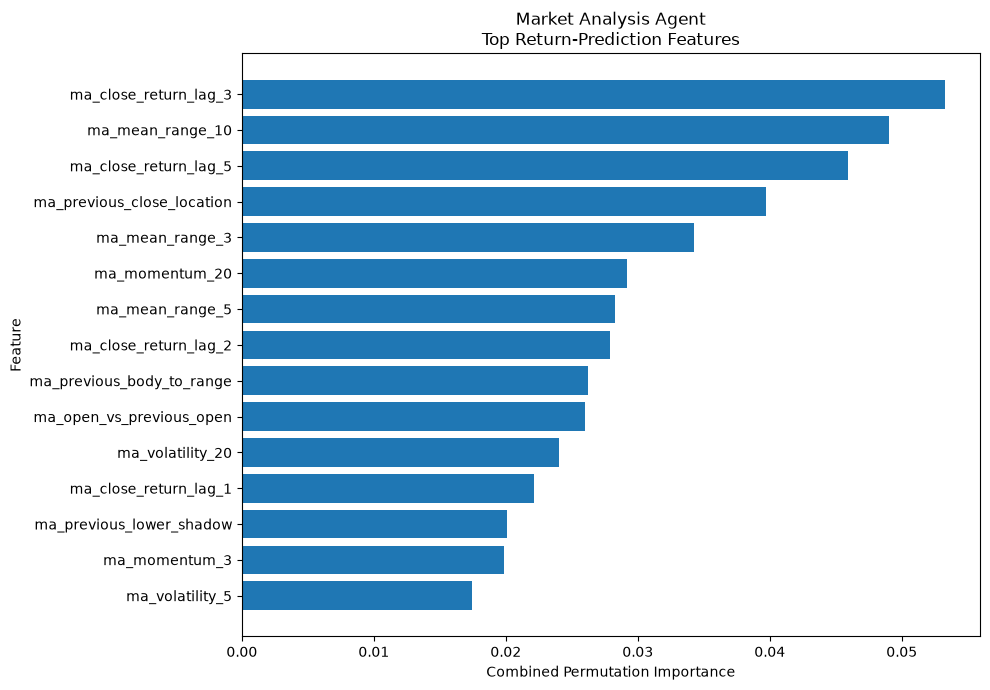

In [57]:
# Plot top 15 features importance
topK = 15
ma_top_features = (ma_feature_importance.head(topK).sort_values( "Combined Importance", ascending=True, ))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ma_top_features["Feature"], ma_top_features["Combined Importance"], )
ax.set_xlabel("Combined Permutation Importance")
ax.set_ylabel("Feature")
ax.set_title("Market Analysis Agent\n" "Top Return-Prediction Features")
plt.tight_layout()
plt.show()

In [58]:
# Define profit-aware market analysis agent
class MLMarketAnalysisAgent(MarketAnalysisAgentBase):
    def __init__(
        self,
        classifier,
        regressor,
        feature_names,
        probability_threshold,
        expected_return_threshold,
        model_version=(MA_MODEL_VERSION),
    ):

        super().__init__(model_name=( MA_MODEL_NAME ), model_version=( model_version ), )
        self.classifier = (classifier)
        self.regressor = (regressor)
        self.feature_names = list(feature_names)
        self.probability_threshold = float(probability_threshold)
        self.expected_return_threshold = float(expected_return_threshold)

        if not hasattr(self.classifier, "classes_", ):
            raise ValueError("Classifier must be fitted.")
        model_classes = list(self.classifier.classes_)

        if 1 not in model_classes:
            raise ValueError("Classifier does not contain " "BUY class 1.")
        self.positive_class_index = (model_classes.index(1))

        # Extend the standard Step 2 MA input requirements.
        # The original fields remain part of packet.market_data.
        self.required_input_fields = (["Open"] + list( self.feature_names ))

    # Input validation
    def validate_inputs(self, packet: DecisionPacket, input_data: Mapping[str, Any]) -> None:
        if (float( input_data["Open"] ) <= 0):
            raise ValueError("Open must be positive.")

        for feature_name in (self.feature_names):
            value = input_data[feature_name]

            if not isinstance(value, ( int, float, np.integer, np.floating, ), ):
                raise TypeError(f"{feature_name} " "must be numeric.")

            if not np.isfinite(value):
                raise ValueError(f"{feature_name} " "must be finite.")

    # Convert packet inputs into model matrix
    def create_feature_frame(self, input_data):
        feature_frame = pd.DataFrame(
            [
                {
                    feature_name:float(input_data[feature_name])
                    for feature_name
                    in self.feature_names
                }
            ],
            columns=self.feature_names,
        )

        return feature_frame

    # Autonomous MA decision
    def process(
        self,
        packet: DecisionPacket,
        input_data: Mapping[str, Any],
        agent_run_id: str,
        started_at_utc: str,
    ) -> MarketAnalysisOutput:

        feature_frame = (self.create_feature_frame( input_data ))

        # Classification head
        profit_probability = float(self.classifier.predict_proba( feature_frame )[0, self.positive_class_index,])

        # Economic-return head
        expected_net_return = float(self.regressor.predict( feature_frame )[0])

        # Profit-aware BUY rule
        probability_pass = (profit_probability >= self.probability_threshold)
        return_pass = (expected_net_return >= self.expected_return_threshold)

        if (probability_pass and return_pass):
            signal = MarketSignal.BUY_CANDIDATE
        else:
            signal = MarketSignal.NO_TRADE

        # Confidence: class certainty remains naturally bounded in [0, 1].
        classification_confidence = (max( profit_probability, 1.0 - profit_probability, ))

        # Return-margin confidence: convert distance from economic threshold into a bounded score.
        return_scale = max(abs( self.expected_return_threshold ), 0.0025, )
        return_margin = (expected_net_return - self.expected_return_threshold)
        return_margin_score = (1.0 / ( 1.0 + np.exp( -return_margin / return_scale ) ))

        confidence_score = float(
            np.clip(
                0.70*classification_confidence
                + 0.30*(return_margin_score if signal == MarketSignal.BUY_CANDIDATE else 1.0 - return_margin_score),
                0.0,
                1.0,
            )
        )

        # Structured evidence for RF
        evidence = []

        # Top input evidence values
        for feature_name in (self.feature_names):
            evidence.append(
                EvidenceItem(
                    feature_name=(feature_name),
                    feature_value=float(input_data[feature_name]),
                    description=("Leakage-safe OHLC-derived " "Market Analysis feature."),
                )
            )

        # Threshold evidence
        evidence.append(
            EvidenceItem(
                feature_name=("ma_expected_return_threshold"),
                feature_value=float(self.expected_return_threshold),
                description=("Minimum model-predicted " "net return required for BUY."),
            )
        )

        # Standard Step 2 output
        return MarketAnalysisOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=(confidence_score),
            input_feature_names=(list( self.feature_names )),
            evidence=evidence,
            warnings=[],
            error_message=None,
            signal=signal,
            predicted_profit_probability=(profit_probability),
            expected_net_return=(expected_net_return),
            decision_threshold=(self.probability_threshold),
        )

print("Profit-aware MLMarketAnalysisAgent created.")

Profit-aware MLMarketAnalysisAgent created.


In [59]:
# Instantiate market analysis agent
market_analysis_agent = (
    MLMarketAnalysisAgent(
        classifier=(ma_classifier),
        regressor=(ma_regressor),
        feature_names=(MA_MODEL_FEATURES),
        probability_threshold=(MA_BUY_PROBABILITY_THRESHOLD),
        expected_return_threshold=(MA_EXPECTED_RETURN_THRESHOLD),
    )
)

print("Profit-aware Market Analysis Agent instantiated.")
print("\nClassifier:", MA_SELECTED_CLASSIFIER, )
print("Expected-return model:", MA_SELECTED_REGRESSOR, )
print("Probability threshold:", MA_BUY_PROBABILITY_THRESHOLD, )
print("Expected-return threshold:", MA_EXPECTED_RETURN_THRESHOLD, )

Profit-aware Market Analysis Agent instantiated.

Classifier: HistGradientBoostingClassifier
Expected-return model: ExtraTreesRegressor
Probability threshold: 0.7049470639427495
Expected-return threshold: -0.001603337026504282


In [60]:
# Direct test predictions

# Classification probability
ma_test_probabilities = (ma_classifier.predict_proba( X_ma_test )[:, 1])

# Predicted economic return
ma_test_expected_returns = (ma_regressor.predict( X_ma_test ))

# Final BUY / NO_TRADE decision
ma_test_predictions = (
    (ma_test_probabilities >= MA_BUY_PROBABILITY_THRESHOLD)
    &
    (ma_test_expected_returns >= MA_EXPECTED_RETURN_THRESHOLD)
).astype(int)

print("FINAL TEST SIGNAL DISTRIBUTION")
print("=" * 60)
print("Test observations:", len( ma_test_predictions ), )
print("Predicted BUY:", int( ma_test_predictions.sum() ), )
print("Predicted NO_TRADE:", int( ( ma_test_predictions == 0 ).sum() ), )
print("=" * 60)

# Diagnostic test table
ma_test_prediction_table = pd.DataFrame(
    {
        "Actual Class":y_ma_test,
        "Profit Probability":ma_test_probabilities,
        "Expected Net Return":ma_test_expected_returns,
        "Predicted Class":ma_test_predictions,
    },
    index=(X_ma_test.index),
)

display(ma_test_prediction_table.head( 20 ))

FINAL TEST SIGNAL DISTRIBUTION
Test observations: 302
Predicted BUY: 16
Predicted NO_TRADE: 286


,Actual Class,Profit Probability,Expected Net Return,Predicted Class
Date,,,,
2025-05-16,0,0.512251,-0.001192,0
2025-05-19,1,0.628728,-0.001217,0
2025-05-20,0,0.704812,-0.001397,0
2025-05-21,0,0.426989,-0.001519,0
2025-05-22,1,0.611281,-0.001338,0
2025-05-23,1,0.531051,-0.001654,0
2025-05-27,1,0.687729,-0.001573,0
2025-05-28,0,0.425264,-0.001671,0
2025-05-29,0,0.597742,-0.001372,0


In [61]:
# Test confusion matrix
ma_cm_array = confusion_matrix(y_ma_test, ma_test_predictions, labels=[0, 1], )
tn, fp, fn, tp = (ma_cm_array.ravel())

ma_confusion_matrix = pd.DataFrame(
    ma_cm_array,
    index=[
        "Actual NO_TRADE",
        "Actual BUY",
    ],
    columns=[
        "Predicted NO_TRADE",
        "Predicted BUY",
    ],
)

print("MARKET ANALYSIS AGENT " "- TEST CONFUSION MATRIX")
display(ma_confusion_matrix)
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

MARKET ANALYSIS AGENT - TEST CONFUSION MATRIX


,Predicted NO_TRADE,Predicted BUY
Actual NO_TRADE,153,7
Actual BUY,133,9


TN = 153
FP = 7
FN = 133
TP = 9


In [62]:
# Classification metrics
ma_accuracy = accuracy_score(y_ma_test, ma_test_predictions, )
ma_balanced_accuracy = (balanced_accuracy_score( y_ma_test, ma_test_predictions, ))
ma_precision = precision_score(y_ma_test, ma_test_predictions, zero_division=0, )
ma_recall = recall_score(y_ma_test, ma_test_predictions, zero_division=0, )
ma_f1 = f1_score(y_ma_test, ma_test_predictions, zero_division=0, )
ma_specificity = (tn / (tn + fp) if (tn + fp) > 0 else np.nan)
ma_roc_auc = roc_auc_score(y_ma_test, ma_test_probabilities, )
ma_classification_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision - BUY",
            "Recall - BUY",
            "F1 Score - BUY",
            "Specificity - NO_TRADE",
            "ROC-AUC",
            "True Positive",
            "False Positive",
            "True Negative",
            "False Negative",
        ],
        "Value": [
            ma_accuracy,
            ma_balanced_accuracy,
            ma_precision,
            ma_recall,
            ma_f1,
            ma_specificity,
            ma_roc_auc,
            tp,
            fp,
            tn,
            fn,
        ],
    }
)

display(ma_classification_metrics)
print(
    classification_report(
        y_ma_test,
        ma_test_predictions,
        target_names=["NO_TRADE","BUY",],
        digits=4,
        zero_division=0,
    )
)

,Metric,Value
0,Accuracy,0.536424
1,Balanced Accuracy,0.509815
2,Precision - BUY,0.562500
3,Recall - BUY,0.063380
4,F1 Score - BUY,0.113924
5,Specificity - NO_TRADE,0.956250
6,ROC-AUC,0.554798
7,True Positive,9.000000
8,False Positive,7.000000
9,True Negative,153.000000


              precision    recall  f1-score   support

    NO_TRADE     0.5350    0.9563    0.6861       160
         BUY     0.5625    0.0634    0.1139       142

    accuracy                         0.5364       302
   macro avg     0.5487    0.5098    0.4000       302
weighted avg     0.5479    0.5364    0.4171       302



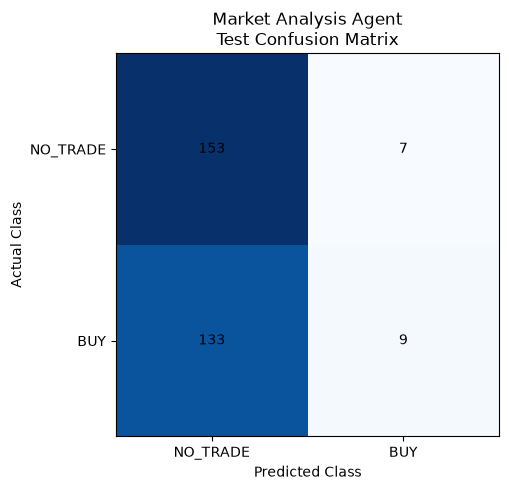

In [63]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(ma_cm_array, cmap = "Blues", )
ax.set_xticks([0, 1], labels=["NO_TRADE", "BUY",], )
ax.set_yticks([0, 1], labels=["NO_TRADE", "BUY",], )
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Market Analysis Agent\n" "Test Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str( ma_cm_array[i, j,] ), ha="center", va="center", )

plt.tight_layout()
plt.show()

In [64]:
from dataclasses import asdict

# Create a fresh portfolio state for Configuration 1: MA -> EX -> RF
# This prevents capital from any previous Step 3 / Step 4 integration tests from carrying into the Step 5 experiment.
ma_portfolio_state = PortfolioState(
    initial_capital=(specification.execution.initial_capital),
    current_capital=(specification.execution.initial_capital),
)

# Validate the fresh portfolio state
if not np.isclose(ma_portfolio_state.initial_capital, specification.execution.initial_capital, ):
    raise RuntimeError("MA portfolio initial capital does not match " "the experiment specification.")

if not np.isclose(ma_portfolio_state.current_capital, specification.execution.initial_capital, ):
    raise RuntimeError("MA portfolio current capital was not reset " "to the initial experiment capital.")

# Display portfolio state
print("Fresh Step 5 MA portfolio state:")
print(asdict( ma_portfolio_state ))

Fresh Step 5 MA portfolio state:
{'initial_capital': 100000.0, 'current_capital': 100000.0, 'peak_capital': 100000.0, 'trade_count': 0, 'winning_trades': 0, 'losing_trades': 0, 'breakeven_trades': 0, 'cumulative_net_profit': 0.0, 'last_trade_return': 0.0}


In [65]:
# Configure execution policy
ma_execution_policy = ExecutionPolicy(
    # MA itself already applies threshold = 0.55.
    # EX confirms that the upstream probability remains at least 0.50.
    ma_probability_threshold=0.50,
    ma_confidence_threshold=0.50,
    sm_support_probability_threshold=0.50,
    sm_confidence_threshold=0.50,
    rm_maximum_risk_score=0.50,
    rm_confidence_threshold=0.50,
    fixed_position_fraction=(specification.execution.fixed_position_fraction),
    transaction_cost_bps_per_side=(specification.execution.transaction_cost_bps_per_side),
    slippage_bps_per_side=(specification.execution.slippage_bps_per_side),
    require_valid_close_for_execution=True,
)

ma_execution_policy.validate()

print("Step 5 Execution Policy validated.")

Step 5 Execution Policy validated.


In [66]:
# Instantiate EX and RF
ma_execution_agent = (
    DeterministicExecutionAgent(
        portfolio_state=(ma_portfolio_state),
        policy=(ma_execution_policy),
        model_version=("EX_DETERMINISTIC_MA_V1"),
    )
)

# If reflection_policy exists from Step 4, retain it.
# Otherwise StructuredDiagnosticReflectionAgent will use its default policy.
if ("reflection_policy" in globals()):
    ma_reflection_agent = (
        StructuredDiagnosticReflectionAgent(policy=( reflection_policy ), model_version=( "RF_STRUCTURED_MA_V1" ), )
    )
else:
    ma_reflection_agent = (StructuredDiagnosticReflectionAgent( model_version=( "RF_STRUCTURED_MA_V1" ), ))

print("Step 5 EX and RF instantiated.")

Step 5 EX and RF instantiated.


In [67]:
# Create MA agent (Step 5) communication registry
ma_registry = AgentRegistry()
ma_registry.register(market_analysis_agent)
ma_registry.register(ma_execution_agent)
ma_registry.register(ma_reflection_agent)

print("Registered Step 5 agents:")

for agent_id in (ma_registry.registered_agents()):
    print("-", agent_id.value, )

Registered Step 5 agents:
- MA
- EX
- RF


In [68]:
# Validate communication architecture for MA agent
# Expects all agent types when checking the complete framework: MA, EX and RF.
required_configuration1_agents = [
    AgentID.MARKET_ANALYSIS,
    AgentID.EXECUTION,
    AgentID.REFLECTION,
]

for agent_id in (required_configuration1_agents):
    if not ma_registry.contains(agent_id):
        raise ValueError(f"Configuration 1 missing " f"{agent_id.value}.")

if not isinstance(ma_registry.get( AgentID.MARKET_ANALYSIS ), MarketAnalysisAgentBase, ):
    raise TypeError("MA does not inherit " "MarketAnalysisAgentBase.")

if not isinstance(ma_registry.get( AgentID.EXECUTION ), ExecutionAgentBase, ):
    raise TypeError("EX does not inherit " "ExecutionAgentBase.")

if not isinstance(ma_registry.get( AgentID.REFLECTION ), ReflectionAgentBase, ):
    raise TypeError("RF does not inherit " "ReflectionAgentBase.")

print("Step 5 Configuration 1 " "communication-platform validation passed.")

Step 5 Configuration 1 communication-platform validation passed.


In [69]:
# Determine dataset version, identifier is required only for DecisionPacket traceability/audit purposes.
# It does NOT affect ML training or predictions.
ma_dataset_version = (
    f"AMZN_MA_"
    f"{ma_train_data.index.min():%Y%m%d}_"
    f"{ma_test_data.index.max():%Y%m%d}_"
    f"N{len(ma_train_data) + len(ma_test_data)}"
)

print("Step 5 dataset version:")
print(ma_dataset_version)

Step 5 dataset version:
AMZN_MA_20200903_20260730_N1482


In [70]:
# Define Configuration 1 (MA -> EX -> RF) runner
def run_ma_configuration1(
    test_data: pd.DataFrame,
    symbol: str,
    specification,
    dataset_version: str,
    registry: AgentRegistry,
):
    daily_records = []
    reflection_records = []
    packets = []

    for decision_date, row in (test_data.iterrows()):
        # Create standard shared DecisionPacket
        packet = (
            create_packet_from_aligned_row(
                row=row,
                symbol=symbol,
                configuration_id=(ConfigurationID.CONFIGURATION_1),
                specification=(specification),
                dataset_version=(dataset_version),
            )
        )

        # Add engineered OHLC features to MA-owned domain. No sentiment or macro variables are added.
        for feature_name in (MA_MODEL_FEATURES):
            packet.market_data[feature_name] = float(row[feature_name])

        # MA
        registry.get(AgentID.MARKET_ANALYSIS).run(packet)

        # EX
        registry.get(AgentID.EXECUTION).run(packet)

        # RF
        registry.get(AgentID.REFLECTION).run(packet)

        # Retrieve outputs
        ma_output = packet.market_analysis_output
        ex_output = packet.execution_output
        rf_output = packet.reflection_output

        # Daily decision record
        daily_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "configuration_id":packet.metadata.configuration_id.value,
                "actual_class":int(row["target_profitable"]),
                "predicted_class":int(ma_output.signal == MarketSignal.BUY_CANDIDATE),
                "market_signal":ma_output.signal.value,
                "predicted_profit_probability":ma_output.predicted_profit_probability,
                "expected_net_return":ma_output.expected_net_return,
                "ma_confidence":ma_output.confidence_score,
                "ma_threshold":ma_output.decision_threshold,
                "ma_expected_return_threshold":(MA_EXPECTED_RETURN_THRESHOLD),
                "trade_executed":ex_output.trade_executed,
                "entry_price":ex_output.entry_price,
                "exit_price":ex_output.exit_price,
                "gross_return":ex_output.gross_return,
                "transaction_cost_return":ex_output.transaction_cost_return,
                "slippage_return":ex_output.slippage_return,
                "net_return":ex_output.net_return,
                "capital_before":ex_output.capital_before,
                "capital_after":ex_output.capital_after,
                "reflection_category":rf_output.category.value,
                "explainability_score":rf_output.explainability_score,
            }
        )

        # Reflection audit log
        reflection_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "market_signal":ma_output.signal.value,
                "ma_probability":ma_output.predicted_profit_probability,
                "ma_expected_return":ma_output.expected_net_return,
                "ma_confidence":ma_output.confidence_score,
                "trade_executed":ex_output.trade_executed,
                "net_return":ex_output.net_return,
                "reflection_category":rf_output.category.value,
                "evidence_summary":rf_output.evidence_summary,
                "decision_summary":rf_output.decision_summary,
                "outcome_summary":rf_output.outcome_summary,
                "identified_strengths":" | ".join(rf_output.identified_strengths),
                "identified_weaknesses":" | ".join(rf_output.identified_weaknesses),
                "diagnostic_labels":" | ".join(rf_output.diagnostic_labels),
                "explainability_score":rf_output.explainability_score,
            }
        )

        packets.append(packet)

    daily_results = (pd.DataFrame( daily_records ).set_index( "date" ))
    reflection_log = (pd.DataFrame( reflection_records ).set_index( "date" ))

    return (daily_results, reflection_log, packets, )

In [71]:
# Execute Configuration 1 (MA -> EX -> RF) on test data
(ma_daily_results, ma_reflection_log, ma_packets, ) = run_ma_configuration1(
    test_data=(ma_test_data),
    symbol="AMZN",
    specification=(specification),
    dataset_version=(ma_dataset_version),
    registry=(ma_registry),
)

print("Configuration 1 completed.")
print("Test decisions:", len( ma_daily_results ))
print("Executed trades:", int( ma_daily_results["trade_executed"].sum() ))

Configuration 1 completed.
Test decisions: 302
Executed trades: 16


In [72]:
# Verify packet predictions match direct model predictions
packet_predictions = (ma_daily_results["predicted_class"].astype(int).to_numpy())

if not np.array_equal(packet_predictions, ma_test_predictions, ):
    raise ValueError("Direct model predictions and " "DecisionPacket predictions differ.")

print("Prediction consistency check passed.")


Prediction consistency check passed.


In [73]:
# Define trading performance metrics
def calculate_trading_metrics(
    daily_returns,
    initial_capital=100_000.0,
    trading_days_per_year=252,
    annual_risk_free_rate=0.0,
):
    returns = pd.Series(daily_returns, dtype=float, ).fillna(0.0)
    n = len(returns)

    if n == 0:
        raise ValueError("Return series is empty.")

    # Portfolio value
    equity_curve = (initial_capital * (1.0 + returns).cumprod())
    final_value = float(equity_curve.iloc[-1])
    total_return = (final_value / initial_capital - 1.0)
    annualized_return = ((1.0 + total_return) ** ( trading_days_per_year / n ) - 1.0)
    annualized_volatility = (returns.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    daily_rf = (( 1.0 + annual_risk_free_rate ) ** ( 1.0 / trading_days_per_year ) - 1.0)
    
    excess_return = (returns - daily_rf)
    excess_std = excess_return.std(ddof=1)
    if excess_std > 0:
        sharpe_ratio = (excess_return.mean() / excess_std * np.sqrt( trading_days_per_year ))
    else:
        sharpe_ratio = np.nan

    running_peak = (equity_curve.cummax())
    drawdown = (equity_curve / running_peak - 1.0)
    maximum_drawdown = float(drawdown.min())

    downside_returns = (returns[returns < 0])
    if (len(downside_returns) > 1 and downside_returns.std( ddof=1 ) > 0):
        sortino_ratio = (excess_return.mean() / downside_returns.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    else:
        sortino_ratio = np.nan

    if maximum_drawdown < 0:
        calmar_ratio = (annualized_return / abs( maximum_drawdown ))
    else:
        calmar_ratio = np.nan

    trade_returns = (returns[returns != 0])
    number_of_trades = int(len( trade_returns ))
    winning_trades = int(( trade_returns > 0 ).sum())
    losing_trades = int(( trade_returns < 0 ).sum())

    if number_of_trades > 0:
        win_rate = (winning_trades / number_of_trades)
    else:
        win_rate = np.nan

    return {
        "Initial Capital":initial_capital,
        "Final Portfolio Value":final_value,
        "Total Return":total_return,
        "Annualized Return":annualized_return,
        "Annualized Volatility":annualized_volatility,
        "Sharpe Ratio":sharpe_ratio,
        "Maximum Drawdown":maximum_drawdown,
        "Sortino Ratio":sortino_ratio,
        "Calmar Ratio":calmar_ratio,
        "Number of Trades":number_of_trades,
        "Winning Trades":winning_trades,
        "Losing Trades":losing_trades,
        "Win Rate":win_rate,
    }

In [74]:
# Calculate MA trading performance
ma_trading_metrics = (
    calculate_trading_metrics(
        daily_returns=(ma_daily_results["net_return"]),
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

ma_trading_metrics_table = pd.DataFrame(
    {
        "Metric":list(ma_trading_metrics.keys()),
        "MA Test":list(ma_trading_metrics.values()),
    }
)

display(ma_trading_metrics_table)

,Metric,MA Test
0,Initial Capital,100000.000000
1,Final Portfolio Value,107757.787734
2,Total Return,0.077578
3,Annualized Return,0.064330
4,Annualized Volatility,0.056960
5,Sharpe Ratio,1.122766
6,Maximum Drawdown,-0.020111
7,Sortino Ratio,0.473164
8,Calmar Ratio,3.198800
9,Number of Trades,16.000000


In [75]:
# Load the baseline strategy only
baseline_candidates = [
    Path("baseline_strategy.csv"),
    Path("data/baseline_strategy.csv"),
    Path("/mnt/data/baseline_strategy.csv"),
]

BASELINE_FILE_PATH = None

for candidate in baseline_candidates:
    if candidate.exists():
        BASELINE_FILE_PATH = candidate
        break

if BASELINE_FILE_PATH is None:
    raise FileNotFoundError(
        "baseline_strategy.csv was not found. "
        "Update baseline_candidates with the correct location."
    )

baseline_results = pd.read_csv(BASELINE_FILE_PATH)
baseline_results["Date"] = pd.to_datetime(baseline_results["Date"])
baseline_results = (baseline_results.set_index("Date").sort_index())

print("Baseline loaded from:")
print(BASELINE_FILE_PATH)
print("Baseline observations:", len( baseline_results ))

Baseline loaded from:
data\baseline_strategy.csv
Baseline observations: 1504


In [76]:
# Align baseline to the exact same test period
baseline_test_results = (baseline_results.reindex( ma_test_data.index ))

if (baseline_test_results["net_strategy_return"].isna().any()):
    missing_dates = (baseline_test_results[baseline_test_results["net_strategy_return"].isna()].index.tolist())

    raise ValueError(
        "Baseline does not contain all Step 5 test dates.\n"
        f"First missing dates: "
        f"{missing_dates[:10]}"
    )

print("Baseline successfully aligned " "to Step 5 test period.")
print("Aligned observations:", len( baseline_test_results ))

Baseline successfully aligned to Step 5 test period.
Aligned observations: 302


In [77]:
# Calculate baseline test-period metrics
baseline_trading_metrics = (
    calculate_trading_metrics(
        daily_returns=(baseline_test_results["net_strategy_return"]),
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

baseline_metrics_table = pd.DataFrame(
    {
        "Metric":list(baseline_trading_metrics.keys()),
        "Baseline Test":list(baseline_trading_metrics.values()),
    }
)

display(baseline_metrics_table)

,Metric,Baseline Test
0,Initial Capital,100000.000000
1,Final Portfolio Value,101536.116228
2,Total Return,0.015361
3,Annualized Return,0.012802
4,Annualized Volatility,0.034288
5,Sharpe Ratio,0.388114
6,Maximum Drawdown,-0.026007
7,Sortino Ratio,0.082412
8,Calmar Ratio,0.492242
9,Number of Trades,9.000000


In [78]:
# Baseline versus MA performance comparison
metric_order = [
    "Initial Capital",
    "Final Portfolio Value",
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Sortino Ratio",
    "Calmar Ratio",
    "Number of Trades",
    "Winning Trades",
    "Losing Trades",
    "Win Rate",
]

higher_is_better = {
    "Final Portfolio Value",
    "Total Return",
    "Annualized Return",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Sortino Ratio",
    "Calmar Ratio",
    "Win Rate",
}

lower_is_better = {
    "Annualized Volatility",
}

comparison_records = []

for metric in metric_order:
    baseline_value = (baseline_trading_metrics[metric])
    ma_value = (ma_trading_metrics[metric])

    if metric in higher_is_better:
        better = "MA" if ma_value > baseline_value else "Baseline"
    elif metric in lower_is_better:
        better = "MA" if ma_value < baseline_value else "Baseline"
    else:
        better = "-"

    comparison_records.append(
        {
            "Metric":metric,
            "Baseline Test":baseline_value,
            "MA Agent Test":ma_value,
            "Difference":ma_value - baseline_value,
            "Better":better,
        }
    )

ma_vs_baseline_performance = (pd.DataFrame( comparison_records ))
display(ma_vs_baseline_performance)

,Metric,Baseline Test,MA Agent Test,Difference,Better
0,Initial Capital,100000.000000,100000.000000,0.000000,-
1,Final Portfolio Value,101536.116228,107757.787734,6221.671506,MA
2,Total Return,0.015361,0.077578,0.062217,MA
3,Annualized Return,0.012802,0.064330,0.051528,MA
4,Annualized Volatility,0.034288,0.056960,0.022672,Baseline
5,Sharpe Ratio,0.388114,1.122766,0.734652,MA
6,Maximum Drawdown,-0.026007,-0.020111,0.005896,MA
7,Sortino Ratio,0.082412,0.473164,0.390752,MA
8,Calmar Ratio,0.492242,3.198800,2.706558,MA
9,Number of Trades,9.000000,16.000000,7.000000,-


In [79]:
# Test decision log
ma_test_decision_log = (
    ma_daily_results[
        [
            "decision_id",
            "actual_class",
            "predicted_class",
            "market_signal",
            "predicted_profit_probability",
            "ma_confidence",
            "ma_threshold",
            "trade_executed",
            "entry_price",
            "exit_price",
            "net_return",
            "capital_before",
            "capital_after",
            "reflection_category",
            "explainability_score",
        ]
    ]
    .copy()
)

# display(ma_test_decision_log.head(20))

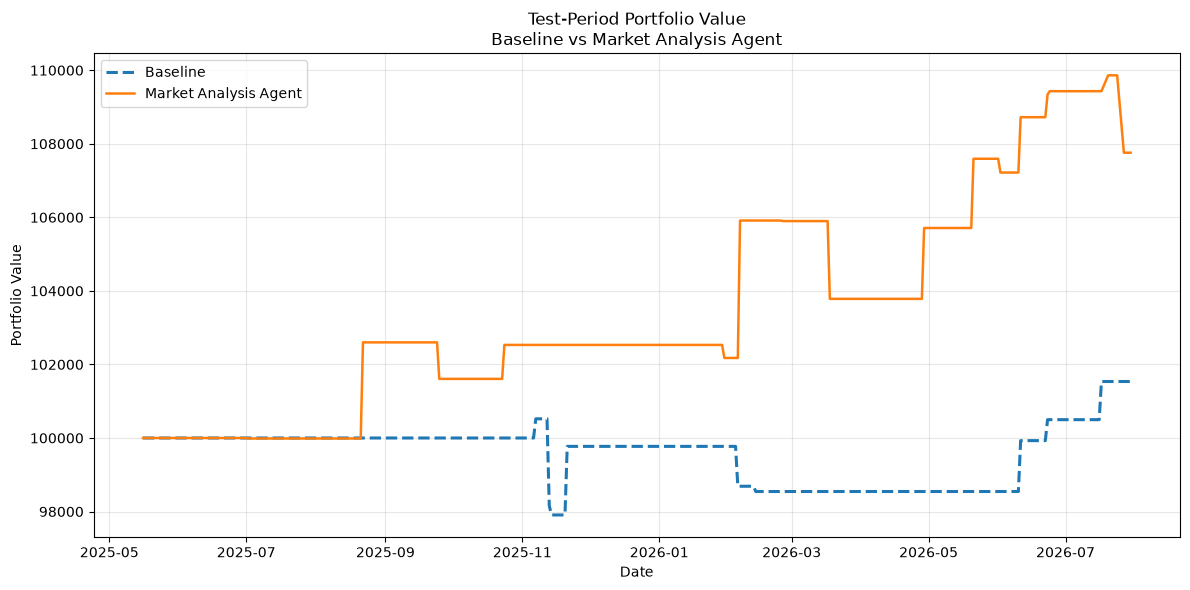

In [80]:
# Equity curve comparison
initial_capital = specification.execution.initial_capital
baseline_equity = (initial_capital * ( 1.0 + baseline_test_results["net_strategy_return"] ).cumprod())
ma_equity = (initial_capital * ( 1.0 + ma_daily_results["net_return"] ).cumprod())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(baseline_equity.index, baseline_equity, label="Baseline", linestyle="--", linewidth=2.2, )
ax.plot(ma_equity.index, ma_equity, label="Market Analysis Agent", linestyle="-", linewidth=1.8, )
ax.set_title("Test-Period Portfolio Value\n" "Baseline vs Market Analysis Agent")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3, )
plt.tight_layout()
plt.show()

In [81]:
# Export Step 5 outputs
MA_OUTPUT_DIRECTORY = Path("data/model2/step5_ma_market_analysis_agent_outputs")
MA_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True, )

ma_class_distribution.to_csv(MA_OUTPUT_DIRECTORY / "ma_class_distribution.csv", index=False, )
ma_confusion_matrix.to_csv(MA_OUTPUT_DIRECTORY / "ma_test_confusion_matrix.csv")
ma_classification_metrics.to_csv(MA_OUTPUT_DIRECTORY / "ma_classification_metrics.csv", index=False, )
ma_feature_importance.to_csv(MA_OUTPUT_DIRECTORY / "ma_feature_importance.csv", index=False, )
ma_vs_baseline_performance.to_csv(MA_OUTPUT_DIRECTORY / "ma_baseline_vs_ma_performance.csv", index=False, )
ma_daily_results.to_csv(MA_OUTPUT_DIRECTORY / "ma_test_daily_results.csv")
ma_test_decision_log.to_csv(MA_OUTPUT_DIRECTORY / "ma_test_decision_log.csv")
ma_reflection_log.to_csv(MA_OUTPUT_DIRECTORY / "ma_reflection_log.csv")

print("MA Agent outputs saved to:")
print(MA_OUTPUT_DIRECTORY.resolve())

MA Agent outputs saved to:
C:\Users\yeobp\Desktop\Python\DBA-AIML-Walsh\MS-AIML\Capstone\FinalVersion\data\model2\step5_ma_market_analysis_agent_outputs


#### Step 6: Sentiment Agent (Uses Machine Learning)

In [83]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

SM_RANDOM_SEED = 42
SM_MODEL_NAME = "ProfitAwareDualModelSentimentAgent"
SM_MODEL_VERSION = "SM_DUAL_OHLC_SENTIMENT_V2"

SM_MIN_PRECISION = 0.50
SM_MIN_RECALL = 0.25
SM_MIN_F1 = 0.33
SM_MIN_VALIDATION_TRADES = 10

SM_PROBABILITY_QUANTILES = np.arange(0.15, 0.81, 0.05)
SM_RETURN_QUANTILES = np.arange(0.00, 0.81, 0.05)

print("SM configuration loaded.")


SM configuration loaded.


In [84]:
# Step 1-4 verification
required_sm_objects = [
    "train_data",
    "validation_data",
    "test_data",
    "specification",
    "CONFIGURATION_AGENTS",
    "SentimentAgentBase",
    "SentimentOutput",
    "SentimentRecommendation",
    "DecisionPacket",
    "AgentRunStatus",
    "AgentID",
    "ConfigurationID",
    "EvidenceItem",
    "PortfolioState",
    "ExecutionPolicy",
    "DeterministicExecutionAgent",
    "ExecutionApprovalDecision",
    "StructuredDiagnosticReflectionAgent",
    "AgentRegistry",
    "create_packet_from_aligned_row",
]

missing_sm_objects = [
    name for name in required_sm_objects
    if name not in globals()
]

if missing_sm_objects:
    raise NameError("Run updated Step 1 and Steps 2-4 first. " f"Missing objects: {missing_sm_objects}")

expected_config2 = [
    AgentID.SENTIMENT,
    AgentID.EXECUTION,
    AgentID.REFLECTION,
]

actual_config2 = CONFIGURATION_AGENTS[
    ConfigurationID.CONFIGURATION_2
]

if actual_config2 != expected_config2:
    raise ValueError("Configuration 2 must be SM -> EX -> RF. " f"Current route: {[a.value for a in actual_config2]}")

print("Configuration 2:", " -> ".join(a.value for a in actual_config2), )
print("Updated Step 2/Step 4 active-agent validation " "will be used by EX and RF.")


Configuration 2: SM -> EX -> RF
Updated Step 2/Step 4 active-agent validation will be used by EX and RF.


In [85]:
# Master source data with leakage-sage feature engineering
sm_all_data = pd.concat([train_data, validation_data, test_data], axis=0, ).sort_index()

if sm_all_data.index.duplicated().any():
    raise ValueError("Duplicate dates detected.")

required_raw_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "sentiment_mean",
    "sentiment_std",
    "news_count",
    "target_profitable",
    "net_open_to_close_return",
]

missing_columns = [
    c for c in required_raw_columns
    if c not in sm_all_data.columns
]

if missing_columns:
    raise ValueError(f"Missing SM columns: {missing_columns}")


def create_sm_features(data):
    df = data.copy().sort_index()
    eps = 1e-8

    prev_open = df["Open"].shift(1)
    prev_high = df["High"].shift(1)
    prev_low = df["Low"].shift(1)
    prev_close = df["Close"].shift(1)
    prev_range = (prev_high - prev_low).clip(lower=eps)

    df["sm_previous_day_return"] = (prev_close / prev_open - 1.0)
    df["sm_opening_gap"] = (df["Open"] / prev_close - 1.0)
    df["sm_previous_range_ratio"] = ((prev_high - prev_low) / prev_open)
    df["sm_previous_body_ratio"] = ((prev_close - prev_open) / prev_open)
    df["sm_previous_body_to_range"] = ((prev_close - prev_open) / prev_range)
    df["sm_previous_close_location"] = ((prev_close - prev_low) / prev_range)
    df["sm_previous_upper_shadow"] = (( prev_high - np.maximum(prev_open, prev_close) ) / prev_open)
    df["sm_previous_lower_shadow"] = (( np.minimum(prev_open, prev_close) - prev_low ) / prev_open)
    df["sm_open_vs_previous_open"] = (df["Open"] / prev_open - 1.0)
    close_return = df["Close"].pct_change()

    for lag in [1, 2, 3, 5]:
        df[f"sm_close_return_lag_{lag}"] = (close_return.shift(lag))

    for window in [3, 5, 10, 20]:
        df[f"sm_momentum_{window}"] = (prev_close / df["Close"].shift(window + 1) - 1.0)

    for window in [5, 10, 20]:
        df[f"sm_volatility_{window}"] = (close_return.shift(1).rolling(window).std())

    range_ratio = ((df["High"] - df["Low"]) / df["Open"])

    for window in [3, 5, 10]:
        df[f"sm_mean_range_{window}"] = (range_ratio.shift(1).rolling(window).mean())

    # Existing SentimentAgentBase uses previous-day sentiment.
    df["previous_sentiment_mean"] = (df["sentiment_mean"].shift(1))
    df["previous_sentiment_std"] = (df["sentiment_std"].shift(1))
    df["previous_news_count"] = (df["news_count"].shift(1).fillna(0.0))
    df["sm_news_available"] = (df["previous_news_count"] > 0).astype(int)
    df["sm_log_news_count"] = np.log1p(df["previous_news_count"].clip(lower=0))
    df["sm_sentiment_strength"] = (df["previous_sentiment_mean"].abs())
    df["sm_positive_sentiment"] = (df["previous_sentiment_mean"] > 0).astype(int)
    df["sm_negative_sentiment"] = (df["previous_sentiment_mean"] < 0).astype(int)
    df["sm_sentiment_consistency"] = (df["previous_sentiment_mean"] / ( df["previous_sentiment_std"].abs() + 0.05 ))
    df["sm_coverage_weighted_sentiment"] = (df["previous_sentiment_mean"] * df["sm_log_news_count"])
    df["sm_coverage_weighted_uncertainty"] = (df["previous_sentiment_std"] * df["sm_log_news_count"])

    for lag in [2, 3, 5]:
        df[f"sm_sentiment_mean_lag_{lag}"] = (df["sentiment_mean"].shift(lag))
        df[f"sm_sentiment_std_lag_{lag}"] = (df["sentiment_std"].shift(lag))
        df[f"sm_news_count_lag_{lag}"] = (df["news_count"].shift(lag))

    df["sm_sentiment_change_1"] = (df["sentiment_mean"].shift(1) - df["sentiment_mean"].shift(2))
    df["sm_sentiment_change_3"] = (df["sentiment_mean"].shift(1) - df["sentiment_mean"].shift(4))

    for window in [3, 5, 10]:
        df[f"sm_sentiment_mean_{window}"] = (df["sentiment_mean"].shift(1).rolling(window).mean())
        df[f"sm_sentiment_dispersion_{window}"] = (df["sentiment_mean"].shift(1).rolling(window).std())
        df[f"sm_news_mean_{window}"] = (df["news_count"].shift(1).rolling(window).mean())

    df["sm_sentiment_x_gap"] = (df["previous_sentiment_mean"] * df["sm_opening_gap"])
    df["sm_sentiment_x_previous_return"] = (df["previous_sentiment_mean"] * df["sm_previous_day_return"])
    df["sm_sentiment_x_momentum_5"] = (df["previous_sentiment_mean"] * df["sm_momentum_5"])
    df["sm_sentiment_x_volatility_5"] = (df["previous_sentiment_mean"] * df["sm_volatility_5"])
    df["sm_uncertainty_x_gap"] = (df["previous_sentiment_std"] * df["sm_opening_gap"].abs())
    df["sm_reversal_candidate"] = ((df["sm_previous_day_return"] <= -0.02) & (df["sm_opening_gap"] < 0.0)).astype(int)

    return df.replace([np.inf, -np.inf], np.nan, )

sm_all_data = create_sm_features(sm_all_data)
print("SM feature engineering completed.")


SM feature engineering completed.


In [86]:
# Feature set with 80/20 training/test dataset split
SM_MODEL_FEATURES = [
    "sm_previous_day_return",
    "sm_opening_gap",
    "sm_previous_range_ratio",
    "sm_previous_body_ratio",
    "sm_previous_body_to_range",
    "sm_previous_close_location",
    "sm_previous_upper_shadow",
    "sm_previous_lower_shadow",
    "sm_open_vs_previous_open",

    "sm_close_return_lag_1",
    "sm_close_return_lag_2",
    "sm_close_return_lag_3",
    "sm_close_return_lag_5",

    "sm_momentum_3",
    "sm_momentum_5",
    "sm_momentum_10",
    "sm_momentum_20",

    "sm_volatility_5",
    "sm_volatility_10",
    "sm_volatility_20",

    "sm_mean_range_3",
    "sm_mean_range_5",
    "sm_mean_range_10",

    "previous_sentiment_mean",
    "previous_sentiment_std",
    "previous_news_count",

    "sm_news_available",
    "sm_log_news_count",
    "sm_sentiment_strength",
    "sm_positive_sentiment",
    "sm_negative_sentiment",
    "sm_sentiment_consistency",
    "sm_coverage_weighted_sentiment",
    "sm_coverage_weighted_uncertainty",

    "sm_sentiment_mean_lag_2",
    "sm_sentiment_mean_lag_3",
    "sm_sentiment_mean_lag_5",

    "sm_sentiment_std_lag_2",
    "sm_sentiment_std_lag_3",
    "sm_sentiment_std_lag_5",

    "sm_news_count_lag_2",
    "sm_news_count_lag_3",
    "sm_news_count_lag_5",

    "sm_sentiment_change_1",
    "sm_sentiment_change_3",

    "sm_sentiment_mean_3",
    "sm_sentiment_mean_5",
    "sm_sentiment_mean_10",

    "sm_sentiment_dispersion_3",
    "sm_sentiment_dispersion_5",
    "sm_sentiment_dispersion_10",

    "sm_news_mean_3",
    "sm_news_mean_5",
    "sm_news_mean_10",

    "sm_sentiment_x_gap",
    "sm_sentiment_x_previous_return",
    "sm_sentiment_x_momentum_5",
    "sm_sentiment_x_volatility_5",
    "sm_uncertainty_x_gap",
    "sm_reversal_candidate",
]

sm_development_index = (train_data.index.union( validation_data.index ))
sm_train_data = (sm_all_data.loc[sm_development_index].copy().dropna( subset=SM_MODEL_FEATURES ))
sm_test_data = (sm_all_data.loc[test_data.index].copy().dropna( subset=SM_MODEL_FEATURES ))

if (sm_train_data.index.max() >= sm_test_data.index.min()):
    raise ValueError("SM development/test periods overlap.")

print("SM features:", len(SM_MODEL_FEATURES), )
print("Development observations:", len(sm_train_data), )
print("Test observations:", len(sm_test_data), )


SM features: 60
Development observations: 1180
Test observations: 302


In [87]:
# Training/validation/test dataset split
X_sm_development = (sm_train_data[SM_MODEL_FEATURES].astype(float).copy())
y_sm_development_class = (sm_train_data["target_profitable"].astype(int).copy())
y_sm_development_return = (sm_train_data["net_open_to_close_return"].astype(float).copy())

X_sm_test = (sm_test_data[SM_MODEL_FEATURES].astype(float).copy())
y_sm_test = (sm_test_data["target_profitable"].astype(int).copy())
y_sm_test_return = (sm_test_data["net_open_to_close_return"].astype(float).copy())

internal_split = int(len(X_sm_development) * 0.75)
X_sm_fit = (X_sm_development.iloc[:internal_split].copy())
X_sm_validation = (X_sm_development.iloc[internal_split:].copy())
y_sm_fit_class = (y_sm_development_class.loc[X_sm_fit.index])
y_sm_validation_class = (y_sm_development_class.loc[X_sm_validation.index])
y_sm_fit_return = (y_sm_development_return.loc[X_sm_fit.index])
y_sm_validation_return = (y_sm_development_return.loc[X_sm_validation.index])

if (X_sm_development.isna().any().any() or X_sm_test.isna().any().any()):
    raise ValueError("NaN remains in SM ML matrices.")

if not np.isfinite(X_sm_development.to_numpy()).all():
    raise ValueError("Non-finite development feature detected.")

if not np.isfinite(X_sm_test.to_numpy()).all():
    raise ValueError("Non-finite test feature detected.")

print("Internal training:", X_sm_fit.shape, )
print("Internal validation:", X_sm_validation.shape, )
print("Final test:", X_sm_test.shape, )


Internal training: (885, 60)
Internal validation: (295, 60)
Final test: (302, 60)


In [88]:
# Baseline and trading selection utility/helper functions
def calculate_sm_selection_metrics(signal, realised_returns, trading_days=252):
    signal = np.asarray(signal, dtype=bool, )
    realised_returns = np.asarray(realised_returns, dtype=float, )
    strategy_returns = np.where(signal, realised_returns, 0.0, )
    total_return = float(np.prod( 1.0 + strategy_returns ) - 1.0)
    std_return = float(np.std( strategy_returns, ddof=1, ))

    if std_return > 0:
        sharpe = float(np.mean( strategy_returns ) / std_return * np.sqrt( trading_days ))
    else:
        sharpe = np.nan

    trade_returns = (realised_returns[signal])
    trades = int(len(trade_returns))

    if trades > 0:
        win_rate = float(np.mean( trade_returns > 0 ))
        avg_trade_return = float(np.mean( trade_returns ))
    else:
        win_rate = np.nan
        avg_trade_return = np.nan

    equity = np.cumprod(1.0 + strategy_returns)

    if len(equity):
        peak = np.maximum.accumulate(equity)
        max_drawdown = float(np.min( equity / peak - 1.0 ))
    else:
        max_drawdown = np.nan

    return {
        "total_return":total_return,
        "sharpe_ratio":sharpe,
        "number_of_trades":trades,
        "win_rate":win_rate,
        "average_trade_return":avg_trade_return,
        "maximum_drawdown":max_drawdown,
    }

baseline_candidates = [
    Path("baseline_strategy.csv"),
    Path("data/baseline_strategy.csv"),
    Path("/mnt/data/baseline_strategy.csv"),
]

SM_BASELINE_FILE_PATH = next(( p for p in baseline_candidates if p.exists() ), None, )

if SM_BASELINE_FILE_PATH is None:
    raise FileNotFoundError("baseline_strategy.csv was not found.")

sm_baseline_results = pd.read_csv(SM_BASELINE_FILE_PATH)
sm_baseline_results["Date"] = (pd.to_datetime( sm_baseline_results["Date"] ))
sm_baseline_results = (sm_baseline_results.set_index("Date").sort_index())
sm_baseline_validation_returns = (sm_baseline_results["net_strategy_return"].reindex(X_sm_validation.index).fillna(0.0))

sm_baseline_validation_metrics = (
    calculate_sm_selection_metrics(
        signal=(sm_baseline_validation_returns.to_numpy() != 0),
        realised_returns=(sm_baseline_validation_returns.to_numpy()),
    )
)

print("Validation baseline return:", f"{sm_baseline_validation_metrics['total_return']:.4%}", )
print("Validation baseline Sharpe:", f"{sm_baseline_validation_metrics['sharpe_ratio']:.4f}", )


Validation baseline return: 9.6248%
Validation baseline Sharpe: 1.8469


In [89]:
# List of candidate models to be fitted for model selection
sm_classifier_candidates = {
    "HistGradientBoostingClassifier":
        HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=350,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=8.0,
            random_state=SM_RANDOM_SEED,
        ),

    "ExtraTreesClassifier":
        ExtraTreesClassifier(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            class_weight="balanced",
            max_features="sqrt",
            random_state=SM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "RandomForestClassifier":
        RandomForestClassifier(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            class_weight="balanced",
            max_features="sqrt",
            random_state=SM_RANDOM_SEED,
            n_jobs=-1,
        ),
}

sm_regressor_candidates = {
    "RandomForestRegressor":
        RandomForestRegressor(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            max_features=0.80,
            random_state=SM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "ExtraTreesRegressor":
        ExtraTreesRegressor(
            n_estimators=1000,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            max_features=0.80,
            random_state=SM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "HistGradientBoostingRegressor":
        HistGradientBoostingRegressor(
            learning_rate=0.03,
            max_iter=350,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=10.0,
            loss="squared_error",
            random_state=SM_RANDOM_SEED,
        ),
}

sm_fitted_classifiers = {}

for name, candidate in (sm_classifier_candidates.items()):
    model = clone(candidate)
    model.fit(X_sm_fit, y_sm_fit_class, )
    sm_fitted_classifiers[
        name
    ] = model
sm_fitted_regressors = {}

for name, candidate in (sm_regressor_candidates.items()):
    model = clone(candidate)
    model.fit(X_sm_fit, y_sm_fit_return, )
    sm_fitted_regressors[
        name
    ] = model

print("SM candidate models fitted.")


SM candidate models fitted.


In [90]:
# Profit-aware model selection and hyperparameter tuning
sm_selection_records = []

for classifier_name, classifier_model in (sm_fitted_classifiers.items()):
    probability = (classifier_model.predict_proba( X_sm_validation )[:, 1])

    try:
        auc = roc_auc_score(y_sm_validation_class, probability, )
    except ValueError:
        auc = np.nan

    for regressor_name, regressor_model in (sm_fitted_regressors.items()):
        expected_return = (regressor_model.predict( X_sm_validation ))

        for probability_quantile in (SM_PROBABILITY_QUANTILES):
            probability_threshold = float(np.quantile( probability, probability_quantile, ))

            for return_quantile in (SM_RETURN_QUANTILES):
                return_threshold = float(np.quantile( expected_return, return_quantile, ))

                prediction = (
                    (probability >= probability_threshold)
                    &
                    (expected_return >= return_threshold)
                ).astype(int)

                if (np.unique( prediction ).size < 2):
                    continue

                precision = precision_score(y_sm_validation_class, prediction, zero_division=0, )
                recall = recall_score(y_sm_validation_class, prediction, zero_division=0, )
                f1 = f1_score(y_sm_validation_class, prediction, zero_division=0, )
                balanced_accuracy = (balanced_accuracy_score( y_sm_validation_class, prediction, ))

                tm = (
                    calculate_sm_selection_metrics(
                        signal=(prediction == 1),
                        realised_returns=(y_sm_validation_return.to_numpy()),
                    )
                )

                total_return = (tm["total_return"])
                sharpe = (tm["sharpe_ratio"])
                trades = (tm["number_of_trades"])
                avg_trade = (tm["average_trade_return"])

                classification_pass = (
                    precision >= 0.48
                    and recall >= 0.20
                    and f1 >= 0.28
                    and trades
                    >= SM_MIN_VALIDATION_TRADES
                )

                economic_pass = (total_return > 0 and np.isfinite( sharpe ) and sharpe > 0 and avg_trade > 0)
                excess_return = (total_return - sm_baseline_validation_metrics["total_return"])
                baseline_sharpe = (sm_baseline_validation_metrics["sharpe_ratio"])

                if (np.isfinite( baseline_sharpe ) and np.isfinite( sharpe )):
                    excess_sharpe = (sharpe - baseline_sharpe)
                else:
                    excess_sharpe = 0.0

                objective = (
                    6.00 * total_return
                    + 0.20 * sharpe
                    + 0.35 * f1
                    + 0.15 * balanced_accuracy
                    + 0.10 * recall
                    + 0.10 * precision
                    + 0.05 * tm["win_rate"]
                    + 0.50 * excess_return
                    + 0.03 * excess_sharpe
                    + 0.10 * tm["maximum_drawdown"]
                )

                # # Objective score will be calculated AFTER all candidate configurations have been generated 
                # # The objective coefficients will then be optimized.
                # objective = np.nan

                sm_selection_records.append(
                    {
                        "classifier":classifier_name,
                        "regressor":regressor_name,
                        "probability_quantile":probability_quantile,
                        "return_quantile":return_quantile,
                        "probability_threshold":probability_threshold,
                        "return_threshold":return_threshold,
                        "precision":precision,
                        "recall":recall,
                        "f1":f1,
                        "balanced_accuracy":balanced_accuracy,
                        "roc_auc":auc,
                        "total_return":total_return,
                        "sharpe_ratio":sharpe,
                        "win_rate":tm["win_rate"],
                        "maximum_drawdown":tm["maximum_drawdown"],
                        "number_of_trades":trades,
                        "excess_return":excess_return,
                        "excess_sharpe":excess_sharpe,
                        "classification_pass":classification_pass,
                        "economic_pass":economic_pass,
                        "objective_score":objective,
                    }
                )

sm_model_selection_results = pd.DataFrame(sm_selection_records)
if sm_model_selection_results.empty:
    raise RuntimeError("No valid SM model configurations generated.")

# # Perform SM objective weight optimization
# SM_OBJECTIVE_OPTIMIZATION = (
#     optimize_objective_coefficients(
#         validation_results=sm_model_selection_results,
#         agent_name="SM",
#         regularization_strength=0.05,
#         random_state=SM_RANDOM_SEED,
#     )
# )

# # Extract optimized SM weights
# SM_OBJECTIVE_WEIGHTS = (SM_OBJECTIVE_OPTIMIZATION["weights"])

# # Store in shared MA / SM optimization registry
# OBJECTIVE_OPTIMIZATION_RESULTS["SM"] = (SM_OBJECTIVE_OPTIMIZATION)

# # REPLACE NaN OBJECTIVE SCORES WITH OPTIMIZED SCORES
# sm_optimized_results = (SM_OBJECTIVE_OPTIMIZATION["ranked_results"])

# sm_model_selection_results.loc[sm_optimized_results.index,"objective_score"] = (
#     sm_optimized_results["optimized_objective_score"])

# # Display final SM optimized weights
# print()
# print("=" * 80)
# print("FINAL OPTIMIZED SM OBJECTIVE WEIGHTS")
# print("=" * 80)

# for metric, weight in SM_OBJECTIVE_WEIGHTS.items():
#     print(
#         f"{metric:<22}: "
#         f"{weight:.6f}"
#     )

# print("\nSum of SM optimized weights:",round(sum(SM_OBJECTIVE_WEIGHTS.values()),10,),)
# print("=" * 80)

tier1 = (
    sm_model_selection_results[sm_model_selection_results["classification_pass"]
        &
        sm_model_selection_results["economic_pass"]
        &
        (sm_model_selection_results["excess_return"] > 0)
        &
        (sm_model_selection_results["excess_sharpe"] > 0)
    ]
)

tier2 = (
    sm_model_selection_results[
        sm_model_selection_results["classification_pass"]
        &
        sm_model_selection_results["economic_pass"]
        &
        (( sm_model_selection_results["excess_return"] > 0 ) | ( sm_model_selection_results["excess_sharpe"] > 0 ))
    ]
)

tier3 = (
    sm_model_selection_results[
        sm_model_selection_results["classification_pass"]
        &
        sm_model_selection_results["economic_pass"]
    ]
)

if not tier1.empty:
    sm_eligible_models = tier1.copy()
    SM_SELECTION_TIER = "Tier 1"

elif not tier2.empty:
    sm_eligible_models = tier2.copy()
    SM_SELECTION_TIER = "Tier 2"

elif not tier3.empty:
    sm_eligible_models = tier3.copy()
    SM_SELECTION_TIER = "Tier 3"

else:
    fallback = (
        sm_model_selection_results[
            (sm_model_selection_results["total_return"] > 0)
            &
            (sm_model_selection_results["sharpe_ratio"] > 0)
            &
            (sm_model_selection_results["f1"] > 0)
        ]
    )

    if fallback.empty:
        raise RuntimeError("No economically positive SM model found " "on development data.")

    sm_eligible_models = fallback.copy()
    SM_SELECTION_TIER = "Fallback"

sm_best_configuration = (
    sm_eligible_models
    .sort_values(["objective_score", "total_return", "sharpe_ratio", "f1", "recall",], ascending=False, )
    .iloc[0]
)

SM_SELECTED_CLASSIFIER = (sm_best_configuration["classifier"])
SM_SELECTED_REGRESSOR = (sm_best_configuration["regressor"])
SM_SELECTED_PROBABILITY_QUANTILE = float(sm_best_configuration["probability_quantile"])
SM_SELECTED_RETURN_QUANTILE = float(sm_best_configuration["return_quantile"])

print("Selection tier:", SM_SELECTION_TIER, )
print("Classifier:", SM_SELECTED_CLASSIFIER, )
print("Regressor:", SM_SELECTED_REGRESSOR, )

print("\nTop Sentiment Agent Configurations")
display_columns=['classifier','regressor','probability_quantile','return_quantile','precision','recall','f1','balanced_accuracy','objective_score']
display(sm_eligible_models.sort_values( "objective_score", ascending=False)[display_columns].head(10))


Selection tier: Tier 3
Classifier: RandomForestClassifier
Regressor: HistGradientBoostingRegressor

Top Sentiment Agent Configurations


,classifier,regressor,probability_quantile,return_quantile,precision,recall,f1,balanced_accuracy,objective_score
1920,RandomForestClassifier,HistGradientBoostingRegressor,0.15,0.8,0.482759,0.202899,0.285714,0.505908,0.748143
1682,RandomForestClassifier,ExtraTreesRegressor,0.15,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
968,ExtraTreesClassifier,ExtraTreesRegressor,0.15,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
985,ExtraTreesClassifier,ExtraTreesRegressor,0.20,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
1002,ExtraTreesClassifier,ExtraTreesRegressor,0.25,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
1019,ExtraTreesClassifier,ExtraTreesRegressor,0.30,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
1036,ExtraTreesClassifier,ExtraTreesRegressor,0.35,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
1699,RandomForestClassifier,ExtraTreesRegressor,0.20,0.8,0.578947,0.239130,0.338462,0.543132,0.634460
1444,RandomForestClassifier,RandomForestRegressor,0.15,0.8,0.500000,0.210145,0.295918,0.512716,0.554921
1461,RandomForestClassifier,RandomForestRegressor,0.20,0.8,0.500000,0.210145,0.295918,0.512716,0.554921


In [91]:
# Refit the complete 80% training data to the best model and calibrate thresholds
sm_classifier = clone(sm_classifier_candidates[SM_SELECTED_CLASSIFIER])
sm_regressor = clone(sm_regressor_candidates[SM_SELECTED_REGRESSOR])
sm_classifier.fit(X_sm_development, y_sm_development_class, )
sm_regressor.fit(X_sm_development, y_sm_development_return, )

development_probability = (sm_classifier.predict_proba( X_sm_development )[:, 1])
development_expected_return = (sm_regressor.predict( X_sm_development ))

SM_BUY_PROBABILITY_THRESHOLD = float(np.quantile( development_probability, SM_SELECTED_PROBABILITY_QUANTILE, ))
SM_EXPECTED_RETURN_THRESHOLD = float(np.quantile( development_expected_return, SM_SELECTED_RETURN_QUANTILE, ))
SM_REJECT_PROBABILITY_THRESHOLD = float(np.clip( SM_BUY_PROBABILITY_THRESHOLD * 0.75, 0.10, 0.49, ))

print("BUY probability threshold:", SM_BUY_PROBABILITY_THRESHOLD, )
print("Expected-return threshold:", SM_EXPECTED_RETURN_THRESHOLD, )
print("Reject threshold:", SM_REJECT_PROBABILITY_THRESHOLD, )


BUY probability threshold: 0.4101150657006519
Expected-return threshold: 0.005837895773185159
Reject threshold: 0.307586299275489


,Feature,Classifier Importance,Return Model Importance,Combined Importance
48,sm_sentiment_dispersion_3,0.032613,0.000005,0.032618
10,sm_close_return_lag_2,0.018512,0.000010,0.018521
50,sm_sentiment_dispersion_10,0.013029,0.000012,0.013041
16,sm_momentum_20,0.011736,0.000015,0.011751
11,sm_close_return_lag_3,0.011329,0.000008,0.011338
47,sm_sentiment_mean_10,0.010695,0.000010,0.010705
56,sm_sentiment_x_momentum_5,0.010231,0.000021,0.010252
13,sm_momentum_3,0.009904,0.000007,0.009910
46,sm_sentiment_mean_5,0.008625,0.000004,0.008628
38,sm_sentiment_std_lag_3,0.008620,0.000004,0.008624


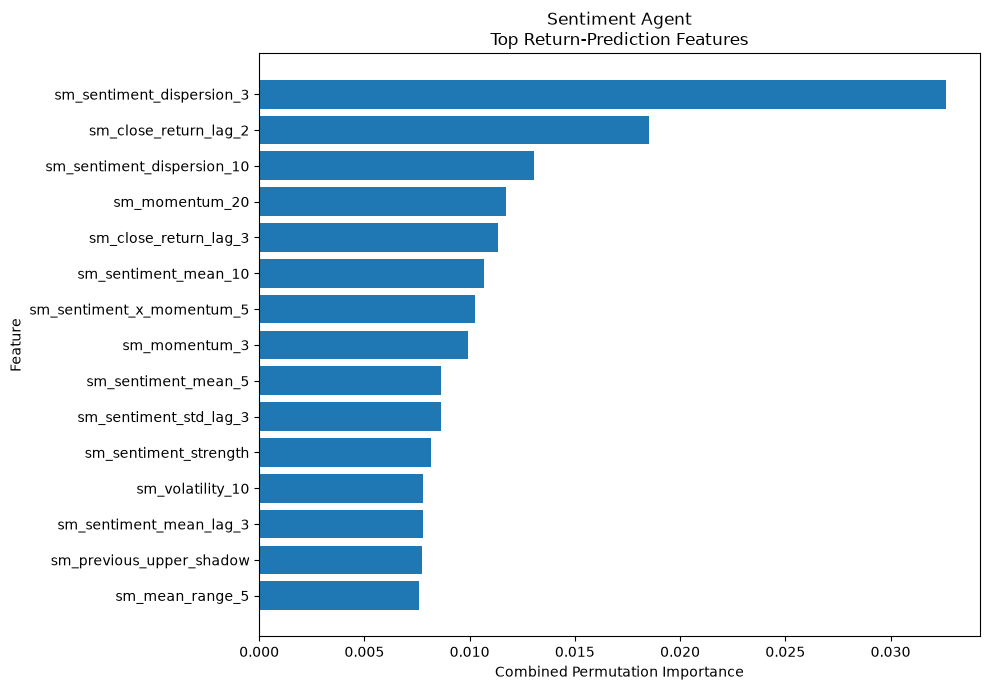

In [92]:
# Determine the list of feature importance
sm_classifier_importance = (
    permutation_importance(
        sm_classifier,
        X_sm_validation,
        y_sm_validation_class,
        scoring="f1",
        n_repeats=10,
        random_state=SM_RANDOM_SEED,
        n_jobs=-1,
    )
)

sm_regressor_importance = (
    permutation_importance(
        sm_regressor,
        X_sm_validation,
        y_sm_validation_return,
        scoring="neg_mean_squared_error",
        n_repeats=10,
        random_state=SM_RANDOM_SEED,
        n_jobs=-1,
    )
)

sm_feature_importance = pd.DataFrame(
    {
        "Feature":SM_MODEL_FEATURES,
        "Classifier Importance":sm_classifier_importance.importances_mean,
        "Return Model Importance":sm_regressor_importance.importances_mean,
    }
)

sm_feature_importance["Combined Importance"] = (sm_feature_importance["Classifier Importance"].abs() + 
                                                sm_feature_importance["Return Model Importance"].abs())
sm_feature_importance = (sm_feature_importance.sort_values( "Combined Importance", ascending=False, ))

display(sm_feature_importance.head(20))

# Plot top 15 features importance
sm_top_features = (sm_feature_importance.head(15).sort_values( "Combined Importance", ascending=True, ))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(sm_top_features["Feature"], sm_top_features["Combined Importance"], )
ax.set_xlabel("Combined Permutation Importance")
ax.set_ylabel("Feature")
ax.set_title("Sentiment Agent\n" "Top Return-Prediction Features")
plt.tight_layout()
plt.show()


In [93]:
# Define autonomous sentiment agent
class MLSentimentAgent(SentimentAgentBase):
    def __init__(
        self,
        classifier,
        regressor,
        feature_names,
        probability_threshold,
        expected_return_threshold,
        reject_threshold,
        model_version=SM_MODEL_VERSION,
    ):
        super().__init__(model_name=SM_MODEL_NAME, model_version=model_version, )

        self.classifier = classifier
        self.regressor = regressor
        self.feature_names = list(feature_names)
        self.probability_threshold = float(probability_threshold)
        self.expected_return_threshold = float(expected_return_threshold)
        self.reject_threshold = float(reject_threshold)

        classes = list(self.classifier.classes_)

        if 1 not in classes:
            raise ValueError("SM classifier lacks class 1.")

        self.positive_class_index = (classes.index(1))
        self.required_input_fields = list(dict.fromkeys( list( self.required_input_fields ) + self.feature_names ))

    def validate_inputs(self, packet, input_data):
        for feature_name in (self.feature_names):
            value = input_data[feature_name]

            if not isinstance(value, ( int, float, np.integer, np.floating, ), ):
                raise TypeError(f"{feature_name} must be numeric.")

            if not np.isfinite(value):
                raise ValueError(f"{feature_name} must be finite.")

    def create_feature_frame(self, input_data):
        return pd.DataFrame(
            [
                {
                    feature:float(input_data[feature])
                    for feature
                    in self.feature_names
                }
            ],
            columns=self.feature_names,
        )

    def process(self, packet, input_data, agent_run_id, started_at_utc):
        X = (self.create_feature_frame( input_data ))
        probability = float(self.classifier.predict_proba( X )[0, self.positive_class_index,])
        expected_return = float(self.regressor.predict( X )[0])

        if (probability >= self.probability_threshold and expected_return >= self.expected_return_threshold):
            recommendation = SentimentRecommendation.SUPPORT
        elif (probability <= self.reject_threshold):
            recommendation = SentimentRecommendation.REJECT
        else:
            recommendation = SentimentRecommendation.NEUTRAL
        classification_confidence = max(probability, 1.0 - probability, )

        scale = max(abs( self.expected_return_threshold ), 0.0025, )
        margin = (expected_return - self.expected_return_threshold)
        return_confidence = (1.0 / ( 1.0 + np.exp( -margin / scale ) ))

        if (recommendation != SentimentRecommendation.SUPPORT):
            return_confidence = (1.0 - return_confidence)

        confidence = float(np.clip( 0.70 * classification_confidence + 0.30 * return_confidence, 0.0, 1.0, ))

        evidence_names = [
            "previous_sentiment_mean",
            "previous_sentiment_std",
            "previous_news_count",
            "sm_opening_gap",
            "sm_previous_day_return",
            "sm_sentiment_consistency",
            "sm_coverage_weighted_sentiment",
        ]
        evidence = [
            EvidenceItem(
                feature_name=name,
                feature_value=float(input_data[name]),
                description=("Leakage-safe SM evidence feature."),
            )
            for name in evidence_names
        ]
        evidence.append(
            EvidenceItem(
                feature_name=("sm_expected_net_return"),
                feature_value=(expected_return),
                description=("Regression estimate of net " "Open-to-Close return."),
            )
        )

        return SentimentOutput(
            agent_id=self.agent_id,
            agent_run_id=agent_run_id,
            model_name=self.model_name,
            model_version=self.model_version,
            status=AgentRunStatus.RUNNING,
            started_at_utc=started_at_utc,
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=confidence,
            input_feature_names=list(self.feature_names),
            evidence=evidence,
            warnings=[],
            error_message=None,
            recommendation=recommendation,
            sentiment_score=float(np.clip( probability, 0.0, 1.0, )),
            predicted_profit_probability=(probability),
            support_threshold=(self.probability_threshold),
            reject_threshold=(self.reject_threshold),
        )

sentiment_agent = MLSentimentAgent(
    classifier=sm_classifier,
    regressor=sm_regressor,
    feature_names=SM_MODEL_FEATURES,
    probability_threshold=(SM_BUY_PROBABILITY_THRESHOLD),
    expected_return_threshold=(SM_EXPECTED_RETURN_THRESHOLD),
    reject_threshold=(SM_REJECT_PROBABILITY_THRESHOLD),
)

print("Sentiment Agent instantiated.")


Sentiment Agent instantiated.


,Predicted NO_TRADE,Predicted BUY
Actual NO_TRADE,155,5
Actual BUY,130,12


,Metric,Value
0,Accuracy,0.552980
1,Balanced Accuracy,0.526629
2,Precision - BUY,0.705882
3,Recall - BUY,0.084507
4,F1 Score - BUY,0.150943
5,Specificity - NO_TRADE,0.968750
6,ROC-AUC,0.499648
7,True Positive,12.000000
8,False Positive,5.000000
9,True Negative,155.000000


              precision    recall  f1-score   support

    NO_TRADE     0.5439    0.9688    0.6966       160
         BUY     0.7059    0.0845    0.1509       142

    accuracy                         0.5530       302
   macro avg     0.6249    0.5266    0.4238       302
weighted avg     0.6200    0.5530    0.4400       302



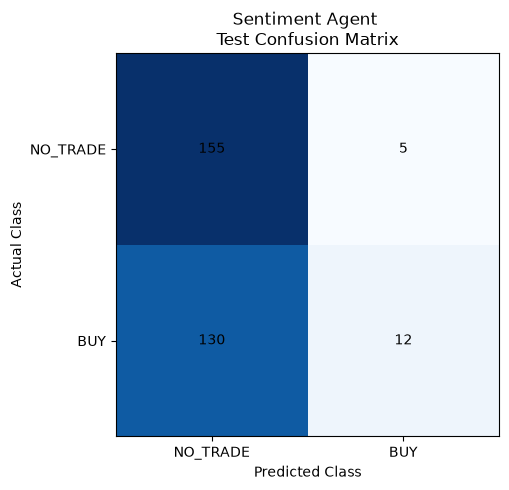

In [94]:
# Perform final test classification and plot confusion matrix
sm_test_probabilities = (sm_classifier.predict_proba( X_sm_test )[:, 1])
sm_test_expected_returns = (sm_regressor.predict( X_sm_test ))
sm_test_predictions = (
    (sm_test_probabilities >= SM_BUY_PROBABILITY_THRESHOLD)
    &
    (sm_test_expected_returns >= SM_EXPECTED_RETURN_THRESHOLD)
).astype(int)

sm_cm_array = confusion_matrix(y_sm_test, sm_test_predictions, labels=[0, 1], )
sm_tn, sm_fp, sm_fn, sm_tp = (sm_cm_array.ravel())
sm_confusion_matrix = pd.DataFrame(
    sm_cm_array,
    index=[
        "Actual NO_TRADE",
        "Actual BUY",
    ],
    columns=[
        "Predicted NO_TRADE",
        "Predicted BUY",
    ],
)

sm_accuracy = accuracy_score(y_sm_test, sm_test_predictions, )
sm_balanced_accuracy = (balanced_accuracy_score( y_sm_test, sm_test_predictions, ))
sm_precision = precision_score(y_sm_test, sm_test_predictions, zero_division=0, )
sm_recall = recall_score(y_sm_test, sm_test_predictions, zero_division=0, )
sm_f1 = f1_score(y_sm_test, sm_test_predictions, zero_division=0, )
sm_specificity = (sm_tn / ( sm_tn + sm_fp ) if ( sm_tn + sm_fp ) > 0 else np.nan)
sm_roc_auc = roc_auc_score(y_sm_test, sm_test_probabilities, )
sm_classification_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision - BUY",
            "Recall - BUY",
            "F1 Score - BUY",
            "Specificity - NO_TRADE",
            "ROC-AUC",
            "True Positive",
            "False Positive",
            "True Negative",
            "False Negative",
        ],
        "Value": [
            sm_accuracy,
            sm_balanced_accuracy,
            sm_precision,
            sm_recall,
            sm_f1,
            sm_specificity,
            sm_roc_auc,
            sm_tp,
            sm_fp,
            sm_tn,
            sm_fn,
        ],
    }
)

display(sm_confusion_matrix)
display(sm_classification_metrics)
print(
    classification_report(
        y_sm_test,
        sm_test_predictions,
        target_names=["NO_TRADE","BUY",],
        digits=4,
        zero_division=0,
    )
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(sm_cm_array, cmap = "Blues", )
ax.set_xticks([0, 1], labels=["NO_TRADE", "BUY",], )
ax.set_yticks([0, 1], labels=["NO_TRADE", "BUY",], )
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Sentiment Agent \nTest Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str( sm_cm_array[i, j] ), ha="center", va="center", )

plt.tight_layout()
plt.show()


In [95]:
# Fresh portfolio state for the current SM execution
sm_portfolio_state = PortfolioState(
    initial_capital=(specification.execution.initial_capital),
    current_capital=(specification.execution.initial_capital),
)

# SM is the autonomous decision-making agent and EX does NOT re-evaluate SM probability and confidence
# EX only translates the final SM BUY / NO_TRADE signal into deterministic execution
sm_execution_policy = ExecutionPolicy(

    # MA is not present in Configuration 2. These thresholds are therefore disabled.
    ma_probability_threshold=0.0,
    ma_confidence_threshold=0.0,

    # SM ML thresholds are already applied in SM.
    # Setting these to zero prevents EX from performing another ML-level filtering step.
    sm_support_probability_threshold=0.0,
    sm_confidence_threshold=0.0,

    # RM is not present in Configuration 2.
    rm_maximum_risk_score=1.0,
    rm_confidence_threshold=0.0,

    # Execution mechanics remain unchanged.
    fixed_position_fraction=(specification.execution.fixed_position_fraction),
    transaction_cost_bps_per_side=(specification.execution.transaction_cost_bps_per_side),
    slippage_bps_per_side=(specification.execution.slippage_bps_per_side),

    # Keep market-data validation.
    require_valid_close_for_execution=True,
)

sm_execution_policy.validate()

print("SM Execution Policy:")
print("SM probability gate in EX:", sm_execution_policy.sm_support_probability_threshold, )
print("SM confidence gate in EX:", sm_execution_policy.sm_confidence_threshold, )
print("Require valid Close:", sm_execution_policy.require_valid_close_for_execution, )

# Native deterministic execution agent
sm_execution_agent = (
    DeterministicExecutionAgent(
        portfolio_state=(sm_portfolio_state),
        policy=(sm_execution_policy),
        model_version=("EX_CONFIG2_SM_NATIVE_V1"),
    )
)

# Native structured feflection agent
if ("reflection_policy" in globals()):
    sm_reflection_agent = (
        StructuredDiagnosticReflectionAgent(policy=( reflection_policy ), model_version=( "RF_CONFIG2_SM_NATIVE_V1" ), )
    )
else:
    sm_reflection_agent = (StructuredDiagnosticReflectionAgent( model_version=( "RF_CONFIG2_SM_NATIVE_V1" ), ))

# Communication registry
sm_registry = AgentRegistry()
sm_registry.register(sentiment_agent)
sm_registry.register(sm_execution_agent)
sm_registry.register(sm_reflection_agent)

# Validate revised Configuration 2 topology
expected_sm_route = [
    AgentID.SENTIMENT,
    AgentID.EXECUTION,
    AgentID.REFLECTION,
]

actual_sm_route = (CONFIGURATION_AGENTS[ConfigurationID.CONFIGURATION_2])

if (actual_sm_route != expected_sm_route):
    raise ValueError(
        "Configuration 2 architecture mismatch. "
        "Expected SM -> EX -> RF, received "
        f"{[agent.value for agent in actual_sm_route]}."
    )

for agent_id in (expected_sm_route):
    if not sm_registry.contains(agent_id):
        raise ValueError(f"SM registry missing " f"{agent_id.value}.")

print("Native Configuration 2 registry validated:")
print(" -> ".join( agent.value for agent in expected_sm_route ))

SM Execution Policy:
SM probability gate in EX: 0.0
SM confidence gate in EX: 0.0
Require valid Close: True
Native Configuration 2 registry validated:
SM -> EX -> RF


In [96]:
# Run the configuration 2 setup
sm_dataset_version = (
    f"AMZN_SM_"
    f"{sm_train_data.index.min():%Y%m%d}_"
    f"{sm_test_data.index.max():%Y%m%d}_"
    f"N{len(sm_train_data) + len(sm_test_data)}"
)

def run_sm_configuration(test_data, symbol, specification, dataset_version, registry):
    expected_route = [
        AgentID.SENTIMENT,
        AgentID.EXECUTION,
        AgentID.REFLECTION,
    ]

    configured_route = (CONFIGURATION_AGENTS[ConfigurationID.CONFIGURATION_2])

    if configured_route != expected_route:
        raise ValueError("Configuration 2 must be SM -> EX -> RF.")

    daily_records = []
    reflection_records = []
    packets = []

    for decision_date, row in (test_data.iterrows()):
        packet = (
            create_packet_from_aligned_row(
                row=row,
                symbol=symbol,
                configuration_id=(ConfigurationID.CONFIGURATION_2),
                specification=(specification),
                dataset_version=(dataset_version),
            )
        )

        for feature_name in (SM_MODEL_FEATURES):
            packet.sentiment_data[
                feature_name
            ] = float(row[feature_name])

        registry.get(AgentID.SENTIMENT).run(packet)
        registry.get(AgentID.EXECUTION).run(packet)
        registry.get(AgentID.REFLECTION).run(packet)

        sm_output = packet.sentiment_output
        ex_output = packet.execution_output
        rf_output = packet.reflection_output
        feature_frame = pd.DataFrame(
            [
                {
                    feature:float(row[feature])
                    for feature
                    in SM_MODEL_FEATURES
                }
            ],
            columns=SM_MODEL_FEATURES,
        )

        expected_return = float(sm_regressor.predict( feature_frame )[0])

        daily_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "configuration_id":packet.metadata.configuration_id.value,
                "actual_class":int(row["target_profitable"]),
                "predicted_class":int(sm_output.recommendation == SentimentRecommendation.SUPPORT),
                "sm_recommendation":sm_output.recommendation.value,
                "predicted_profit_probability":sm_output.predicted_profit_probability,
                "sm_expected_return":expected_return,
                "sm_confidence":sm_output.confidence_score,
                "trade_executed":ex_output.trade_executed,
                "entry_price":ex_output.entry_price,
                "exit_price":ex_output.exit_price,
                "gross_return":ex_output.gross_return,
                "transaction_cost_return":ex_output.transaction_cost_return,
                "slippage_return":ex_output.slippage_return,
                "net_return":ex_output.net_return,
                "capital_before":ex_output.capital_before,
                "capital_after":ex_output.capital_after,
                "reflection_category":rf_output.category.value,
                "explainability_score":rf_output.explainability_score,
            }
        )

        reflection_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "sm_recommendation":sm_output.recommendation.value,
                "sm_probability":sm_output.predicted_profit_probability,
                "sm_expected_return":expected_return,
                "sm_confidence":sm_output.confidence_score,
                "trade_executed":ex_output.trade_executed,
                "net_return":ex_output.net_return,
                "reflection_category":rf_output.category.value,
                "decision_summary":rf_output.decision_summary,
                "outcome_summary":rf_output.outcome_summary,
                "explainability_score":rf_output.explainability_score,
            }
        )

        packets.append(packet)

    return (
        pd.DataFrame(daily_records).set_index("date"),
        pd.DataFrame(reflection_records).set_index("date"),
        packets,
    )

(sm_daily_results, sm_reflection_log, sm_packets, ) = run_sm_configuration(
    test_data=sm_test_data,
    symbol="AMZN",
    specification=specification,
    dataset_version=sm_dataset_version,
    registry=sm_registry,
)

packet_predictions = (sm_daily_results["predicted_class"].astype(int).to_numpy())

if not np.array_equal(packet_predictions, sm_test_predictions, ):
    raise ValueError("Direct SM and packet predictions differ.")

print("Configuration 2 completed.")
print("Executed trades:", int( sm_daily_results["trade_executed"].sum() ), )


Configuration 2 completed.
Executed trades: 17


In [97]:
# SM trading performance and baseline comparison
def calculate_sm_trading_metrics(
    daily_returns,
    initial_capital=100_000.0,
    trading_days_per_year=252,
    annual_risk_free_rate=0.0,
):
    returns = pd.Series(daily_returns, dtype=float, ).fillna(0.0)
    n = len(returns)
    equity = (initial_capital * ( 1.0 + returns ).cumprod())
    final_value = float(equity.iloc[-1])
    total_return = (final_value / initial_capital - 1.0)
    annualized_return = (( 1.0 + total_return ) ** ( trading_days_per_year / n ) - 1.0)
    annualized_volatility = (returns.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    daily_rf = (( 1.0 + annual_risk_free_rate ) ** ( 1.0 / trading_days_per_year ) - 1.0)
    excess = returns - daily_rf
    excess_std = excess.std(ddof=1)

    if excess_std > 0:
        sharpe = (excess.mean() / excess_std * np.sqrt( trading_days_per_year ))
    else:
        sharpe = np.nan

    peak = equity.cummax()
    drawdown = (equity / peak - 1.0)
    max_drawdown = float(drawdown.min())
    downside = (returns[returns < 0])

    if (len(downside) > 1 and downside.std( ddof=1 ) > 0):
        sortino = (excess.mean() / downside.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    else:
        sortino = np.nan

    calmar = (annualized_return / abs(max_drawdown) if max_drawdown < 0 else np.nan)
    trades = returns[returns != 0]
    number_of_trades = int(len(trades))
    winning_trades = int(( trades > 0 ).sum())
    losing_trades = int(( trades < 0 ).sum())
    win_rate = (winning_trades / number_of_trades if number_of_trades else np.nan)

    return {
        "Initial Capital":float(initial_capital),
        "Final Portfolio Value":final_value,
        "Total Return":float(total_return),
        "Annualized Return":float(annualized_return),
        "Annualized Volatility":float(annualized_volatility),
        "Sharpe Ratio":float(sharpe),
        "Maximum Drawdown":float(max_drawdown),
        "Sortino Ratio":float(sortino),
        "Calmar Ratio":float(calmar),
        "Number of Trades":number_of_trades,
        "Winning Trades":winning_trades,
        "Losing Trades":losing_trades,
        "Win Rate":float(win_rate)
            if np.isfinite(win_rate)
            else np.nan,
    }

sm_trading_metrics = (
    calculate_sm_trading_metrics(
        sm_daily_results[
            "net_return"
        ],
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

sm_baseline_test_results = (sm_baseline_results.reindex( sm_test_data.index ))

if (sm_baseline_test_results["net_strategy_return"].isna().any()):
    raise ValueError("Baseline missing one or more SM test dates.")

sm_baseline_trading_metrics = (
    calculate_sm_trading_metrics(
        sm_baseline_test_results["net_strategy_return"],
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

metric_order = [
    "Initial Capital",
    "Final Portfolio Value",
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Sortino Ratio",
    "Calmar Ratio",
    "Number of Trades",
    "Winning Trades",
    "Losing Trades",
    "Win Rate",
]

sm_vs_baseline_performance = pd.DataFrame(
    [
        {
            "Metric":metric,
            "Baseline Test":sm_baseline_trading_metrics[metric],
            "SM Agent Test":sm_trading_metrics[metric],
            "Difference":(sm_trading_metrics[metric] - sm_baseline_trading_metrics[metric]),
        }
        for metric in metric_order
    ]
)

display(sm_vs_baseline_performance)


,Metric,Baseline Test,SM Agent Test,Difference
0,Initial Capital,100000.000000,100000.000000,0.000000
1,Final Portfolio Value,101536.116228,108031.426195,6495.309967
2,Total Return,0.015361,0.080314,0.064953
3,Annualized Return,0.012802,0.066585,0.053783
4,Annualized Volatility,0.034288,0.064416,0.030128
5,Sharpe Ratio,0.388114,1.032814,0.644700
6,Maximum Drawdown,-0.026007,-0.035910,-0.009903
7,Sortino Ratio,0.082412,0.331364,0.248952
8,Calmar Ratio,0.492242,1.854242,1.362000
9,Number of Trades,9.000000,17.000000,8.000000


Common plot start date: 2025-05-22 00:00:00
Common plot end date: 2026-07-30 00:00:00
Baseline visible start: 2025-05-21 12:00:00
SM visible start: 2025-05-21 12:00:00
Baseline starting capital: 100000.0
SM starting capital: 100000.0


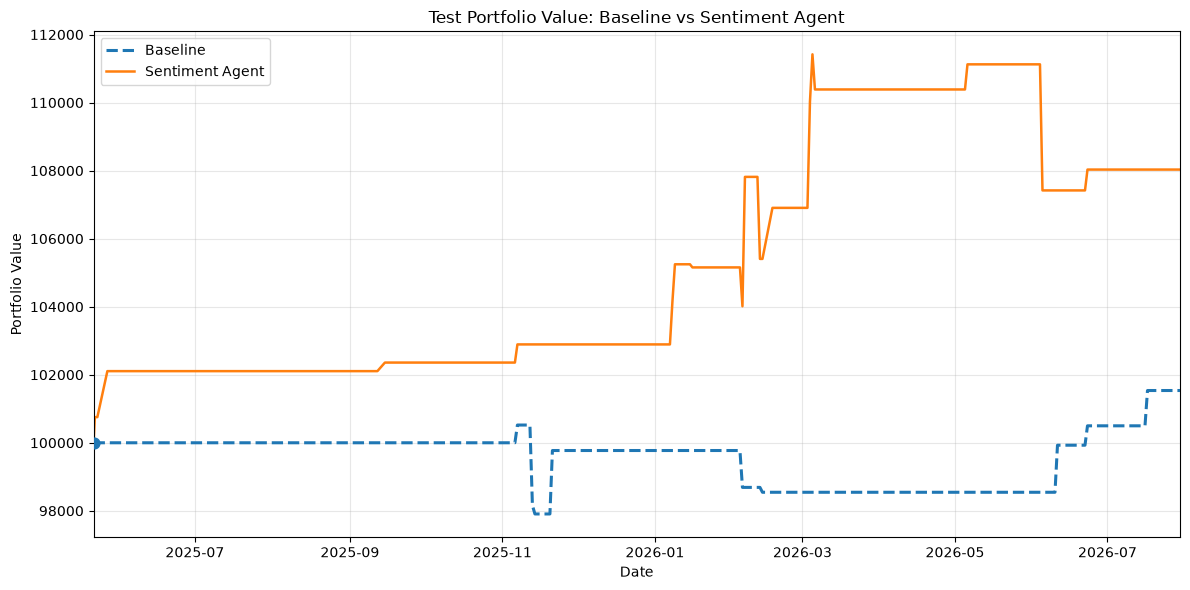

In [98]:
# Plot SM equity curve against baseline

# Initial capital
initial_capital = specification.execution.initial_capital

# Identify the first sentiment agent trade date
if "trade_executed" not in sm_daily_results.columns:
    raise ValueError("sm_daily_results must contain 'trade_executed'.")

sm_executed_trade_dates = (sm_daily_results.index[sm_daily_results["trade_executed"].astype(bool)])

if len(sm_executed_trade_dates) == 0:
    raise ValueError("No Sentiment Agent trades are available " "for the equity-curve plot.")

sm_plot_start_date = (sm_executed_trade_dates.min())
sm_plot_end_date = (sm_daily_results.index.max())

print("Common plot start date:", sm_plot_start_date, )
print("Common plot end date:", sm_plot_end_date, )

# Create identical plot index
sm_plot_index = (sm_daily_results.loc[sm_plot_start_date: sm_plot_end_date].index)

# Use the same baseline test-result object used in the SM performance comparison.
if "sm_baseline_test_results" in globals():
    sm_baseline_plot_returns = (
        sm_baseline_test_results["net_strategy_return"]
        .reindex(sm_plot_index)
        .fillna(0.0)
        .astype(float)
    )
else:
    # Fallback if the generic baseline object is used.
    sm_baseline_plot_returns = (
        rm_baseline_results["net_strategy_return"]
        .reindex(sm_plot_index)
        .fillna(0.0)
        .astype(float)
    )

# Sentiment agent returns
if "net_return" not in sm_daily_results.columns:
    raise ValueError("sm_daily_results must contain 'net_return'.")

sm_agent_plot_returns = (sm_daily_results["net_return"].reindex( sm_plot_index ).fillna(0.0).astype(float))

# Rebase both to same initial capital
sm_baseline_equity_plot = (initial_capital * ( 1.0 + sm_baseline_plot_returns ).cumprod())
sm_agent_equity_plot = (initial_capital * ( 1.0 + sm_agent_plot_returns ).cumprod())

# Set the common starting capital that make the plot visually explicit.
first_date = (sm_plot_index.min())
plot_initial_date = (first_date - pd.Timedelta( hours=12 ))
sm_baseline_equity_plot = pd.concat([pd.Series( {plot_initial_date: initial_capital} ), sm_baseline_equity_plot,])
sm_agent_equity_plot = pd.concat([pd.Series( {plot_initial_date: initial_capital} ), sm_agent_equity_plot,])

# Validate alignment
if not (sm_baseline_equity_plot.index.equals( sm_agent_equity_plot.index )):
    raise ValueError("Baseline and Sentiment Agent equity curves " "do not have identical dates.")

print("Baseline visible start:", sm_baseline_equity_plot.index.min(), )
print("SM visible start:", sm_agent_equity_plot.index.min(), )
print("Baseline starting capital:", sm_baseline_equity_plot.iloc[0], )
print("SM starting capital:", sm_agent_equity_plot.iloc[0], )

# Plot baseline with dashed line so overlapping sections remain visible.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    sm_baseline_equity_plot.index,
    sm_baseline_equity_plot,
    label="Baseline",
    linestyle="--",
    linewidth=2.2,
    zorder=3,
)
ax.plot(
    sm_agent_equity_plot.index,
    sm_agent_equity_plot,
    label="Sentiment Agent",
    linestyle="-",
    linewidth=1.8,
    zorder=2,
)

# Mark the common start date
ax.scatter([plot_initial_date], [initial_capital], s=60, zorder=5, )

# Setup the plot details
ax.set_title("Test Portfolio Value: " "Baseline vs Sentiment Agent")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3, )
ax.set_xlim(plot_initial_date, sm_plot_end_date, )
plt.tight_layout()
plt.show()

In [99]:
# Saves SM output to files 
sm_test_decision_log = (sm_daily_results.copy())
SM_OUTPUT_DIRECTORY = Path("data/model2/step6_sm_sentiment_agent_outputs")
SM_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True, )
sm_confusion_matrix.to_csv(SM_OUTPUT_DIRECTORY / "sm_test_confusion_matrix.csv")
sm_classification_metrics.to_csv(SM_OUTPUT_DIRECTORY / "sm_classification_metrics.csv", index=False, )
sm_feature_importance.to_csv(SM_OUTPUT_DIRECTORY / "sm_feature_importance.csv", index=False, )
sm_model_selection_results.to_csv(SM_OUTPUT_DIRECTORY / "sm_model_selection_results.csv", index=False, )
sm_vs_baseline_performance.to_csv(SM_OUTPUT_DIRECTORY / "sm_baseline_vs_agent_performance.csv", index=False, )
sm_daily_results.to_csv(SM_OUTPUT_DIRECTORY / "sm_test_daily_results.csv")
sm_reflection_log.to_csv(SM_OUTPUT_DIRECTORY / "sm_reflection_log.csv")
# sm_success_summary.to_csv(SM_OUTPUT_DIRECTORY / "sm_success_criteria.csv", index=False, )

print("SM outputs saved to:", SM_OUTPUT_DIRECTORY.resolve(), )


SM outputs saved to: C:\Users\yeobp\Desktop\Python\DBA-AIML-Walsh\MS-AIML\Capstone\FinalVersion\data\model2\step6_sm_sentiment_agent_outputs


#### Step 7: Risk Management Agent (Uses Machine Learning)

In [101]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

RM_RANDOM_SEED = 42

RM_MODEL_NAME = "AutonomousSelectiveRiskAdjustedAgent"
RM_MODEL_VERSION = "RM_AUTONOMOUS_SELECTIVE_V1"

# Training parameter specification
# BUY represents approximately the best 6% realised risk-adjusted opportunities in the development sample.
RM_TARGET_BUY_RATE = 0.06

# Realised utility: net_return - penalty * realised_downside
RM_REALIZED_DOWNSIDE_PENALTY = 0.50

# Material downside remains useful for diagnostic risk evidence.
RM_MATERIAL_DOWNSIDE_QUANTILE = 0.60

# Selective predicted BUY-rate requirement during development.
RM_MIN_BUY_RATE = 0.03
RM_MAX_BUY_RATE = 0.08

# Direct classifier probability thresholds.
RM_PROBABILITY_THRESHOLDS = np.round(np.arange( 0.10, 0.91, 0.02, ), 2, ).tolist()

# Final held-out Criterion 2 requirements
RM_MIN_PRECISION = 0.50
RM_MIN_RECALL = 0.25
RM_MIN_F1 = 0.33

# Development-stage minimums.
RM_DEVELOPMENT_MIN_PRECISION = 0.40
RM_DEVELOPMENT_MIN_RECALL = 0.20
RM_DEVELOPMENT_MIN_F1 = 0.25

# Walk-forward configuration
RM_WALK_FORWARD_FOLDS = 4
RM_INITIAL_TRAIN_FRACTION = 0.50

# Candidate tail quantiles for supporting RM risk evidence.
RM_TAIL_QUANTILES = [0.80, 0.90]

print("Autonomous selective RM configuration loaded.")


Autonomous selective RM configuration loaded.


In [102]:
# Step 1-4 verification
required_rm_objects = [
    "train_data",
    "validation_data",
    "test_data",
    "specification",
    "CONFIGURATION_AGENTS",
    "RiskManagementAgentBase",
    "RiskManagementOutput",
    "RiskRecommendation",
    "RiskLevel",
    "AgentRunStatus",
    "AgentID",
    "ConfigurationID",
    "EvidenceItem",
    "PortfolioState",
    "ExecutionPolicy",
    "DeterministicExecutionAgent",
    "StructuredDiagnosticReflectionAgent",
    "AgentRegistry",
    "create_packet_from_aligned_row",
]

missing_rm_objects = [
    name
    for name in required_rm_objects
    if name not in globals()
]

if missing_rm_objects:
    raise NameError("Run updated Step 1 and Steps 2-4 first. " f"Missing objects: {missing_rm_objects}")

expected_config3 = [
    AgentID.RISK_MANAGEMENT,
    AgentID.EXECUTION,
    AgentID.REFLECTION,
]

actual_config3 = CONFIGURATION_AGENTS[
    ConfigurationID.CONFIGURATION_3
]

if actual_config3 != expected_config3:
    raise ValueError(
        "Configuration 3 must be RM -> EX -> RF. "
        f"Current route: {[agent.value for agent in actual_config3]}"
    )

print("Configuration 3:", " -> ".join(agent.value for agent in actual_config3), )


Configuration 3: RM -> EX -> RF


In [103]:
# Load baseline for test period performance comparison only
baseline_candidates = [
    Path("baseline_strategy.csv"),
    Path("data/baseline_strategy.csv"),
    Path("/mnt/data/baseline_strategy.csv"),
]

RM_BASELINE_FILE_PATH = next(( path for path in baseline_candidates if path.exists() ), None, )

if RM_BASELINE_FILE_PATH is None:
    raise FileNotFoundError("baseline_strategy.csv was not found.")

rm_baseline_results = pd.read_csv(RM_BASELINE_FILE_PATH)

if "Date" not in rm_baseline_results.columns:
    raise ValueError("baseline_strategy.csv must contain Date.")

if "net_strategy_return" not in rm_baseline_results.columns:
    raise ValueError("baseline_strategy.csv must contain net_strategy_return.")

rm_baseline_results["Date"] = pd.to_datetime(rm_baseline_results["Date"])
rm_baseline_results = (rm_baseline_results.set_index("Date").sort_index())

print("Baseline loaded:", RM_BASELINE_FILE_PATH, )
print("NOTE: Baseline is used only for performance comparison, " "not as an RM trade filter.")


Baseline loaded: data\baseline_strategy.csv
NOTE: Baseline is used only for performance comparison, not as an RM trade filter.


In [104]:
# Master source data with leakage-safe feature engineering
rm_all_data = pd.concat([train_data, validation_data, test_data,], axis=0, ).sort_index()

if rm_all_data.index.duplicated().any():
    raise ValueError("Duplicate dates detected in RM source data.")

RM_VOLUME_COLUMN = "volume" if "volume" in rm_all_data.columns else "Volume"
RM_VIX_COLUMN = "vix" if "vix" in rm_all_data.columns else "VIX"
RM_CPI_COLUMN = "cpi" if "cpi" in rm_all_data.columns else "CPI"
required_raw_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    RM_VOLUME_COLUMN,
    RM_VIX_COLUMN,
    RM_CPI_COLUMN,
]

missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in rm_all_data.columns
]

if missing_raw_columns:
    raise ValueError(f"RM source data missing: {missing_raw_columns}")


def create_rm_selective_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy().sort_index()
    eps = 1e-8

    previous_open = df["Open"].shift(1)
    previous_high = df["High"].shift(1)
    previous_low = df["Low"].shift(1)
    previous_close = df["Close"].shift(1)

    previous_range = (previous_high - previous_low).clip(lower=eps)

    # OHLC features available before today's Open.
    df["rm_previous_day_return"] = (previous_close / previous_open - 1.0)
    df["rm_opening_gap"] = (df["Open"] / previous_close - 1.0)
    df["rm_previous_range_ratio"] = (( previous_high - previous_low ) / previous_open)
    df["rm_previous_body_ratio"] = (( previous_close - previous_open ) / previous_open)
    df["rm_previous_body_to_range"] = (( previous_close - previous_open ) / previous_range)
    df["rm_previous_close_location"] = (( previous_close - previous_low ) / previous_range)
    df["rm_previous_upper_shadow"] = (( previous_high - np.maximum( previous_open, previous_close, ) ) / previous_open)
    df["rm_previous_lower_shadow"] = (( np.minimum( previous_open, previous_close, ) - previous_low ) / previous_open)
    close_return = df["Close"].pct_change()

    for lag in [1, 2, 3, 5]:
        df[f"rm_close_return_lag_{lag}"] = close_return.shift(lag)

    for window in [3, 5, 10, 20]:
        df[f"rm_momentum_{window}"] = (previous_close / df["Close"].shift( window + 1 ) - 1.0)

    for window in [5, 10, 20]:
        df[f"rm_realized_volatility_{window}"] = (close_return.shift(1).rolling(window).std())

    historical_range = (( df["High"] - df["Low"] ) / df["Open"])

    for window in [3, 5, 10, 20]:
        df[f"rm_historical_range_{window}"] = (historical_range.shift(1).rolling(window).mean())

    # Lagged volume features.
    volume = (df[RM_VOLUME_COLUMN].astype(float))
    df["rm_previous_volume"] = (volume.shift(1))
    df["rm_log_previous_volume"] = (np.log1p( df["rm_previous_volume"].clip(lower=0) ))
    df["rm_volume_change_1"] = (volume.pct_change().shift(1))

    for window in [5, 10, 20]:
        volume_mean = (volume.shift(1).rolling(window).mean())
        volume_std = (volume.shift(1).rolling(window).std())
        df[f"rm_volume_ratio_{window}"] = (df["rm_previous_volume"] / volume_mean)
        df[f"rm_volume_zscore_{window}"] = (( df["rm_previous_volume"] - volume_mean ) / ( volume_std + eps ))

    # Lagged VIX features.
    vix = (df[RM_VIX_COLUMN].astype(float))
    df["previous_vix"] = (vix.shift(1))
    df["rm_vix_change_1"] = (vix.diff().shift(1))
    df["rm_vix_pct_change_1"] = (vix.pct_change().shift(1))

    for window in [3, 5, 10, 20]:
        vix_mean = (vix.shift(1).rolling(window).mean())
        vix_std = (vix.shift(1).rolling(window).std())
        df[f"rm_vix_mean_{window}"] = vix_mean
        df[f"rm_vix_deviation_{window}"] = (df["previous_vix"] / vix_mean - 1.0)
        df[f"rm_vix_zscore_{window}"] = (( df["previous_vix"] - vix_mean ) / ( vix_std + eps ))

    # CPI regime features.
    cpi = (df[RM_CPI_COLUMN].astype(float))
    df["previous_cpi"] = (cpi.shift(1))
    df["rm_cpi_change_1"] = (cpi.diff().shift(1))
    df["rm_cpi_pct_change_1"] = (cpi.pct_change().shift(1))
    df["rm_cpi_change_21"] = (cpi.diff(21).shift(1))
    df["rm_cpi_pct_change_21"] = (cpi.pct_change(21).shift(1))

    # Risk interactions.
    df["rm_vix_x_gap"] = (df["previous_vix"] * df["rm_opening_gap"].abs())
    df["rm_vix_x_previous_return"] = (df["previous_vix"] * df["rm_previous_day_return"].abs())
    df["rm_volume_x_range"] = (df["rm_volume_ratio_20"] * df["rm_previous_range_ratio"])
    df["rm_volume_x_gap"] = (df["rm_volume_ratio_20"] * df["rm_opening_gap"].abs())
    df["rm_vix_x_volume"] = (df["previous_vix"] * df["rm_volume_ratio_20"])

    # Net Open-to-Close opportunity return.
    if ("net_open_to_close_return" not in df.columns):
        total_cost_rate = (2.0 * (specification.execution.transaction_cost_bps_per_side + specification.execution.slippage_bps_per_side) / 10_000.0)
        df["net_open_to_close_return"] = (df["Close"] / df["Open"] - 1.0 - total_cost_rate)

    # Realised downside.
    df["rm_realized_mae"] = (( df["Open"] - df["Low"] ) / df["Open"]).clip(lower=0.0)
    df["rm_realized_loss"] = (-df["net_open_to_close_return"]).clip(lower=0.0)
    df["rm_realized_downside"] = np.maximum(df["rm_realized_loss"], df["rm_realized_mae"], )
    df["rm_realized_utility"] = (df["net_open_to_close_return"] - RM_REALIZED_DOWNSIDE_PENALTY * df["rm_realized_downside"])

    return df.replace([np.inf, -np.inf], np.nan, )

rm_all_data = (create_rm_selective_features( rm_all_data ))
print("RM leakage-safe features and realised utility created.")


RM leakage-safe features and realised utility created.


In [105]:
# Selective feature calibration, apply only to training dataset
RM_MODEL_FEATURES = [
    "rm_previous_day_return",
    "rm_opening_gap",
    "rm_previous_range_ratio",
    "rm_previous_body_ratio",
    "rm_previous_body_to_range",
    "rm_previous_close_location",
    "rm_previous_upper_shadow",
    "rm_previous_lower_shadow",

    "rm_close_return_lag_1",
    "rm_close_return_lag_2",
    "rm_close_return_lag_3",
    "rm_close_return_lag_5",

    "rm_momentum_3",
    "rm_momentum_5",
    "rm_momentum_10",
    "rm_momentum_20",

    "rm_realized_volatility_5",
    "rm_realized_volatility_10",
    "rm_realized_volatility_20",

    "rm_historical_range_3",
    "rm_historical_range_5",
    "rm_historical_range_10",
    "rm_historical_range_20",

    "rm_previous_volume",
    "rm_log_previous_volume",
    "rm_volume_change_1",
    "rm_volume_ratio_5",
    "rm_volume_ratio_10",
    "rm_volume_ratio_20",
    "rm_volume_zscore_5",
    "rm_volume_zscore_10",
    "rm_volume_zscore_20",

    "previous_vix",
    "rm_vix_change_1",
    "rm_vix_pct_change_1",
    "rm_vix_mean_3",
    "rm_vix_mean_5",
    "rm_vix_mean_10",
    "rm_vix_mean_20",
    "rm_vix_deviation_3",
    "rm_vix_deviation_5",
    "rm_vix_deviation_10",
    "rm_vix_deviation_20",
    "rm_vix_zscore_3",
    "rm_vix_zscore_5",
    "rm_vix_zscore_10",
    "rm_vix_zscore_20",

    "previous_cpi",
    "rm_cpi_change_1",
    "rm_cpi_pct_change_1",
    "rm_cpi_change_21",
    "rm_cpi_pct_change_21",

    "rm_vix_x_gap",
    "rm_vix_x_previous_return",
    "rm_volume_x_range",
    "rm_volume_x_gap",
    "rm_vix_x_volume",
]

rm_development_index = (train_data.index.union( validation_data.index ))
rm_development_raw = (rm_all_data.loc[rm_development_index]
    .copy()
    .dropna(subset=( RM_MODEL_FEATURES + ["net_open_to_close_return", "rm_realized_downside", "rm_realized_utility",] ))
)

rm_test_data = (rm_all_data.loc[test_data.index]
    .copy()
    .dropna(subset=( RM_MODEL_FEATURES + ["net_open_to_close_return", "rm_realized_downside", "rm_realized_utility",] ))
)

if (rm_development_raw.index.max() >= rm_test_data.index.min()):
    raise ValueError("RM development and test periods overlap.")

# Downside threshold.
RM_MATERIAL_DOWNSIDE_THRESHOLD = float(
    np.quantile(rm_development_raw["rm_realized_downside"].to_numpy(dtype=float), RM_MATERIAL_DOWNSIDE_QUANTILE,))

# Selective BUY utility threshold.
# Top ~6% development risk-adjusted opportunities = BUY.
RM_REALIZED_UTILITY_THRESHOLD = float(
    np.quantile(rm_development_raw["rm_realized_utility"].to_numpy(dtype=float), 1.0 - RM_TARGET_BUY_RATE,))

# Fixed thresholds are then applied to both development and test.
rm_all_data["rm_downside_event"] = (rm_all_data["rm_realized_downside"] >= RM_MATERIAL_DOWNSIDE_THRESHOLD).astype(int)
rm_all_data["rm_actual_buy"] = (rm_all_data["rm_realized_utility"] >= RM_REALIZED_UTILITY_THRESHOLD).astype(int)
rm_train_data = (rm_all_data.loc[rm_development_raw.index].copy())
rm_test_data = (rm_all_data.loc[rm_test_data.index].copy())

X_rm_development = (rm_train_data[RM_MODEL_FEATURES].astype(float).copy())
X_rm_test = (rm_test_data[RM_MODEL_FEATURES].astype(float).copy())

y_rm_development_buy = (rm_train_data["rm_actual_buy"].astype(int).copy())
y_rm_test_actual_buy = (rm_test_data["rm_actual_buy"].astype(int).copy())
y_rm_development_downside = (rm_train_data["rm_downside_event"].astype(int).copy())
y_rm_development_tail = (rm_train_data["rm_realized_downside"].astype(float).copy())

rm_class_distribution = pd.DataFrame(
    [
        {
            "Partition":"Development",
            "Observations":len(rm_train_data),
            "Actual BUY":int(rm_train_data["rm_actual_buy"].sum()),
            "Actual NO_TRADE":int(( rm_train_data["rm_actual_buy"] == 0 ).sum()),
            "BUY Rate":float(rm_train_data["rm_actual_buy"].mean()),
        },
        {
            "Partition":"Test",
            "Observations":len(rm_test_data),
            "Actual BUY":int(rm_test_data["rm_actual_buy"].sum()),
            "Actual NO_TRADE":int(( rm_test_data["rm_actual_buy"] == 0 ).sum()),
            "BUY Rate":float(rm_test_data["rm_actual_buy"].mean()),
        },
    ]
)

print("=" * 80)
print("RM SELECTIVE TARGET CALIBRATION")
print("=" * 80)

print("Target development BUY rate:", f"{RM_TARGET_BUY_RATE:.2%}", )
print("Realised utility threshold:", f"{RM_REALIZED_UTILITY_THRESHOLD:.6f}", )
print("Material downside threshold:", f"{RM_MATERIAL_DOWNSIDE_THRESHOLD:.6f}", )
print("=" * 80)

display(rm_class_distribution)


RM SELECTIVE TARGET CALIBRATION
Target development BUY rate: 6.00%
Realised utility threshold: 0.023450
Material downside threshold: 0.012983


,Partition,Observations,Actual BUY,Actual NO_TRADE,BUY Rate
0,Development,1179,71,1108,0.060221
1,Test,302,8,294,0.026490


In [106]:
# RM trading metric utility/helper functions
def calculate_rm_selection_metrics(strategy_returns, trading_days=252):
    returns = np.asarray(strategy_returns, dtype=float, )
    total_return = float(np.prod( 1.0 + returns ) - 1.0)
    std_return = float(np.std( returns, ddof=1, ))
    sharpe_ratio = (float( np.mean( returns ) / std_return * np.sqrt( trading_days ) ) if std_return > 0 else np.nan)
    trade_returns = (returns[returns != 0])
    number_of_trades = int(len( trade_returns ))
    win_rate = (float( np.mean( trade_returns > 0 ) ) if number_of_trades > 0 else np.nan)
    average_trade_return = (float( np.mean( trade_returns ) ) if number_of_trades > 0 else np.nan)
    equity = np.cumprod(1.0 + returns)

    if len(equity) > 0:
        peak = (np.maximum.accumulate( equity ))
        maximum_drawdown = float(np.min( equity / peak - 1.0 ))
    else:
        maximum_drawdown = np.nan
    return {
        "total_return":total_return,
        "sharpe_ratio":sharpe_ratio,
        "number_of_trades":number_of_trades,
        "win_rate":win_rate,
        "average_trade_return":average_trade_return,
        "maximum_drawdown":maximum_drawdown,
    }

def calculate_rm_trading_metrics(
    daily_returns,
    initial_capital=100_000.0,
    trading_days_per_year=252,
    annual_risk_free_rate=0.0,
):
    returns = pd.Series(daily_returns, dtype=float, ).fillna(0.0)

    if len(returns) == 0:
        raise ValueError("Trading return series is empty.")

    equity = (initial_capital * ( 1.0 + returns ).cumprod())
    final_value = float(equity.iloc[-1])
    total_return = (final_value / initial_capital - 1.0)
    annualized_return = (( 1.0 + total_return ) ** ( trading_days_per_year / len( returns ) ) - 1.0)
    annualized_volatility = float(returns.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    daily_rf = (( 1.0 + annual_risk_free_rate ) ** ( 1.0 / trading_days_per_year ) - 1.0)
    excess = (returns - daily_rf)
    excess_std = float(excess.std( ddof=1 ))
    sharpe = (float( excess.mean() / excess_std * np.sqrt( trading_days_per_year ) ) if excess_std > 0 else np.nan)
    running_peak = (equity.cummax())
    maximum_drawdown = float(( equity / running_peak - 1.0 ).min())
    downside = (returns[returns < 0])
    downside_std = (downside.std( ddof=1 ) if len(downside) > 1 else np.nan)

    sortino = (
        float(excess.mean() / downside_std * np.sqrt( trading_days_per_year ))
        if (np.isfinite( downside_std ) and downside_std > 0)
        else np.nan
    )

    calmar = (float( annualized_return / abs( maximum_drawdown ) ) if maximum_drawdown < 0 else np.nan)
    trades = (returns[returns != 0])
    number_of_trades = int(len( trades ))
    winning_trades = int(( trades > 0 ).sum())
    losing_trades = int(( trades < 0 ).sum())
    win_rate = (float( winning_trades / number_of_trades ) if number_of_trades > 0 else np.nan)
    average_trade_return = (float( trades.mean() ) if number_of_trades > 0 else np.nan)

    return {
        "Initial Capital":float(initial_capital),
        "Final Portfolio Value":final_value,
        "Total Return":float(total_return),
        "Annualized Return":float(annualized_return),
        "Annualized Volatility":annualized_volatility,
        "Sharpe Ratio":sharpe,
        "Maximum Drawdown":maximum_drawdown,
        "Sortino Ratio":sortino,
        "Calmar Ratio":calmar,
        "Number of Trades":number_of_trades,
        "Winning Trades":winning_trades,
        "Losing Trades":losing_trades,
        "Win Rate":win_rate,
        "Average Trade Return":average_trade_return,
    }

print("RM trading metric helpers loaded.")


RM trading metric helpers loaded.


In [107]:
# List of candidate model for model selection: directly predicts the selective RM BUY class.
rm_buy_classifier_candidates = {
    "ExtraTreesBUY":
        ExtraTreesClassifier(
            n_estimators=600,
            max_depth=8,
            min_samples_leaf=4,
            min_samples_split=8,
            class_weight="balanced",
            max_features="sqrt",
            random_state=RM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "RandomForestBUY":
        RandomForestClassifier(
            n_estimators=600,
            max_depth=8,
            min_samples_leaf=4,
            min_samples_split=8,
            class_weight="balanced",
            max_features="sqrt",
            random_state=RM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "HistGradientBoostingBUY":
        HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=350,
            max_leaf_nodes=15,
            min_samples_leaf=12,
            l2_regularization=8.0,
            random_state=RM_RANDOM_SEED,
        ),
}

# Supporting downside classifier.
rm_downside_classifier_candidates = {
    "ExtraTreesDownside":
        ExtraTreesClassifier(
            n_estimators=500,
            max_depth=7,
            min_samples_leaf=8,
            min_samples_split=16,
            class_weight="balanced",
            max_features="sqrt",
            random_state=RM_RANDOM_SEED,
            n_jobs=-1,
        ),

    "HistGradientBoostingDownside":
        HistGradientBoostingClassifier(
            learning_rate=0.03,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=10.0,
            random_state=RM_RANDOM_SEED,
        ),
}

# Supporting tail-downside regressors.
rm_tail_regressor_candidates = {}

for tail_quantile in (RM_TAIL_QUANTILES):
    rm_tail_regressor_candidates[
        f"TailQuantile_{tail_quantile:.2f}"
    ] = (
        HistGradientBoostingRegressor(
            loss="quantile",
            quantile=tail_quantile,
            learning_rate=0.03,
            max_iter=300,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=10.0,
            random_state=RM_RANDOM_SEED,
        )
    )

print("Primary BUY classifiers:", list( rm_buy_classifier_candidates ), )
print("Supporting downside classifiers:", list( rm_downside_classifier_candidates ), )
print("Supporting tail regressors:", list( rm_tail_regressor_candidates ), )


Primary BUY classifiers: ['ExtraTreesBUY', 'RandomForestBUY', 'HistGradientBoostingBUY']
Supporting downside classifiers: ['ExtraTreesDownside', 'HistGradientBoostingDownside']
Supporting tail regressors: ['TailQuantile_0.80', 'TailQuantile_0.90']


In [108]:
# Walk=forward buy model with probability-gate selection

# Create chronological walk-forward splits
rm_n_development = len(X_rm_development)
rm_initial_train_size = int(rm_n_development * RM_INITIAL_TRAIN_FRACTION)
rm_remaining_size = (rm_n_development - rm_initial_train_size)
rm_validation_block_size = (rm_remaining_size // RM_WALK_FORWARD_FOLDS)

if rm_validation_block_size < 20:
    raise ValueError("Walk-forward validation blocks are too small.")

rm_walk_forward_splits = []

for fold_number in range(RM_WALK_FORWARD_FOLDS):
    train_end = (rm_initial_train_size + fold_number * rm_validation_block_size)
    validation_start = train_end
    if (fold_number == RM_WALK_FORWARD_FOLDS - 1):
        validation_end = rm_n_development
    else:
        validation_end = (validation_start + rm_validation_block_size)
    rm_walk_forward_splits.append(( np.arange( 0, train_end, ), np.arange( validation_start, validation_end, ), ))

# Cache walk-forward fold data
rm_fold_cache = {}
rm_walk_forward_summary_records = []

for (fold_number, ( train_positions, validation_positions, ), ) in enumerate(rm_walk_forward_splits, start=1, ):
    X_fold_train = (X_rm_development.iloc[train_positions].copy())
    X_fold_validation = (X_rm_development.iloc[validation_positions].copy())
    validation_index = X_fold_validation.index
    
    rm_fold_cache[fold_number] = {
        "X_train":X_fold_train,
        "X_validation":X_fold_validation,
        "y_buy_train":y_rm_development_buy.iloc[train_positions].copy(),
        "actual_buy":y_rm_development_buy.iloc[validation_positions].astype(int).to_numpy(),
        "realised_returns":rm_train_data.loc[validation_index,"net_open_to_close_return",].astype(float).to_numpy(),
        "validation_index":validation_index,
    }

    rm_walk_forward_summary_records.append(
        {
            "Fold":fold_number,
            "Train Start":X_fold_train.index.min(),
            "Train End":X_fold_train.index.max(),
            "Train N":len(X_fold_train),
            "Train BUY Rate":float(y_rm_development_buy.iloc[train_positions].mean()),
            "Validation Start":validation_index.min(),
            "Validation End":validation_index.max(),
            "Validation N":len(validation_index),
            "Validation BUY Rate":float(y_rm_development_buy.iloc[validation_positions].mean()),
        }
    )

rm_walk_forward_summary = pd.DataFrame(rm_walk_forward_summary_records)

print("=" * 80)
print("RM WALK-FORWARD DEVELOPMENT SPLITS")
print("=" * 80)

display(rm_walk_forward_summary)

# Fit each buy classifier once per fold and cache valiation probabilities
rm_buy_classifier_cache = {}

for (classifier_name, classifier_candidate, ) in rm_buy_classifier_candidates.items():
    rm_buy_classifier_cache[classifier_name] = {}

    for fold_number in range(1, RM_WALK_FORWARD_FOLDS + 1, ):
        fold_data = (rm_fold_cache[fold_number])
        classifier = clone(classifier_candidate)
        classifier.fit(fold_data["X_train"], fold_data["y_buy_train"], )
        classes = list(classifier.classes_)
        if 1 not in classes:
            raise RuntimeError(f"{classifier_name} " f"fold {fold_number} " "did not learn BUY class 1.")
        buy_class_index = (classes.index(1))
        validation_probability = (classifier.predict_proba( fold_data["X_validation"] )[:, buy_class_index])
        rm_buy_classifier_cache[classifier_name][fold_number] = {"validation_probability":validation_probability,}

print("Primary BUY-classifier OOF cache completed.")

# Search probability thresholds
rm_selection_records = []
rm_fold_selection_records = []

for classifier_name in (rm_buy_classifier_candidates.keys()):
    # Pool OOF actual labels
    oof_actual_buy = np.concatenate(
        [
            rm_fold_cache[fold_number]["actual_buy"]
            for fold_number
            in range(1, RM_WALK_FORWARD_FOLDS + 1, )
        ]
    )

    # Pool OOF BUY probabilities
    oof_probability = np.concatenate(
        [
            rm_buy_classifier_cache[classifier_name][fold_number]["validation_probability"]
            for fold_number
            in range(1, RM_WALK_FORWARD_FOLDS + 1, )
        ]
    )

    # Pool realised OOF Open-to-Close returns
    oof_realised_returns = np.concatenate(
        [
            rm_fold_cache[fold_number]["realised_returns"]
            for fold_number
            in range(1, RM_WALK_FORWARD_FOLDS + 1, )
        ]
    )

    # Evaluate every candidate probability threshold
    for probability_threshold in (RM_PROBABILITY_THRESHOLDS):
        predicted_buy = (oof_probability >= probability_threshold).astype(int)

        # Reject one-class solutions
        if (np.unique( predicted_buy ).size < 2):
            continue
        buy_count = int(predicted_buy.sum())
        buy_rate = float(predicted_buy.mean())

        # Preserve selective RM activity
        if not (RM_MIN_BUY_RATE <= buy_rate <= RM_MAX_BUY_RATE):
            continue

        # Classification metrics
        precision = precision_score(oof_actual_buy, predicted_buy, zero_division=0, )
        recall = recall_score(oof_actual_buy, predicted_buy, zero_division=0, )
        f1 = f1_score(oof_actual_buy, predicted_buy, zero_division=0, )
        balanced_accuracy = (balanced_accuracy_score( oof_actual_buy, predicted_buy, ))

        try:
            roc_auc = roc_auc_score(oof_actual_buy, oof_probability, )
        except ValueError:
            roc_auc = np.nan

        try:
            average_precision = (average_precision_score( oof_actual_buy, oof_probability, ))
        except ValueError:
            average_precision = np.nan

        # OOF trading performance
        strategy_returns = np.where(predicted_buy == 1, oof_realised_returns, 0.0, )
        pooled_metrics = (calculate_rm_selection_metrics( strategy_returns ))
        pooled_sharpe = (pooled_metrics["sharpe_ratio"])

        if not np.isfinite(pooled_sharpe):
            pooled_sharpe = 0.0

        # Fold-level stability
        fold_returns = []
        fold_sharpes = []
        fold_buy_rates = []

        for fold_number in range(1, RM_WALK_FORWARD_FOLDS + 1, ):
            fold_data = (rm_fold_cache[fold_number])
            fold_probability = (rm_buy_classifier_cache[classifier_name][fold_number]["validation_probability"])
            fold_prediction = (fold_probability >= probability_threshold).astype(int)
            fold_strategy_returns = np.where(fold_prediction == 1, fold_data["realised_returns"], 0.0, )
            fold_metrics = (calculate_rm_selection_metrics( fold_strategy_returns ))
            fold_sharpe = (fold_metrics["sharpe_ratio"])

            if not np.isfinite(fold_sharpe):
                fold_sharpe = 0.0

            fold_returns.append(fold_metrics["total_return"])
            fold_sharpes.append(fold_sharpe)
            fold_buy_rates.append(float( fold_prediction.mean() ))
            rm_fold_selection_records.append(
                {
                    "classifier":classifier_name,
                    "probability_threshold":probability_threshold,
                    "fold":fold_number,
                    "fold_buy_count":int(fold_prediction.sum()),
                    "fold_buy_rate":float(fold_prediction.mean()),
                    "fold_return":fold_metrics["total_return"],
                    "fold_sharpe":fold_sharpe,
                }
            )

        return_stability = float(np.std( np.asarray( fold_returns, dtype=float, ), ddof=0, ))
        sharpe_stability = float(np.std( np.asarray( fold_sharpes, dtype=float, ), ddof=0, ))

        # Classification requirement
        classification_pass = bool(
            precision>=RM_DEVELOPMENT_MIN_PRECISION
            and
            recall>=RM_DEVELOPMENT_MIN_RECALL
            and
            f1>=RM_DEVELOPMENT_MIN_F1
        )

        # Economic requirement
        average_trade_return = (pooled_metrics["average_trade_return"])

        if not np.isfinite(average_trade_return):
            average_trade_return = 0.0

        economic_pass = bool(pooled_metrics["total_return"] > 0 and pooled_sharpe > 0 and average_trade_return > 0)

        # Multi-objective score. Used only after classification requirements pass. 
        # Fallback selection will primarily use Balanced Accuracy instead.
        objective_score = (
            1.75*pooled_metrics["total_return"]
            + 0.35*pooled_sharpe
            + 0.55*f1
            + 0.25*precision
            + 0.20*recall
            + 0.15*balanced_accuracy
            + 0.10*(average_precision if np.isfinite( average_precision ) else 0.0)
            + 0.15*pooled_metrics["maximum_drawdown"]
            - 0.40*return_stability
            - 0.05*sharpe_stability
        )

        # Save best candidate
        rm_selection_records.append(
            {
                "classifier":classifier_name,
                "probability_threshold":probability_threshold,
                "buy_count":buy_count,
                "buy_rate":buy_rate,
                "balanced_accuracy":balanced_accuracy,
                "precision":precision,
                "recall":recall,
                "f1":f1,
                "roc_auc":roc_auc,
                "average_precision":average_precision,
                "total_return":pooled_metrics["total_return"],
                "sharpe_ratio":pooled_sharpe,
                "maximum_drawdown":pooled_metrics["maximum_drawdown"],
                "win_rate":pooled_metrics["win_rate"],
                "average_trade_return":average_trade_return,
                "number_of_trades":pooled_metrics["number_of_trades"],
                "return_stability":return_stability,
                "sharpe_stability":sharpe_stability,
                "classification_pass":classification_pass,
                "economic_pass":economic_pass,
                "objective_score":objective_score,
            }
        )

# Build training model-selection tables
rm_model_selection_results = pd.DataFrame(rm_selection_records)
rm_fold_selection_results = pd.DataFrame(rm_fold_selection_records)

if rm_model_selection_results.empty:
    raise RuntimeError(
        "No non-degenerate selective RM candidates were "
        "generated within the development 3%-8% BUY-rate range."
    )

# Training diagnostic summary
print()
print("=" * 80)
print("SELECTIVE AUTONOMOUS RM DEVELOPMENT DIAGNOSTICS")
print("=" * 80)

print("Valid candidates:", len( rm_model_selection_results ), )
print("Classification-pass candidates:", int( rm_model_selection_results["classification_pass"].sum() ), )
print("Classification + economic candidates:",
    int(( rm_model_selection_results["classification_pass"] & rm_model_selection_results["economic_pass"] ).sum()),)
print("Maximum Balanced Accuracy:", f"{rm_model_selection_results['balanced_accuracy'].max():.4f}", )
print("Maximum Precision:", f"{rm_model_selection_results['precision'].max():.4f}", )
print("Maximum Recall:", f"{rm_model_selection_results['recall'].max():.4f}", )
print("Maximum F1:", f"{rm_model_selection_results['f1'].max():.4f}", )
print("Maximum OOF Total Return:", f"{rm_model_selection_results['total_return'].max():.4%}", )
print("Maximum OOF Sharpe:", f"{rm_model_selection_results['sharpe_ratio'].max():.4f}", )
print("=" * 80)

# Model selection tiers
# Tier 1: classification constraints + positive economics
rm_tier_1 = (
    rm_model_selection_results[
        (rm_model_selection_results["classification_pass"])
        &
        (rm_model_selection_results["economic_pass"])
    ].copy()
)

# Tier 2: classification constraints satisfied
rm_tier_2 = (rm_model_selection_results[rm_model_selection_results["classification_pass"]].copy())

# 8. DETERMINE SELECTION MODE
if not rm_tier_1.empty:
    rm_eligible_models = (rm_tier_1.copy())
    RM_SELECTION_TIER = "Tier 1 - classification requirements " "+ positive OOF economics"
    RM_SELECTION_FALLBACK_USED = False

elif not rm_tier_2.empty:
    rm_eligible_models = (rm_tier_2.copy())
    RM_SELECTION_TIER = "Tier 2 - classification requirements satisfied"
    RM_SELECTION_FALLBACK_USED = False

else:
    # Based on balanced accuracy
    rm_eligible_models = (rm_model_selection_results.copy())
    RM_SELECTION_TIER = "Development fallback - highest Balanced Accuracy"
    RM_SELECTION_FALLBACK_USED = True

    print()
    print("=" * 80)
    print("WARNING: NO RM CANDIDATE PASSED ALL " "DEVELOPMENT CLASSIFICATION THRESHOLDS")
    print("=" * 80)

    print("The best available DEVELOPMENT candidate will " "therefore be selected using Balanced Accuracy.")
    print("This does NOT mean Criterion 2 has passed.")
    print("The final held-out 20% test set remains untouched.")
    print("=" * 80)

# Select best candidate model
if RM_SELECTION_FALLBACK_USED:
    rm_best_configuration = (
        rm_eligible_models
        .sort_values(
            by=[
                "balanced_accuracy",
                "f1",
                "precision",
                "recall",
                "average_precision",
                "total_return",
                "sharpe_ratio",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

else:
    # When constraints pass, retain the multi-objective training ranking.
    # --------------------------------------------------------
    rm_best_configuration = (
        rm_eligible_models
        .sort_values(
            by=[
                "objective_score",
                "balanced_accuracy",
                "f1",
                "total_return",
                "sharpe_ratio",
            ],
            ascending=[
                False,
                False,
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

# Save selected configuration
RM_SELECTED_BUY_CLASSIFIER = (rm_best_configuration["classifier"])
RM_SELECTED_BUY_THRESHOLD = float(rm_best_configuration["probability_threshold"])

# Display the selected model
print()
print("=" * 80)
print("SELECTED AUTONOMOUS RM BUY MODEL")
print("=" * 80)

print("Selection tier:", RM_SELECTION_TIER, )
print("Fallback used:", RM_SELECTION_FALLBACK_USED, )
print("Classifier:", RM_SELECTED_BUY_CLASSIFIER, )
print("Probability threshold:", RM_SELECTED_BUY_THRESHOLD, )
print("OOF BUY count:", int( rm_best_configuration["buy_count"] ), )
print("OOF BUY rate:", f"{rm_best_configuration['buy_rate']:.2%}", )
print("OOF Balanced Accuracy:", f"{rm_best_configuration['balanced_accuracy']:.4f}", )
print("OOF Precision:", f"{rm_best_configuration['precision']:.4f}", )
print("OOF Recall:", f"{rm_best_configuration['recall']:.4f}", )
print("OOF F1:", f"{rm_best_configuration['f1']:.4f}", )
print("OOF ROC-AUC:", f"{rm_best_configuration['roc_auc']:.4f}", )
print("OOF Average Precision:", f"{rm_best_configuration['average_precision']:.4f}", )
print("OOF Total Return:", f"{rm_best_configuration['total_return']:.4%}", )
print("OOF Sharpe Ratio:", f"{rm_best_configuration['sharpe_ratio']:.4f}", )
print("Development classification pass:", bool( rm_best_configuration["classification_pass"] ), )
print("Development economic pass:", bool( rm_best_configuration["economic_pass"] ), )
print("=" * 80)

# Selected model summary table
rm_selected_model_summary = pd.DataFrame(
    {
        "Parameter": [
            "Selection Tier",
            "Fallback Used",
            "Classifier",
            "Probability Threshold",
            "OOF BUY Count",
            "OOF BUY Rate",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "Average Precision",
            "OOF Total Return",
            "OOF Sharpe Ratio",
            "Classification Pass",
            "Economic Pass",
        ],
        "Value": [
            RM_SELECTION_TIER,
            RM_SELECTION_FALLBACK_USED,
            RM_SELECTED_BUY_CLASSIFIER,
            RM_SELECTED_BUY_THRESHOLD,
            int(rm_best_configuration["buy_count"]),
            float(rm_best_configuration["buy_rate"]),
            float(rm_best_configuration["balanced_accuracy"]),
            float(rm_best_configuration["precision"]),
            float(rm_best_configuration["recall"]),
            float(rm_best_configuration["f1"]),
            float(rm_best_configuration["roc_auc"]),
            float(rm_best_configuration["average_precision"]),
            float(rm_best_configuration["total_return"]),
            float(rm_best_configuration["sharpe_ratio"]),
            bool(rm_best_configuration["classification_pass"]),
            bool(rm_best_configuration["economic_pass"]),
        ],
    }
)

display(rm_selected_model_summary)

# Top model candidates by balanced accuracy
rm_top_balanced_accuracy_candidates = (
    rm_model_selection_results
    .sort_values(
        by=[
            "balanced_accuracy",
            "f1",
            "precision",
            "recall",
            "average_precision",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
        ],
    )
    [
        [
            "classifier",
            "probability_threshold",
            "buy_count",
            "buy_rate",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision",
            "total_return",
            "sharpe_ratio",
            "maximum_drawdown",
            "win_rate",
            "classification_pass",
            "economic_pass",
        ]
    ]
    .head(20)
)

print()
print("\nTop Risk Management Agent Configurations")
display_columns=['classifier','probability_threshold', 'precision','recall','f1','balanced_accuracy']
display(rm_top_balanced_accuracy_candidates[display_columns])

# Selected fold results
rm_selected_fold_results = (
    rm_fold_selection_results[
        (rm_fold_selection_results["classifier"] == RM_SELECTED_BUY_CLASSIFIER)
        &
        (rm_fold_selection_results["probability_threshold"] == RM_SELECTED_BUY_THRESHOLD)
    ]
    .copy()
)

print()
print("Selected model fold-level diagnostics:")

display(rm_selected_fold_results)

# 15. FINAL CELL-8 STATUS
print()
print("=" * 80)
print("CELL 8 COMPLETED")
print("=" * 80)

if RM_SELECTION_FALLBACK_USED:
    print("A best-available development candidate was selected " "using Balanced Accuracy.")
    print("The model did NOT satisfy all predefined development " "classification thresholds.")
    print("Proceed to Cell 9 for final development refit, then " "Cell 12 for independent held-out test evaluation.")
else:
    print("A candidate satisfying the development selection " "requirements was selected.")
    print("Proceed to Cell 9 for final development refit.")

print("=" * 80)

RM WALK-FORWARD DEVELOPMENT SPLITS


,Fold,Train Start,Train End,Train N,Train BUY Rate,Validation Start,Validation End,Validation N,Validation BUY Rate
0,1,2020-09-04,2023-01-06,589,0.073005,2023-01-09,2023-08-09,147,0.081633
1,2,2020-09-04,2023-08-09,736,0.074728,2023-08-10,2024-03-11,147,0.027211
2,3,2020-09-04,2024-03-11,883,0.066818,2024-03-12,2024-10-09,147,0.020408
3,4,2020-09-04,2024-10-09,1030,0.060194,2024-10-10,2025-05-15,149,0.060403


Primary BUY-classifier OOF cache completed.

SELECTIVE AUTONOMOUS RM DEVELOPMENT DIAGNOSTICS
Valid candidates: 7
Classification-pass candidates: 0
Classification + economic candidates: 0
Maximum Balanced Accuracy: 0.5545
Maximum Precision: 0.1739
Maximum Recall: 0.1429
Maximum F1: 0.1569
Maximum OOF Total Return: 23.7298%
Maximum OOF Sharpe: 0.9067

The best available DEVELOPMENT candidate will therefore be selected using Balanced Accuracy.
This does NOT mean Criterion 2 has passed.
The final held-out 20% test set remains untouched.

SELECTED AUTONOMOUS RM BUY MODEL
Selection tier: Development fallback - highest Balanced Accuracy
Fallback used: True
Classifier: ExtraTreesBUY
Probability threshold: 0.36
OOF BUY count: 23
OOF BUY rate: 3.90%
OOF Balanced Accuracy: 0.5545
OOF Precision: 0.1739
OOF Recall: 0.1429
OOF F1: 0.1569
OOF ROC-AUC: 0.6120
OOF Average Precision: 0.0910
OOF Total Return: 23.7298%
OOF Sharpe Ratio: 0.9067
Development classification pass: False
Development economic pa

,Parameter,Value
0,Selection Tier,Development fallback - highest Balanced Accuracy
1,Fallback Used,True
2,Classifier,ExtraTreesBUY
3,Probability Threshold,0.36
4,OOF BUY Count,23
5,OOF BUY Rate,0.038983
6,Balanced Accuracy,0.554525
7,Precision,0.173913
8,Recall,0.142857
9,F1,0.156863




Top Risk Management Agent Configurations


,classifier,probability_threshold,precision,recall,f1,balanced_accuracy
2,ExtraTreesBUY,0.36,0.173913,0.142857,0.156863,0.554525
1,ExtraTreesBUY,0.34,0.129032,0.142857,0.135593,0.547407
4,RandomForestBUY,0.32,0.111111,0.142857,0.125000,0.542959
0,ExtraTreesBUY,0.32,0.108108,0.142857,0.123077,0.542069
3,ExtraTreesBUY,0.38,0.166667,0.107143,0.130435,0.540226
5,RandomForestBUY,0.34,0.111111,0.107143,0.109091,0.532219
6,RandomForestBUY,0.36,0.090909,0.071429,0.080000,0.517921



Selected model fold-level diagnostics:


,classifier,probability_threshold,fold,fold_buy_count,fold_buy_rate,fold_return,fold_sharpe
8,ExtraTreesBUY,0.36,1,0,0.000000,0.000000,0.000000
9,ExtraTreesBUY,0.36,2,1,0.006803,0.014478,1.309307
10,ExtraTreesBUY,0.36,3,1,0.006803,0.002812,1.309307
11,ExtraTreesBUY,0.36,4,21,0.140940,0.216219,1.675133



CELL 8 COMPLETED
A best-available development candidate was selected using Balanced Accuracy.
The model did NOT satisfy all predefined development classification thresholds.
Proceed to Cell 9 for final development refit, then Cell 12 for independent held-out test evaluation.


In [109]:
# Validate required outputs
required_cell8_objects = [
    "RM_SELECTED_BUY_CLASSIFIER",
    "RM_SELECTED_BUY_THRESHOLD",
    "RM_SELECTION_TIER",
    "RM_SELECTION_FALLBACK_USED",
    "rm_best_configuration",
    "rm_buy_classifier_candidates",
    "rm_downside_classifier_candidates",
    "rm_tail_regressor_candidates",
    "X_rm_development",
    "y_rm_development_buy",
    "y_rm_development_downside",
    "y_rm_development_tail",
]

missing_cell8_objects = [
    name
    for name in required_cell8_objects
    if name not in globals()
]

if missing_cell8_objects:
    raise NameError("Run Cells 1-8 first. Missing required objects: " f"{missing_cell8_objects}")

if (RM_SELECTED_BUY_CLASSIFIER not in rm_buy_classifier_candidates):
    raise KeyError(
        "Selected BUY classifier is not present in "
        "rm_buy_classifier_candidates: "
        f"{RM_SELECTED_BUY_CLASSIFIER}"
    )

print("=" * 80)
print("FINAL DEVELOPMENT REFIT")
print("=" * 80)

print("Selection tier:", RM_SELECTION_TIER, )
print("Balanced-Accuracy fallback used:", RM_SELECTION_FALLBACK_USED, )
print("Primary BUY classifier:", RM_SELECTED_BUY_CLASSIFIER, )
print("Frozen BUY threshold:", RM_SELECTED_BUY_THRESHOLD, )
print("=" * 80)

# Refit selected buy classifier using the complete 80% training dataset
rm_buy_classifier = clone(rm_buy_classifier_candidates[RM_SELECTED_BUY_CLASSIFIER])
rm_buy_classifier.fit(X_rm_development, y_rm_development_buy, )
rm_buy_classes = list(rm_buy_classifier.classes_)

if 1 not in rm_buy_classes:
    raise RuntimeError("Final RM BUY classifier does not contain BUY class 1.")

RM_BUY_CLASS_INDEX = (rm_buy_classes.index(1))
print("Primary BUY classifier fitted successfully.")

# Select supporting downside classifier. This uses a chronological 75% / 25% split INSIDE the training dataset 
# It is completely independent of the final test set.
rm_downside_model_scores = []
rm_support_split_point = int(len( X_rm_development ) * 0.75)

if (rm_support_split_point <= 0 or rm_support_split_point >= len( X_rm_development )):
    raise ValueError("Invalid supporting-model development split.")

X_rm_support_train = (X_rm_development.iloc[:rm_support_split_point].copy())
X_rm_support_validation = (X_rm_development.iloc[rm_support_split_point:].copy())
y_rm_downside_support_train = (y_rm_development_downside.iloc[:rm_support_split_point].copy())
y_rm_downside_support_validation = (y_rm_development_downside.iloc[rm_support_split_point:].copy())

for (model_name, model_candidate, ) in rm_downside_classifier_candidates.items():
    supporting_model = clone(model_candidate)
    supporting_model.fit(X_rm_support_train, y_rm_downside_support_train, )
    supporting_prediction = (supporting_model.predict( X_rm_support_validation ))
    supporting_balanced_accuracy = (balanced_accuracy_score( y_rm_downside_support_validation, supporting_prediction, ))
    rm_downside_model_scores.append({"model": model_name, "balanced_accuracy": supporting_balanced_accuracy,})

rm_downside_model_selection = (
    pd.DataFrame(rm_downside_model_scores)
    .sort_values(by=["balanced_accuracy", "model",], ascending=[False, True,], )
    .reset_index(drop=True)
)

if rm_downside_model_selection.empty:
    raise RuntimeError("No supporting downside classifier was evaluated.")

RM_SELECTED_DOWNSIDE_CLASSIFIER = (rm_downside_model_selection.iloc[0]["model"])
rm_downside_classifier = clone(rm_downside_classifier_candidates[RM_SELECTED_DOWNSIDE_CLASSIFIER])
rm_downside_classifier.fit(X_rm_development, y_rm_development_downside, )
rm_downside_classes = list(rm_downside_classifier.classes_)

if 1 not in rm_downside_classes:
    raise RuntimeError("Final downside classifier does not contain " "downside-event class 1.")

RM_DOWNSIDE_CLASS_INDEX = (rm_downside_classes.index(1))

# Select supporting tail-downside regressor
available_tail_models = list(rm_tail_regressor_candidates.keys())

if len(available_tail_models) == 0:
    raise RuntimeError("rm_tail_regressor_candidates contains no models.")

# Prefer 0.90 because RM uses the model as conservative tail-risk evidence.
preferred_tail_candidates = [
    "TailQuantile_0.90",
    "TailQuantile_0.80",
]

RM_SELECTED_TAIL_REGRESSOR = None

for candidate_name in (preferred_tail_candidates):
    if (candidate_name in rm_tail_regressor_candidates):
        RM_SELECTED_TAIL_REGRESSOR = candidate_name
        break

# Generic fallback protects against future name changes.
if RM_SELECTED_TAIL_REGRESSOR is None:
    RM_SELECTED_TAIL_REGRESSOR = (sorted( available_tail_models )[-1])

print("Available tail regressors:", available_tail_models, )
print("Selected tail regressor:", RM_SELECTED_TAIL_REGRESSOR, )
rm_tail_regressor = clone(rm_tail_regressor_candidates[RM_SELECTED_TAIL_REGRESSOR])
rm_tail_regressor.fit(X_rm_development, y_rm_development_tail, )

# Calculate training tail scale
# Used only to normalize predicted tail downside for the diagnostic risk score. It does NOT determine BUY/NO_TRADE.
rm_development_tail_prediction = np.clip(rm_tail_regressor.predict( X_rm_development ), 0.0, None, )
RM_TAIL_SCALE = float(np.quantile( rm_development_tail_prediction, 0.90, ))

if (not np.isfinite( RM_TAIL_SCALE ) or RM_TAIL_SCALE <= 0.0):
    RM_TAIL_SCALE = float(np.max( rm_development_tail_prediction ))

if (not np.isfinite( RM_TAIL_SCALE ) or RM_TAIL_SCALE <= 0.0):
    RM_TAIL_SCALE = 1e-8

# 6. FINAL DEVELOPMENT SUMMARY
rm_final_model_summary = pd.DataFrame(
    {
        "Component": [
            "Primary BUY classifier",
            "BUY probability threshold",
            "Selection tier",
            "Fallback used",
            "Supporting downside classifier",
            "Supporting tail regressor",
            "Tail scale",
        ],
        "Value": [
            RM_SELECTED_BUY_CLASSIFIER,
            RM_SELECTED_BUY_THRESHOLD,
            RM_SELECTION_TIER,
            RM_SELECTION_FALLBACK_USED,
            RM_SELECTED_DOWNSIDE_CLASSIFIER,
            RM_SELECTED_TAIL_REGRESSOR,
            RM_TAIL_SCALE,
        ],
    }
)

display(rm_final_model_summary)

print()
print("Supporting downside-model validation:")
display(rm_downside_model_selection)

print("=" * 80)
print("CELL 9 COMPLETED")
print("All final models were fitted using development data only.")
print("The held-out 20% test data remains unused.")
print("=" * 80)

FINAL DEVELOPMENT REFIT
Selection tier: Development fallback - highest Balanced Accuracy
Balanced-Accuracy fallback used: True
Primary BUY classifier: ExtraTreesBUY
Frozen BUY threshold: 0.36
Primary BUY classifier fitted successfully.
Available tail regressors: ['TailQuantile_0.80', 'TailQuantile_0.90']
Selected tail regressor: TailQuantile_0.90


,Component,Value
0,Primary BUY classifier,ExtraTreesBUY
1,BUY probability threshold,0.36
2,Selection tier,Development fallback - highest Balanced Accuracy
3,Fallback used,True
4,Supporting downside classifier,HistGradientBoostingDownside
5,Supporting tail regressor,TailQuantile_0.90
6,Tail scale,0.034115



Supporting downside-model validation:


,model,balanced_accuracy
0,HistGradientBoostingDownside,0.559658
1,ExtraTreesDownside,0.558079


CELL 9 COMPLETED
All final models were fitted using development data only.
The held-out 20% test data remains unused.


Top 20 RM BUY classifier features:


,Feature,BUY Classifier Importance,Importance Std
0,rm_vix_mean_5,0.036951,0.010163
1,rm_vix_zscore_3,0.034873,0.008581
2,rm_vix_mean_10,0.033339,0.007786
3,previous_vix,0.032606,0.008861
4,previous_cpi,0.030699,0.011044
5,rm_historical_range_3,0.029627,0.003724
6,rm_realized_volatility_10,0.028870,0.008907
7,rm_volume_zscore_5,0.027402,0.008788
8,rm_realized_volatility_20,0.027335,0.009357
9,rm_vix_mean_20,0.026784,0.005994


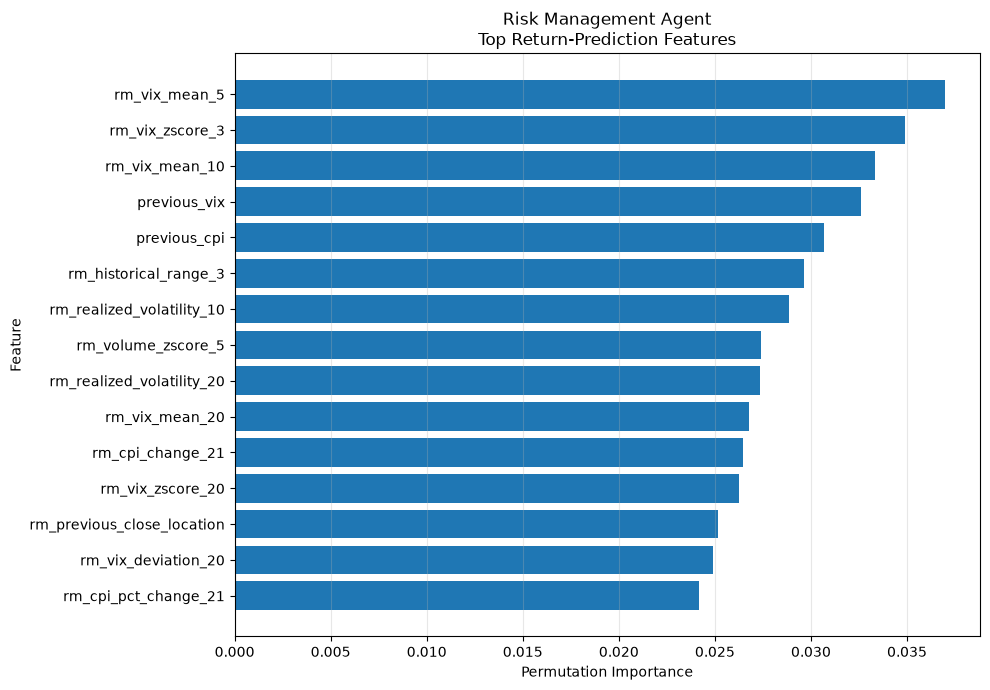

In [110]:
# Determine the selected buy classifier feature importance
rm_feature_importance_result = (
    permutation_importance(
        rm_buy_classifier,
        X_rm_development,
        y_rm_development_buy,
        scoring="balanced_accuracy",
        n_repeats=8,
        random_state=RM_RANDOM_SEED,
        n_jobs=-1,
    )
)

rm_feature_importance = pd.DataFrame(
    {
        "Feature":RM_MODEL_FEATURES,
        "BUY Classifier Importance":rm_feature_importance_result.importances_mean,
        "Importance Std":rm_feature_importance_result.importances_std,
    }
)

rm_feature_importance = (
    rm_feature_importance
    .sort_values(by=["BUY Classifier Importance", "Feature",], ascending=[False, True,], )
    .reset_index(drop=True)
)

print("Top 20 RM BUY classifier features:")
display(rm_feature_importance.head(20))

# Plot the top 15 feature importance
rm_top_features = (rm_feature_importance.head(15).sort_values( "BUY Classifier Importance", ascending=True, ))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(rm_top_features["Feature"], rm_top_features["BUY Classifier Importance"], )
ax.set_xlabel("Permutation Importance")
ax.set_ylabel("Feature")
ax.set_title("Risk Management Agent\nTop Return-Prediction Features")
ax.grid(True, alpha=0.3, axis="x", )
plt.tight_layout()
plt.show()


In [111]:

# Create autonomous selective risk management agent
class MLAutonomousSelectiveRiskAgent(RiskManagementAgentBase):
    def __init__(
        self,
        buy_classifier,
        downside_classifier,
        tail_regressor,
        feature_names,
        buy_threshold,
        tail_scale,
        model_version=RM_MODEL_VERSION,
    ):

        super().__init__(model_name=RM_MODEL_NAME, model_version=model_version, )
        self.buy_classifier = (buy_classifier)
        self.downside_classifier = (downside_classifier)
        self.tail_regressor = (tail_regressor)
        self.feature_names = list(feature_names)
        self.buy_threshold = float(buy_threshold)
        self.tail_scale = float(tail_scale)

        # Locate BUY class.
        buy_classes = list(self.buy_classifier.classes_)

        if 1 not in buy_classes:
            raise ValueError("BUY classifier does not contain class 1.")

        self.buy_class_index = (buy_classes.index(1))

        # Locate downside-event class.
        downside_classes = list(self.downside_classifier.classes_)

        if 1 not in downside_classes:
            raise ValueError("Downside classifier does not contain class 1.")

        self.downside_class_index = (downside_classes.index(1))

        # Override older generic RM field requirements.
        self.required_input_fields = list(self.feature_names)

    # Input validation
    def validate_inputs(self, packet, input_data):
        for feature_name in (self.feature_names):
            if (feature_name not in input_data):
                raise ValueError("RM missing feature: " f"{feature_name}")
            value = (input_data[feature_name])

            if not isinstance(value, ( int, float, np.integer, np.floating, ), ):
                raise TypeError(f"{feature_name} must be numeric.")

            if not np.isfinite(value):
                raise ValueError(f"{feature_name} must be finite.")

    # Feature frame
    def create_feature_frame(self, input_data):
        return pd.DataFrame(
            [
                {
                    feature:float(input_data[feature])
                    for feature
                    in self.feature_names
                }
            ],
            columns=(self.feature_names),
        )

    # Model components
    def calculate_components(self, feature_frame):
        # Primary BUY probability
        buy_probability = float(self.buy_classifier.predict_proba( feature_frame )[0, self.buy_class_index,])

        # Supporting downside probability
        downside_probability = float(
            self.downside_classifier.predict_proba(feature_frame)[0,self.downside_class_index]
        )

        # Supporting tail-risk estimate
        predicted_tail_downside = float(max( 0.0, self.tail_regressor.predict( feature_frame )[0], ))
        normalized_tail_downside = float(np.clip( predicted_tail_downside / max( self.tail_scale, 1e-8, ), 0.0, 1.0, ))

        return (buy_probability, downside_probability, predicted_tail_downside, normalized_tail_downside, )

    # Agent decision
    def process(self, packet, input_data, agent_run_id, started_at_utc):
        feature_frame = (self.create_feature_frame( input_data ))
        (buy_probability, downside_probability, predicted_tail_downside, normalized_tail_downside, ) = (self.calculate_components( feature_frame ))

        # Final autonomous decision
        if (buy_probability >= self.buy_threshold):
            recommendation = RiskRecommendation.APPROVE
        else:
            recommendation = RiskRecommendation.REJECT

        # Diagnostic risk score. This DOES NOT determine BUY.
        risk_score = float(np.clip( 0.60 * downside_probability + 0.40 * normalized_tail_downside, 0.0, 1.0, ))

        if risk_score <= 0.35:
            risk_level = RiskLevel.LOW
        elif risk_score <= 0.65:
            risk_level = RiskLevel.MODERATE
        else:
            risk_level = RiskLevel.HIGH

        # Confidence based on distance from selected threshold
        probability_distance = abs(buy_probability - self.buy_threshold)
        probability_scale = max(self.buy_threshold, 1.0 - self.buy_threshold, 1e-8, )
        confidence_score = float(np.clip( probability_distance / probability_scale, 0.0, 1.0, ))

        # EX must not reject a final BUY merely because confidence is below another threshold.
        if (recommendation == RiskRecommendation.APPROVE):
            confidence_score = max(confidence_score, 0.50, )

        # Evidence for RF
        evidence = [
            EvidenceItem(
                feature_name=("rm_buy_probability"),
                feature_value=(buy_probability),
                description=("Probability that the observation belongs " "to the selective risk-adjusted BUY class."),
            ),
            EvidenceItem(
                feature_name=("rm_buy_threshold"),
                feature_value=(self.buy_threshold),
                description=("Development-selected probability threshold " "for autonomous RM BUY."),
            ),
            EvidenceItem(
                feature_name=("downside_probability"),
                feature_value=(downside_probability),
                description=("Predicted probability of a material " "downside event."),
            ),
            EvidenceItem(
                feature_name=("predicted_tail_downside"),
                feature_value=(predicted_tail_downside),
                description=("Predicted high-quantile downside magnitude."),
            ),
        ]

        # Return the standard Step 2 output
        return RiskManagementOutput(
            agent_id=(self.agent_id),
            agent_run_id=(agent_run_id),
            model_name=(self.model_name),
            model_version=(self.model_version),
            status=(AgentRunStatus.RUNNING),
            started_at_utc=(started_at_utc),
            completed_at_utc=None,
            processing_time_ms=None,
            confidence_score=(confidence_score),
            input_feature_names=list(self.feature_names),
            evidence=(evidence),
            warnings=[],
            error_message=None,
            recommendation=(recommendation),
            risk_score=(risk_score),
            risk_level=(risk_level),
            predicted_loss_probability=(downside_probability),

            # EX must not use this as an independent veto.
            maximum_acceptable_risk=1.0,
        )

# Instantiate final RM agent
risk_management_agent = (
    MLAutonomousSelectiveRiskAgent(
        buy_classifier=(rm_buy_classifier),
        downside_classifier=(rm_downside_classifier),
        tail_regressor=(rm_tail_regressor),
        feature_names=(RM_MODEL_FEATURES),
        buy_threshold=(RM_SELECTED_BUY_THRESHOLD),
        tail_scale=(RM_TAIL_SCALE),
        model_version=("RM_AUTONOMOUS_SELECTIVE_V2"),
    )
)

print("=" * 80)
print("AUTONOMOUS RM AGENT INSTANTIATED")
print("=" * 80)

print("BUY classifier:", RM_SELECTED_BUY_CLASSIFIER, )
print("BUY threshold:", RM_SELECTED_BUY_THRESHOLD, )
print("Downside classifier:", RM_SELECTED_DOWNSIDE_CLASSIFIER, )
print("Tail regressor:", RM_SELECTED_TAIL_REGRESSOR, )
print("=" * 80)

AUTONOMOUS RM AGENT INSTANTIATED
BUY classifier: ExtraTreesBUY
BUY threshold: 0.36
Downside classifier: HistGradientBoostingDownside
Tail regressor: TailQuantile_0.90


HELD-OUT RM TEST SIGNAL SUMMARY
Test observations: 302
Predicted BUY: 13
Predicted BUY rate: 4.30%
Both classes predicted: True
Held-Out Test Confusion Matrix:


,Predicted NO_TRADE,Predicted BUY
Actual NO_TRADE,282,12
Actual BUY,7,1


Held-Out Test Classification Metrics:


,Metric,Value
0,Accuracy,0.937086
1,Balanced Accuracy,0.542092
2,Precision - BUY,0.076923
3,Recall - BUY,0.125000
4,F1 Score - BUY,0.095238
5,Specificity - NO_TRADE,0.959184
6,ROC-AUC,0.421769
7,Average Precision,0.146498
8,BUY Prediction Count,13.000000
9,BUY Prediction Rate,0.043046


              precision    recall  f1-score   support

    NO_TRADE     0.9758    0.9592    0.9674       294
         BUY     0.0769    0.1250    0.0952         8

    accuracy                         0.9371       302
   macro avg     0.5264    0.5421    0.5313       302
weighted avg     0.9520    0.9371    0.9443       302



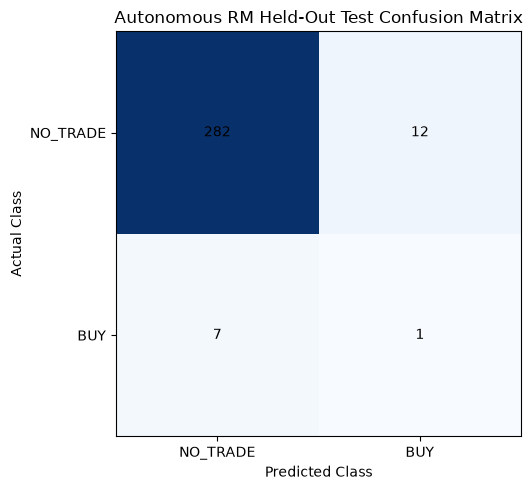

In [112]:
# Perform test classification using 20% held-out dataset

# RM buy probability
rm_test_buy_probability = (rm_buy_classifier.predict_proba( X_rm_test )[:, RM_BUY_CLASS_INDEX])

# BUY / NO_TRADE decision
rm_test_predictions = (rm_test_buy_probability >= RM_SELECTED_BUY_THRESHOLD).astype(int)

# Supporting risk predictions
rm_test_downside_probability = (rm_downside_classifier.predict_proba( X_rm_test )[:, RM_DOWNSIDE_CLASS_INDEX])
rm_test_predicted_tail = np.clip(rm_tail_regressor.predict( X_rm_test ), 0.0, None, )
rm_test_normalized_tail = np.clip(rm_test_predicted_tail / max( RM_TAIL_SCALE, 1e-8, ), 0.0, 1.0, )

# Check for degenerate held-out predictions
rm_test_buy_count = int(rm_test_predictions.sum())
rm_test_buy_rate = float(rm_test_predictions.mean())
rm_both_classes_predicted = (np.unique( rm_test_predictions ).size == 2)

print("=" * 80)
print("HELD-OUT RM TEST SIGNAL SUMMARY")
print("=" * 80)

print("Test observations:", len( rm_test_predictions ), )
print("Predicted BUY:", rm_test_buy_count, )
print("Predicted BUY rate:", f"{rm_test_buy_rate:.2%}", )
print("Both classes predicted:", rm_both_classes_predicted, )

print("=" * 80)

# Confusion matrix
rm_cm_array = confusion_matrix(y_rm_test_actual_buy, rm_test_predictions, labels=[0, 1,], )
rm_tn, rm_fp, rm_fn, rm_tp = (rm_cm_array.ravel())

rm_confusion_matrix = pd.DataFrame(
    rm_cm_array,
    index=[
        "Actual NO_TRADE",
        "Actual BUY",
    ],
    columns=[
        "Predicted NO_TRADE",
        "Predicted BUY",
    ],
)

# Classification metrics
rm_accuracy = accuracy_score(y_rm_test_actual_buy, rm_test_predictions, )
rm_balanced_accuracy = (balanced_accuracy_score( y_rm_test_actual_buy, rm_test_predictions, ))
rm_precision = precision_score(y_rm_test_actual_buy, rm_test_predictions, zero_division=0, )
rm_recall = recall_score(y_rm_test_actual_buy, rm_test_predictions, zero_division=0, )
rm_f1 = f1_score(y_rm_test_actual_buy, rm_test_predictions, zero_division=0, )
rm_specificity = (rm_tn / ( rm_tn + rm_fp ) if ( rm_tn + rm_fp ) > 0 else np.nan)

try:
    rm_roc_auc = roc_auc_score(y_rm_test_actual_buy, rm_test_buy_probability, )
except ValueError:
    rm_roc_auc = np.nan

try:
    rm_average_precision = (average_precision_score( y_rm_test_actual_buy, rm_test_buy_probability, ))
except ValueError:
    rm_average_precision = np.nan

rm_classification_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision - BUY",
            "Recall - BUY",
            "F1 Score - BUY",
            "Specificity - NO_TRADE",
            "ROC-AUC",
            "Average Precision",
            "BUY Prediction Count",
            "BUY Prediction Rate",
            "True Positive",
            "False Positive",
            "True Negative",
            "False Negative",
        ],
        "Value": [
            rm_accuracy,
            rm_balanced_accuracy,
            rm_precision,
            rm_recall,
            rm_f1,
            rm_specificity,
            rm_roc_auc,
            rm_average_precision,
            rm_test_buy_count,
            rm_test_buy_rate,
            rm_tp,
            rm_fp,
            rm_tn,
            rm_fn,
        ],
    }
)

# Display results
print("Held-Out Test Confusion Matrix:")
display(rm_confusion_matrix)

print("Held-Out Test Classification Metrics:")
display(rm_classification_metrics)

print(
    classification_report(
        y_rm_test_actual_buy,
        rm_test_predictions,
        target_names=[
            "NO_TRADE",
            "BUY",
        ],
        digits=4,
        zero_division=0,
    )
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(rm_cm_array, cmap = "Blues", )
ax.set_xticks([0, 1,], labels=["NO_TRADE", "BUY",], )
ax.set_yticks([0, 1,], labels=["NO_TRADE", "BUY",], )
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Autonomous RM Held-Out Test Confusion Matrix")

for row_index in range(2):
    for column_index in range(2):
        ax.text(column_index, row_index, str( rm_cm_array[row_index, column_index,] ), ha="center", va="center", )

plt.tight_layout()
plt.show()

In [113]:
# Create fresh portfolio
rm_portfolio_state = PortfolioState(
    initial_capital=(specification.execution.initial_capital),
    current_capital=(specification.execution.initial_capital),
)

# Execution policy
rm_execution_policy = ExecutionPolicy(
    
    # MA absent from Configuration 3
    ma_probability_threshold=0.0,
    ma_confidence_threshold=0.0,

    # SM absent from Configuration 3
    sm_support_probability_threshold=0.0,
    sm_confidence_threshold=0.0,

    # RM already made the final decision.
    # Disable EX-level RM filtering.
    rm_maximum_risk_score=1.0,
    rm_confidence_threshold=0.0,

    # Keep deterministic execution assumptions unchanged.
    fixed_position_fraction=(specification.execution.fixed_position_fraction),
    transaction_cost_bps_per_side=(specification.execution.transaction_cost_bps_per_side),
    slippage_bps_per_side=(specification.execution.slippage_bps_per_side),
    require_valid_close_for_execution=True,
)

rm_execution_policy.validate()

# Execution agent
rm_execution_agent = (
    DeterministicExecutionAgent(
        portfolio_state=(rm_portfolio_state),
        policy=(rm_execution_policy),
        model_version=("EX_CONFIG3_RM_SIGNAL_ONLY_V2"),
    )
)

# Reflection agent
if ("reflection_policy" in globals()):
    rm_reflection_agent = (
        StructuredDiagnosticReflectionAgent(policy=(reflection_policy), model_version=("RF_CONFIG3_RM_SELECTIVE_V2"), ))
else:
    rm_reflection_agent = (StructuredDiagnosticReflectionAgent( model_version=( "RF_CONFIG3_RM_SELECTIVE_V2" ), ))


# Configuration registry
rm_registry = AgentRegistry()
rm_registry.register(risk_management_agent)
rm_registry.register(rm_execution_agent)
rm_registry.register(rm_reflection_agent)

print("=" * 80)
print("CONFIGURATION 3 REGISTRY CREATED")
print("=" * 80)

print("RM -> EX -> RF")
print()
print("RM signal is the final trading decision.")
print("EX performs execution mechanics only.")
print("=" * 80)

CONFIGURATION 3 REGISTRY CREATED
RM -> EX -> RF

RM signal is the final trading decision.
EX performs execution mechanics only.


In [114]:
# Execute autonomous configuration: RM -> EX -> RF

# Dataset version
rm_dataset_version = (
    f"AMZN_RM_SELECTIVE_"
    f"{rm_train_data.index.min():%Y%m%d}_"
    f"{rm_test_data.index.max():%Y%m%d}_"
    f"N{len(rm_train_data) + len(rm_test_data)}"
)

# Configuration runner
def run_rm_selective_configuration(test_data, symbol, specification, dataset_version, registry):
    daily_records = []
    reflection_records = []
    packets = []

    for (decision_date, row, ) in test_data.iterrows():
        # Create standard Step-2 packet
        packet = (
            create_packet_from_aligned_row(
                row=(row),
                symbol=(symbol),
                configuration_id=(ConfigurationID.CONFIGURATION_3),
                specification=(specification),
                dataset_version=(dataset_version),
            )
        )

        # Add engineered RM model features
        # Existing BaseAgent reads them through packet.macroeconomic_data.
        for feature_name in (RM_MODEL_FEATURES):
            packet.macroeconomic_data[feature_name] = float(row[feature_name])

        # RM
        registry.get(AgentID.RISK_MANAGEMENT).run(packet)

        # EX
        registry.get(AgentID.EXECUTION).run(packet)

        # RF
        registry.get(AgentID.REFLECTION).run(packet)

        # Retrieve outputs
        rm_output = packet.risk_management_output
        ex_output = packet.execution_output
        rf_output = packet.reflection_output

        # Independently calculate model components so they are available in the academic daily log.
        feature_frame = pd.DataFrame(
            [
                {
                    feature:float(row[feature])
                    for feature
                    in RM_MODEL_FEATURES
                }
            ],
            columns=(RM_MODEL_FEATURES),
        )

        (buy_probability, downside_probability, predicted_tail_downside, normalized_tail_downside, ) = (risk_management_agent.calculate_components( feature_frame ))
        predicted_class = int(rm_output.recommendation == RiskRecommendation.APPROVE)

        # Daily result
        daily_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "actual_class":int(row["rm_actual_buy"]),
                "predicted_class":predicted_class,
                "rm_recommendation":rm_output.recommendation.value,
                "rm_buy_probability":buy_probability,
                "rm_buy_threshold":RM_SELECTED_BUY_THRESHOLD,
                "downside_probability":downside_probability,
                "predicted_tail_downside":predicted_tail_downside,
                "normalized_tail_downside":normalized_tail_downside,
                "rm_risk_score":rm_output.risk_score,
                "rm_risk_level":rm_output.risk_level.value,
                "rm_confidence":rm_output.confidence_score,
                "trade_executed":ex_output.trade_executed,
                "entry_price":ex_output.entry_price,
                "exit_price":ex_output.exit_price,
                "gross_return":ex_output.gross_return,
                "transaction_cost_return":ex_output.transaction_cost_return,
                "slippage_return":ex_output.slippage_return,
                "net_return":ex_output.net_return,
                "capital_before":ex_output.capital_before,
                "capital_after":ex_output.capital_after,
                "reflection_category":rf_output.category.value,
                "explainability_score":rf_output.explainability_score,
            }
        )

        # Reflection log
        reflection_records.append(
            {
                "date":decision_date,
                "decision_id":packet.metadata.decision_id,
                "rm_recommendation":rm_output.recommendation.value,
                "rm_buy_probability":buy_probability,
                "downside_probability":downside_probability,
                "predicted_tail_downside":predicted_tail_downside,
                "rm_risk_score":rm_output.risk_score,
                "trade_executed":ex_output.trade_executed,
                "net_return":ex_output.net_return,
                "decision_summary":rf_output.decision_summary,
                "outcome_summary":rf_output.outcome_summary,
                "reflection_category":rf_output.category.value,
                "explainability_score":rf_output.explainability_score,
            }
        )
        packets.append(packet)

    return (
        pd.DataFrame(daily_records).set_index("date"),
        pd.DataFrame(reflection_records).set_index("date"),
        packets,
    )

# Run configuration
(rm_daily_results, rm_reflection_log, rm_packets, ) = (
    run_rm_selective_configuration(
        test_data=(rm_test_data),
        symbol="AMZN",
        specification=(specification),
        dataset_version=(rm_dataset_version),
        registry=(rm_registry),
    )
)

# Verify direct model and packet model
packet_predictions = (rm_daily_results["predicted_class"].astype(int).to_numpy())

if not np.array_equal(packet_predictions, rm_test_predictions, ):
    mismatch_count = int(np.sum( packet_predictions != rm_test_predictions ))
    raise ValueError(
        "Direct RM predictions and packet-level RM "
        f"predictions differ for {mismatch_count} observations."
    )

# Signal vs execution consistency
rm_predicted_buy_mask = (rm_daily_results["predicted_class"].astype(int) == 1)
rm_executed_mask = (rm_daily_results["trade_executed"].astype(bool))
rm_buy_not_executed_mask = (rm_predicted_buy_mask & ~rm_executed_mask)
rm_nonbuy_executed_mask = (~rm_predicted_buy_mask & rm_executed_mask)
rm_signal_execution_check = pd.DataFrame(
    {
        "Measure": [
            "RM Predicted BUY",
            "EX Executed Trades",
            "BUY Not Executed",
            "NO_TRADE Incorrectly Executed",
        ],
        "Count": [
            int(rm_predicted_buy_mask.sum()),
            int(rm_executed_mask.sum()),
            int(rm_buy_not_executed_mask.sum()),
            int(rm_nonbuy_executed_mask.sum()),
        ],
    }
)

print("RM Signal / EX Execution Consistency:")
display(rm_signal_execution_check)

# Show any BUY signal EX did not execute
if (rm_buy_not_executed_mask.sum() > 0):
    print("WARNING: RM BUY signals not executed:")
    display(
        rm_daily_results.loc[
            rm_buy_not_executed_mask,
            [
                "predicted_class",
                "rm_buy_probability",
                "rm_confidence",
                "rm_risk_score",
                "trade_executed",
                "entry_price",
                "exit_price",
                "net_return",
            ],
        ]
    )
else:
    print("PASS: Every RM BUY signal was executed by EX.")

if (rm_nonbuy_executed_mask.sum() > 0):
    print("WARNING: EX executed one or more RM NO_TRADE " "observations.")

print("=" * 80)
print("AUTONOMOUS RM -> EX -> RF COMPLETED")
print("=" * 80)

RM Signal / EX Execution Consistency:


,Measure,Count
0,RM Predicted BUY,13
1,EX Executed Trades,13
2,BUY Not Executed,0
3,NO_TRADE Incorrectly Executed,0


PASS: Every RM BUY signal was executed by EX.
AUTONOMOUS RM -> EX -> RF COMPLETED


In [115]:
# Test dataset evaluation

# Align baseline to exact RM test dates
rm_baseline_test_results = (rm_baseline_results.reindex( rm_test_data.index ).copy())

if (rm_baseline_test_results["net_strategy_return"].isna().any()):
    missing_baseline_dates = (rm_baseline_test_results.index[rm_baseline_test_results["net_strategy_return"].isna()])
    raise ValueError(
        "Baseline is missing RM test dates. "
        f"First missing dates: "
        f"{list(missing_baseline_dates[:5])}"
    )

# Baseline metrics
rm_baseline_trading_metrics = (
    calculate_rm_trading_metrics(
        daily_returns=(rm_baseline_test_results["net_strategy_return"]),
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

# Autonomous RM metrics
rm_trading_metrics = (
    calculate_rm_trading_metrics(
        daily_returns=(rm_daily_results["net_return"]),
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

# Performance table
rm_metric_order = [
    "Initial Capital",
    "Final Portfolio Value",
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Sortino Ratio",
    "Calmar Ratio",
    "Number of Trades",
    "Winning Trades",
    "Losing Trades",
    "Win Rate",
    "Average Trade Return",
]

rm_vs_baseline_performance = pd.DataFrame(
    [
        {
            "Metric":metric,
            "Baseline Test":rm_baseline_trading_metrics[metric],
            "Autonomous RM Test":rm_trading_metrics[metric],
            "Difference":(rm_trading_metrics[metric] - rm_baseline_trading_metrics[metric]),
        }
        for metric
        in rm_metric_order
    ]
)

print("Held-Out Test Trading Performance:")
display(rm_vs_baseline_performance)

# Key performance summary
print("=" * 80)
print("KEY HELD-OUT PERFORMANCE")
print("=" * 80)

print("Baseline Total Return:", f"{rm_baseline_trading_metrics['Total Return']:.4%}", )
print("RM Total Return:", f"{rm_trading_metrics['Total Return']:.4%}", )
print("Baseline Sharpe:", f"{rm_baseline_trading_metrics['Sharpe Ratio']:.4f}", )
print("RM Sharpe:", f"{rm_trading_metrics['Sharpe Ratio']:.4f}", )
print("Baseline trades:", int( rm_baseline_trading_metrics["Number of Trades"] ), )
print("RM trades:", int( rm_trading_metrics["Number of Trades"] ), )
print("=" * 80)

Held-Out Test Trading Performance:


,Metric,Baseline Test,Autonomous RM Test,Difference
0,Initial Capital,100000.000000,100000.000000,0.000000
1,Final Portfolio Value,101536.116228,101989.894943,453.778715
2,Total Return,0.015361,0.019899,0.004538
3,Annualized Return,0.012802,0.016577,0.003776
4,Annualized Volatility,0.034288,0.054912,0.020623
5,Sharpe Ratio,0.388114,0.326602,-0.061512
6,Maximum Drawdown,-0.026007,-0.046356,-0.020349
7,Sortino Ratio,0.082412,0.135257,0.052845
8,Calmar Ratio,0.492242,0.357606,-0.134636
9,Number of Trades,9.000000,13.000000,4.000000


KEY HELD-OUT PERFORMANCE
Baseline Total Return: 1.5361%
RM Total Return: 1.9899%
Baseline Sharpe: 0.3881
RM Sharpe: 0.3266
Baseline trades: 9
RM trades: 13



BASELINE VS RM AGENT - HELD-OUT TEST TRADING PERFORMANCE


,Metric,Baseline Test,RM Agent Test,Difference
0,Initial Capital,100000.000000,100000.000000,0.000000
1,Final Portfolio Value,101536.116228,101989.894943,453.778715
2,Total Return,0.015361,0.019899,0.004538
3,Annualized Return,0.012802,0.016577,0.003776
4,Annualized Volatility,0.034288,0.054912,0.020623
5,Sharpe Ratio,0.388114,0.326602,-0.061512
6,Maximum Drawdown,-0.026007,-0.046356,-0.020349
7,Sortino Ratio,0.082412,0.135257,0.052845
8,Calmar Ratio,0.492242,0.357606,-0.134636
9,Number of Trades,9.000000,13.000000,4.000000



EXECUTION AGENT SUMMARY


,Metric,Value
0,RM BUY Signals,13
1,EX Executed Trades,13
2,RM BUY Not Executed,0
3,RM NO_TRADE Incorrectly Executed,0
4,Executed Winners,6
5,Executed Losers,7
6,Executed Flat Trades,0


EX consistency: PASS - every RM BUY was executed and no RM NO_TRADE was executed.

EQUITY CURVE ALIGNMENT SUMMARY
Common plot start date: 2025-08-18 00:00:00
Common plot end date: 2026-07-30 00:00:00
Baseline visible start: 2025-08-17 12:00:00
RM visible start: 2025-08-17 12:00:00
Baseline starting capital: 100000.0
RM starting capital: 100000.0


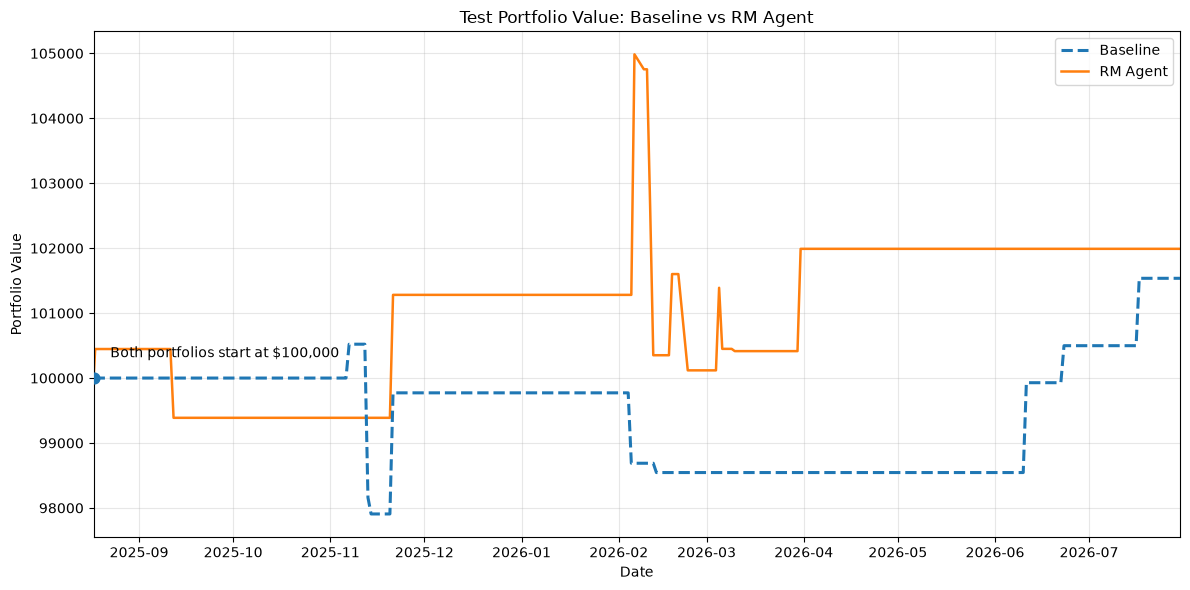


STEP 7 OUTPUTS SUMMARY
Held-out RM BUY signals: 13
EX executed trades: 13
TP: 1
FP: 12
TN: 282
FN: 7
Balanced Accuracy: 0.5421
Precision: 0.0769
Recall: 0.1250
F1: 0.0952
RM Total Return: 1.9899%
Baseline Total Return: 1.5361%
RM Sharpe: 0.3266
Baseline Sharpe: 0.3881


In [116]:
# Tradiong performance metric table
rm_performance_display = (rm_vs_baseline_performance.copy())

# Ensure autonomous terminology is used consistently.
if ("Autonomous RM Test" in rm_performance_display.columns):
    rm_performance_display = (rm_performance_display.rename( columns={"Autonomous RM Test": "RM Agent Test"} ))

if ("RM Overlay Test" in rm_performance_display.columns):
    rm_performance_display = (rm_performance_display.rename( columns={"RM Overlay Test": "RM Agent Test"} ))

print()
print("=" * 80)
print("BASELINE VS RM AGENT - HELD-OUT TEST TRADING PERFORMANCE")
print("=" * 80)

display(rm_performance_display)

# Execution agent summary
rm_predicted_buy_mask = (rm_daily_results["predicted_class"].astype(int) == 1)
rm_predicted_no_trade_mask = (~rm_predicted_buy_mask)
rm_executed_mask = (rm_daily_results["trade_executed"].astype(bool))
rm_buy_not_executed_mask = (rm_predicted_buy_mask & ~rm_executed_mask)
rm_no_trade_executed_mask = (rm_predicted_no_trade_mask & rm_executed_mask)
rm_executed_return_series = (rm_daily_results.loc[rm_executed_mask, "net_return",].astype(float))
rm_nonexecuted_buy_return_series = (rm_daily_results.loc[rm_buy_not_executed_mask, "net_return",].astype(float))

rm_ex_summary = pd.DataFrame(
    {
        "Metric": [
            "RM BUY Signals",
            "EX Executed Trades",
            "RM BUY Not Executed",
            "RM NO_TRADE Incorrectly Executed",
            "Executed Winners",
            "Executed Losers",
            "Executed Flat Trades",
        ],
        "Value": [
            int(rm_predicted_buy_mask.sum()),
            int(rm_executed_mask.sum()),
            int(rm_buy_not_executed_mask.sum()),
            int(rm_no_trade_executed_mask.sum()),
            int(( rm_executed_return_series > 0 ).sum()),
            int(( rm_executed_return_series < 0 ).sum()),
            int(( rm_executed_return_series == 0 ).sum()),
        ],
    }
)

print()
print("=" * 80)
print("EXECUTION AGENT SUMMARY")
print("=" * 80)

display(rm_ex_summary)

# Signal/execution consistency
if (rm_buy_not_executed_mask.sum() == 0 and rm_no_trade_executed_mask.sum() == 0):
    print("EX consistency: PASS - every RM BUY was executed " "and no RM NO_TRADE was executed.")
else:
    print("EX consistency: WARNING - signal/execution " "mismatch detected.")

    if (rm_buy_not_executed_mask.sum() > 0):
        print("\nRM BUY signals not executed:")

        display(
            rm_daily_results.loc[
                rm_buy_not_executed_mask,
                [
                    "predicted_class",
                    "rm_buy_probability",
                    "rm_confidence",
                    "rm_risk_score",
                    "trade_executed",
                    "entry_price",
                    "exit_price",
                    "net_return",
                    "capital_before",
                    "capital_after",
                ],
            ]
        )

# Plot equity curve with the same trading dates
rm_trade_dates = (rm_daily_results.index[rm_daily_results["trade_executed"].astype(bool)])

if len(rm_trade_dates) > 0:
    rm_plot_start_date = (rm_trade_dates.min())
else:
    rm_plot_start_date = (rm_test_data.index.min())

rm_plot_end_date = (rm_test_data.index.max())
rm_plot_index = (rm_test_data.loc[rm_plot_start_date: rm_plot_end_date].index)

# Reindex both strategies to same plot dates
rm_baseline_plot_returns = (
    rm_baseline_test_results[
        "net_strategy_return"
    ]
    .reindex(rm_plot_index)
    .fillna(0.0)
    .astype(float)
)

rm_agent_plot_returns = (rm_daily_results["net_return"].reindex( rm_plot_index ).fillna(0.0).astype(float))
initial_capital = specification.execution.initial_capital

# Build rebased equity curves
rm_baseline_equity_plot = (initial_capital * ( 1.0 + rm_baseline_plot_returns ).cumprod())
rm_agent_equity_plot = (initial_capital * ( 1.0 + rm_agent_plot_returns ).cumprod())

# Use identical $100,000 starting capital
rm_first_plot_date = (rm_plot_index.min())
rm_plot_initial_date = (rm_first_plot_date - pd.Timedelta( hours=12 ))
rm_baseline_equity_plot = pd.concat([pd.Series( {rm_plot_initial_date: initial_capital} ), rm_baseline_equity_plot,])
rm_agent_equity_plot = pd.concat([pd.Series( {rm_plot_initial_date: initial_capital} ), rm_agent_equity_plot,])

# Verify common plot range
if not (rm_baseline_equity_plot.index.equals( rm_agent_equity_plot.index )):
    raise ValueError("Baseline and RM plot dates are not identical.")

# Display plot date and starting capital 
print()
print("=" * 80)
print("EQUITY CURVE ALIGNMENT SUMMARY")
print("=" * 80)

print("Common plot start date:", rm_first_plot_date, )
print("Common plot end date:", rm_plot_end_date, )
print("Baseline visible start:", rm_baseline_equity_plot.index.min(), )
print("RM visible start:", rm_agent_equity_plot.index.min(), )
print("Baseline starting capital:", float( rm_baseline_equity_plot.iloc[0] ), )
print("RM starting capital:", float( rm_agent_equity_plot.iloc[0] ), )
print("=" * 80)

# Equity curve plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    rm_baseline_equity_plot.index,
    rm_baseline_equity_plot,
    label="Baseline",
    linestyle="--",
    linewidth=2.2,
    zorder=3,
)

ax.plot(rm_agent_equity_plot.index, rm_agent_equity_plot, label="RM Agent", linestyle="-", linewidth=1.8, zorder=2, )
ax.scatter([rm_plot_initial_date], [initial_capital], s=60, zorder=5, )
ax.annotate(
    "Both portfolios start at $100,000",
    xy=(rm_plot_initial_date, initial_capital, ),
    xytext=(12, 15, ),
    textcoords="offset points",
)
ax.set_title("Test Portfolio Value: " "Baseline vs RM Agent")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(True, alpha=0.3, )
ax.set_xlim(rm_plot_initial_date, rm_plot_end_date, )
plt.tight_layout()
plt.show()

# Final output summary
print()
print("=" * 80)
print("STEP 7 OUTPUTS SUMMARY")
print("=" * 80)

# print("Output directory:", RM_OUTPUT_DIRECTORY.resolve(), )
print("Held-out RM BUY signals:", int( rm_test_predictions.sum() ), )
print("EX executed trades:", int( rm_daily_results["trade_executed"].astype(bool).sum() ), )
print("TP:", int( rm_tp ), )
print("FP:", int( rm_fp ), )
print("TN:", int( rm_tn ), )
print("FN:", int( rm_fn ), )
print("Balanced Accuracy:", f"{rm_balanced_accuracy:.4f}", )
print("Precision:", f"{rm_precision:.4f}", )
print("Recall:", f"{rm_recall:.4f}", )
print("F1:", f"{rm_f1:.4f}", )
print("RM Total Return:", f"{rm_trading_metrics['Total Return']:.4%}", )
print("Baseline Total Return:", f"{rm_baseline_trading_metrics['Total Return']:.4%}", )
print("RM Sharpe:", f"{rm_trading_metrics['Sharpe Ratio']:.4f}", )
print("Baseline Sharpe:", f"{rm_baseline_trading_metrics['Sharpe Ratio']:.4f}", )
print("=" * 80)

In [117]:
# Create output directory
RM_OUTPUT_DIRECTORY = Path("data/model2/step7_rm_risk_management_agent_outputs")
RM_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True, )

# Export training results
rm_class_distribution.to_csv(RM_OUTPUT_DIRECTORY / "rm_class_distribution.csv", index=False, )
rm_model_selection_results.to_csv(RM_OUTPUT_DIRECTORY / "rm_model_selection_results.csv", index=False, )
rm_fold_selection_results.to_csv(RM_OUTPUT_DIRECTORY / "rm_fold_selection_results.csv", index=False, )
rm_selected_fold_results.to_csv(RM_OUTPUT_DIRECTORY / "rm_selected_fold_results.csv", index=False, )
rm_selected_model_summary.to_csv(RM_OUTPUT_DIRECTORY / "rm_selected_model_summary.csv", index=False, )
rm_final_model_summary.to_csv(RM_OUTPUT_DIRECTORY / "rm_final_model_summary.csv", index=False, )
rm_downside_model_selection.to_csv(RM_OUTPUT_DIRECTORY / "rm_downside_model_selection.csv", index=False, )
rm_feature_importance.to_csv(RM_OUTPUT_DIRECTORY / "rm_feature_importance.csv", index=False, )

# Export test classificaiton results
rm_confusion_matrix.to_csv(RM_OUTPUT_DIRECTORY / "rm_test_confusion_matrix.csv", )
rm_classification_metrics.to_csv(RM_OUTPUT_DIRECTORY / "rm_classification_metrics.csv", index=False, )

# Export agentic results
rm_daily_results.to_csv(RM_OUTPUT_DIRECTORY / "rm_test_daily_results.csv", )
rm_reflection_log.to_csv(RM_OUTPUT_DIRECTORY / "rm_reflection_log.csv", )
rm_signal_execution_check.to_csv(RM_OUTPUT_DIRECTORY / "rm_signal_execution_check.csv", index=False, )
rm_ex_summary.to_csv(RM_OUTPUT_DIRECTORY / "rm_execution_summary.csv", index=False, )

# Export performance results
rm_performance_display.to_csv(RM_OUTPUT_DIRECTORY / "rm_baseline_vs_rm_agent_performance.csv", index=False, )
# rm_success_summary.to_csv(RM_OUTPUT_DIRECTORY / "rm_success_criteria.csv", index=False, )


#### Step 8: Agentic Framework (MA + SM + RM) -> EX -> RF

In [119]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Configuration 4 settings
CONFIG4_SYMBOL = "AMZN"
CONFIG4_OUTPUT_DIRECTORY = Path("data/model2/step8_agentic_outputs")
CONFIG4_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True, )

# Required framework objects
config4_required_framework_objects = [
    # Step 1
    "test_data",
    "specification",
    "experiment_metadata",
    "CONFIGURATION_AGENTS",
    "CONFIGURATION_DECISION_POLICIES",

    # Enums / architecture
    "AgentID",
    "ConfigurationID",
    "DecisionResolutionMode",
    "AnalyticalVote",

    # Step 2
    "DecisionPacket",
    "AgentRegistry",
    "create_packet_from_aligned_row",

    # Step 3
    "PortfolioState",
    "ExecutionPolicy",
    "DeterministicExecutionAgent",
    "create_execution_policy_from_specification",

    # Step 4
    "StructuredDiagnosticReflectionAgent",
]


missing_config4_framework_objects = [
    object_name

    for object_name
    in config4_required_framework_objects

    if object_name
    not in globals()
]

if missing_config4_framework_objects:
    raise NameError(
        "Run the updated Steps 1-4 first. "
        "The following Configuration 4 framework objects "
        f"are missing: {missing_config4_framework_objects}"
    )

# Verify configuration 4 route
expected_config4_route = [
    AgentID.MARKET_ANALYSIS,
    AgentID.SENTIMENT,
    AgentID.RISK_MANAGEMENT,
    AgentID.EXECUTION,
    AgentID.REFLECTION,
]

actual_config4_route = (CONFIGURATION_AGENTS[ConfigurationID.CONFIGURATION_4])

if (actual_config4_route != expected_config4_route):
    raise ValueError(
        "Configuration 4 must be "
        "MA -> SM -> RM -> EX -> RF. "

        "Current route: "
        f"{[agent.value for agent in actual_config4_route]}"
    )

config4_policy = (CONFIGURATION_DECISION_POLICIES[ConfigurationID.CONFIGURATION_4])

if (config4_policy.resolution_mode != DecisionResolutionMode.MAJORITY_VOTE):
    raise ValueError("Configuration 4 must use MAJORITY_VOTE.")

if (config4_policy.required_buy_votes != 2):
    raise ValueError("Configuration 4 must require 2 BUY votes.")

print("=" * 80)
print("STEP 8 - CONFIGURATION 4 PREREQUISITE CHECK PASSED")
print("=" * 80)
print("Route:", " -> ".join( agent.value for agent in actual_config4_route ), )
print("Decision resolution:", config4_policy.resolution_mode.value, )
print("Required BUY votes:", config4_policy.required_buy_votes, )
print("=" * 80)

STEP 8 - CONFIGURATION 4 PREREQUISITE CHECK PASSED
Route: MA -> SM -> RM -> EX -> RF
Decision resolution: MAJORITY_VOTE
Required BUY votes: 2


In [120]:
# Required independent agent objects
config4_required_agent_objects = [
    # Step 5
    "market_analysis_agent",
    "MA_MODEL_FEATURES",
    "ma_test_data",

    # Step 6
    "sentiment_agent",
    "SM_MODEL_FEATURES",
    "sm_test_data",

    # Step 7
    "risk_management_agent",
    "RM_MODEL_FEATURES",
    "rm_test_data",
]

missing_config4_agent_objects = [
    object_name

    for object_name
    in config4_required_agent_objects

    if object_name
    not in globals()
]

if missing_config4_agent_objects:
    raise NameError(
        "Run completed Steps 5-7 before Step 8. "
        "The following trained-agent objects are missing: "
        f"{missing_config4_agent_objects}"
    )

# Type and agent ID validation
if (market_analysis_agent.agent_id != AgentID.MARKET_ANALYSIS):
    raise TypeError("market_analysis_agent is not registered as MA.")

if (sentiment_agent.agent_id != AgentID.SENTIMENT):
    raise TypeError("sentiment_agent is not registered as SM.")

if (risk_management_agent.agent_id != AgentID.RISK_MANAGEMENT):
    raise TypeError("risk_management_agent is not registered as RM.")

# References to the already-fitted specialist agents
config4_ma_agent = market_analysis_agent
config4_sm_agent = sentiment_agent
config4_rm_agent = risk_management_agent
config4_agent_summary = pd.DataFrame(
    [
        {
            "Agent": "MA",
            "Model Name": config4_ma_agent.model_name,
            "Model Version": config4_ma_agent.model_version,
            "No. Model Features": len(MA_MODEL_FEATURES),
        },
        {
            "Agent": "SM",
            "Model Name": config4_sm_agent.model_name,
            "Model Version": config4_sm_agent.model_version,
            "No. Model Features": len(SM_MODEL_FEATURES),
        },
        {
            "Agent": "RM",
            "Model Name": config4_rm_agent.model_name,
            "Model Version": config4_rm_agent.model_version,
            "No. Model Features": len(RM_MODEL_FEATURES),
        },
    ]
)

display(config4_agent_summary)
print("Frozen specialist agents resolved successfully.")
print("No Step 8 model training or threshold tuning " "will be performed.")

,Agent,Model Name,Model Version,No. Model Features
0,MA,ProfitAwareDualModelMarketAnalysisAgent,MA_DUAL_OHLC_V2,30
1,SM,ProfitAwareDualModelSentimentAgent,SM_DUAL_OHLC_SENTIMENT_V2,60
2,RM,AutonomousSelectiveRiskAdjustedAgent,RM_AUTONOMOUS_SELECTIVE_V2,57


Frozen specialist agents resolved successfully.
No Step 8 model training or threshold tuning will be performed.


In [121]:
# Fresh configuraiton 4 portfolio
config4_portfolio_state = PortfolioState(
    initial_capital=(specification.execution.initial_capital),
    current_capital=(specification.execution.initial_capital),
)

# Common execution policy
config4_execution_policy = (create_execution_policy_from_specification( specification ))

# Configuration-aware EX
config4_execution_agent = (
    DeterministicExecutionAgent(
        portfolio_state=(config4_portfolio_state),
        policy=(config4_execution_policy),
        model_version=("EX_CONFIG4_MAJORITY_2_OF_3_V1"),
    )
)

# Configuration-aware RF
if ("reflection_policy" in globals()):
    config4_reflection_agent = (
        StructuredDiagnosticReflectionAgent(
            policy=(reflection_policy),
            model_version=("RF_CONFIG4_MAJORITY_2_OF_3_V1"),
        )
    )
else:
    config4_reflection_agent = (StructuredDiagnosticReflectionAgent(model_version=( "RF_CONFIG4_MAJORITY_2_OF_3_V1" )))

# Configuratio 4 registry
config4_registry = (AgentRegistry())
config4_registry.register(config4_ma_agent)
config4_registry.register(config4_sm_agent)
config4_registry.register(config4_rm_agent)
config4_registry.register(config4_execution_agent)
config4_registry.register(config4_reflection_agent)

print("=" * 80)
print("CONFIGURATION 4 REGISTRY CREATED")
print("=" * 80)
print("Registered agents:", [agent.value for agent in config4_registry.registered_agents()], )
print("Initial capital:", f"${config4_portfolio_state.current_capital:,.2f}", )
print("Required BUY votes:", config4_policy.required_buy_votes, )
print("=" * 80)

CONFIGURATION 4 REGISTRY CREATED
Registered agents: ['MA', 'SM', 'RM', 'EX', 'RF']
Initial capital: $100,000.00
Required BUY votes: 2


In [122]:
# Common test index
config4_test_index = (
    test_data.index
    .intersection(ma_test_data.index)
    .intersection(sm_test_data.index)
    .intersection(rm_test_data.index)
    .sort_values()
)

if (len(config4_test_index) == 0):
    raise RuntimeError("There are no common test dates across " "test_data, MA, SM and RM.")

# Base configuration 4 dataset
config4_test_data = (test_data.loc[config4_test_index].copy())

# Validate model featues exist in each specialist dataset
missing_ma_features = [
    feature

    for feature
    in MA_MODEL_FEATURES

    if feature
    not in ma_test_data.columns
]

missing_sm_features = [
    feature

    for feature
    in SM_MODEL_FEATURES

    if feature
    not in sm_test_data.columns
]

missing_rm_features = [
    feature

    for feature
    in RM_MODEL_FEATURES

    if feature
    not in rm_test_data.columns
]

if missing_ma_features:
    raise ValueError("MA test dataset is missing model features: " f"{missing_ma_features}")

if missing_sm_features:
    raise ValueError("SM test dataset is missing model features: " f"{missing_sm_features}")

if missing_rm_features:
    raise ValueError("RM test dataset is missing model features: " f"{missing_rm_features}")

# Verify no duplicated dates
if (config4_test_data.index.duplicated().any()):
    raise ValueError("Duplicate dates detected in Configuration 4.")

# Dataset version
config4_dataset_version = (
    "AMZN_CONFIG4_"
    f"{config4_test_index.min():%Y%m%d}_"
    f"{config4_test_index.max():%Y%m%d}_"
    f"N{len(config4_test_index)}"
)

config4_alignment_summary = pd.DataFrame(
    [
        {
            "Dataset": "Step 1 Test",
            "Observations": len(test_data),
            "Start": test_data.index.min(),
            "End": test_data.index.max(),
        },
        {
            "Dataset": "MA Test",
            "Observations": len(ma_test_data),
            "Start": ma_test_data.index.min(),
            "End": ma_test_data.index.max(),
        },
        {
            "Dataset": "SM Test",
            "Observations": len(sm_test_data),
            "Start": sm_test_data.index.min(),
            "End": sm_test_data.index.max(),
        },
        {
            "Dataset": "RM Test",
            "Observations": len(rm_test_data),
            "Start": rm_test_data.index.min(),
            "End": rm_test_data.index.max(),
        },
        {
            "Dataset": "Configuration 4 Common Test",
            "Observations": len(config4_test_data),
            "Start": config4_test_data.index.min(),
            "End": config4_test_data.index.max(),
        },
    ]
)

display(config4_alignment_summary)
print("Configuration 4 dataset version:", config4_dataset_version, )

,Dataset,Observations,Start,End
0,Step 1 Test,302,2025-05-16,2026-07-30
1,MA Test,302,2025-05-16,2026-07-30
2,SM Test,302,2025-05-16,2026-07-30
3,RM Test,302,2025-05-16,2026-07-30
4,Configuration 4 Common Test,302,2025-05-16,2026-07-30


Configuration 4 dataset version: AMZN_CONFIG4_20250516_20260730_N302


In [123]:
# Single day configuraiton 4 orchestrator
def run_config4_single_day(decision_date, base_row, symbol, specification, dataset_version, registry):
    decision_date = pd.Timestamp(decision_date)

    # Create common packet
    packet = (
        create_packet_from_aligned_row(
            row=(base_row),
            symbol=(symbol),
            configuration_id=(ConfigurationID.CONFIGURATION_4),
            specification=(specification),
            dataset_version=(dataset_version),
        )
    )

    # Inject MA engineering features
    ma_row = (ma_test_data.loc[decision_date])

    for feature_name in (MA_MODEL_FEATURES):
        packet.market_data[
            feature_name
        ] = float(ma_row[feature_name])

    # Inject SM engineering features
    sm_row = (sm_test_data.loc[decision_date])

    for feature_name in (SM_MODEL_FEATURES):
        packet.sentiment_data[
            feature_name
        ] = float(sm_row[feature_name])

    # Inject RM engineering features
    rm_row = (rm_test_data.loc[decision_date])

    for feature_name in (RM_MODEL_FEATURES):
        packet.macroeconomic_data[
            feature_name
        ] = float(rm_row[feature_name])

    # Run independent analytical agents
    registry.get(AgentID.MARKET_ANALYSIS).run(packet)
    registry.get(AgentID.SENTIMENT).run(packet)
    registry.get(AgentID.RISK_MANAGEMENT).run(packet)
    
    # EX
    registry.get(AgentID.EXECUTION).run(packet)

    # RF
    registry.get(AgentID.REFLECTION).run(packet)

    # Final packet validation
    packet.validate_configuration_outputs()

    return packet

In [124]:
# Complete configuration 4 chronological runner (no shuffling, no retraining, no threshold re-selection)
def run_config4_configuration(test_data, symbol, specification, dataset_version, registry):
    daily_records = []
    reflection_records = []
    packets = []

    for (decision_date, row, ) in (test_data.sort_index().iterrows()):
        packet = (
            run_config4_single_day(
                decision_date=(decision_date),
                base_row=(row),
                symbol=(symbol),
                specification=(specification),
                dataset_version=(dataset_version),
                registry=(registry),
            )
        )

        # Output
        ma_output = packet.market_analysis_output
        sm_output = packet.sentiment_output
        rm_output = packet.risk_management_output
        fusion = packet.decision_fusion
        ex_output = packet.execution_output
        rf_output = packet.reflection_output
        if any(output is None for output in [ma_output, sm_output, rm_output, fusion, ex_output, rf_output,]):
            raise RuntimeError("Configuration 4 produced an incomplete " f"packet on {decision_date}.")

        # Normalized votes
        ma_vote = (fusion.agent_votes[AgentID.MARKET_ANALYSIS.value])
        sm_vote = (fusion.agent_votes[AgentID.SENTIMENT.value])
        rm_vote = (fusion.agent_votes[AgentID.RISK_MANAGEMENT.value])

        # Daily records
        daily_records.append(
            {
                "date": decision_date,
                "decision_id": packet.metadata.decision_id,
                "configuration_id": packet.metadata.configuration_id.value,
                
                # Ground truth
                "actual_profitable_class": int(row["target_profitable"]),
                "realised_market_return": float(row["net_open_to_close_return"]),

                # MA
                "ma_signal": ma_output.signal.value,
                "ma_vote": ma_vote.value,
                "ma_buy": int(ma_vote == AnalyticalVote.BUY),
                "ma_probability":ma_output.predicted_profit_probability,
                "ma_confidence":ma_output.confidence_score,
 
                # SM
                "sm_recommendation": sm_output.recommendation.value,
                "sm_vote": sm_vote.value,
                "sm_buy": int(sm_vote == AnalyticalVote.BUY),
                "sm_probability": sm_output.predicted_profit_probability,
                "sm_confidence": sm_output.confidence_score,

                # RM
                "rm_recommendation":rm_output.recommendation.value,
                "rm_vote": rm_vote.value,
                "rm_buy": int(rm_vote == AnalyticalVote.BUY),
                "rm_risk_score": rm_output.risk_score,
                "rm_risk_level": (rm_output.risk_level.value if rm_output.risk_level else None),
                "rm_confidence": rm_output.confidence_score,

                # Decision fusion
                "buy_vote_count": fusion.buy_vote_count,
                "required_buy_votes": fusion.required_buy_votes,
                "final_vote":fusion.final_vote.value,
                "consensus_category":fusion.consensus_category.value,
                "decision_source": fusion.decision_source.value,
                "supporting_agents": "|".join(agent.value for agent in fusion.supporting_agents),
                "dissenting_agents": "|".join(agent.value for agent in fusion.dissenting_agents),

                # EX
                "trade_executed": ex_output.trade_executed,
                "entry_price": ex_output.entry_price,
                "exit_price": ex_output.exit_price,
                "gross_return": ex_output.gross_return,
                "transaction_cost_return": ex_output.transaction_cost_return,
                "slippage_return": ex_output.slippage_return,
                "net_return": ex_output.net_return,
                "capital_before": ex_output.capital_before,
                "capital_after": ex_output.capital_after,

                # RF
                "reflection_category": rf_output.category.value,
                "agent_agreement_score": rf_output.agent_agreement_score,
                "evidence_completeness_score": rf_output.evidence_completeness_score,
                "traceability_score": rf_output.traceability_score,
                "confidence_consistency_score": rf_output.confidence_consistency_score,
                "execution_completeness_score": rf_output.execution_completeness_score,
                "explainability_score": rf_output.explainability_score,
            }
        )

        # Reflection log
        reflection_records.append(
            {
                "date": decision_date,
                "decision_id": packet.metadata.decision_id,
                "consensus_category": fusion.consensus_category.value,
                "buy_vote_count": fusion.buy_vote_count,
                "supporting_agents": "|".join(agent.value for agent in fusion.supporting_agents),
                "dissenting_agents": "|".join(agent.value for agent in fusion.dissenting_agents),
                "trade_executed": ex_output.trade_executed,
                "net_return": ex_output.net_return,
                "reflection_category": rf_output.category.value,
                "decision_summary": rf_output.decision_summary,
                "outcome_summary":rf_output.outcome_summary,
                "identified_strengths": " | ".join(rf_output.identified_strengths),
                "identified_weaknesses": " | ".join(rf_output.identified_weaknesses),
                "inconsistencies": " | ".join(rf_output.inconsistencies),
                "diagnostic_labels": " | ".join(rf_output.diagnostic_labels),
                "explainability_score": rf_output.explainability_score,
            }
        )
        
        packets.append(packet)

    return (
        pd.DataFrame(daily_records).set_index("date"),
        pd.DataFrame(reflection_records).set_index("date"),
        packets,
    )

In [125]:
# Ensure Configuration 4 starts from fresh capital.
config4_portfolio_state.reset()

(config4_daily_results, config4_reflection_log, config4_packets, ) = (
    run_config4_configuration(
        test_data=(config4_test_data),
        symbol=(CONFIG4_SYMBOL),
        specification=(specification),
        dataset_version=(config4_dataset_version),
        registry=(config4_registry),
    )
)

print("=" * 80)
print("CONFIGURATION 4 EXECUTION COMPLETED")
print("=" * 80)
print("Test observations:", len(config4_daily_results), )
print("Consensus BUY decisions:", int( ( config4_daily_results["final_vote"] == "BUY" ).sum() ), )
print("EX executed trades:", int( config4_daily_results["trade_executed"].sum() ), )
print("Final portfolio value:", f"${config4_portfolio_state.current_capital:,.2f}", )
print("=" * 80)

display(config4_daily_results.head())

CONFIGURATION 4 EXECUTION COMPLETED
Test observations: 302
Consensus BUY decisions: 5
EX executed trades: 5
Final portfolio value: $102,254.00


,decision_id,configuration_id,actual_profitable_class,realised_market_return,ma_signal,ma_vote,ma_buy,ma_probability,ma_confidence,sm_recommendation,...,net_return,capital_before,capital_after,reflection_category,agent_agreement_score,evidence_completeness_score,traceability_score,confidence_consistency_score,execution_completeness_score,explainability_score
date,,,,,,,,,,,,,,,,,,,,,
2025-05-16,decision_4f5f6a06ce314adfbccd54ea686a6f10,CONFIG_4_MA_SM_RM_EX_RF,0,-0.007088,NO_TRADE,NO_TRADE,0,0.512251,0.496252,NEUTRAL,...,0.0,100000.0,100000.0,NO_TRADE_REVIEW,1.000000,1.0,1.0,0.432485,1.0,0.914873
2025-05-19,decision_5464fe147fe340cd92d982cdf6abcf0f,CONFIG_4_MA_SM_RM_EX_RF,1,0.021354,NO_TRADE,NO_TRADE,0,0.628728,0.578528,NEUTRAL,...,0.0,100000.0,100000.0,NO_TRADE_REVIEW,1.000000,1.0,1.0,0.552769,1.0,0.932915
2025-05-20,decision_32ea0d89bdc6481a9bb4bab861b631dc,CONFIG_4_MA_SM_RM_EX_RF,0,-0.003735,NO_TRADE,NO_TRADE,0,0.704812,0.637169,NEUTRAL,...,0.0,100000.0,100000.0,NO_TRADE_REVIEW,1.000000,1.0,1.0,0.453575,1.0,0.918036
2025-05-21,decision_16c755e802424a838fa47251047b8841,CONFIG_4_MA_SM_RM_EX_RF,0,-0.003429,NO_TRADE,NO_TRADE,0,0.426989,0.548580,NEUTRAL,...,0.0,100000.0,100000.0,NO_TRADE_REVIEW,1.000000,1.0,1.0,0.430283,1.0,0.914542
2025-05-22,decision_417be6cc4f9140608e287db417b98ae8,CONFIG_4_MA_SM_RM_EX_RF,1,0.007537,NO_TRADE,NO_TRADE,0,0.611281,0.569947,SUPPORT,...,0.0,100000.0,100000.0,NO_TRADE_REVIEW,0.333333,1.0,1.0,0.526333,1.0,0.795617


In [126]:
# Consensus prediction
config4_actual_class = (config4_daily_results["actual_profitable_class"].astype(int))
config4_consensus_prediction = (
    (config4_daily_results["buy_vote_count"] >= config4_daily_results["required_buy_votes"])
    .astype(int)
)

# Confusion matrix
config4_cm_array = (confusion_matrix( config4_actual_class, config4_consensus_prediction, labels=[0, 1,], ))

(config4_tn, config4_fp, config4_fn, config4_tp, ) = (config4_cm_array.ravel())
config4_consensus_confusion_matrix = (
    pd.DataFrame(
        config4_cm_array,
        index=[
            "Actual NO_TRADE",
            "Actual BUY",
        ],
        columns=[
            "Consensus NO_TRADE",
            "Consensus BUY",
        ],
    )
)

# Classification-like consensus metrics
config4_accuracy = (accuracy_score( config4_actual_class, config4_consensus_prediction, ))
config4_balanced_accuracy = (balanced_accuracy_score( config4_actual_class, config4_consensus_prediction, ))
config4_precision = (precision_score( config4_actual_class, config4_consensus_prediction, zero_division=0, ))
config4_recall = (recall_score( config4_actual_class, config4_consensus_prediction, zero_division=0, ))
config4_f1 = (f1_score( config4_actual_class, config4_consensus_prediction, zero_division=0, ))
config4_specificity = (config4_tn / ( config4_tn + config4_fp ) if ( config4_tn + config4_fp ) > 0 else np.nan)
config4_consensus_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision - BUY",
            "Recall - BUY",
            "F1 Score - BUY",
            "Specificity - NO_TRADE",
            "True Positive",
            "False Positive",
            "True Negative",
            "False Negative",
        ],

        "Value": [
            config4_accuracy,
            config4_balanced_accuracy,
            config4_precision,
            config4_recall,
            config4_f1,
            config4_specificity,
            config4_tp,
            config4_fp,
            config4_tn,
            config4_fn,
        ],
    }
)

print("CONFIGURATION 4 CONSENSUS DECISION CONFUSION MATRIX")
display(config4_consensus_confusion_matrix)
display(config4_consensus_metrics)

print(
    classification_report(
        config4_actual_class,
        config4_consensus_prediction,
        target_names=["NO_TRADE","BUY",],
        digits=4,
        zero_division=0,
    )
)

# Individual vote counts
config4_vote_summary = pd.DataFrame(
    [
        {
            "Agent": "MA",
            "BUY Votes": int(config4_daily_results["ma_buy"].sum()),
            "NO_TRADE Votes": int(( config4_daily_results["ma_buy"] == 0 ).sum()),
        },
        {
            "Agent": "SM",
            "BUY Votes": int(config4_daily_results["sm_buy"].sum()),
            "NO_TRADE Votes": int(( config4_daily_results["sm_buy"] == 0 ).sum()),
        },
        {
            "Agent": "RM",
            "BUY Votes": int(config4_daily_results["rm_buy"].sum()),
            "NO_TRADE Votes": int(( config4_daily_results["rm_buy"] == 0 ).sum()),
        },
    ]
)

display(config4_vote_summary)

CONFIGURATION 4 CONSENSUS DECISION CONFUSION MATRIX


,Consensus NO_TRADE,Consensus BUY
Actual NO_TRADE,158,2
Actual BUY,139,3


,Metric,Value
0,Accuracy,0.533113
1,Balanced Accuracy,0.504313
2,Precision - BUY,0.600000
3,Recall - BUY,0.021127
4,F1 Score - BUY,0.040816
5,Specificity - NO_TRADE,0.987500
6,True Positive,3.000000
7,False Positive,2.000000
8,True Negative,158.000000
9,False Negative,139.000000


              precision    recall  f1-score   support

    NO_TRADE     0.5320    0.9875    0.6915       160
         BUY     0.6000    0.0211    0.0408       142

    accuracy                         0.5331       302
   macro avg     0.5660    0.5043    0.3661       302
weighted avg     0.5640    0.5331    0.3855       302



,Agent,BUY Votes,NO_TRADE Votes
0,MA,16,286
1,SM,17,285
2,RM,13,289


In [127]:
# Consenus-pattern performance summary
config4_consensus_records = []

for (consensus_category, group, ) in (config4_daily_results.groupby( "consensus_category" )):
    executed_group = (group[group["trade_executed"].astype(bool)])
    trade_returns = (executed_group["net_return"].astype(float))
    config4_consensus_records.append(
        {
            "Consensus Category": consensus_category,
            "Observations": len(group),
            "BUY Votes - Mean": float(group["buy_vote_count"].mean()),
            "Executed Trades": int(group["trade_executed"].sum()),
            "Winning Trades": int(( trade_returns > 0 ).sum()),
            "Losing Trades": int(( trade_returns < 0 ).sum()),
            "Win Rate": (float( ( trade_returns > 0 ).mean() ) if len( trade_returns ) > 0 else np.nan),
            "Average Trade Return": (float( trade_returns.mean() ) if len( trade_returns ) > 0 else np.nan),
            "Cumulative Return Contribution": (float( ( 1.0 + trade_returns ).prod() - 1.0 ) if len( trade_returns ) > 0 else 0.0),
            "Average Explainability Score": float(group["explainability_score"].mean()),
            "Average Agreement Score": float(group["agent_agreement_score"].mean()),
        }
    )

config4_consensus_summary = (
    pd.DataFrame(config4_consensus_records)
    .sort_values(["Executed Trades", "Observations",], ascending=[False, False,], )
    .reset_index(drop=True)
)

display(config4_consensus_summary)

,Consensus Category,Observations,BUY Votes - Mean,Executed Trades,Winning Trades,Losing Trades,Win Rate,Average Trade Return,Cumulative Return Contribution,Average Explainability Score,Average Agreement Score
0,SM_RM_BUY,3,2.0,3,1,2,0.333333,-0.006314,-0.019135,0.787123,0.333333
1,MA_SM_BUY,1,2.0,1,1,0,1.000000,0.005705,0.005705,0.797425,0.333333
2,UNANIMOUS_BUY,1,3.0,1,1,0,1.000000,0.036574,0.036574,0.945408,1.000000
3,UNANIMOUS_NO_TRADE,262,0.0,0,0,0,NaN,NaN,0.000000,0.924709,1.000000
4,SINGLE_BUY,35,1.0,0,0,0,NaN,NaN,0.000000,0.793837,0.333333


In [128]:
# Configuration 4 EX execution summary
config4_consensus_buy_mask = (config4_daily_results["buy_vote_count"] >= config4_daily_results["required_buy_votes"])
config4_executed_mask = (config4_daily_results["trade_executed"].astype(bool))
config4_buy_not_executed_mask = (config4_consensus_buy_mask & ~config4_executed_mask)
config4_no_trade_executed_mask = (~config4_consensus_buy_mask & config4_executed_mask)
config4_trade_returns = (config4_daily_results.loc[config4_executed_mask, "net_return",].astype(float))
config4_execution_summary = pd.DataFrame(
    {
        "Metric": [
            "Test Observations",
            "MA BUY Votes",
            "SM BUY Votes",
            "RM BUY Votes",
            "Consensus BUY Decisions",
            "EX Executed Trades",
            "Consensus BUY Not Executed",
            "Consensus NO_TRADE Incorrectly Executed",
            "Executed Winners",
            "Executed Losers",
            "Executed Flat Trades",
        ],

        "Value": [
            len(config4_daily_results),
            int(config4_daily_results["ma_buy"].sum()),
            int(config4_daily_results["sm_buy"].sum()),
            int(config4_daily_results["rm_buy"].sum()),
            int(config4_consensus_buy_mask.sum()),
            int(config4_executed_mask.sum()),
            int(config4_buy_not_executed_mask.sum()),
            int(config4_no_trade_executed_mask.sum()),
            int(( config4_trade_returns > 0 ).sum()),
            int(( config4_trade_returns < 0 ).sum()),
            int(( config4_trade_returns == 0 ).sum()),
        ],
    }
)

display(config4_execution_summary)

# Strict execution invariant
if (config4_buy_not_executed_mask.sum() != 0):
    raise RuntimeError("Configuration 4 EX failed to execute one or more " "valid 2-of-3 consensus BUY decisions.")

if (config4_no_trade_executed_mask.sum() != 0):
    raise RuntimeError("Configuration 4 EX executed one or more decisions " "with fewer than 2 BUY votes.")

print("EX consistency: PASS - " "2/3 or 3/3 BUY always executed; " "0/3 or 1/3 BUY never executed.")

,Metric,Value
0,Test Observations,302
1,MA BUY Votes,16
2,SM BUY Votes,17
3,RM BUY Votes,13
4,Consensus BUY Decisions,5
5,EX Executed Trades,5
6,Consensus BUY Not Executed,0
7,Consensus NO_TRADE Incorrectly Executed,0
8,Executed Winners,3
9,Executed Losers,2


EX consistency: PASS - 2/3 or 3/3 BUY always executed; 0/3 or 1/3 BUY never executed.


In [129]:
# Common trading performance metric utility/helper functions
def calculate_config4_trading_metrics(
    daily_returns,
    initial_capital=100_000.0,
    trading_days_per_year=252,
    annual_risk_free_rate=0.0,
):
    # Calculate common trading-performance metrics.
    returns = (pd.Series( daily_returns, dtype=float, ).fillna( 0.0 ))

    if (len( returns ) == 0):
        raise ValueError("Cannot calculate metrics from an empty series.")

    equity_curve = (float( initial_capital ) * ( 1.0 + returns ).cumprod())
    final_portfolio_value = float(equity_curve.iloc[-1])
    total_return = (final_portfolio_value / float( initial_capital ) - 1.0)
    annualized_return = (( 1.0 + total_return ) ** ( trading_days_per_year / len( returns ) ) - 1.0)
    annualized_volatility = float(returns.std( ddof=1 ) * np.sqrt( trading_days_per_year ))
    daily_risk_free_rate = (( 1.0 + annual_risk_free_rate ) ** ( 1.0 / trading_days_per_year ) - 1.0)
    excess_returns = (returns - daily_risk_free_rate)
    excess_std = float(excess_returns.std( ddof=1 ))
    sharpe_ratio = (
        float(excess_returns.mean() / excess_std * np.sqrt( trading_days_per_year ))
        if (excess_std > 0)
        else np.nan
    )
    running_peak = (equity_curve.cummax())
    drawdown = (equity_curve / running_peak - 1.0)
    maximum_drawdown = float(drawdown.min())
    downside_returns = (returns[returns < 0])
    downside_deviation = (float( downside_returns.std( ddof=1 ) ) if ( len( downside_returns ) > 1 ) else np.nan)
    sortino_ratio = (
        float(excess_returns.mean() / downside_deviation * np.sqrt( trading_days_per_year ))
        if (np.isfinite( downside_deviation ) and downside_deviation > 0)
        else np.nan
    )
    calmar_ratio = (float( annualized_return / abs( maximum_drawdown ) ) if ( maximum_drawdown < 0 ) else np.nan)
    trade_returns = (returns[~np.isclose( returns, 0.0, )])
    number_of_trades = int(len( trade_returns ))
    winning_trades = int(( trade_returns > 0 ).sum())
    losing_trades = int(( trade_returns < 0 ).sum())
    win_rate = (float( winning_trades / number_of_trades ) if ( number_of_trades > 0 ) else np.nan)
    average_trade_return = (float( trade_returns.mean() ) if ( number_of_trades > 0 ) else np.nan)

    return {
        "Initial Capital": float(initial_capital),
        "Final Portfolio Value": final_portfolio_value,
        "Total Return": float(total_return),
        "Annualized Return": float(annualized_return),
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Sortino Ratio": sortino_ratio,
        "Calmar Ratio": calmar_ratio,
        "Number of Trades": number_of_trades,
        "Winning Trades": winning_trades,
        "Losing Trades": losing_trades,
        "Win Rate": win_rate,
        "Average Trade Return": average_trade_return,
    }

config4_trading_metrics = (
    calculate_config4_trading_metrics(
        daily_returns=(config4_daily_results["net_return"]),
        initial_capital=(specification.execution.initial_capital),
        trading_days_per_year=(specification.execution.trading_days_per_year),
        annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
    )
)

display(
    pd.DataFrame(
        {
            "Metric": list(config4_trading_metrics.keys()),
            "Configuration 4 Test": list(config4_trading_metrics.values()),
        }
    )
)

,Metric,Configuration 4 Test
0,Initial Capital,100000.000000
1,Final Portfolio Value,102254.001193
2,Total Return,0.022540
3,Annualized Return,0.018773
4,Annualized Volatility,0.042089
5,Sharpe Ratio,0.462654
6,Maximum Drawdown,-0.022366
7,Sortino Ratio,0.132517
8,Calmar Ratio,0.839376
9,Number of Trades,5.000000


In [130]:
# Verify standalone result tables
required_result_tables = [
    "ma_daily_results",
    "sm_daily_results",
    "rm_daily_results",
]

missing_result_tables = [
    name

    for name
    in required_result_tables

    if name
    not in globals()
]

if missing_result_tables:
    raise NameError("Step 8 requires completed standalone results " f"from Steps 5-7: {missing_result_tables}")

# Common comparison index
config4_comparison_index = (
    config4_daily_results.index
    .intersection(ma_daily_results.index)
    .intersection(sm_daily_results.index)
    .intersection(rm_daily_results.index)
    .sort_values()
)

if (len( config4_comparison_index ) == 0):
    raise RuntimeError("No common dates exist across Configurations 1-4.")

# Load / resolve baseline
if ("baseline_results" in globals()):
    config4_baseline_source = (baseline_results.copy())
elif ("ma_baseline_results" in globals()):
    config4_baseline_source = (ma_baseline_results.copy())
elif ("sm_baseline_results" in globals()):
    config4_baseline_source = (sm_baseline_results.copy())
elif ("rm_baseline_results" in globals()):
    config4_baseline_source = (rm_baseline_results.copy())
else:
    baseline_candidates = [
        Path("baseline_strategy.csv"),
        Path("data/baseline_strategy.csv"),
        Path("/mnt/data/baseline_strategy.csv"),
    ]

    CONFIG4_BASELINE_FILE_PATH = next(( path for path in baseline_candidates if path.exists() ), None, )

    if (CONFIG4_BASELINE_FILE_PATH is None):
        raise FileNotFoundError("baseline_strategy.csv could not be found.")

    config4_baseline_source = (pd.read_csv( CONFIG4_BASELINE_FILE_PATH ))

# Standardize baseline index
if ("Date" in config4_baseline_source.columns):
    config4_baseline_source["Date"] = pd.to_datetime(config4_baseline_source["Date"])
    config4_baseline_source = (config4_baseline_source.set_index( "Date" ).sort_index())

if ("net_strategy_return" not in config4_baseline_source.columns):
    raise ValueError("Baseline must contain net_strategy_return.")

config4_baseline_common = (config4_baseline_source.reindex( config4_comparison_index ))

if (config4_baseline_common["net_strategy_return"].isna().any()):
    raise ValueError("Baseline is missing one or more common " "Configuration 4 test dates.")

# Common returns
config4_common_returns = {
    "Baseline":
        config4_baseline_common[
            "net_strategy_return"
        ],

    "Configuration 1 - MA":
        ma_daily_results
        .reindex(config4_comparison_index)[
            "net_return"
        ]
        .fillna(0.0),

    "Configuration 2 - SM":
        sm_daily_results
        .reindex(config4_comparison_index)[
            "net_return"
        ]
        .fillna(0.0),

    "Configuration 3 - RM":
        rm_daily_results
        .reindex(config4_comparison_index)[
            "net_return"
        ]
        .fillna(0.0),

    "Configuration 4 - MA+SM+RM":
        config4_daily_results
        .reindex(config4_comparison_index)[
            "net_return"
        ]
        .fillna(0.0),
}

# Metrics for all five systems
config4_all_metrics = {}

for (strategy_name, strategy_returns, ) in (config4_common_returns.items()):
    config4_all_metrics[
        strategy_name
    ] = (
        calculate_config4_trading_metrics(
            daily_returns=(strategy_returns),
            initial_capital=(specification.execution.initial_capital),
            trading_days_per_year=(specification.execution.trading_days_per_year),
            annual_risk_free_rate=(specification.execution.annual_risk_free_rate),
        )
    )

config4_metric_order = [
    "Initial Capital",
    "Final Portfolio Value",
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Sortino Ratio",
    "Calmar Ratio",
    "Number of Trades",
    "Winning Trades",
    "Losing Trades",
    "Win Rate",
    "Average Trade Return",
]

config4_performance_comparison = pd.DataFrame(
    [
        {
            "Metric": metric,
            **{
                strategy_name: metrics[metric]
                for (strategy_name, metrics, ) in (config4_all_metrics.items())
            },
        }

        for metric
        in config4_metric_order
    ]
)

display(config4_performance_comparison)
print("Common performance comparison period:", config4_comparison_index.min(), "to", config4_comparison_index.max(), )
print("Common observations:", len( config4_comparison_index ), )

,Metric,Baseline,Configuration 1 - MA,Configuration 2 - SM,Configuration 3 - RM,Configuration 4 - MA+SM+RM
0,Initial Capital,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
1,Final Portfolio Value,101536.116228,107757.787734,108031.426195,101989.894943,102254.001193
2,Total Return,0.015361,0.077578,0.080314,0.019899,0.022540
3,Annualized Return,0.012802,0.064330,0.066585,0.016577,0.018773
4,Annualized Volatility,0.034288,0.056960,0.064416,0.054912,0.042089
5,Sharpe Ratio,0.388114,1.122766,1.032814,0.326602,0.462654
6,Maximum Drawdown,-0.026007,-0.020111,-0.035910,-0.046356,-0.022366
7,Sortino Ratio,0.082412,0.473164,0.331364,0.135257,0.132517
8,Calmar Ratio,0.492242,3.198800,1.854242,0.357606,0.839376
9,Number of Trades,9.000000,16.000000,17.000000,13.000000,5.000000


Common performance comparison period: 2025-05-16 00:00:00 to 2026-07-30 00:00:00
Common observations: 302


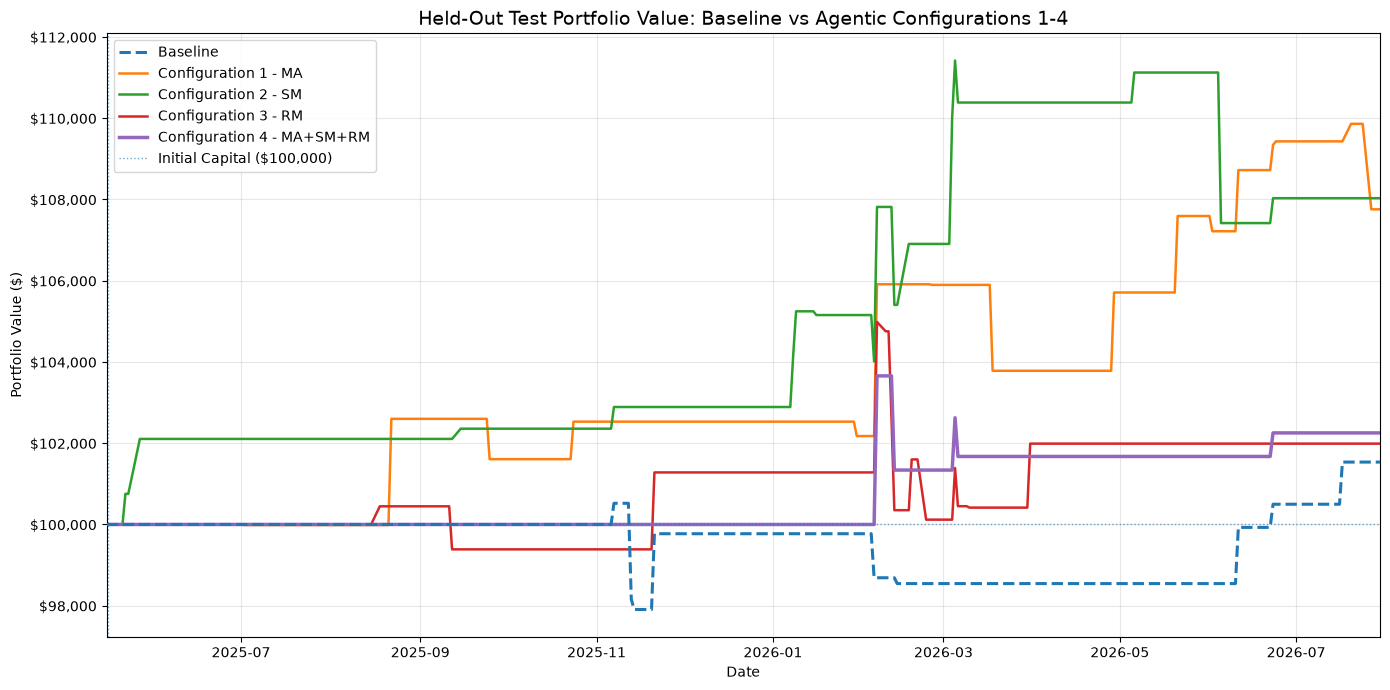

STEP 8 EQUITY PLOT DATE DIAGNOSTICS
Full baseline test start: 2025-05-16 00:00:00
Baseline visible initial point: 2025-05-15 12:00:00
Configuration 1-4 common start: 2025-05-16 00:00:00
Configuration 1-4 visible initial point: 2025-05-15 12:00:00
Plot end date: 2026-07-30 00:00:00

Baseline starting capital: 100000.0
MA starting capital: 100000.0
SM starting capital: 100000.0
RM starting capital: 100000.0
Configuration 4 starting capital: 100000.0

Baseline portfolio value at Configuration 1-4 common start: $100,000.00

Baseline line style: dashed
Agent line styles: solid


In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initial capital
initial_capital = float(specification.execution.initial_capital)

# Resolve full baseline source
if ("config4_baseline_source" in globals()):
    baseline_plot_source = (config4_baseline_source.copy())
elif ("baseline_results" in globals()):
    baseline_plot_source = (baseline_results.copy())
elif ("ma_baseline_results" in globals()):
    baseline_plot_source = (ma_baseline_results.copy())
elif ("sm_baseline_results" in globals()):
    baseline_plot_source = (sm_baseline_results.copy())
elif ("rm_baseline_results" in globals()):
    baseline_plot_source = (rm_baseline_results.copy())
else:
    raise NameError("No baseline result table is available. " "Run Step 8 Cell 12 first.")


# Standardize baseline date index
if ("Date" in baseline_plot_source.columns):
    baseline_plot_source["Date"] = pd.to_datetime(baseline_plot_source["Date"])
    baseline_plot_source = (baseline_plot_source.set_index( "Date" ))

baseline_plot_source.index = (pd.to_datetime( baseline_plot_source.index ))
baseline_plot_source = (baseline_plot_source.sort_index())

if (baseline_plot_source.index.duplicated().any()):
    baseline_plot_source = (baseline_plot_source.loc[~baseline_plot_source.index.duplicated( keep="last" )])

# Verify baseline return column
if ("net_strategy_return" not in baseline_plot_source.columns):
    raise ValueError("Baseline result table must contain " "'net_strategy_return'.")

# Select full baseline test period
if ("test_data" in globals()):
    full_test_start_date = pd.Timestamp(test_data.index.min())
    full_test_end_date = pd.Timestamp(test_data.index.max())
else:
    full_test_start_date = pd.Timestamp(baseline_plot_source.index.min())
    full_test_end_date = pd.Timestamp(baseline_plot_source.index.max())

baseline_full_test = (
    baseline_plot_source.loc[
        (baseline_plot_source.index >= full_test_start_date)
        &
        (baseline_plot_source.index <= full_test_end_date)
    ]
    .copy()
)

if (len( baseline_full_test ) == 0):
    raise RuntimeError("No baseline observations are available " "over the Step 1 held-out test period.")

# Baseline daily returns
baseline_full_returns = (
    pd.to_numeric(baseline_full_test["net_strategy_return"], errors="coerce", )
    .fillna(0.0)
    .astype(float)
)

# Full baseline equity curve
baseline_equity_curve = (initial_capital * ( 1.0 + baseline_full_returns ).cumprod())

# Agent common comparison period
config4_agent_equity_curves = {}

agent_strategy_names = [
    "Configuration 1 - MA",
    "Configuration 2 - SM",
    "Configuration 3 - RM",
    "Configuration 4 - MA+SM+RM",
]

for strategy_name in (agent_strategy_names):
    if (strategy_name not in config4_common_returns):
        raise KeyError(f"{strategy_name} is missing from " "config4_common_returns.")

    strategy_returns = (pd.Series( config4_common_returns[strategy_name], copy=True, ).astype(float).fillna( 0.0 ))
    strategy_returns.index = (pd.to_datetime( strategy_returns.index ))
    strategy_returns = (strategy_returns.sort_index())

    config4_agent_equity_curves[
        strategy_name
    ] = (initial_capital * ( 1.0 + strategy_returns ).cumprod())

# Determine agent common start and end date
agent_common_start_date = pd.Timestamp(config4_comparison_index.min())
agent_common_end_date = pd.Timestamp(config4_comparison_index.max())

# Add initial capital point for baseline
baseline_first_real_date = pd.Timestamp(baseline_equity_curve.index.min())
baseline_initial_plot_date = (baseline_first_real_date - pd.Timedelta( hours=12 ))
baseline_initial_point = pd.Series(data=[initial_capital], index=[baseline_initial_plot_date], dtype=float, )
baseline_equity_curve = (pd.concat( [baseline_initial_point, baseline_equity_curve,] ).sort_index())

# Add identical initial capital point for agents
agent_initial_plot_date = (agent_common_start_date - pd.Timedelta( hours=12 ))

for strategy_name in (agent_strategy_names):
    initial_point = pd.Series(data=[initial_capital], index=[agent_initial_plot_date], dtype=float, )

    config4_agent_equity_curves[
        strategy_name
    ] = (pd.concat( [initial_point, config4_agent_equity_curves[strategy_name],] ).sort_index())


# Ensure agents ad baseline have common start date
if (agent_common_start_date not in baseline_equity_curve.index):
    baseline_equity_curve = (
        baseline_equity_curve
        .reindex(baseline_equity_curve.index.union( pd.DatetimeIndex( [agent_common_start_date] ) ))
        .sort_index()
        .ffill()
    )

# Plot equity curve with baseline as dashed line
fig, ax = plt.subplots(figsize=( 14, 7, ))
ax.plot(
    baseline_equity_curve.index,
    baseline_equity_curve.values,
    label="Baseline",
    linestyle="--",
    linewidth=2.2,
    zorder=5,
)

# MA equity curve
ma_equity_curve = (config4_agent_equity_curves["Configuration 1 - MA"])
ax.plot(ma_equity_curve.index, ma_equity_curve.values, label="Configuration 1 - MA", linestyle="-", linewidth=1.8, )

# SM equity curve
sm_equity_curve = (config4_agent_equity_curves["Configuration 2 - SM"])
ax.plot(sm_equity_curve.index, sm_equity_curve.values, label="Configuration 2 - SM", linestyle="-", linewidth=1.8, )

# RM equity curve
rm_equity_curve = (config4_agent_equity_curves["Configuration 3 - RM"])
ax.plot(rm_equity_curve.index, rm_equity_curve.values, label="Configuration 3 - RM", linestyle="-", linewidth=1.8, )

# MA+SM+RM equity curve
combined_equity_curve = (config4_agent_equity_curves["Configuration 4 - MA+SM+RM"])
ax.plot(
    combined_equity_curve.index,
    combined_equity_curve.values,
    label="Configuration 4 - MA+SM+RM",
    linestyle="-",
    linewidth=2.5,
)

# Initial capital reference
ax.axhline(
    y=initial_capital,
    linestyle=":",
    linewidth=1.0,
    alpha=0.65,
    label=(f"Initial Capital " f"(${initial_capital:,.0f})"),
)

ax.axvline(x=agent_common_start_date, linestyle=":", linewidth=1.0, alpha=0.60, )

# Setup plot attributes
ax.set_title("Held-Out Test Portfolio Value: " "Baseline vs Agentic Configurations 1-4", fontsize=14, )
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")

plot_start_date = min(baseline_initial_plot_date, agent_initial_plot_date, )
plot_end_date = max(pd.Timestamp( baseline_equity_curve.index.max() ), agent_common_end_date, )
ax.set_xlim(plot_start_date, plot_end_date, )

ax.yaxis.set_major_formatter(plt.FuncFormatter( lambda value, position: f"${value:,.0f}" ))

ax.grid(True, alpha=0.30, )
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Diagnostics
print("=" * 80)
print("STEP 8 EQUITY PLOT DATE DIAGNOSTICS")
print("=" * 80)
print("Full baseline test start:", baseline_first_real_date, )
print("Baseline visible initial point:", baseline_initial_plot_date, )
print("Configuration 1-4 common start:", agent_common_start_date, )
print("Configuration 1-4 visible initial point:", agent_initial_plot_date, )
print("Plot end date:", plot_end_date, )
print()

print("Baseline starting capital:", float( baseline_equity_curve.iloc[0] ), )
print("MA starting capital:", float( ma_equity_curve.iloc[0] ), )
print("SM starting capital:", float( sm_equity_curve.iloc[0] ), )
print("RM starting capital:", float( rm_equity_curve.iloc[0] ), )
print("Configuration 4 starting capital:", float( combined_equity_curve.iloc[0] ), )

# Baseline value when agent comparison begins
baseline_value_at_agent_start = (baseline_equity_curve.loc[:agent_common_start_date].iloc[-1])
print()
print("Baseline portfolio value at " "Configuration 1-4 common start:", f"${baseline_value_at_agent_start:,.2f}", )
print()
print("Baseline line style: dashed")
print("Agent line styles: solid")
print("=" * 80)

In [132]:
# Reflection category distribution
config4_reflection_category_summary = (
    config4_daily_results[
        "reflection_category"
    ]
    .value_counts(dropna=False)
    .rename_axis("Reflection Category")
    .reset_index(name="Count")
)

config4_reflection_category_summary[
    "Percentage"
] = (config4_reflection_category_summary["Count"] / len( config4_daily_results ))


# Explainability component summary
config4_explainability_summary = pd.DataFrame(
    [
        {
            "Metric": "Agent Agreement Score",
            "Mean": config4_daily_results["agent_agreement_score"].mean(),
            "Std": config4_daily_results["agent_agreement_score"].std(),
            "Min": config4_daily_results["agent_agreement_score"].min(),
            "Max": config4_daily_results["agent_agreement_score"].max(),
        },

        {
            "Metric": "Evidence Completeness Score",
            "Mean": config4_daily_results["evidence_completeness_score"].mean(),
            "Std": config4_daily_results["evidence_completeness_score"].std(),
            "Min": config4_daily_results["evidence_completeness_score"].min(),
            "Max": config4_daily_results["evidence_completeness_score"].max(),
        },

        {
            "Metric": "Traceability Score",
            "Mean": config4_daily_results["traceability_score"].mean(),
            "Std": config4_daily_results["traceability_score"].std(),
            "Min": config4_daily_results["traceability_score"].min(),
            "Max": config4_daily_results["traceability_score"].max(),
        },

        {
            "Metric": "Confidence Consistency Score",
            "Mean": config4_daily_results["confidence_consistency_score"].mean(),
            "Std": config4_daily_results["confidence_consistency_score"].std(),
            "Min": config4_daily_results["confidence_consistency_score"].min(),
            "Max": config4_daily_results["confidence_consistency_score"].max(),
        },

        {
            "Metric": "Execution Completeness Score",
            "Mean": config4_daily_results["execution_completeness_score"].mean(),
            "Std": config4_daily_results["execution_completeness_score"].std(),
            "Min": config4_daily_results["execution_completeness_score"].min(),
            "Max": config4_daily_results["execution_completeness_score"].max(),
        },

        {
            "Metric": "Explainability Score",
            "Mean": config4_daily_results["explainability_score"].mean(),
            "Std": config4_daily_results["explainability_score"].std(),
            "Min": config4_daily_results["explainability_score"].min(),
            "Max": config4_daily_results["explainability_score"].max(),
        },
    ]
)

print("Reflection Category Distribution")
display(config4_reflection_category_summary)
print("Explainability Components")
display(config4_explainability_summary)
print("Consensus vs Explainability")

config4_consensus_explainability_summary = (
    config4_daily_results
    .groupby("consensus_category")
    .agg(
        Observations=("consensus_category", "size", ),
        Mean_Agreement=("agent_agreement_score", "mean", ),
        Mean_Explainability=("explainability_score", "mean", ),
        Executed_Trades=("trade_executed", "sum", ),
    )
    .reset_index()
)

display(config4_consensus_explainability_summary)

Reflection Category Distribution


,Reflection Category,Count,Percentage
0,NO_TRADE_REVIEW,297,0.983444
1,CONSISTENT_SUCCESS,3,0.009934
2,CONSISTENT_FAILURE,2,0.006623


Explainability Components


,Metric,Mean,Std,Min,Max
0,Agent Agreement Score,0.913907,0.223940,0.333333,1.000000
1,Evidence Completeness Score,1.000000,0.000000,1.000000,1.000000
2,Traceability Score,1.000000,0.000000,1.000000,1.000000
3,Confidence Consistency Score,0.500269,0.073314,0.328556,0.638973
4,Execution Completeness Score,1.000000,0.000000,1.000000,1.000000
5,Explainability Score,0.907822,0.045475,0.772617,0.945564


Consensus vs Explainability


,consensus_category,Observations,Mean_Agreement,Mean_Explainability,Executed_Trades
0,MA_SM_BUY,1,0.333333,0.797425,1
1,SINGLE_BUY,35,0.333333,0.793837,0
2,SM_RM_BUY,3,0.333333,0.787123,3
3,UNANIMOUS_BUY,1,1.000000,0.945408,1
4,UNANIMOUS_NO_TRADE,262,1.000000,0.924709,0


In [133]:
# Prerequisite validation
required_config4_cell15_objects = [
    "config4_packets",
    "config4_daily_results",
    "AgentID",
    "ConfigurationID",
    "AnalyticalVote",
]

missing_config4_cell15_objects = [
    object_name

    for object_name
    in required_config4_cell15_objects

    if object_name
    not in globals()
]

if missing_config4_cell15_objects:
    raise NameError(
        "Step 8 Cell 15 requires the completed "
        "Configuration 4 simulation. Missing objects: "
        f"{missing_config4_cell15_objects}"
    )

if (len( config4_packets ) != len( config4_daily_results )):
    raise RuntimeError(
        "Configuration 4 packet count does not match "
        "config4_daily_results row count. "
        f"Packets={len(config4_packets)}, "
        f"daily rows={len(config4_daily_results)}."
    )

# Integrity check storage
config4_integrity_checks = []

def add_config4_check(check_name, passed, observed, expected, check_type="ARCHITECTURE"):
    """
    Add one Configuration 4 integrity-check record.
    """

    config4_integrity_checks.append(
        {
            "Check Type": check_type,
            "Check": check_name,
            "Observed": observed,
            "Expected": expected,
            "Passed": bool(passed),
        }
    )

# Build authorative packet-level validation table
config4_packet_validation_records = []

for packet_number, packet in enumerate(config4_packets, start=1, ):
    # Basic packet components
    metadata = packet.metadata
    fusion = packet.decision_fusion
    execution = packet.execution_output
    reflection = packet.reflection_output

    # Validate configuration
    correct_configuration = (metadata.configuration_id == ConfigurationID.CONFIGURATION_4)

    # Fusion existence
    fusion_present = (fusion is not None)

    if not fusion_present:
        config4_packet_validation_records.append(
            {
                "Packet Number": packet_number,
                "Date": pd.Timestamp(metadata.decision_date),
                "Decision ID": metadata.decision_id,
                "Correct Configuration": correct_configuration,
                "Fusion Present": False,
                "MA Vote": None,
                "SM Vote": None,
                "RM Vote": None,
                "Calculated BUY Votes": np.nan,
                "Fusion BUY Votes": np.nan,
                "Required BUY Votes": np.nan,
                "Vote Count Valid": False,
                "Final Vote": None,
                "Expected Final Vote": None,
                "Final Vote Valid": False,
                "Trade Executed": (execution.trade_executed if execution else None),
                "Expected Execution": None,
                "Execution Valid": False,
                "RF Present": (reflection is not None),
                "Packet Valid": False,
            }
        )
        
        continue

    # Run DecisionFusionRecord's own validation first.
    try:
        fusion.validate()
        fusion_schema_valid = True
    except Exception:
        fusion_schema_valid = False

    # Authoritative individual votes
    ma_vote = (fusion.agent_votes.get( AgentID.MARKET_ANALYSIS.value ))
    sm_vote = (fusion.agent_votes.get( AgentID.SENTIMENT.value ))
    rm_vote = (fusion.agent_votes.get( AgentID.RISK_MANAGEMENT.value ))

    expected_vote_keys = {
        AgentID.MARKET_ANALYSIS.value,
        AgentID.SENTIMENT.value,
        AgentID.RISK_MANAGEMENT.value,
    }

    actual_vote_keys = set(fusion.agent_votes.keys())
    all_three_votes_present = (actual_vote_keys == expected_vote_keys)

    # Validate vote values
    valid_vote_values = (
        ma_vote
        in {
            AnalyticalVote.BUY,
            AnalyticalVote.NO_TRADE,
        }

        and

        sm_vote
        in {
            AnalyticalVote.BUY,
            AnalyticalVote.NO_TRADE,
        }

        and

        rm_vote
        in {
            AnalyticalVote.BUY,
            AnalyticalVote.NO_TRADE,
        }
    )

    # Reconstruct BUY count from actual fusion votes
    if (all_three_votes_present and valid_vote_values):
        calculated_buy_votes = sum(
            [
                int(ma_vote == AnalyticalVote.BUY),
                int(sm_vote == AnalyticalVote.BUY),
                int(rm_vote == AnalyticalVote.BUY),
            ]
        )
    else:
        calculated_buy_votes = np.nan

    recorded_buy_votes = (int( fusion.buy_vote_count ))
    required_buy_votes = (int( fusion.required_buy_votes ))

    # Vote-count invariant
    vote_count_valid = (np.isfinite( calculated_buy_votes ) and int( calculated_buy_votes ) == recorded_buy_votes)

    # Majority policy
    required_votes_valid = (required_buy_votes == 2)

    participating_agents_valid = (
        set(fusion.participating_agents) ==
        {
            AgentID.MARKET_ANALYSIS,
            AgentID.SENTIMENT,
            AgentID.RISK_MANAGEMENT,
        }
    )

    # Expected final vote
    expected_final_vote = (AnalyticalVote.BUY if ( recorded_buy_votes >= 2 ) else AnalyticalVote.NO_TRADE)
    final_vote_valid = (fusion.final_vote == expected_final_vote)

    # Expected EX execution
    expected_execution = (expected_final_vote == AnalyticalVote.BUY)
    execution_present = (execution is not None)
    execution_valid = (execution_present and bool( execution.trade_executed ) == bool( expected_execution ))

    # RF
    reflection_present = (reflection is not None)

    # Packet-level validity
    packet_valid = all(
        [
            correct_configuration,
            fusion_present,
            fusion_schema_valid,
            all_three_votes_present,
            valid_vote_values,
            participating_agents_valid,
            required_votes_valid,
            vote_count_valid,
            final_vote_valid,
            execution_valid,
            reflection_present,
        ]
    )

    config4_packet_validation_records.append(
        {
            "Packet Number": packet_number,
            "Date": pd.Timestamp(metadata.decision_date),
            "Decision ID": metadata.decision_id,
            "Correct Configuration": correct_configuration,
            "Fusion Present": fusion_present,
            "Fusion Schema Valid": fusion_schema_valid,
            "Three Votes Present": all_three_votes_present,
            "Vote Values Valid": valid_vote_values,
            "Participating Agents Valid": participating_agents_valid,
            "MA Vote": (ma_vote.value if ma_vote else None),
            "SM Vote": (sm_vote.value if sm_vote else None),
            "RM Vote": (rm_vote.value if rm_vote else None),
            "Calculated BUY Votes": calculated_buy_votes,
            "Fusion BUY Votes": recorded_buy_votes,
            "Required BUY Votes": required_buy_votes,
            "Vote Count Valid": vote_count_valid,
            "Final Vote": fusion.final_vote.value,
            "Expected Final Vote": expected_final_vote.value,
            "Final Vote Valid": final_vote_valid,
            "Trade Executed": (execution.trade_executed if execution_present else None),
            "Expected Execution": expected_execution,
            "Execution Valid": execution_valid,
            "RF Present": reflection_present,
            "Packet Valid": packet_valid,
        }
    )

config4_packet_validation = (pd.DataFrame( config4_packet_validation_records ).set_index( "Date" ).sort_index())

# Packet-level architecture checks
all_packets_config4 = bool(config4_packet_validation["Correct Configuration"].all())

add_config4_check(
    check_name=("Every packet uses Configuration 4"),
    passed=(all_packets_config4),
    observed=(f"{int(config4_packet_validation['Correct Configuration'].sum())}" f"/{len(config4_packet_validation)}"),
    expected=(f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)}"),
)

# Fusion exists
all_fusion_present = bool(config4_packet_validation["Fusion Present"].all())

add_config4_check(
    "DecisionFusionRecord exists for every packet",
    all_fusion_present,
    (f"{int(config4_packet_validation['Fusion Present'].sum())}" f"/{len(config4_packet_validation)}"),
    (f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)}"),
)

# Fusion schema valid
if ("Fusion Schema Valid" in config4_packet_validation.columns):
    fusion_schema_valid_all = bool(config4_packet_validation["Fusion Schema Valid"].fillna( False ).all())
else:
    fusion_schema_valid_all = False

add_config4_check("DecisionFusionRecord schema validation", fusion_schema_valid_all, fusion_schema_valid_all, True, )

# All three analytical agents
three_agents_valid = bool(config4_packet_validation["Participating Agents Valid"].fillna( False ).all())
add_config4_check("MA, SM and RM participate in every packet", three_agents_valid, three_agents_valid, True, )

# Three valid votes
three_votes_valid = bool(
    (
        config4_packet_validation["Three Votes Present"].fillna(False)
        &
        config4_packet_validation["Vote Values Valid"].fillna(False)
    )
    .all()
)

add_config4_check("Every packet contains valid MA, SM and RM votes", three_votes_valid, three_votes_valid, True, )

# Required votes = 2
required_votes_valid_all = bool(config4_packet_validation["Required BUY Votes"].dropna().eq( 2 ).all())

add_config4_check(
    "Required BUY votes",
    required_votes_valid_all,
    sorted(config4_packet_validation["Required BUY Votes"].dropna().unique().tolist()),
    [2],
)

# Authorative BUY-vote count check
packet_vote_count_valid = bool(config4_packet_validation["Vote Count Valid"].fillna( False ).all())
packet_vote_count_matches = int(config4_packet_validation["Vote Count Valid"].fillna( False ).sum())

add_config4_check(
    check_name=("DecisionFusion BUY count equals " "MA + SM + RM packet votes"),
    passed=(packet_vote_count_valid),
    observed=(f"{packet_vote_count_matches}" f"/{len(config4_packet_validation)} matched"),
    expected=(f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)} matched"),
)

# Final vote check
packet_final_vote_valid = bool(config4_packet_validation["Final Vote Valid"].fillna( False ).all())

add_config4_check(
    "Final BUY iff DecisionFusion BUY votes >= 2",
    packet_final_vote_valid,
    (
        f"{int(config4_packet_validation['Final Vote Valid'].fillna(False).sum())}"
        f"/{len(config4_packet_validation)} matched"
    ),
    (f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)} matched"),
)

# Execution check
packet_execution_valid = bool(config4_packet_validation["Execution Valid"].fillna( False ).all())

add_config4_check(
    "EX executes iff final consensus vote is BUY",
    packet_execution_valid,
    (
        f"{int(config4_packet_validation['Execution Valid'].fillna(False).sum())}"
        f"/{len(config4_packet_validation)} matched"
    ),
    (f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)} matched"),
)

# RF check
packet_rf_valid = bool(config4_packet_validation["RF Present"].fillna( False ).all())

add_config4_check(
    "RF completed every packet",
    packet_rf_valid,
    (
        f"{int(config4_packet_validation['RF Present'].fillna(False).sum())}"
        f"/{len(config4_packet_validation)} completed"
    ),
    (f"{len(config4_packet_validation)}" f"/{len(config4_packet_validation)} completed"),
)

# Capital continuity
config4_packet_capital_records = []

for packet in (config4_packets):
    execution = packet.execution_output
    if (execution is None):
        continue

    config4_packet_capital_records.append(
        {
            "date": pd.Timestamp(packet.metadata.decision_date),
            "capital_before": float(execution.capital_before),
            "capital_after": float(execution.capital_after),
        }
    )

config4_packet_capital = (pd.DataFrame( config4_packet_capital_records ).set_index( "date" ).sort_index())

if (len( config4_packet_capital ) > 1):
    capital_continuity_mask = np.isclose(
        config4_packet_capital[
            "capital_before"
        ]
        .iloc[
            1:
        ]
        .to_numpy(dtype=float),

        config4_packet_capital[
            "capital_after"
        ]
        .iloc[
            :-1
        ]
        .to_numpy(dtype=float),

        rtol=1e-10,
        atol=1e-8,
    )
    capital_continuity = bool(capital_continuity_mask.all())
else:
    capital_continuity = True

add_config4_check("Portfolio capital continuity", capital_continuity, capital_continuity, True, )

# Initial capital check
if (len( config4_packet_capital ) > 0):
    observed_initial_capital = float(config4_packet_capital["capital_before"].iloc[0])
    expected_initial_capital = float(specification.execution.initial_capital)
    initial_capital_valid = bool(
        np.isclose(observed_initial_capital, expected_initial_capital, rtol=1e-10, atol=1e-8, )
    )
else:
    observed_initial_capital = np.nan
    expected_initial_capital = float(specification.execution.initial_capital)
    initial_capital_valid = False

add_config4_check(
    "Configuration 4 starts from fresh initial capital",
    initial_capital_valid,
    observed_initial_capital,
    expected_initial_capital,
)

# Traceability/reflecton score check
if ("traceability_score" in config4_daily_results.columns):
    traceability_complete = bool(config4_daily_results["traceability_score"].notna().all())
else:
    traceability_complete = False

add_config4_check(
    "Traceability score available every day",
    traceability_complete,
    (
        int(config4_daily_results["traceability_score"].notna().sum())
        if ("traceability_score" in config4_daily_results.columns)
        else 0
    ),
    len(config4_daily_results),
)

# Daily result logging consistency
packet_logging_records = []

for packet in (config4_packets):
    fusion = packet.decision_fusion
    if (fusion is None):
        continue
    packet_date = pd.Timestamp(packet.metadata.decision_date)
    packet_logging_records.append(
        {
            "date": packet_date,
            "packet_ma_buy": int(fusion.agent_votes.get( AgentID.MARKET_ANALYSIS.value ) == AnalyticalVote.BUY),
            "packet_sm_buy": int(fusion.agent_votes.get( AgentID.SENTIMENT.value ) == AnalyticalVote.BUY),
            "packet_rm_buy": int(fusion.agent_votes.get( AgentID.RISK_MANAGEMENT.value ) == AnalyticalVote.BUY),
            "packet_buy_vote_count": int(fusion.buy_vote_count),
            "packet_final_buy": int(fusion.final_vote == AnalyticalVote.BUY),
        }
    )

config4_packet_logging = (pd.DataFrame( packet_logging_records ).set_index( "date" ).sort_index())

# Normalize daily results index
config4_daily_logging = (config4_daily_results.copy())
config4_daily_logging.index = (pd.to_datetime( config4_daily_logging.index ))
config4_daily_logging = (config4_daily_logging.sort_index())

logging_common_index = (config4_packet_logging.index.intersection( config4_daily_logging.index ))

if (len( logging_common_index ) != len( config4_packet_logging )):
    logging_index_valid = False
else:
    logging_index_valid = True

# Compare flattened daily log with authoritative packets
if (logging_index_valid):
    config4_logging_diagnostic = pd.DataFrame(index=( logging_common_index ))

    # Packet source of truth
    config4_logging_diagnostic["Packet MA BUY"] = (config4_packet_logging.loc[logging_common_index, "packet_ma_buy",].astype(int))
    config4_logging_diagnostic["Packet SM BUY"] = (config4_packet_logging.loc[logging_common_index, "packet_sm_buy",].astype(int))
    config4_logging_diagnostic["Packet RM BUY"] = (config4_packet_logging.loc[logging_common_index, "packet_rm_buy",].astype(int))
    config4_logging_diagnostic["Packet BUY Votes"] = (config4_packet_logging.loc[logging_common_index, "packet_buy_vote_count",].astype(int))

    # Flattened daily result
    config4_logging_diagnostic["Daily MA BUY"] = (pd.to_numeric( config4_daily_logging.loc[logging_common_index, "ma_buy",], errors="coerce", ))
    config4_logging_diagnostic["Daily SM BUY"] = (pd.to_numeric( config4_daily_logging.loc[logging_common_index, "sm_buy",], errors="coerce", ))
    config4_logging_diagnostic["Daily RM BUY"] = (pd.to_numeric( config4_daily_logging.loc[logging_common_index, "rm_buy",], errors="coerce", ))
    config4_logging_diagnostic["Daily BUY Votes"] = (pd.to_numeric( config4_daily_logging.loc[logging_common_index, "buy_vote_count",], errors="coerce", ))

    # Individual matches
    config4_logging_diagnostic["MA Match"] = (
        config4_logging_diagnostic["Packet MA BUY"].to_numpy(dtype=int)
        ==
        config4_logging_diagnostic["Daily MA BUY"].to_numpy(dtype=float)
    )

    config4_logging_diagnostic["SM Match"] = (
        config4_logging_diagnostic["Packet SM BUY"].to_numpy(dtype=int)
        ==
        config4_logging_diagnostic["Daily SM BUY"].to_numpy(dtype=float)
    )

    config4_logging_diagnostic["RM Match"] = (
        config4_logging_diagnostic["Packet RM BUY"].to_numpy(dtype=int)
        ==
        config4_logging_diagnostic["Daily RM BUY"].to_numpy(dtype=float)
    )

    config4_logging_diagnostic["Vote Count Match"] = (
        config4_logging_diagnostic["Packet BUY Votes"].to_numpy(dtype=int)
        ==
        config4_logging_diagnostic["Daily BUY Votes"].to_numpy(dtype=float)
    )

    config4_logging_diagnostic["All Logging Fields Match"] = (
        config4_logging_diagnostic["MA Match"]
        &
        config4_logging_diagnostic["SM Match"]
        &
        config4_logging_diagnostic["RM Match"]
        &
        config4_logging_diagnostic["Vote Count Match"]
    )

    config4_logging_mismatches = (
        config4_logging_diagnostic.loc[~config4_logging_diagnostic["All Logging Fields Match"]
        ]
        .copy()
    )

    config4_logging_valid = bool(config4_logging_diagnostic["All Logging Fields Match"].all())

else:
    config4_logging_diagnostic = pd.DataFrame()
    config4_logging_mismatches = pd.DataFrame()
    config4_logging_valid = False

# Log consistency is diagnostic.
add_config4_check(
    check_name=("Flattened daily vote log agrees with packets"),
    passed=(config4_logging_valid),
    observed=(
        (
            f"{int(config4_logging_diagnostic['All Logging Fields Match'].sum())}"
            f"/{len(config4_logging_diagnostic)} matched"
        )
        if (not config4_logging_diagnostic.empty)
        else "Index mismatch"
    ),

    expected=(
        (f"{len(config4_logging_diagnostic)}" f"/{len(config4_logging_diagnostic)} matched")
        if (not config4_logging_diagnostic.empty)
        else "All packet dates represented"
    ),

    check_type=("LOGGING"),
)

# Display packet-level vote diagnostics
config4_packet_vote_mismatches = (
    config4_packet_validation.loc[
        ~config4_packet_validation[
            "Vote Count Valid"
        ]
        .fillna(False)
    ]
)

if (len( config4_packet_vote_mismatches ) > 0):
    print()
    print("=" * 80)
    print("AUTHORITATIVE PACKET VOTE-COUNT MISMATCHES")
    print("=" * 80)

    display(
        config4_packet_vote_mismatches[
            [
                "MA Vote",
                "SM Vote",
                "RM Vote",
                "Calculated BUY Votes",
                "Fusion BUY Votes",
                "Required BUY Votes",
                "Final Vote",
                "Trade Executed",
            ]
        ]
    )

else:
    print()
    print("Authoritative DecisionFusion vote-count check: PASS")

# Display daily logging mismatches
if (len( config4_logging_mismatches ) > 0):
    print()
    print("=" * 80)
    print("DAILY RESULT LOGGING MISMATCHES DETECTED")
    print("=" * 80)
    print(
        "These rows indicate that config4_daily_results "
        "does not exactly reproduce the authoritative "
        "DecisionFusionRecord."
    )
    print("This is a reporting/logging discrepancy, not " "necessarily a Configuration 4 voting failure.")
    display(config4_logging_mismatches)

else:
    print()
    print("Flattened config4_daily_results vote log: PASS")

# Complete architecture summary
config4_integrity_summary = pd.DataFrame(config4_integrity_checks)
display(config4_integrity_summary)

# Determine architecture status
config4_architecture_checks_only = (
    config4_integrity_summary.loc[
        config4_integrity_summary["Check Type"] == "ARCHITECTURE"
    ]
)

CONFIG4_ARCHITECTURE_PASSED = bool(config4_architecture_checks_only["Passed"].all())
CONFIG4_LOGGING_PASSED = bool(config4_logging_valid)

# Fail only for a genuine architecture failure
if not (CONFIG4_ARCHITECTURE_PASSED):
    failed_architecture_checks = (
        config4_architecture_checks_only.loc[~config4_architecture_checks_only["Passed"],"Check",].tolist()
    )

    print()
    print("=" * 80)
    print("CONFIGURATION 4 GENUINE ARCHITECTURE FAILURE")
    print("=" * 80)

    print("Failed checks:")

    for failed_check in (failed_architecture_checks):
        print(" -", failed_check, )

    raise RuntimeError("Configuration 4 architecture validation failed: " f"{failed_architecture_checks}")


# Success summary
print()
print("=" * 80)
print("CONFIGURATION 4 ARCHITECTURE VALIDATION: PASS")
print("=" * 80)

print("Authoritative validation source:")
print("DecisionPacket -> DecisionFusionRecord -> " "ExecutionOutput -> ReflectionOutput")
print()

print("Packets validated:", len( config4_packet_validation ), )
print("DecisionFusion vote-count matches:", f"{packet_vote_count_matches}/" f"{len(config4_packet_validation)}", )
print("2-of-3 final-vote rule:", ( "PASS" if packet_final_vote_valid else "FAIL" ), )
print("EX follows consensus:", ( "PASS" if packet_execution_valid else "FAIL" ), )
print("RF completed:", ( "PASS" if packet_rf_valid else "FAIL" ), )
print("Capital continuity:", ( "PASS" if capital_continuity else "FAIL" ), )

print()

if (CONFIG4_LOGGING_PASSED):
    print("Flattened daily-results logging: PASS")
else:
    print("Flattened daily-results logging: WARNING")
    print(
        "The authoritative packet architecture passed, "
        "but one or more cached daily vote columns differ "
        "from the packet DecisionFusionRecord."
    )
    print(
        "Review config4_logging_mismatches above. "
        "If these are stale results from an earlier Cell 6/7 "
        "run, rerun Step 8 Cells 6 and 7 before exporting."
    )
print()

print("MA, SM and RM remain analytically independent.")
print("Configuration 4 requires exactly 2 of 3 BUY votes.")
print("EX applies no independent ML or confidence gate.")
print("RF remains post-decision and diagnostic only.")
print("=" * 80)


Authoritative DecisionFusion vote-count check: PASS

Flattened config4_daily_results vote log: PASS


,Check Type,Check,Observed,Expected,Passed
0,ARCHITECTURE,Every packet uses Configuration 4,302/302,302/302,True
1,ARCHITECTURE,DecisionFusionRecord exists for every packet,302/302,302/302,True
2,ARCHITECTURE,DecisionFusionRecord schema validation,True,True,True
3,ARCHITECTURE,"MA, SM and RM participate in every packet",True,True,True
4,ARCHITECTURE,"Every packet contains valid MA, SM and RM votes",True,True,True
5,ARCHITECTURE,Required BUY votes,[2],[2],True
6,ARCHITECTURE,DecisionFusion BUY count equals MA + SM + RM p...,302/302 matched,302/302 matched,True
7,ARCHITECTURE,Final BUY iff DecisionFusion BUY votes >= 2,302/302 matched,302/302 matched,True
8,ARCHITECTURE,EX executes iff final consensus vote is BUY,302/302 matched,302/302 matched,True
9,ARCHITECTURE,RF completed every packet,302/302 completed,302/302 completed,True



CONFIGURATION 4 ARCHITECTURE VALIDATION: PASS
Authoritative validation source:
DecisionPacket -> DecisionFusionRecord -> ExecutionOutput -> ReflectionOutput

Packets validated: 302
DecisionFusion vote-count matches: 302/302
2-of-3 final-vote rule: PASS
EX follows consensus: PASS
RF completed: PASS
Capital continuity: PASS

Flattened daily-results logging: PASS

MA, SM and RM remain analytically independent.
Configuration 4 requires exactly 2 of 3 BUY votes.
EX applies no independent ML or confidence gate.
RF remains post-decision and diagnostic only.


In [134]:
# Export configuration 4 outputs
CONFIG4_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True, )

# Daily desicions
config4_daily_results.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_daily_results.csv")

# Reflection log
config4_reflection_log.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_reflection_log.csv")

# Consensus confusion matrix
config4_consensus_confusion_matrix.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_consensus_confusion_matrix.csv")

# Consensys metrics
config4_consensus_metrics.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_consensus_metrics.csv", index=False, )

# Individual vote summary
config4_vote_summary.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_agent_vote_summary.csv", index=False, )

# Consensus pattern summary
config4_consensus_summary.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_consensus_pattern_summary.csv", index=False, )

# EX summary
config4_execution_summary.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_execution_summary.csv", index=False, )

# Configuration 4 trading metrics
config4_trading_metrics_table = pd.DataFrame(
    {
        "Metric": list(config4_trading_metrics.keys()),
        "Configuration 4 Test": list(config4_trading_metrics.values()),
    }
)

config4_trading_metrics_table.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_trading_metrics.csv", index=False, )

# All configurations performance
config4_performance_comparison.to_csv(CONFIG4_OUTPUT_DIRECTORY / "baseline_vs_configurations_1_to_4.csv", index=False, )

# RF summary
config4_reflection_category_summary.to_csv(
    CONFIG4_OUTPUT_DIRECTORY
    /
    "config4_reflection_category_summary.csv",
    index=False,
)

config4_explainability_summary.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_explainability_summary.csv", index=False, )
config4_consensus_explainability_summary.to_csv(
    CONFIG4_OUTPUT_DIRECTORY
    /
    "config4_consensus_explainability_summary.csv",
    index=False,
)

# Architecture validation
config4_integrity_summary.to_csv(CONFIG4_OUTPUT_DIRECTORY / "config4_architecture_integrity.csv", index=False, )

# Packet JSON audit trail
config4_packet_directory = (CONFIG4_OUTPUT_DIRECTORY / "packets")
config4_packet_directory.mkdir(parents=True, exist_ok=True, )

for packet in (config4_packets):
    packet_file_name = f"{packet.metadata.decision_date}_" f"{packet.metadata.decision_id}.json"
    packet.save_json(config4_packet_directory / packet_file_name)

# Final summary
print()
print("=" * 80)
print("STEP 8 - CONFIGURATION 4 COMPLETED")
print("=" * 80)

print("Architecture:")
print("MA ----\\")
print("SM -----+--> 2-of-3 Consensus --> EX --> RF")
print("RM ----/")
print()

print("Test observations:", len( config4_daily_results ), )
print("MA BUY votes:", int( config4_daily_results["ma_buy"].sum() ), )
print("SM BUY votes:", int( config4_daily_results["sm_buy"].sum() ), )
print("RM BUY votes:", int( config4_daily_results["rm_buy"].sum() ), )

print("Consensus BUY decisions:", int( config4_consensus_buy_mask.sum() ), )
print("Executed trades:", int( config4_executed_mask.sum() ), )
print("TP:", int( config4_tp ), )
print("FP:", int( config4_fp ), )
print("TN:", int( config4_tn ), )
print("FN:", int( config4_fn ), )
print("Consensus Balanced Accuracy:", f"{config4_balanced_accuracy:.4f}", )
print("Consensus Precision:", f"{config4_precision:.4f}", )
print("Consensus Recall:", f"{config4_recall:.4f}", )
print("Consensus F1:", f"{config4_f1:.4f}", )
print()

print("Configuration 4 Final Portfolio Value:", f"${config4_trading_metrics['Final Portfolio Value']:,.2f}", )
print("Configuration 4 Total Return:", f"{config4_trading_metrics['Total Return']:.4%}", )
print("Configuration 4 Sharpe Ratio:", f"{config4_trading_metrics['Sharpe Ratio']:.4f}", )
print("Configuration 4 Maximum Drawdown:", f"{config4_trading_metrics['Maximum Drawdown']:.4%}", )
print()

print("Mean Explainability Score:", f"{config4_daily_results['explainability_score'].mean():.4f}", )
print("Architecture Integrity:", ( "PASS" if CONFIG4_ARCHITECTURE_PASSED else "FAIL" ), )
print()

print("Outputs saved to:")
print(CONFIG4_OUTPUT_DIRECTORY.resolve())
print("=" * 80)


STEP 8 - CONFIGURATION 4 COMPLETED
Architecture:
MA ----\
SM -----+--> 2-of-3 Consensus --> EX --> RF
RM ----/

Test observations: 302
MA BUY votes: 16
SM BUY votes: 17
RM BUY votes: 13
Consensus BUY decisions: 5
Executed trades: 5
TP: 3
FP: 2
TN: 158
FN: 139
Consensus Balanced Accuracy: 0.5043
Consensus Precision: 0.6000
Consensus Recall: 0.0211
Consensus F1: 0.0408

Configuration 4 Final Portfolio Value: $102,254.00
Configuration 4 Total Return: 2.2540%
Configuration 4 Sharpe Ratio: 0.4627
Configuration 4 Maximum Drawdown: -2.2366%

Mean Explainability Score: 0.9078
Architecture Integrity: PASS

Outputs saved to:
C:\Users\yeobp\Desktop\Python\DBA-AIML-Walsh\MS-AIML\Capstone\FinalVersion\data\model2\step8_agentic_outputs


#### Step 9: Statistical Test using Paired t-test

In [136]:
import numpy as np
import pandas as pd
from scipy import stats

# Parameters used
PAIRED_T_ALPHA = 0.05

# Validate required agent result tables
required_agent_tables = {
    "ma_daily_results": "Run Step 5 before Step 9.",
    "sm_daily_results": "Run Step 6 before Step 9.",
    "rm_daily_results": "Run Step 7 before Step 9.",
    "config4_daily_results": "Run Step 8 before Step 9.",
}

missing_agent_tables = [
    table_name
    for table_name in required_agent_tables
    if table_name not in globals()
]

if missing_agent_tables:
    raise NameError(
        "The following agent result tables are unavailable: "
        f"{missing_agent_tables}. "
        "Run Steps 5-8 before Step 9."
    )

# Validate agent return column
for table_name in required_agent_tables:
    table = globals()[table_name]
    if "net_return" not in table.columns:
        raise ValueError(f"{table_name} must contain a 'net_return' column.")

# Check to make sure the required source results are available
if "baseline_results" in globals():
    paired_t_baseline_source = (baseline_results.copy())

elif "ma_baseline_results" in globals():
    paired_t_baseline_source = (ma_baseline_results.copy())

elif "sm_baseline_results" in globals():
    paired_t_baseline_source = (sm_baseline_results.copy())

elif "rm_baseline_results" in globals():
    paired_t_baseline_source = (rm_baseline_results.copy())

elif "config4_baseline_source" in globals():
    paired_t_baseline_source = (config4_baseline_source.copy())

else:
    raise NameError("No baseline result table is available. Run the baseline analysis first.")

# Standardize baseline date index
if "Date" in paired_t_baseline_source.columns:
    paired_t_baseline_source["Date"] = pd.to_datetime(paired_t_baseline_source["Date"])
    paired_t_baseline_source = (paired_t_baseline_source.set_index("Date"))

paired_t_baseline_source.index = pd.to_datetime(paired_t_baseline_source.index)
paired_t_baseline_source = (paired_t_baseline_source.sort_index())

# Remove duplicate dates if present
if paired_t_baseline_source.index.duplicated().any():
    paired_t_baseline_source = (
        paired_t_baseline_source.loc[~paired_t_baseline_source.index.duplicated(keep="last")
        ]
    )

if ("net_strategy_return" not in paired_t_baseline_source.columns):
    raise ValueError("Baseline result table must contain 'net_strategy_return'.")

# Utility/helper function to create aligned agent/baseline return table
def build_aligned_return_table(
    agent_results,
    agent_column,
    baseline_source,
    minimum_observations=20,
):
    # Prepare agent data
    agent_df = agent_results.copy()
    
    if "Date" in agent_df.columns:
        agent_df["Date"] = pd.to_datetime(agent_df["Date"])
        agent_df = (agent_df.set_index("Date"))

    agent_df.index = pd.to_datetime(agent_df.index)
    agent_df = (agent_df.sort_index())

    # Remove duplicate dates
    if agent_df.index.duplicated().any():
        agent_df = (agent_df.loc[~agent_df.index.duplicated(keep="last")])

    # Align baseline and agent on identical dates
    common_index = (agent_df.index.intersection(baseline_source.index).sort_values())

    if len(common_index) < minimum_observations:
        raise RuntimeError(
            f"Insufficient aligned {agent_column}/Baseline "
            f"observations. Found {len(common_index)}, "
            f"but at least {minimum_observations} are required."
        )

    aligned_returns = pd.DataFrame(
        {
            "Baseline": pd.to_numeric(baseline_source.loc[common_index,"net_strategy_return"],errors="coerce",),
            agent_column: pd.to_numeric(agent_df.loc[common_index,"net_return"],errors="coerce",),
        },
        index=common_index,
    )

    # Remove only invalid observations.
    # IMPORTANT: Zero-return NO_TRADE days remain.
    aligned_returns = (aligned_returns.replace([np.inf, -np.inf],np.nan,).dropna())

    if len(aligned_returns) < minimum_observations:
        raise RuntimeError(
            f"Fewer than {minimum_observations} complete "
            f"paired {agent_column}/Baseline observations remain after alignment."
        )

    # Return difference
    #    Positive: Agent outperformed baseline
    #    Negative: Baseline outperformed agent
    aligned_returns["Return Difference"] = (aligned_returns[agent_column]-aligned_returns["Baseline"])

    return aligned_returns

# RQ1: Market analysis agent vs baseline
rq1_returns = build_aligned_return_table(
    agent_results=ma_daily_results,
    agent_column="MA",
    baseline_source=paired_t_baseline_source,
)

# RQ2: Sentiment analysis agent vs baseline
rq2_returns = build_aligned_return_table(
    agent_results=sm_daily_results,
    agent_column="SM",
    baseline_source=paired_t_baseline_source,
)

# RQ3: Risk analysis agent vs baseline
rq3_returns = build_aligned_return_table(
    agent_results=rm_daily_results,
    agent_column="RM",
    baseline_source=paired_t_baseline_source,
)

# RQ4: Complete multi-agent configuration vs baseline
rq4_returns = build_aligned_return_table(
    agent_results=config4_daily_results,
    agent_column="MA+SM+RM",
    baseline_source=paired_t_baseline_source,
)

# Validation summary
paired_return_alignment_summary = pd.DataFrame(
    {
        "RQ": ["RQ1","RQ2","RQ3","RQ4",],
        "Comparison": ["MA vs Baseline","SM vs Baseline","RM vs Baseline","MA+SM+RM vs Baseline",],
        "N": [len(rq1_returns),len(rq2_returns),len(rq3_returns),len(rq4_returns),],
        "Start Date": [rq1_returns.index.min(),rq2_returns.index.min(),rq3_returns.index.min(),rq4_returns.index.min(),],
        "End Date": [rq1_returns.index.max(),rq2_returns.index.max(),rq3_returns.index.max(),rq4_returns.index.max(),],
    }
)

print("=" * 100)
print("RQ1-RQ4 PAIRED RETURN TABLES CONSTRUCTED")
print("=" * 100)
display(paired_return_alignment_summary)

print("\nReturn-table columns:")
print("RQ1:",rq1_returns.columns.tolist())
print("RQ2:",rq2_returns.columns.tolist())
print("RQ3:",rq3_returns.columns.tolist())
print("RQ4:",rq4_returns.columns.tolist())
print("=" * 100)

# Define paired t-test function between baseline and 4 different agent configuration returns
def run_paired_t_test(returns_df, agent_column, baseline_column="Baseline", alpha=0.05):
    # Extract paired observations
    paired_data = (returns_df[[baseline_column, agent_column,]].replace( [np.inf, -np.inf,], np.nan, ).dropna().copy())

    if len(paired_data) < 2:
        raise ValueError("At least two paired observations are required.")

    baseline_returns = (paired_data[baseline_column].to_numpy( dtype=float ))
    agent_returns = (paired_data[agent_column].to_numpy( dtype=float ))

    # Paired differences, sample size and degree of freedom
    differences = (agent_returns - baseline_returns)
    n = len(differences)
    df = (n - 1)

    mean_baseline = float(np.mean( baseline_returns ))
    mean_agent = float(np.mean( agent_returns ))
    mean_difference = float(np.mean( differences ))

    sd_difference = float(np.std( differences, ddof=1, ))
    standard_error = float(sd_difference / np.sqrt( n ))

    # Paired t-test
    #    H0: mean difference = 0 (no difference)
    #    H1: mean difference > 0 (agents perform better than baseline)
    ttest_result = stats.ttest_rel(agent_returns, baseline_returns, alternative="greater", )
    t_statistic = float(ttest_result.statistic)
    p_value_one_sided = float(ttest_result.pvalue)
    significant = bool(p_value_one_sided < alpha)

    return {
        "N": n,
        "Degrees of Freedom": df,
        "Baseline Mean Daily Return": mean_baseline,
        "Agent Mean Daily Return": mean_agent,
        "Mean Daily Return Difference": mean_difference,
        "SD of Paired Differences": sd_difference,
        "Standard Error":standard_error,
        "t-statistic":t_statistic,
        "One-Sided p-value":p_value_one_sided,
        "Significant": significant,
    }

# RQ1: Market Analysis Agent vs Baseline
rq1_paired_t = run_paired_t_test(
    returns_df=(rq1_returns),
    agent_column="MA",
    baseline_column="Baseline",
    alpha=(PAIRED_T_ALPHA),
)

# RQ2: Sentiment Analysis Agent vs Baseline
rq2_paired_t = run_paired_t_test(
    returns_df=(rq2_returns),
    agent_column="SM",
    baseline_column="Baseline",
    alpha=(PAIRED_T_ALPHA),
)

# RQ3: Risk Management Agent vs Baseline
rq3_paired_t = run_paired_t_test(
    returns_df=(rq3_returns),
    agent_column="RM",
    baseline_column="Baseline",
    alpha=(PAIRED_T_ALPHA),
)

# RQ4: Risk-Aware Multi-Agent AI System vs Baseline
rq4_paired_t = run_paired_t_test(
    returns_df=(rq4_returns),
    agent_column="MA+SM+RM",
    baseline_column="Baseline",
    alpha=(PAIRED_T_ALPHA),
)

# Create consolidated paired t-test table
paired_t_test_results = pd.DataFrame(
    [
        {
            "RQ": "RQ1",
            "Comparison": "MA vs Baseline",
            **rq1_paired_t,
        },
        {
            "RQ": "RQ2",
            "Comparison": "SM vs Baseline",
            **rq2_paired_t,
        },
        {
            "RQ": "RQ3",
            "Comparison": "RM vs Baseline",
            **rq3_paired_t,
        },
        {
            "RQ": "RQ4",
            "Comparison": "MA+SM+RM vs Baseline",
            **rq4_paired_t,
        },
    ]
)

# Display paired t-test results
print("=" * 100)
print("PAIRED T-TEST RESULTS - RQ1 TO RQ4")
print("=" * 100)

display(paired_t_test_results)


RQ1-RQ4 PAIRED RETURN TABLES CONSTRUCTED


,RQ,Comparison,N,Start Date,End Date
0,RQ1,MA vs Baseline,302,2025-05-16,2026-07-30
1,RQ2,SM vs Baseline,302,2025-05-16,2026-07-30
2,RQ3,RM vs Baseline,302,2025-05-16,2026-07-30
3,RQ4,MA+SM+RM vs Baseline,302,2025-05-16,2026-07-30



Return-table columns:
RQ1: ['Baseline', 'MA', 'Return Difference']
RQ2: ['Baseline', 'SM', 'Return Difference']
RQ3: ['Baseline', 'RM', 'Return Difference']
RQ4: ['Baseline', 'MA+SM+RM', 'Return Difference']
PAIRED T-TEST RESULTS - RQ1 TO RQ4


,RQ,Comparison,N,Degrees of Freedom,Baseline Mean Daily Return,Agent Mean Daily Return,Mean Daily Return Difference,SD of Paired Differences,Standard Error,t-statistic,One-Sided p-value,Significant
0,RQ1,MA vs Baseline,302,301,0.000053,0.000254,0.000201,0.004005,0.000230,0.872010,0.191949,False
1,RQ2,SM vs Baseline,302,301,0.000053,0.000264,0.000211,0.004470,0.000257,0.821143,0.206107,False
2,RQ3,RM vs Baseline,302,301,0.000053,0.000071,0.000018,0.003772,0.000217,0.084587,0.466323,False
3,RQ4,MA+SM+RM vs Baseline,302,301,0.000053,0.000077,0.000024,0.003389,0.000195,0.125435,0.450132,False


#### End of Capstone Project